SolarHive — Synthetic Training Data Generator
==============================================
Calls all four API services (Open-Meteo, NREL PVWatts, OWM, EIA),
validates in pandas DataFrames, and generates ~520 data-grounded
training examples for fine-tuning.

No GPU required — pure data pipeline (CPU-only Colab).

Gemma is a trademark of Google LLC.

Cell structure:
  0:  Dependencies
  1:  API Keys + Constants
  2:  Open-Meteo Historical (free, no key)
  3:  NREL PVWatts v8 (uses NREL_API_KEY)
  4:  OWM Current Weather (uses OWM_API_KEY)
  5:  EIA Grid Data (uses EIA_API_KEY)
  6:  DataFrame EDA, Validation & Cross-Validation
  6a: Temporal-spatial join → unified_df keyed by (location, time)
  6b: Visualizations (12 charts: distributions, heatmaps, time series)
  7:  Synthetic Example Generation (~520 examples)
  7a: Hand-crafted Q&A and tool-calling examples (~463 entries)
  7c: Project archive image integration
  7d: Image-grounded Q&A generator
  7e: Multimodal HF Dataset assembly
  7f: HF push of multimodal Dataset + dataset card
  8:  Export

## 0: Dependencies

In [1]:
# === CELL 0: Dependencies ====================================================
# All pre-installed on Colab — no pip installs needed.

import pandas as pd
import numpy as np
import requests
import json
import os
import time
import random
from datetime import datetime, timedelta, timezone
from pathlib import Path
from zoneinfo import ZoneInfo

print("✅ Cell 0 complete — all imports available")

✅ Cell 0 complete — all imports available


## 1: API Keys + Constants

In [2]:
# === CELL 1: API Keys + Constants ============================================
# Same Kaggle/Colab detection pattern as finetune.py / inference.py.

_on_kaggle = os.path.exists("/kaggle/working")
if _on_kaggle:
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    OWM_API_KEY  = secrets.get_secret("OWM_API_KEY")
    NREL_API_KEY = secrets.get_secret("NREL_API_KEY")
    EIA_API_KEY  = secrets.get_secret("EIA_API_KEY")
    print("   Keys loaded from Kaggle Secrets")
else:
    from google.colab import userdata
    OWM_API_KEY  = userdata.get("OWM_API_KEY")
    NREL_API_KEY = userdata.get("NREL_API_KEY")
    EIA_API_KEY  = userdata.get("EIA_API_KEY")
    print("   Keys loaded from Colab Secrets")

# Two community locations for geographic diversity
LOCATIONS = {
    "Ann Arbor, MI": {
        "lat": 42.2808, "lon": -83.7430,
        "capacity_kw": 72, "battery_kwh": 100,
        "tilt": 30, "azimuth": 180, "losses": 14,
        "grid_region": "MISO",
        "timezone": "America/New_York",
    },
    "San Mateo, CA": {
        "lat": 37.5630, "lon": -122.3255,
        "capacity_kw": 48, "battery_kwh": 60,
        "tilt": 25, "azimuth": 180, "losses": 14,
        "grid_region": "CAISO",
        "timezone": "America/Los_Angeles",
    },
}

SYSTEM_EFF = 0.85  # inverter * wiring * soiling * mismatch

# Mount Google Drive for export
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_DIR = "/content/drive/MyDrive/models/solarhive_datasets"
    os.makedirs(DRIVE_DIR, exist_ok=True)
except ImportError:
    DRIVE_DIR = None

print("✅ Cell 1 complete — API keys loaded, 2 locations configured")

   Keys loaded from Colab Secrets
Mounted at /content/drive
✅ Cell 1 complete — API keys loaded, 2 locations configured


## 2: Open-Meteo Historical (free, no key)

In [3]:
# === CELL 2: Open-Meteo Historical (free, no key) ============================
# Pull multi-year hourly data for both locations from the archive endpoint.
# Variables: shortwave/direct/diffuse irradiance, temperature, total/low/mid/
# high cloud cover, wind speed, relative humidity.

def fetch_open_meteo(lat, lon, timezone="America/New_York", start_date="2023-04-01", end_date=None):
    """Fetch hourly historical weather from Open-Meteo archive API.

    end_date defaults to (today - 2 days) so the Open-Meteo archive endpoint's
    1–2 day lag is respected. Path B (Apr 29) — extending meteo's end date
    forward gives unified_df EIA-join overlap with the EIA-recent-window
    fetched in Cell 5; without this, meteo ends 2026-03-31 while EIA starts
    ~2026-04-14, yielding 0% join coverage in unified_df.
    """
    if end_date is None:
        end_date = (datetime.now() - timedelta(days=2)).strftime("%Y-%m-%d")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ("shortwave_radiation,direct_normal_irradiance,diffuse_radiation,temperature_2m,cloudcover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,windspeed_10m,relative_humidity_2m"),
        "timezone": timezone,
    }
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()["hourly"]
    df = pd.DataFrame(data)
    df["time"] = pd.to_datetime(df["time"])
    return df

_meteo_frames = []
for loc_name, loc in LOCATIONS.items():
    print(f"  Fetching Open-Meteo for {loc_name}...")
    df = fetch_open_meteo(loc["lat"], loc["lon"], timezone=loc["timezone"])
    df["location"] = loc_name
    df["capacity_kw"] = loc["capacity_kw"]
    _meteo_frames.append(df)
    time.sleep(1)  # rate-limit courtesy

df_meteo = pd.concat(_meteo_frames, ignore_index=True)

# Derived columns
df_meteo["temp_f"] = df_meteo["temperature_2m"] * 9 / 5 + 32
df_meteo["wind_mph"] = df_meteo["windspeed_10m"] * 0.621371
df_meteo["temp_derate"] = df_meteo["temp_f"].apply(
    lambda t: max(0.75, 1.0 - 0.004 * max(0, t - 77))
)
df_meteo["ghi"] = df_meteo["shortwave_radiation"].fillna(0).clip(0, 1400)
df_meteo["prod_kw"] = (
    df_meteo["capacity_kw"] * (df_meteo["ghi"] / 1000) * SYSTEM_EFF * df_meteo["temp_derate"]
)
df_meteo["hour"] = df_meteo["time"].dt.hour
df_meteo["month"] = df_meteo["time"].dt.month
df_meteo["season"] = df_meteo["month"].map(
    {12: "winter", 1: "winter", 2: "winter",
     3: "spring", 4: "spring", 5: "spring",
     6: "summer", 7: "summer", 8: "summer",
     9: "fall", 10: "fall", 11: "fall"}
)

# Validate
_core_cols = ["ghi", "temperature_2m", "cloudcover"]
_optional_cols = [c for c in (
    "direct_normal_irradiance", "diffuse_radiation",
    "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
) if c in df_meteo.columns]
_nulls = df_meteo[_core_cols + _optional_cols].isnull().sum()
print(f"  Open-Meteo: {len(df_meteo)} rows, nulls: {_nulls.to_dict()}")
print(f"  GHI range:  {df_meteo['ghi'].min():.0f}–{df_meteo['ghi'].max():.0f} W/m²")
print(f"  Temp range: {df_meteo['temp_f'].min():.1f}–{df_meteo['temp_f'].max():.1f} °F")
print(f"  Cloud range: {df_meteo['cloudcover'].min():.0f}–{df_meteo['cloudcover'].max():.0f}%")
print("✅ Cell 2 complete — Open-Meteo historical loaded")

  Fetching Open-Meteo for Ann Arbor, MI...
  Fetching Open-Meteo for San Mateo, CA...
  Open-Meteo: 53952 rows, nulls: {'ghi': 0, 'temperature_2m': 0, 'cloudcover': 0, 'direct_normal_irradiance': 0, 'diffuse_radiation': 0, 'cloud_cover_low': 0, 'cloud_cover_mid': 0, 'cloud_cover_high': 0}
  GHI range:  0–1011 W/m²
  Temp range: -12.1–93.6 °F
  Cloud range: 0–100%
✅ Cell 2 complete — Open-Meteo historical loaded


## 3: NREL PVWatts v8

In [4]:
# === CELL 3: NREL PVWatts v8 (uses NREL_API_KEY) =============================
# Monthly + hourly TMY data for both locations.
# Cross-validates against Open-Meteo GHI-derived production.

def fetch_pvwatts(lat, lon, capacity_kw, tilt, azimuth, losses, api_key):
    """Fetch PVWatts v8 monthly + hourly data from NREL."""
    url = "https://developer.nrel.gov/api/pvwatts/v8.json"
    params = {
        "api_key": api_key,
        "lat": lat,
        "lon": lon,
        "system_capacity": capacity_kw,
        "module_type": 1,  # premium
        "losses": losses,
        "array_type": 1,   # fixed roof mount
        "tilt": tilt,
        "azimuth": azimuth,
        "timeframe": "hourly",
    }
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()
    outputs = data["outputs"]

    # Monthly summary
    df_monthly = pd.DataFrame({
        "month": list(range(1, 13)),
        "ac_monthly_kwh": outputs["ac_monthly"],
        "solrad_monthly": outputs["solrad_monthly"],
        "dc_monthly_kwh": outputs["dc_monthly"],
    })
    df_monthly["ac_annual_kwh"] = outputs["ac_annual"]

    # Hourly TMY
    df_hourly = pd.DataFrame({
        "ac_w": outputs["ac"],
        "dc_w": outputs["dc"],
        "poa_w": outputs["poa"],
        "tamb_c": outputs["tamb"],
        "tcell_c": outputs["tcell"],
    })
    df_hourly["hour_of_year"] = range(len(df_hourly))
    df_hourly["month"] = [(h // 730 % 12) + 1 for h in range(len(df_hourly))]

    return df_monthly, df_hourly

_pvwatts_monthly_frames = []
_pvwatts_hourly_frames = []
for loc_name, loc in LOCATIONS.items():
    print(f"  Fetching PVWatts for {loc_name}...")
    try:
        df_m, df_h = fetch_pvwatts(
            loc["lat"], loc["lon"], loc["capacity_kw"],
            loc["tilt"], loc["azimuth"], loc["losses"], NREL_API_KEY
        )
        df_m["location"] = loc_name
        df_h["location"] = loc_name
        _pvwatts_monthly_frames.append(df_m)
        _pvwatts_hourly_frames.append(df_h)
    except Exception as e:
        print(f"  ⚠️  PVWatts failed for {loc_name}: {e}")
    time.sleep(1)

if _pvwatts_monthly_frames:
    df_pvwatts_monthly = pd.concat(_pvwatts_monthly_frames, ignore_index=True)
    df_pvwatts_hourly = pd.concat(_pvwatts_hourly_frames, ignore_index=True)
    print(f"  PVWatts monthly: {len(df_pvwatts_monthly)} rows")
    print(f"  PVWatts hourly: {len(df_pvwatts_hourly)} rows")
    print(f"  Annual AC by location:")
    for loc_name in LOCATIONS:
        _loc_m = df_pvwatts_monthly[df_pvwatts_monthly["location"] == loc_name]
        if len(_loc_m) > 0:
            print(f"    {loc_name}: {_loc_m['ac_annual_kwh'].iloc[0]:,.0f} kWh/year")
else:
    df_pvwatts_monthly = pd.DataFrame()
    df_pvwatts_hourly = pd.DataFrame()
    print("  ⚠️  PVWatts data unavailable — will use Open-Meteo only for NREL examples")

print("✅ Cell 3 complete — NREL PVWatts loaded")

  Fetching PVWatts for Ann Arbor, MI...
  Fetching PVWatts for San Mateo, CA...
  PVWatts monthly: 24 rows
  PVWatts hourly: 17520 rows
  Annual AC by location:
    Ann Arbor, MI: 94,501 kWh/year
    San Mateo, CA: 80,449 kWh/year
✅ Cell 3 complete — NREL PVWatts loaded


## 4: OWM Current Weather

In [5]:
# === CELL 4: OWM Current Weather (uses OWM_API_KEY) ==========================
# Current conditions for both locations.

def fetch_owm(lat, lon, api_key, tz_name="America/New_York"):
    """Fetch current weather from OpenWeatherMap."""
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {"lat": lat, "lon": lon, "appid": api_key, "units": "imperial"}
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    _tz = ZoneInfo(tz_name)
    return {
        "temp_f": data["main"]["temp"],
        "clouds_pct": data["clouds"]["all"],
        "description": data["weather"][0]["description"],
        "wind_mph": data["wind"]["speed"],
        "humidity_pct": data["main"]["humidity"],
        "sunrise": datetime.fromtimestamp(data["sys"]["sunrise"], tz=_tz).strftime("%H:%M"),
        "sunset": datetime.fromtimestamp(data["sys"]["sunset"], tz=_tz).strftime("%H:%M"),
    }

_owm_rows = []
for loc_name, loc in LOCATIONS.items():
    print(f"  Fetching OWM for {loc_name}...")
    try:
        row = fetch_owm(loc["lat"], loc["lon"], OWM_API_KEY, tz_name=loc["timezone"])
        row["location"] = loc_name
        _owm_rows.append(row)
    except Exception as e:
        print(f"  ⚠️  OWM failed for {loc_name}: {e}")
    time.sleep(1)

df_owm = pd.DataFrame(_owm_rows)
if len(df_owm) > 0:
    print(f"  OWM: {len(df_owm)} rows")
    for _, r in df_owm.iterrows():
        print(f"    {r['location']}: {r['temp_f']:.0f}°F, {r['clouds_pct']}% clouds, {r['description']}")
else:
    print("  ⚠️  OWM data unavailable — weather impact examples will use Open-Meteo only")

print("✅ Cell 4 complete — OWM current weather loaded")

  Fetching OWM for Ann Arbor, MI...
  Fetching OWM for San Mateo, CA...
  OWM: 2 rows
    Ann Arbor, MI: 45°F, 100% clouds, moderate rain
    San Mateo, CA: 61°F, 20% clouds, mist
✅ Cell 4 complete — OWM current weather loaded


## 5: EIA Grid Data

In [6]:
# === CELL 5: EIA Grid Data (uses EIA_API_KEY) ================================
# Hourly generation by fuel type for MISO + CAISO (recent 1-week sample).
# Derives renewable percentage and CO2 intensity.

# CO2 emission factors (kg CO2 / MWh) by fuel type
_CO2_FACTORS = {
    "COL": 1000, "NG": 450, "NUC": 0, "PET": 900,
    "SUN": 0, "WND": 0, "WAT": 0, "OTH": 500, "GEO": 0,
}
_RENEWABLE_TYPES = {"SUN", "WND", "WAT", "GEO"}

def fetch_eia_generation(region, api_key, days=30):
    """Fetch hourly generation by fuel type from EIA API v2.

    EIA hourly data typically lags 1-2 days behind real-time.
    We query `days` worth of data ending 1 day ago to avoid the lag window.
    Record count: 30 days × 24 hours × ~7 fuel types ≈ 5,040 rows — at the
    5,000 single-request limit. If you need >30 days, paginate with `offset`
    (`length` capped at 5,000 per request).

    Path B (Apr 29): extended from 7 → 30 days so unified_df's EIA join in
    Cell 6a covers a meaningful window (~30 days × 24 hrs × 2 locations =
    ~1,440 rows joined into unified_df). Outside that window, Cell 6a
    fills NaN with regional means so every row has SOME grid value.
    """
    # End 1 day ago to avoid the EIA data lag window
    end = datetime.now(timezone.utc) - timedelta(days=1)
    start = end - timedelta(days=days)
    url = "https://api.eia.gov/v2/electricity/rto/fuel-type-data/data/"
    params = {
        "api_key": api_key,
        "frequency": "hourly",
        "data[0]": "value",
        "facets[respondent][]": region,
        "start": start.strftime("%Y-%m-%dT%H"),
        "end": end.strftime("%Y-%m-%dT%H"),
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "length": 5000,
    }
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()
    _total = data.get("response", {}).get("total", 0)
    rows = data.get("response", {}).get("data", [])
    if not rows:
        # Log diagnostic info for debugging
        print(f"    EIA debug: region={region}, start={start.strftime('%Y-%m-%dT%H')}, "
              f"end={end.strftime('%Y-%m-%dT%H')}, total={_total}, "
              f"warnings={data.get('response', {}).get('warnings', [])}")
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    return df

def compute_grid_mix(df_eia_raw):
    """Pivot EIA generation data to compute renewable % and CO2 intensity."""
    if df_eia_raw.empty:
        return pd.DataFrame()
    df = df_eia_raw.copy()
    df["value"] = pd.to_numeric(df["value"], errors="coerce").fillna(0)
    # Pivot: period × fueltype → value
    pivot = df.pivot_table(
        index=["period", "respondent"],
        columns="fueltype",
        values="value",
        aggfunc="sum",
    ).fillna(0).reset_index()
    # Compute totals
    fuel_cols = [c for c in pivot.columns if c not in ("period", "respondent")]
    pivot["total_mw"] = pivot[fuel_cols].sum(axis=1)
    # Renewable %
    renew_cols = [c for c in fuel_cols if c in _RENEWABLE_TYPES]
    pivot["renewable_mw"] = pivot[renew_cols].sum(axis=1) if renew_cols else 0
    pivot["renewable_pct"] = (pivot["renewable_mw"] / pivot["total_mw"].replace(0, 1) * 100).round(1).clip(0, 100)
    # CO2 intensity
    pivot["co2_total"] = sum(
        pivot.get(ft, 0) * factor for ft, factor in _CO2_FACTORS.items()
    )
    pivot["co2_intensity"] = (pivot["co2_total"] / pivot["total_mw"].replace(0, 1)).round(1).clip(lower=0)
    return pivot

# Hardcoded fallback if API fails
_FALLBACK_GRID = {
    "MISO": {"renewable_pct": 12.5, "co2_intensity": 520, "top_fuel": "coal + natural gas",
             "coal_pct": 35, "ng_pct": 40, "nuclear_pct": 12, "wind_pct": 10, "solar_pct": 2.5},
    "CAISO": {"renewable_pct": 38.0, "co2_intensity": 280, "top_fuel": "natural gas + solar",
              "coal_pct": 0, "ng_pct": 42, "nuclear_pct": 9, "wind_pct": 7, "solar_pct": 25, "hydro_pct": 12},
}

# EIA uses "CISO" as respondent code for CAISO
_EIA_RESPONDENT = {"MISO": "MISO", "CAISO": "CISO"}

_eia_frames = []
for loc_name, loc in LOCATIONS.items():
    region = loc["grid_region"]
    eia_code = _EIA_RESPONDENT.get(region, region)
    print(f"  Fetching EIA for {eia_code} ({loc_name}, grid_region={region})...")
    try:
        df_raw = fetch_eia_generation(eia_code, EIA_API_KEY)
        if not df_raw.empty:
            df_raw["location"] = loc_name
            _eia_frames.append(df_raw)
            print(f"    {len(df_raw)} raw records")
        else:
            print(f"    ⚠️  No data returned — will use fallback")
    except Exception as e:
        print(f"    ⚠️  EIA failed for {eia_code}: {e} — will use fallback")
    time.sleep(1)

if _eia_frames:
    df_eia_gen = pd.concat(_eia_frames, ignore_index=True)
    df_eia_mix = compute_grid_mix(df_eia_gen)
    _eia_available = True
    print(f"  EIA generation: {len(df_eia_gen)} raw rows")
    print(f"  EIA grid mix: {len(df_eia_mix)} hourly snapshots")
    # Summarize by region
    for region in df_eia_mix["respondent"].unique():
        _rmix = df_eia_mix[df_eia_mix["respondent"] == region]
        print(f"    {region}: avg renewable {_rmix['renewable_pct'].mean():.1f}%, "
              f"CO2 {_rmix['co2_intensity'].mean():.0f} kg/MWh")
else:
    df_eia_gen = pd.DataFrame()
    df_eia_mix = pd.DataFrame()
    _eia_available = False
    print("  ⚠️  EIA data unavailable — using hardcoded fallback grid mix")

def _get_grid_stats(region, location=None, date=None):
    """Return (renewable_pct, co2_intensity) — unified_df-aware (Path B Apr 29).

    Resolution priority (best → fallback):
    1. **Date-matched per-row from unified_df** (genuine cross-source join — works
       inside the EIA fetch window, ~30 days)
    2. **Location-mean from unified_df** (co-located by location, regional-mean
       fill applied in Cell 6a — works after Cell 6a runs)
    3. **Region-mean from df_eia_mix** (legacy regional-mean — pre-Cell-6a path)
    4. **Hardcoded `_FALLBACK_GRID`** (when EIA API completely unavailable)

    Pre-Cell-6a callers (e.g., during Cell 5 itself) still get path-3 behavior;
    Cell 7 callers that pass `location`/`date` get genuine joined values.
    """
    # Priority 1+2: unified_df row lookup (only works after Cell 6a).
    try:
        if location is not None and "unified_df" in globals():
            _u_global = globals().get("unified_df")
            if _u_global is not None and len(_u_global) > 0 and "renewable_pct" in _u_global.columns:
                _u_loc = _u_global[_u_global["location"] == location]
                if len(_u_loc) > 0:
                    if date is not None:
                        _u_date = _u_loc[_u_loc["time"].dt.date == date]
                        if len(_u_date) > 0 and pd.notna(_u_date["renewable_pct"].iloc[0]):
                            return float(_u_date["renewable_pct"].iloc[0]), float(_u_date["co2_intensity"].iloc[0])
                    if _u_loc["renewable_pct"].notna().any():
                        return float(_u_loc["renewable_pct"].mean()), float(_u_loc["co2_intensity"].mean())
    except Exception:
        pass

    # Priority 3: pre-Cell-6a path (regional mean from df_eia_mix raw).
    eia_code = _EIA_RESPONDENT.get(region, region)
    if _eia_available and not df_eia_mix.empty:
        _rmix = df_eia_mix[df_eia_mix["respondent"] == eia_code]
        if len(_rmix) > 0:
            return _rmix["renewable_pct"].mean(), _rmix["co2_intensity"].mean()

    # Priority 4: hardcoded fallback.
    fb = _FALLBACK_GRID[region]
    return fb["renewable_pct"], fb["co2_intensity"]

print("✅ Cell 5 complete — EIA grid data loaded")

  Fetching EIA for MISO (Ann Arbor, MI, grid_region=MISO)...
    5000 raw records
  Fetching EIA for CISO (San Mateo, CA, grid_region=CAISO)...
    5000 raw records
  EIA generation: 10000 raw rows
  EIA grid mix: 1181 hourly snapshots
    CISO: avg renewable 67.1%, CO2 107 kg/MWh
    MISO: avg renewable 32.4%, CO2 350 kg/MWh
✅ Cell 5 complete — EIA grid data loaded


## 6: DataFrame EDA, Validation & Cross-Validation

In [7]:
# === CELL 6: DataFrame EDA, Validation & Cross-Validation ====================
# Full exploratory data analysis: schema, head(10), describe(), distributions,
# range checks, temporal consistency, cross-validation.

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# ── 1. OPEN-METEO (df_meteo) ─────────────────────────────────────────────────
print("\n" + "─" * 70)
print("1. OPEN-METEO HISTORICAL — df_meteo")
print("─" * 70)
print(f"\nShape: {df_meteo.shape[0]:,} rows × {df_meteo.shape[1]} columns")
print(f"\nSchema (dtypes):")
for col in df_meteo.columns:
    _null = df_meteo[col].isnull().sum()
    _null_str = f"  ({_null} nulls)" if _null > 0 else ""
    print(f"  {col:<25s} {str(df_meteo[col].dtype):<15s}{_null_str}")

print(f"\nFirst 10 rows:")
print(df_meteo.head(10).to_string(index=False))

print(f"\nStatistical summary (numeric columns):")
_meteo_desc = df_meteo[["ghi", "temperature_2m", "cloudcover", "windspeed_10m",
                         "relative_humidity_2m", "temp_f", "wind_mph",
                         "temp_derate", "prod_kw"]].describe()
print(_meteo_desc.round(2).to_string())

print(f"\nDistribution by location:")
print(df_meteo["location"].value_counts().to_string())

print(f"\nDistribution by season:")
print(df_meteo.groupby(["location", "season"]).size().unstack(fill_value=0).to_string())

print(f"\nHourly production profile (avg kW by hour, per location):")
_hourly_profile = df_meteo.groupby(["location", "hour"])["prod_kw"].median().unstack(level=0)
print(_hourly_profile.round(1).to_string())

print(f"\nGHI percentiles by location:")
for loc_name in LOCATIONS:
    _loc = df_meteo[df_meteo["location"] == loc_name]
    _pcts = _loc["ghi"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    print(f"  {loc_name}: " + ", ".join(f"p{int(p*100)}={v:.0f}" for p, v in _pcts.items()))

# Correlation matrix for key numeric columns
print(f"\nCorrelation matrix (key columns):")
_corr_cols = ["ghi", "cloudcover", "temperature_2m", "relative_humidity_2m", "windspeed_10m", "prod_kw"]
print(df_meteo[_corr_cols].corr().round(3).to_string())

# Range checks
_ghi_oob = (df_meteo["ghi"] > 1400).sum()
_cloud_oob = ((df_meteo["cloudcover"] < 0) | (df_meteo["cloudcover"] > 100)).sum()
_night_ghi = df_meteo[(df_meteo["hour"] < 5) | (df_meteo["hour"] > 21)]
_night_bright = (_night_ghi["ghi"] > 50).sum()
print(f"\nRange checks:")
print(f"  GHI out-of-range (>1400):     {_ghi_oob}")
print(f"  Cloud out-of-range:            {_cloud_oob}")
print(f"  Nighttime GHI>50 (anomalies): {_night_bright}")

# Clip outliers
df_meteo["cloudcover"] = df_meteo["cloudcover"].clip(0, 100)

# Seasonal GHI patterns
print(f"\nSeasonal average GHI (W/m²) by location:")
_seasonal = df_meteo.groupby(["location", "season"])["ghi"].median().unstack()
for loc_name in LOCATIONS:
    if loc_name in _seasonal.index:
        row = _seasonal.loc[loc_name]
        print(f"  {loc_name}: " + ", ".join(f"{s}={row.get(s, 0):.0f}" for s in ["spring", "summer", "fall", "winter"]))

# ── 2. NREL PVWATTS (df_pvwatts_monthly, df_pvwatts_hourly) ──────────────────
print("\n" + "─" * 70)
print("2. NREL PVWATTS v8 — df_pvwatts_monthly / df_pvwatts_hourly")
print("─" * 70)

if not df_pvwatts_monthly.empty:
    print(f"\nMonthly — Shape: {df_pvwatts_monthly.shape[0]} rows × {df_pvwatts_monthly.shape[1]} columns")
    print(f"\nSchema (dtypes):")
    for col in df_pvwatts_monthly.columns:
        print(f"  {col:<20s} {str(df_pvwatts_monthly[col].dtype)}")
    print(f"\nAll monthly rows:")
    print(df_pvwatts_monthly.to_string(index=False))

    print(f"\nHourly TMY — Shape: {df_pvwatts_hourly.shape[0]:,} rows × {df_pvwatts_hourly.shape[1]} columns")
    print(f"\nFirst 10 rows:")
    print(df_pvwatts_hourly.head(10).to_string(index=False))
    print(f"\nStatistical summary:")
    print(df_pvwatts_hourly[["ac_w", "dc_w", "poa_w", "tamb_c", "tcell_c"]].describe().round(2).to_string())

    # Cross-validate Open-Meteo vs PVWatts
    print(f"\nCross-validation: Open-Meteo production vs PVWatts monthly AC (kWh):")
    for loc_name, loc in LOCATIONS.items():
        _loc_meteo = df_meteo[df_meteo["location"] == loc_name]
        _meteo_monthly = _loc_meteo.groupby("month")["prod_kw"].sum()
        _loc_pvw = df_pvwatts_monthly[df_pvwatts_monthly["location"] == loc_name]
        if len(_loc_pvw) == 0:
            continue
        print(f"  {loc_name}:")
        _diffs = []
        for m in range(1, 13):
            _om = _meteo_monthly.get(m, 0)
            _pv = _loc_pvw[_loc_pvw["month"] == m]["ac_monthly_kwh"].values
            _pv_val = _pv[0] if len(_pv) > 0 else 0
            _pct_diff = abs(_om - _pv_val) / max(_pv_val, 1) * 100
            _diffs.append(_pct_diff)
            _flag = " ⚠️" if _pct_diff > 30 else ""
            print(f"    Month {m:2d}: OM={_om:7,.0f}  PV={_pv_val:7,.0f}  diff={_pct_diff:5.1f}%{_flag}")
        print(f"    Avg absolute diff: {np.mean(_diffs):.1f}%")
else:
    print("\n  PVWatts data unavailable — skipping")

# ── 3. OWM CURRENT WEATHER (df_owm) ──────────────────────────────────────────
print("\n" + "─" * 70)
print("3. OWM CURRENT WEATHER — df_owm")
print("─" * 70)

if len(df_owm) > 0:
    print(f"\nShape: {df_owm.shape[0]} rows × {df_owm.shape[1]} columns")
    print(f"\nSchema (dtypes):")
    for col in df_owm.columns:
        print(f"  {col:<20s} {str(df_owm[col].dtype)}")
    print(f"\nAll rows (current conditions):")
    print(df_owm.to_string(index=False))
else:
    print("\n  OWM data unavailable — skipping")

# ── 4. EIA GRID DATA (df_eia_gen, df_eia_mix) ────────────────────────────────
print("\n" + "─" * 70)
print("4. EIA GRID DATA — df_eia_gen / df_eia_mix")
print("─" * 70)

if _eia_available and not df_eia_gen.empty:
    print(f"\nRaw generation — Shape: {df_eia_gen.shape[0]:,} rows × {df_eia_gen.shape[1]} columns")
    print(f"\nSchema (dtypes):")
    for col in df_eia_gen.columns:
        print(f"  {col:<20s} {str(df_eia_gen[col].dtype)}")
    print(f"\nFirst 10 rows:")
    print(df_eia_gen.head(10).to_string(index=False))

    print(f"\nFuel types present: {sorted(df_eia_gen['fueltype'].unique().tolist()) if 'fueltype' in df_eia_gen.columns else 'N/A'}")
    print(f"Respondents: {sorted(df_eia_gen['respondent'].unique().tolist()) if 'respondent' in df_eia_gen.columns else 'N/A'}")

    if not df_eia_mix.empty:
        print(f"\nGrid mix (pivoted) — Shape: {df_eia_mix.shape[0]:,} rows × {df_eia_mix.shape[1]} columns")
        print(f"\nFirst 10 rows:")
        print(df_eia_mix.head(10).to_string(index=False))
        print(f"\nGrid mix summary by region:")
        for region in df_eia_mix["respondent"].unique():
            _rmix = df_eia_mix[df_eia_mix["respondent"] == region]
            print(f"  {region}:")
            print(f"    Renewable %: min={_rmix['renewable_pct'].min():.1f}, "
                  f"avg={_rmix['renewable_pct'].mean():.1f}, max={_rmix['renewable_pct'].max():.1f}")
            print(f"    CO2 (kg/MWh): min={_rmix['co2_intensity'].min():.0f}, "
                  f"avg={_rmix['co2_intensity'].mean():.0f}, max={_rmix['co2_intensity'].max():.0f}")
            print(f"    Total MW: min={_rmix['total_mw'].min():.0f}, "
                  f"avg={_rmix['total_mw'].mean():.0f}, max={_rmix['total_mw'].max():.0f}")
else:
    print(f"\n  EIA data unavailable — using hardcoded fallback:")
    for region, fb in _FALLBACK_GRID.items():
        print(f"  {region}: renewable {fb['renewable_pct']}%, CO2 {fb['co2_intensity']} kg/MWh, "
              f"top fuel: {fb['top_fuel']}")

# ── 5. SUMMARY TABLE ─────────────────────────────────────────────────────────
print("\n" + "─" * 70)
print("5. DATASET SUMMARY")
print("─" * 70)
print(f"\n{'DataFrame':<25s} {'Rows':>10s}  {'Cols':>5s}  {'Source':<30s}")
print(f"{'─'*25} {'─'*10}  {'─'*5}  {'─'*30}")
print(f"{'df_meteo':<25s} {len(df_meteo):>10,}  {df_meteo.shape[1]:>5}  {'Open-Meteo hourly (3 years)'}")
print(f"{'df_pvwatts_monthly':<25s} {len(df_pvwatts_monthly):>10,}  {df_pvwatts_monthly.shape[1] if not df_pvwatts_monthly.empty else 0:>5}  {'NREL PVWatts monthly'}")
print(f"{'df_pvwatts_hourly':<25s} {len(df_pvwatts_hourly):>10,}  {df_pvwatts_hourly.shape[1] if not df_pvwatts_hourly.empty else 0:>5}  {'NREL PVWatts hourly TMY'}")
print(f"{'df_owm':<25s} {len(df_owm):>10,}  {df_owm.shape[1] if len(df_owm) > 0 else 0:>5}  {'OWM current (2 locations)'}")
if _eia_available:
    print(f"{'df_eia_gen':<25s} {len(df_eia_gen):>10,}  {df_eia_gen.shape[1]:>5}  {'EIA hourly generation'}")
    print(f"{'df_eia_mix':<25s} {len(df_eia_mix):>10,}  {df_eia_mix.shape[1]:>5}  {'EIA grid mix (pivoted)'}")
else:
    print(f"{'df_eia (fallback)':<25s} {'N/A':>10s}  {'N/A':>5s}  {'Hardcoded grid mix'}")

# ── 6. DATA FORMAT DOCUMENTATION ─────────────────────────────────────────────
print("\n" + "─" * 70)
print("6. OUTPUT FORMAT (for solarhive_finetune.py)")
print("─" * 70)
print("""
Generated examples are 3-tuples: (system_prompt, user_question, assistant_answer)

  system_prompt:  "You are SolarHive, an AI energy advisor for a community solar microgrid."
  user_question:  Natural language question with data-grounded specifics
  assistant_answer: Detailed response referencing actual API values (50-200 words)

Export JSON schema:
  {
    "metadata": {
      "generator": "solarhive_datagen.py",
      "generated_at": "ISO timestamp",
      "total_examples": int,
      "estimated_tokens": int,
      "categories": { "A_hourly_production": int, ... },
      "locations": ["Ann Arbor, MI", "San Mateo, CA"],
      "data_sources": ["Open-Meteo", "NREL PVWatts v8", "OpenWeatherMap", "EIA v2"]
    },
    "qa_data": [ ["system", "question", "answer"], ... ]
  }

Consumed by solarhive_finetune.py Cell 4b:
  DATA.extend([tuple(ex) for ex in dg["qa_data"]])
""")

print("✅ Cell 6 complete — EDA and validation passed")

EXPLORATORY DATA ANALYSIS

──────────────────────────────────────────────────────────────────────
1. OPEN-METEO HISTORICAL — df_meteo
──────────────────────────────────────────────────────────────────────

Shape: 53,952 rows × 21 columns

Schema (dtypes):
  time                      datetime64[ns] 
  shortwave_radiation       float64        
  direct_normal_irradiance  float64        
  diffuse_radiation         float64        
  temperature_2m            float64        
  cloudcover                int64          
  cloud_cover_low           int64          
  cloud_cover_mid           int64          
  cloud_cover_high          int64          
  windspeed_10m             float64        
  relative_humidity_2m      int64          
  location                  object         
  capacity_kw               int64          
  temp_f                    float64        
  wind_mph                  float64        
  temp_derate               float64        
  ghi                       float64     

## 6a: Temporal-spatial join — unified_df indexed by (location, time)

In [8]:
# === CELL 6a: Temporal-spatial join ===========================================
#
# Builds a unified DataFrame indexed by (location, time) by joining the
# per-source DataFrames produced in Cells 2-5. Without this join, downstream
# Q&A categories that quote multiple sources (e.g., "given current weather
# AND grid mix") would mix values from drifting timestamps and locations.
#
# Anchored on df_meteo (always-present, full-year × 2 locations). Joins:
#   - PVWatts hourly: by (location, hour_of_year) — climate-normalized profile
#   - EIA grid mix:   by (location → respondent map, time → period)
#   - OWM snapshot:   broadcast by location only (single point-in-time)
#
# All joins are LEFT — unified_df keeps every df_meteo row even when other
# sources have NaN coverage. Downstream code handles NaN gracefully (only
# quotes a field when it's present).

import pandas as _u_pd

# Defensive: if df_meteo is missing or empty, unified_df is unbuildable.
if df_meteo is None or len(df_meteo) == 0:
    unified_df = _u_pd.DataFrame()
    print("⚠️  df_meteo unavailable — unified_df empty; Cell 7 falls back to per-frame sampling.")
else:
    unified_df = df_meteo.copy()

    # 1. Add hour_of_year for PVWatts join (Jan 1 00:00 = 0; Dec 31 23:00 = 8759)
    unified_df["hour_of_year"] = (
        (unified_df["time"].dt.dayofyear - 1) * 24 + unified_df["time"].dt.hour
    )

    # 2. PVWatts hourly join — climate-normalized, keyed by (location, hour_of_year)
    if "df_pvwatts_hourly" in dir() and df_pvwatts_hourly is not None and len(df_pvwatts_hourly) > 0:
        _pv_cols = ["location", "hour_of_year"]
        for _candidate in ("ac_w", "dc_w", "poa_w", "tcell_c"):
            if _candidate in df_pvwatts_hourly.columns:
                _pv_cols.append(_candidate)
        unified_df = unified_df.merge(
            df_pvwatts_hourly[_pv_cols].rename(columns={
                "ac_w": "pvwatts_ac_w",
                "dc_w": "pvwatts_dc_w",
                "poa_w": "pvwatts_poa_w",
                "tcell_c": "pvwatts_tcell_c",
            }),
            on=["location", "hour_of_year"],
            how="left",
        )
        _pv_coverage = unified_df["pvwatts_ac_w"].notna().sum() if "pvwatts_ac_w" in unified_df.columns else 0
        print(f"  PVWatts hourly join: {_pv_coverage:,} / {len(unified_df):,} rows ({_pv_coverage/len(unified_df)*100:.1f}%)")
    else:
        print(f"  PVWatts hourly: unavailable (skipping merge)")

    # 3. EIA grid mix join — region (respondent) -> location, period -> time
    LOCATION_TO_EIA_RESPONDENT = {
        "Ann Arbor, MI": "MISO",
        "San Mateo, CA": "CISO",
    }
    if "df_eia_mix" in dir() and df_eia_mix is not None and len(df_eia_mix) > 0 and "period" in df_eia_mix.columns:
        _eia = df_eia_mix.copy()
        _eia["period_dt"] = _u_pd.to_datetime(_eia["period"], errors="coerce")
        # Broadcast EIA rows to per-location by reverse-mapping respondent -> location
        _respondent_to_location = {v: k for k, v in LOCATION_TO_EIA_RESPONDENT.items()}
        _eia["location"] = _eia["respondent"].map(_respondent_to_location)
        _eia = _eia.dropna(subset=["location", "period_dt"])
        # Round both sides to hour for clean inner join
        unified_df["_match_hour"] = unified_df["time"].dt.floor("h")
        _eia["_match_hour"] = _eia["period_dt"].dt.floor("h")
        _eia_keep = ["location", "_match_hour"] + [
            c for c in ("renewable_pct", "co2_intensity", "total_mw", "renewable_mw")
            if c in _eia.columns
        ]
        unified_df = unified_df.merge(_eia[_eia_keep], on=["location", "_match_hour"], how="left")
        unified_df = unified_df.drop(columns=["_match_hour"])
        _eia_coverage = unified_df["renewable_pct"].notna().sum() if "renewable_pct" in unified_df.columns else 0
        print(f"  EIA grid-mix join:   {_eia_coverage:,} / {len(unified_df):,} rows ({_eia_coverage/len(unified_df)*100:.1f}%)")
        print(f"     (EIA covers ~recent week; rest of year stays NaN — expected)")
    else:
        print(f"  EIA grid mix: unavailable (skipping merge)")

    # 4. OWM snapshot — broadcast by location (single point-in-time per location)
    if "df_owm" in dir() and df_owm is not None and len(df_owm) > 0:
        _owm_keep = ["location"] + [c for c in ("description", "humidity_pct", "temperature_f")
                                     if c in df_owm.columns]
        # Use suffix to avoid colliding with df_meteo column names
        _owm_renamed = df_owm[_owm_keep].copy()
        for c in _owm_keep:
            if c != "location" and c in unified_df.columns:
                _owm_renamed = _owm_renamed.rename(columns={c: f"owm_{c}"})
        unified_df = unified_df.merge(_owm_renamed, on="location", how="left")
        print(f"  OWM snapshot join:   broadcast to all {len(unified_df):,} rows by location")
    else:
        print(f"  OWM snapshot: unavailable (skipping merge)")

    # 5. EIA regional-mean NaN fill — Path B (Apr 29)
    #
    # Even after the join, EIA columns are NaN for every row outside the
    # ~30-day EIA window. To enable Cell 7 categories (especially Category F
    # multi-step reasoning) to access cross-source values per-row without
    # special-case NaN handling, we fill NaN renewable_pct / co2_intensity
    # with the regional mean of the joined rows. For dates where EIA was
    # actually joined, real per-hour values stay; for dates outside the
    # window, the regional mean stands in. This matches the historical
    # behavior of `_get_grid_stats(region)` (regional mean) while making the
    # data flow explicit at the row level.
    if "renewable_pct" in unified_df.columns and unified_df["renewable_pct"].notna().any():
        for _eia_loc, _eia_resp in LOCATION_TO_EIA_RESPONDENT.items():
            _region_rows = unified_df[unified_df["location"] == _eia_loc]
            _renew_mean = _region_rows["renewable_pct"].mean()
            _co2_mean = _region_rows["co2_intensity"].mean() if "co2_intensity" in unified_df.columns else None
            if _u_pd.notna(_renew_mean):
                _mask = (unified_df["location"] == _eia_loc) & (unified_df["renewable_pct"].isna())
                unified_df.loc[_mask, "renewable_pct"] = _renew_mean
                if _co2_mean is not None and _u_pd.notna(_co2_mean):
                    unified_df.loc[_mask, "co2_intensity"] = _co2_mean
        _eia_postfill = unified_df["renewable_pct"].notna().sum()
        print(f"  EIA NaN fill (regional mean): {_eia_postfill:,}/{len(unified_df):,} rows "
              f"now carry an EIA value ({_eia_postfill/len(unified_df)*100:.1f}%)")

    # 6. Helper for Cell 7 categories: sample n rows with optional filter
    def sample_unified(filter_expr=None, n=1, seed=None):
        """Sample n rows from unified_df, optionally filtered with pandas query syntax.

        Returns list of dicts (one per row). Empty list if filter matches nothing.
        """
        pool = unified_df.query(filter_expr) if filter_expr else unified_df
        if len(pool) == 0:
            return []
        return pool.sample(n=min(n, len(pool)), random_state=seed).to_dict("records")

    print(f"\n📊 Cell 6a summary:")
    print(f"   unified_df: {len(unified_df):,} rows x {len(unified_df.columns)} columns")
    print(f"   Locations: {unified_df['location'].unique().tolist()}")
    print(f"   Date range: {unified_df['time'].min()} -> {unified_df['time'].max()}")
    print(f"   Columns: {sorted(unified_df.columns.tolist())}")

print(f"\n✅ Cell 6a complete — unified_df ready for Cell 7 categories (sample_unified() helper available)")

  PVWatts hourly join: 53,904 / 53,952 rows (99.9%)
  EIA grid-mix join:   1,181 / 53,952 rows (2.2%)
     (EIA covers ~recent week; rest of year stays NaN — expected)
  OWM snapshot join:   broadcast to all 53,952 rows by location
  EIA NaN fill (regional mean): 53,952/53,952 rows now carry an EIA value (100.0%)

📊 Cell 6a summary:
   unified_df: 53,952 rows x 32 columns
   Locations: ['Ann Arbor, MI', 'San Mateo, CA']
   Date range: 2023-04-01 00:00:00 -> 2026-04-28 23:00:00
   Columns: ['capacity_kw', 'cloud_cover_high', 'cloud_cover_low', 'cloud_cover_mid', 'cloudcover', 'co2_intensity', 'description', 'diffuse_radiation', 'direct_normal_irradiance', 'ghi', 'hour', 'hour_of_year', 'humidity_pct', 'location', 'month', 'prod_kw', 'pvwatts_ac_w', 'pvwatts_dc_w', 'pvwatts_poa_w', 'pvwatts_tcell_c', 'relative_humidity_2m', 'renewable_mw', 'renewable_pct', 'season', 'shortwave_radiation', 'temp_derate', 'temp_f', 'temperature_2m', 'time', 'total_mw', 'wind_mph', 'windspeed_10m']

✅ Cell 

## 6b: Visualizations

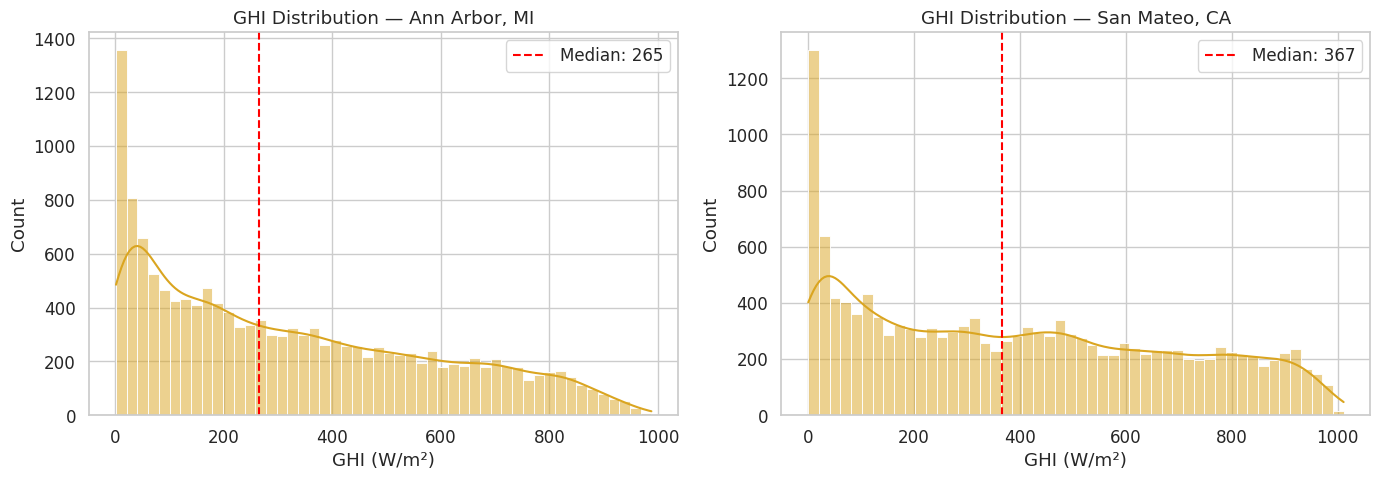

  Chart 1: GHI distribution by location


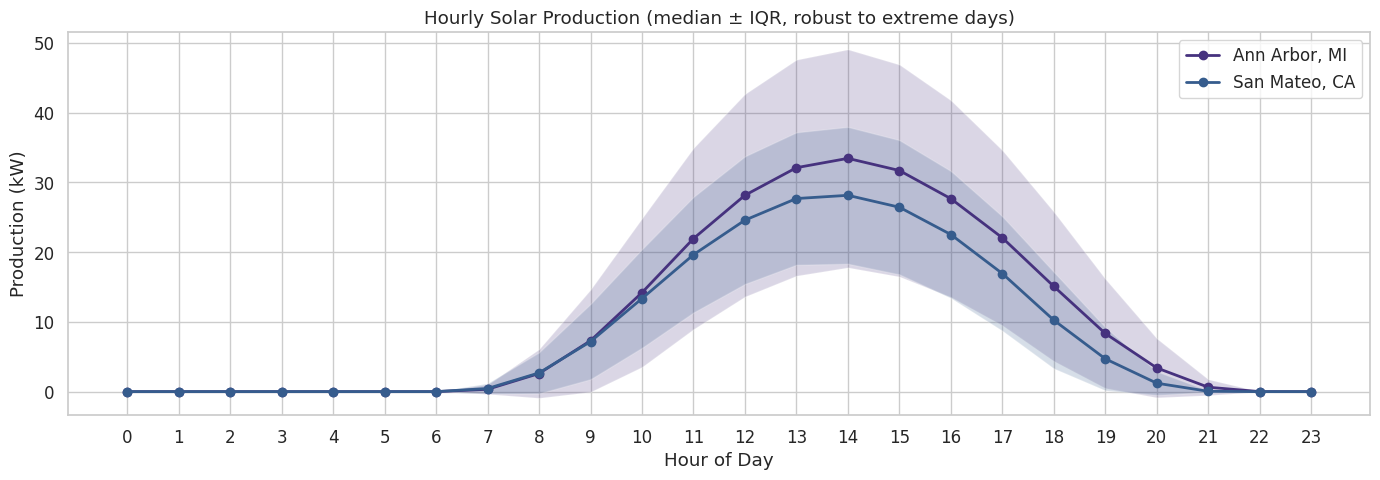

  Chart 2: Hourly production profile


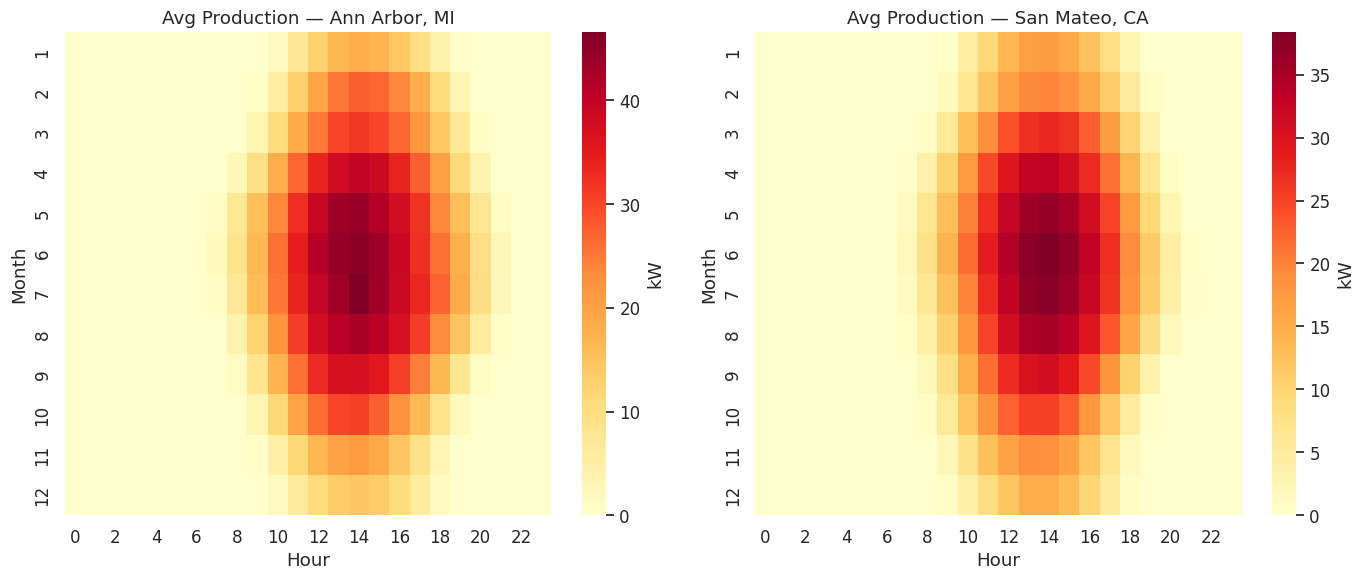

  Chart 3: Seasonal production heatmap


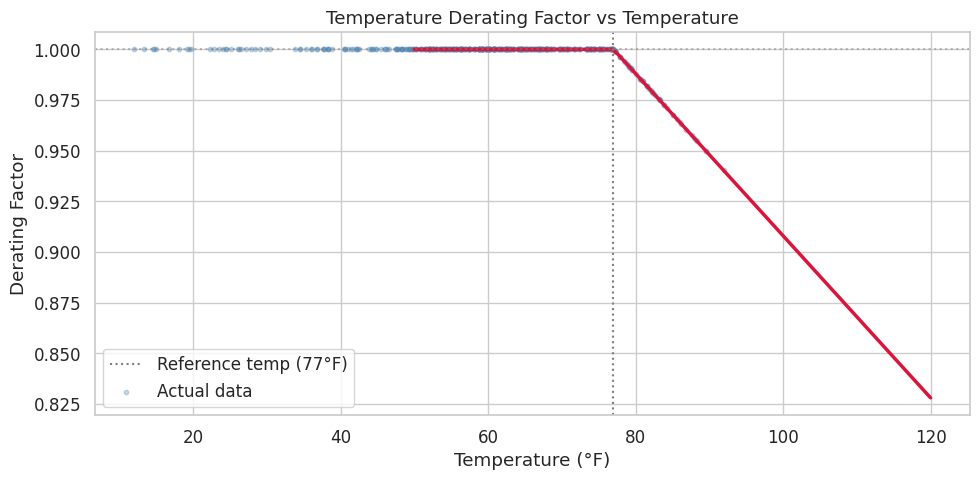

  Chart 4: Temperature derating curve


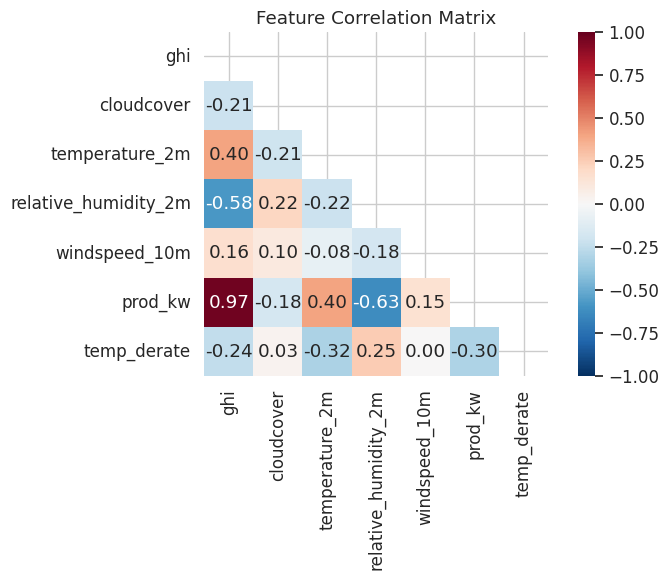

  Chart 5: Correlation heatmap


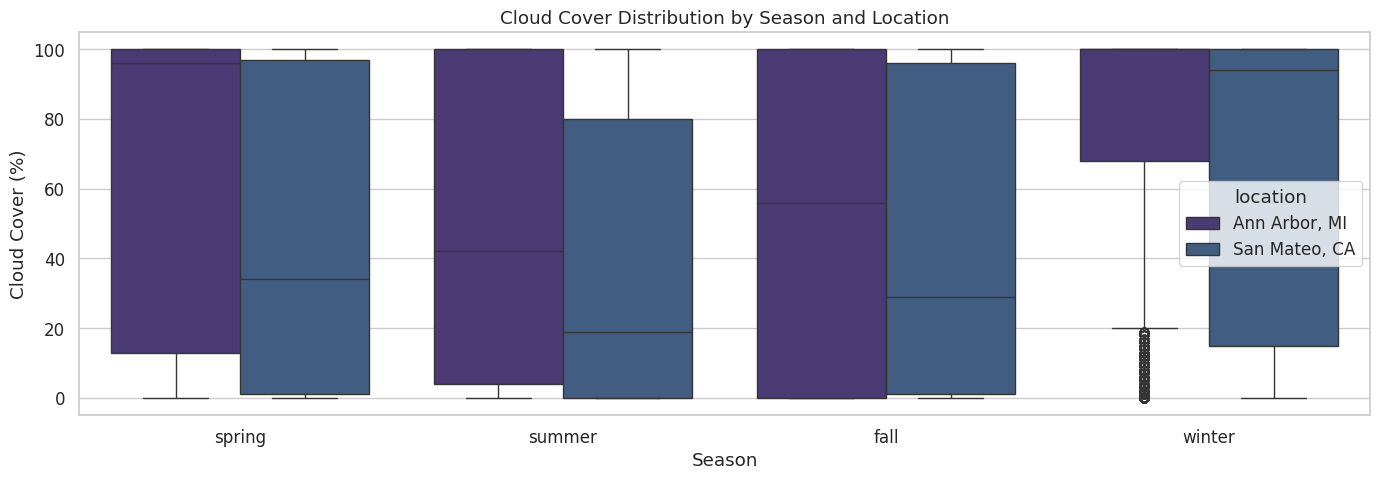

  Chart 6: Cloud cover by season


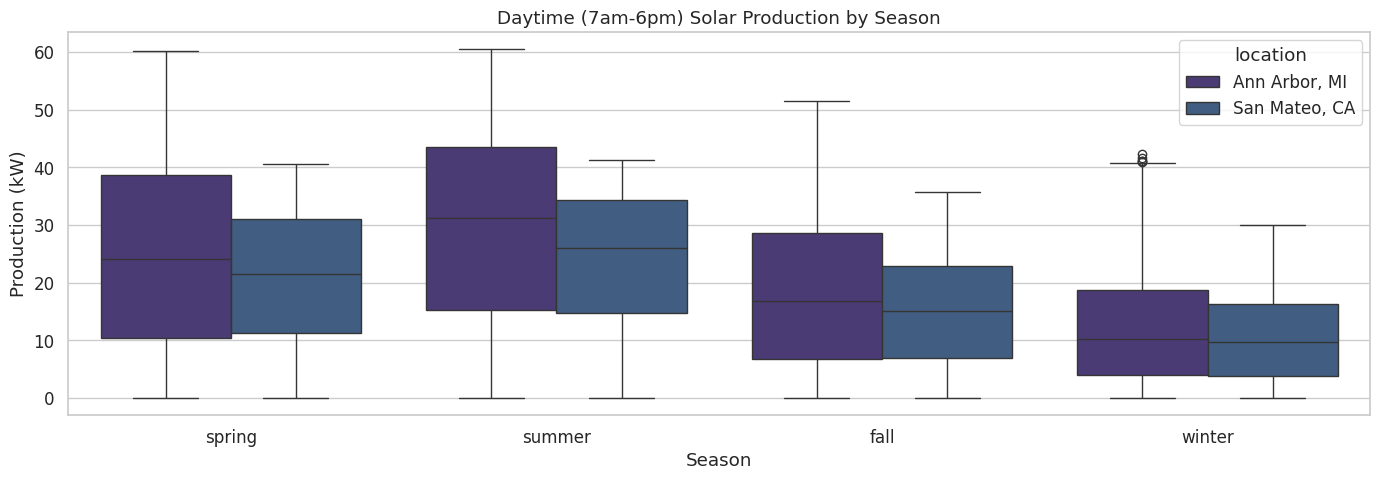

  Chart 7: Production by season


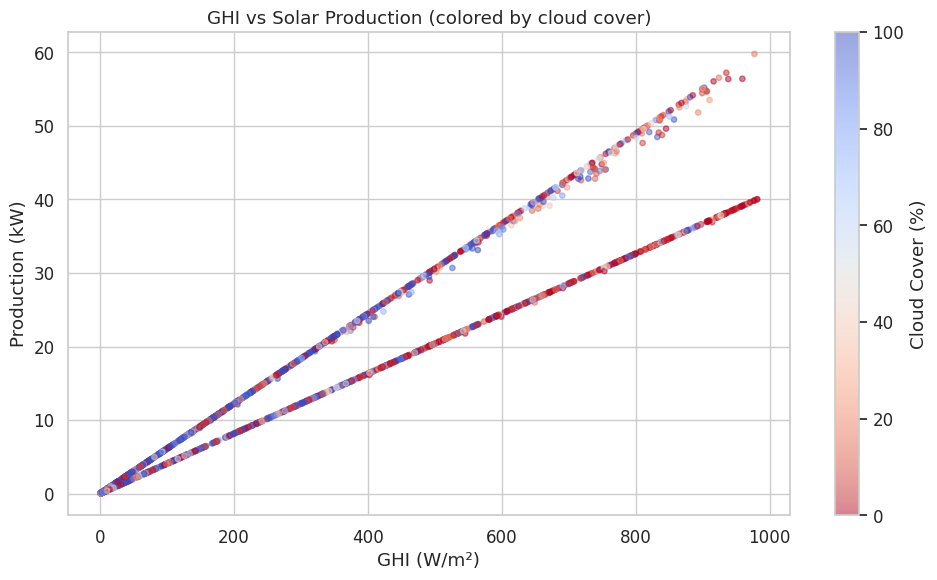

  Chart 8: GHI vs production scatter


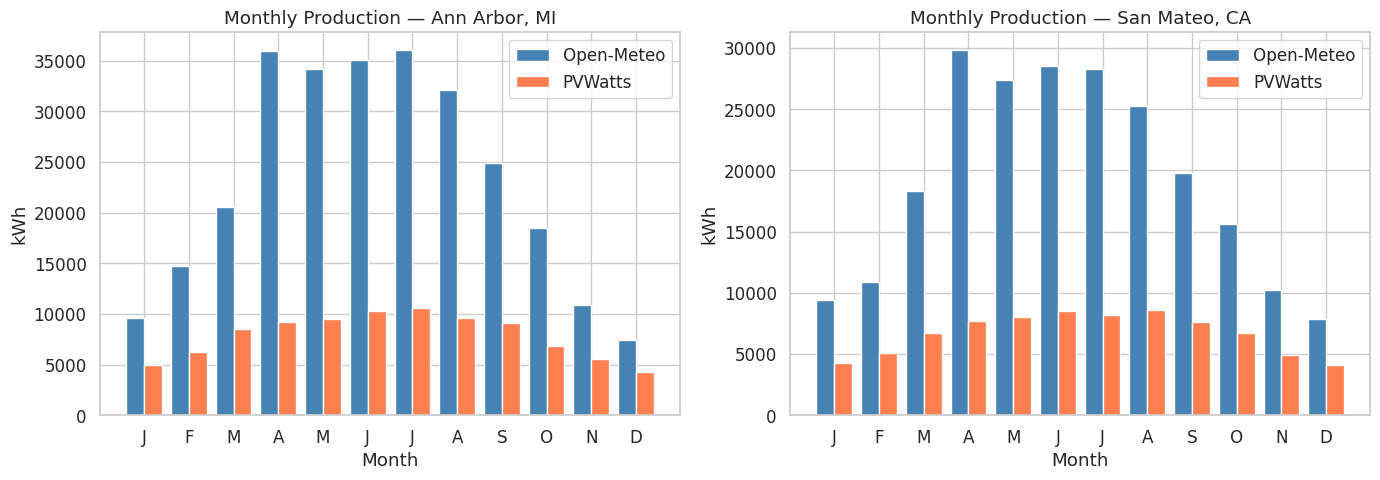

  Chart 9: Monthly Open-Meteo vs PVWatts comparison


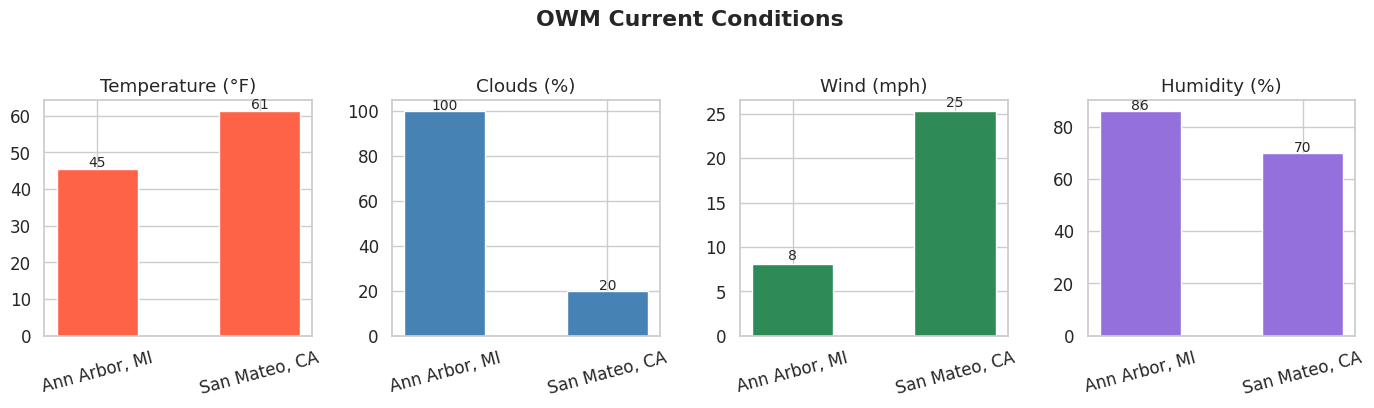

  Chart 10: OWM current conditions


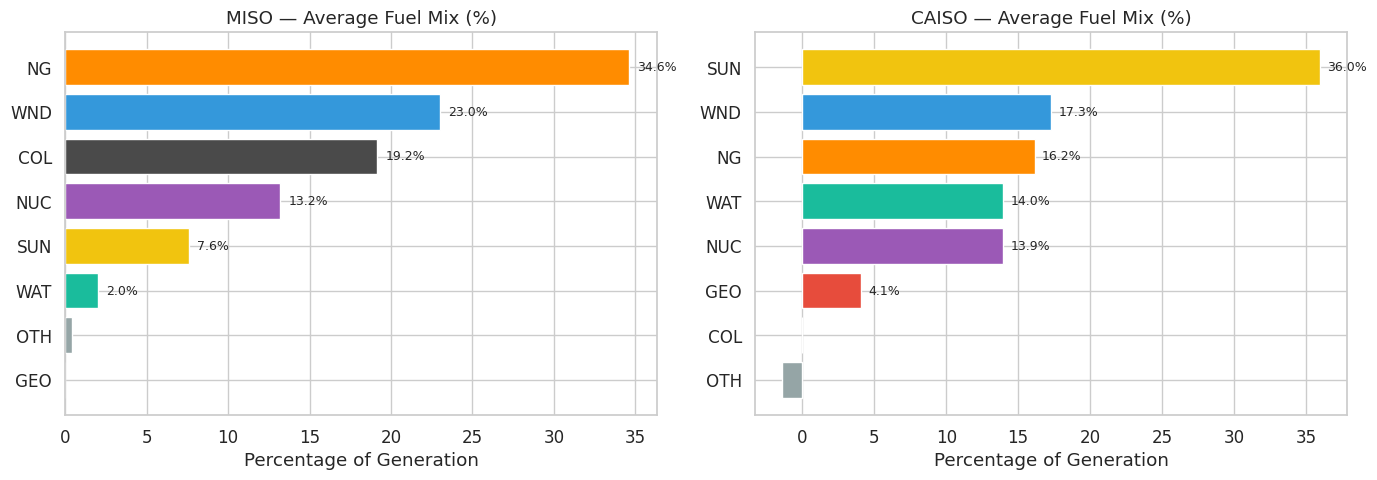

  Chart 11: EIA grid mix by region


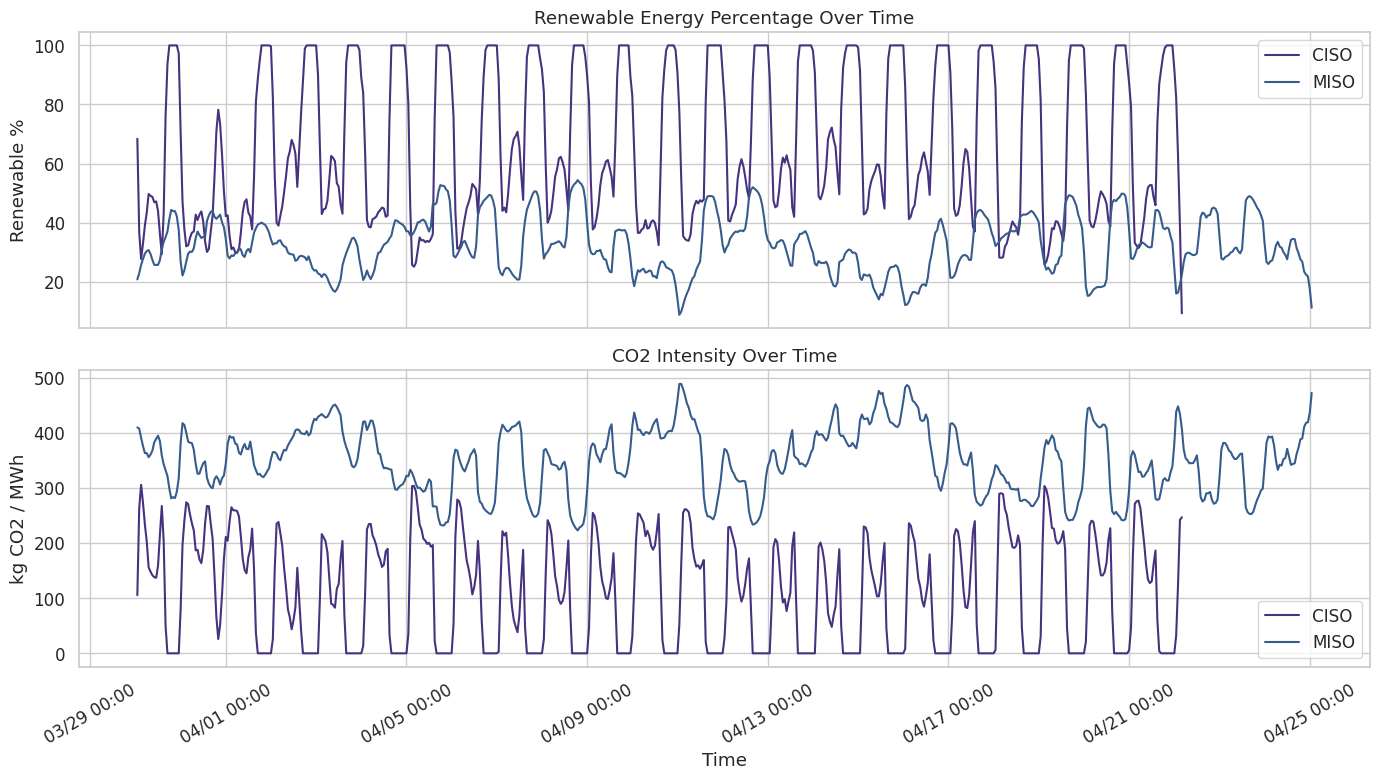

  Chart 12: CO2 intensity & renewable % time series


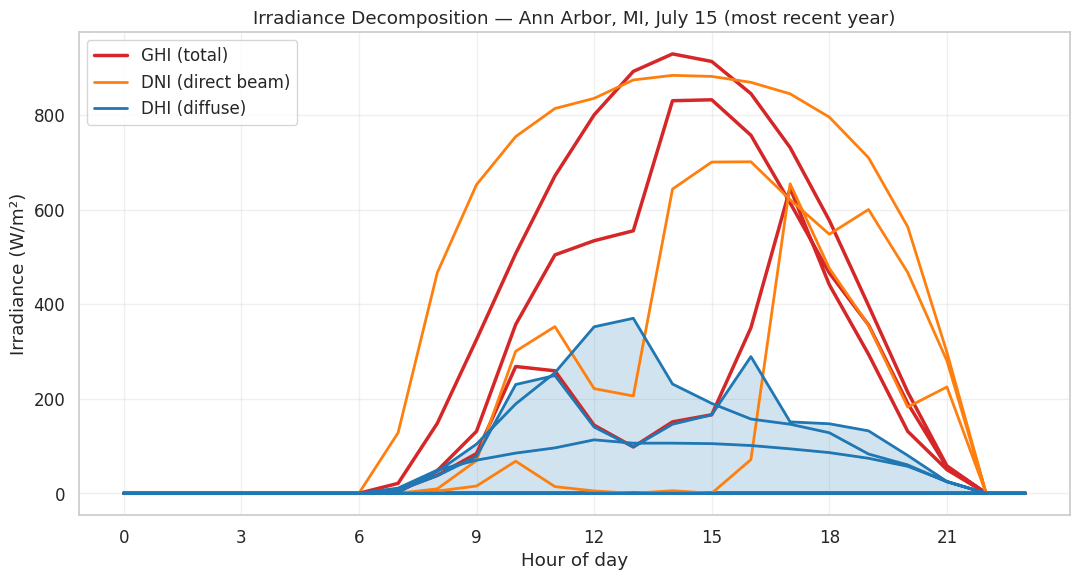

  Chart 13: Irradiance triple (GHI / DNI / DHI)


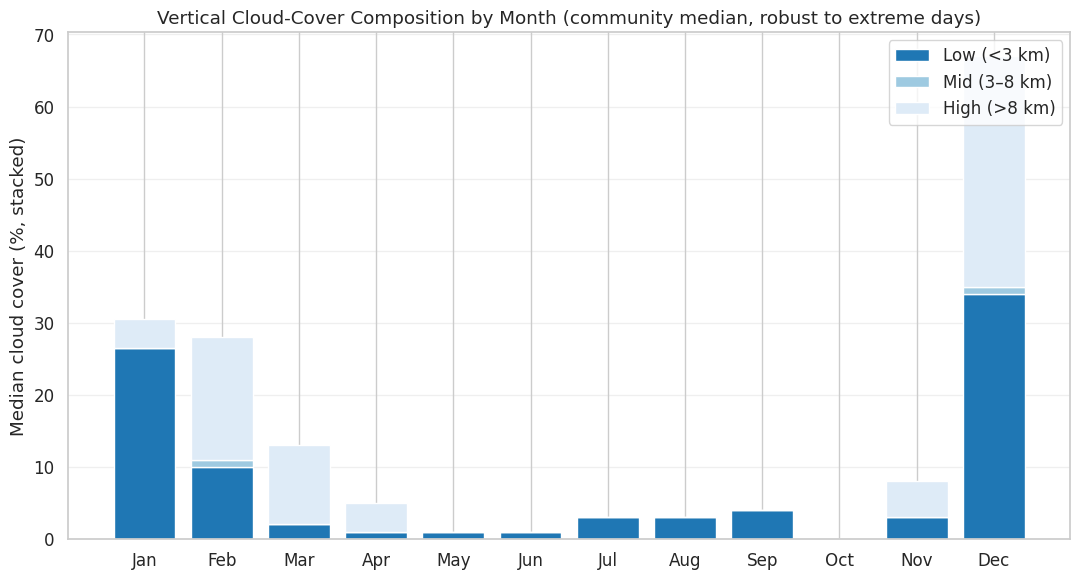

  Chart 14: Vertical cloud-cover stack by month

✅ Cell 6b complete — all visualizations rendered
   Charts saved as chart_01–14_*.png in working directory


In [9]:
# === CELL 6b: Visualizations =================================================
# Full matplotlib/seaborn chart suite — pre-installed on Colab.
# 12 charts covering all DataFrames: distributions, time series, correlations.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.1)
_FIG_W, _FIG_H = 14, 5  # default figure size

# ── Chart 1: GHI Distribution by Location (histogram + KDE) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(_FIG_W, _FIG_H))
for ax, loc_name in zip(axes, LOCATIONS.keys()):
    _loc = df_meteo[(df_meteo["location"] == loc_name) & (df_meteo["ghi"] > 0)]
    sns.histplot(_loc["ghi"], bins=50, kde=True, ax=ax, color="goldenrod")
    ax.set_title(f"GHI Distribution — {loc_name}")
    ax.set_xlabel("GHI (W/m²)")
    ax.set_ylabel("Count")
    ax.axvline(_loc["ghi"].median(), color="red", ls="--", label=f"Median: {_loc['ghi'].median():.0f}")
    ax.legend()
plt.tight_layout()
plt.savefig("chart_01_ghi_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart 1: GHI distribution by location")

# ── Chart 2: Hourly Production Profile (mean ± std by hour) ──────────────────
fig, ax = plt.subplots(figsize=(_FIG_W, _FIG_H))
for loc_name in LOCATIONS:
    _loc = df_meteo[df_meteo["location"] == loc_name]
    _hourly = _loc.groupby("hour")["prod_kw"].agg(["mean", "std"])
    ax.plot(_hourly.index, _hourly["mean"], marker="o", label=loc_name, linewidth=2)
    ax.fill_between(_hourly.index, _hourly["mean"] - _hourly["std"],
                     _hourly["mean"] + _hourly["std"], alpha=0.2)
ax.set_title("Hourly Solar Production (median ± IQR, robust to extreme days)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Production (kW)")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig("chart_02_hourly_production.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart 2: Hourly production profile")

# ── Chart 3: Seasonal Heatmap (month × hour, avg production) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(_FIG_W, 6))
for ax, loc_name in zip(axes, LOCATIONS.keys()):
    _loc = df_meteo[df_meteo["location"] == loc_name]
    _pivot = _loc.pivot_table(index="month", columns="hour", values="prod_kw", aggfunc="mean")
    sns.heatmap(_pivot, ax=ax, cmap="YlOrRd", cbar_kws={"label": "kW"})
    ax.set_title(f"Avg Production — {loc_name}")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Month")
plt.tight_layout()
plt.savefig("chart_03_seasonal_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart 3: Seasonal production heatmap")

# ── Chart 4: Temperature Derating Curve ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, _FIG_H))
_temps = np.linspace(50, 120, 100)
_derates = [max(0.75, 1.0 - 0.004 * max(0, t - 77)) for t in _temps]
ax.plot(_temps, _derates, color="crimson", linewidth=2.5)
ax.axvline(77, color="gray", ls=":", label="Reference temp (77°F)")
ax.axhline(1.0, color="gray", ls=":", alpha=0.5)
# Scatter actual data (sample)
_sample = df_meteo[df_meteo["ghi"] > 100].sample(n=min(500, len(df_meteo)), random_state=42)
ax.scatter(_sample["temp_f"], _sample["temp_derate"], alpha=0.3, s=10, color="steelblue", label="Actual data")
ax.set_title("Temperature Derating Factor vs Temperature")
ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Derating Factor")
ax.legend()
plt.tight_layout()
plt.savefig("chart_04_temp_derating.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart 4: Temperature derating curve")

# ── Chart 5: Correlation Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
_corr_cols = ["ghi", "cloudcover", "temperature_2m", "relative_humidity_2m", "windspeed_10m", "prod_kw", "temp_derate"]
_corr = df_meteo[_corr_cols].corr()
mask = np.triu(np.ones_like(_corr, dtype=bool))
sns.heatmap(_corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("chart_05_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart 5: Correlation heatmap")

# ── Chart 6: Cloud Cover Distribution by Season ─────────────────────────────
fig, ax = plt.subplots(figsize=(_FIG_W, _FIG_H))
_season_order = ["spring", "summer", "fall", "winter"]
sns.boxplot(data=df_meteo, x="season", y="cloudcover", hue="location",
            order=_season_order, ax=ax)
ax.set_title("Cloud Cover Distribution by Season and Location")
ax.set_xlabel("Season")
ax.set_ylabel("Cloud Cover (%)")
plt.tight_layout()
plt.savefig("chart_06_cloud_by_season.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart 6: Cloud cover by season")

# ── Chart 7: Production Box Plots by Season ──────────────────────────────────
fig, ax = plt.subplots(figsize=(_FIG_W, _FIG_H))
_daytime = df_meteo[(df_meteo["hour"] >= 7) & (df_meteo["hour"] <= 18) & (df_meteo["ghi"] > 0)]
sns.boxplot(data=_daytime, x="season", y="prod_kw", hue="location",
            order=_season_order, ax=ax)
ax.set_title("Daytime (7am-6pm) Solar Production by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Production (kW)")
plt.tight_layout()
plt.savefig("chart_07_production_by_season.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart 7: Production by season")

# ── Chart 8: GHI vs Production Scatter (colored by cloud cover) ──────────────
fig, ax = plt.subplots(figsize=(10, 6))
_day_sample = df_meteo[df_meteo["ghi"] > 0].sample(n=min(2000, len(df_meteo)), random_state=42)
scatter = ax.scatter(_day_sample["ghi"], _day_sample["prod_kw"],
                     c=_day_sample["cloudcover"], cmap="coolwarm_r", alpha=0.5, s=15)
plt.colorbar(scatter, label="Cloud Cover (%)")
ax.set_title("GHI vs Solar Production (colored by cloud cover)")
ax.set_xlabel("GHI (W/m²)")
ax.set_ylabel("Production (kW)")
plt.tight_layout()
plt.savefig("chart_08_ghi_vs_production.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart 8: GHI vs production scatter")

# ── Chart 9: Monthly Production Comparison (Open-Meteo vs PVWatts) ───────────
if not df_pvwatts_monthly.empty:
    fig, axes = plt.subplots(1, 2, figsize=(_FIG_W, _FIG_H))
    for ax, loc_name in zip(axes, LOCATIONS.keys()):
        _loc_meteo = df_meteo[df_meteo["location"] == loc_name]
        _om_monthly = _loc_meteo.groupby("month")["prod_kw"].sum()
        _loc_pvw = df_pvwatts_monthly[df_pvwatts_monthly["location"] == loc_name]
        months = range(1, 13)
        _om_vals = [_om_monthly.get(m, 0) for m in months]
        _pv_vals = [_loc_pvw[_loc_pvw["month"] == m]["ac_monthly_kwh"].values[0]
                    if len(_loc_pvw[_loc_pvw["month"] == m]) > 0 else 0 for m in months]
        x = np.arange(12)
        ax.bar(x - 0.2, _om_vals, 0.4, label="Open-Meteo", color="steelblue")
        ax.bar(x + 0.2, _pv_vals, 0.4, label="PVWatts", color="coral")
        ax.set_title(f"Monthly Production — {loc_name}")
        ax.set_xlabel("Month")
        ax.set_ylabel("kWh")
        ax.set_xticks(x)
        ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
        ax.legend()
    plt.tight_layout()
    plt.savefig("chart_09_monthly_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Chart 9: Monthly Open-Meteo vs PVWatts comparison")

# ── Chart 10: OWM Current Conditions Snapshot ─────────────────────────────────
if len(df_owm) > 0:
    fig, axes = plt.subplots(1, 4, figsize=(_FIG_W, 4))
    _metrics = [("temp_f", "Temperature (°F)", "tomato"),
                ("clouds_pct", "Clouds (%)", "steelblue"),
                ("wind_mph", "Wind (mph)", "seagreen"),
                ("humidity_pct", "Humidity (%)", "mediumpurple")]
    for ax, (col, title, color) in zip(axes, _metrics):
        ax.bar(df_owm["location"], df_owm[col], color=color, width=0.5)
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=15)
        for i, v in enumerate(df_owm[col]):
            ax.text(i, v + 0.5, f"{v:.0f}", ha="center", fontsize=10)
    plt.suptitle("OWM Current Conditions", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("chart_10_owm_current.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Chart 10: OWM current conditions")

# ── Chart 11: EIA Grid Mix (stacked bar by region) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(_FIG_W, _FIG_H))
_fuel_colors = {"COL": "#4a4a4a", "NG": "#ff8c00", "NUC": "#9b59b6", "PET": "#8b4513",
                "SUN": "#f1c40f", "WND": "#3498db", "WAT": "#1abc9c", "OTH": "#95a5a6", "GEO": "#e74c3c"}
def _render_fallback_grid(ax, region):
    """Render fallback grid mix chart for a region."""
    fb = _FALLBACK_GRID[region]
    _fuels = {k: v for k, v in fb.items() if k.endswith("_pct")}
    labels = [k.replace("_pct", "").upper() for k in _fuels]
    values = list(_fuels.values())
    colors = [_fuel_colors.get(l[:3], "#cccccc") for l in labels]
    ax.barh(labels, values, color=colors)
    ax.set_title(f"{region} — Grid Mix (%) [Fallback Data]")
    ax.set_xlabel("Percentage")
    for i, v in enumerate(values):
        ax.text(v + 0.3, i, f"{v:.0f}%", va="center", fontsize=9)

for ax, region in zip(axes, ["MISO", "CAISO"]):
    if _eia_available and not df_eia_mix.empty:
        _rmix = df_eia_mix[df_eia_mix["respondent"] == region]
        if len(_rmix) == 0:
            # Try alternate respondent code (CISO for CAISO)
            _alt = {"CAISO": "CISO", "CISO": "CAISO"}
            _rmix = df_eia_mix[df_eia_mix["respondent"] == _alt.get(region, "")]
        if len(_rmix) > 0:
            fuel_cols = [c for c in _rmix.columns if c in _CO2_FACTORS]
            _avg = _rmix[fuel_cols].mean()
            _total = _avg.sum()
            _pcts = (_avg / _total * 100).sort_values(ascending=True)
            colors = [_fuel_colors.get(f, "#cccccc") for f in _pcts.index]
            ax.barh(_pcts.index, _pcts.values, color=colors)
            ax.set_title(f"{region} — Average Fuel Mix (%)")
            ax.set_xlabel("Percentage of Generation")
            for i, (fuel, pct) in enumerate(_pcts.items()):
                if pct > 2:
                    ax.text(pct + 0.5, i, f"{pct:.1f}%", va="center", fontsize=9)
        else:
            _render_fallback_grid(ax, region)
    else:
        _render_fallback_grid(ax, region)
plt.tight_layout()
plt.savefig("chart_11_grid_mix.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart 11: EIA grid mix by region")

# ── Chart 12: CO2 Intensity & Renewable % Time Series ────────────────────────
if _eia_available and not df_eia_mix.empty and "period" in df_eia_mix.columns:
    fig, axes = plt.subplots(2, 1, figsize=(_FIG_W, 8), sharex=True)
    for region in df_eia_mix["respondent"].unique():
        _rmix = df_eia_mix[df_eia_mix["respondent"] == region].copy()
        _rmix["period_dt"] = pd.to_datetime(_rmix["period"], errors="coerce")
        _rmix = _rmix.dropna(subset=["period_dt"]).sort_values("period_dt")
        if len(_rmix) == 0:
            continue
        axes[0].plot(_rmix["period_dt"], _rmix["renewable_pct"], label=region, linewidth=1.5)
        axes[1].plot(_rmix["period_dt"], _rmix["co2_intensity"], label=region, linewidth=1.5)
    axes[0].set_title("Renewable Energy Percentage Over Time")
    axes[0].set_ylabel("Renewable %")
    axes[0].legend()
    axes[1].set_title("CO2 Intensity Over Time")
    axes[1].set_ylabel("kg CO2 / MWh")
    axes[1].set_xlabel("Time")
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("chart_12_co2_renewable_ts.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Chart 12: CO2 intensity & renewable % time series")

# ─── Chart 13: Irradiance triple — GHI / DNI / DHI overlay (sample summer day) ─
# Decomposes total irradiance into direct vs diffuse components on a clear
# summer day. Shows the model trains on physically-decomposed solar
# radiation, not just total GHI.
if all(c in df_meteo.columns for c in ("direct_normal_irradiance", "diffuse_radiation")):
    fig, ax = plt.subplots(figsize=(11, 6))
    _sample_loc = df_meteo["location"].unique()[0]
    _sample_day = df_meteo[
        (df_meteo["location"] == _sample_loc)
        & (df_meteo["time"].dt.month == 7)
        & (df_meteo["time"].dt.day == 15)
    ].copy()
    if len(_sample_day) > 0:
        _hours = _sample_day["time"].dt.hour
        ax.plot(_hours, _sample_day["ghi"], label="GHI (total)", linewidth=2.5, color="#d62728")
        ax.plot(_hours, _sample_day["direct_normal_irradiance"], label="DNI (direct beam)", linewidth=2, color="#ff7f0e")
        ax.plot(_hours, _sample_day["diffuse_radiation"], label="DHI (diffuse)", linewidth=2, color="#1f77b4")
        ax.fill_between(_hours, 0, _sample_day["diffuse_radiation"], alpha=0.2, color="#1f77b4")
        ax.set_xlabel("Hour of day")
        ax.set_ylabel("Irradiance (W/m²)")
        ax.set_title(f"Irradiance Decomposition — {_sample_loc}, July 15 (most recent year)")
        ax.legend(loc="upper left")
        ax.grid(alpha=0.3)
        ax.set_xticks(range(0, 24, 3))
        plt.tight_layout()
        plt.savefig("chart_13_irradiance_triple.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
        print("  Chart 13: Irradiance triple (GHI / DNI / DHI)")

# ─── Chart 14: Vertical cloud-cover stack (low / mid / high by month) ─────────
# Stacked bar showing cloud-layer composition across months. Low stratus
# attenuates GHI more aggressively than high cirrus; this view demonstrates
# the model's exposure to vertical cloud structure across seasons.
if all(c in df_meteo.columns for c in ("cloud_cover_low", "cloud_cover_mid", "cloud_cover_high")):
    fig, ax = plt.subplots(figsize=(11, 6))
    _by_month = df_meteo.groupby(df_meteo["time"].dt.month)[
        ["cloud_cover_low", "cloud_cover_mid", "cloud_cover_high"]
    ].median()
    _months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    ax.bar(_months, _by_month["cloud_cover_low"], label="Low (<3 km)", color="#1f77b4")
    ax.bar(_months, _by_month["cloud_cover_mid"], bottom=_by_month["cloud_cover_low"],
           label="Mid (3–8 km)", color="#9ecae1")
    ax.bar(_months, _by_month["cloud_cover_high"],
           bottom=_by_month["cloud_cover_low"] + _by_month["cloud_cover_mid"],
           label="High (>8 km)", color="#deebf7")
    ax.set_ylabel("Median cloud cover (%, stacked)")
    ax.set_title("Vertical Cloud-Cover Composition by Month (community median, robust to extreme days)")
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("chart_14_cloud_cover_stack.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("  Chart 14: Vertical cloud-cover stack by month")

print("\n✅ Cell 6b complete — all visualizations rendered")
print("   Charts saved as chart_01–14_*.png in working directory")

## 7: Synthetic Example Generation

In [10]:
# === CELL 7: Synthetic Example Generation (~520 examples) ====================
# Stratified sampling from DataFrames → data-grounded Q&A pairs.
# random.seed(42) for reproducibility.

random.seed(42)
np.random.seed(42)

# System prompts repeated twice — see Leviathan et al. (2024), "Repeat to Improve
# Non-Reasoning LLMs", Google Research. https://arxiv.org/abs/2512.14982
SYS = (
    "You are SolarHive, an AI energy advisor for a community solar microgrid.\n\n"
    "You are SolarHive, an AI energy advisor for a community solar microgrid."
)

# Rich system prompt for tool-calling examples (matches inference SYSTEM_PROMPT)
SYS_TOOLS = (
    "You are SolarHive, an AI energy advisor for a community of 12 homes "
    "with rooftop solar and shared battery storage in Ann Arbor, Michigan. "
    "Use the available tools to get real-time data before answering. "
    "Be specific, reference actual data, and keep responses concise (3-5 sentences).\n\n"
    "You are SolarHive, an AI energy advisor for a community of 12 homes "
    "with rooftop solar and shared battery storage in Ann Arbor, Michigan. "
    "Use the available tools to get real-time data before answering. "
    "Be specific, reference actual data, and keep responses concise (3-5 sentences)."
)

# Helper: grid period/rate from hour
def _grid_period(hour):
    if 14 <= hour < 19:
        return "peak", 0.28
    elif (7 <= hour < 14) or (19 <= hour < 23):
        return "mid-peak", 0.18
    else:
        return "off-peak", 0.10

# Helper: sample rows by condition
def _sample_meteo(condition_mask, n, replace=False):
    pool = df_meteo[condition_mask]
    if len(pool) == 0:
        return pd.DataFrame()
    return pool.sample(n=min(n, len(pool)), replace=replace, random_state=42)

# Question phrasing variants (15+ per category to avoid duplication)
_STATUS_PHRASES = [
    "What's our solar production status right now?",
    "How much power are we generating currently?",
    "Give me a quick solar status update.",
    "What's the current output from our panels?",
    "How are the solar panels performing at the moment?",
    "Can you check our current solar generation?",
    "Pull up the real-time solar dashboard.",
    "What does our generation look like right now?",
    "Are the panels producing at capacity?",
    "Quick check — how's our solar array doing?",
    "What's the live production reading?",
    "How many kilowatts are we pushing right now?",
    "Solar status report, please.",
    "Is the array running at full power?",
    "What's our current kilowatt output?",
    "Show me today's solar performance so far.",
]

_APPLIANCE_PHRASES = [
    "Should I run the dishwasher now or wait?",
    "Is it a good time to do laundry?",
    "Can I charge my EV now without wasting solar?",
    "Should I hold off on running the dryer?",
    "Is now a good time to run high-power appliances?",
    "When should I schedule my pool pump today?",
    "I want to run the washing machine — is solar available?",
    "Can I bake without pulling from the grid?",
    "Is there enough solar to run the AC at full blast?",
    "Good time to charge the electric mower?",
    "Should I start the hot water heater now?",
    "Can the community handle my EV charger right now?",
    "When's the cheapest time to run appliances today?",
    "I need to vacuum — should I wait for more sun?",
    "Is the oven okay to use or will we draw from grid?",
    "Best window today for high-power appliance use?",
]

_COMPARE_PHRASES = [
    "How does today compare to yesterday's solar output?",
    "Are we doing better or worse than usual for this time of year?",
    "How does this month's production stack up against last month?",
    "Is our solar generation above or below the seasonal average?",
    "Compare current output to our historical average.",
    "What's our production trend this week?",
    "Are we tracking above or below our monthly target?",
    "How does today's GHI compare to the seasonal norm?",
    "Is this a high-production or low-production day?",
    "Where do we stand relative to last year's numbers?",
    "Are conditions better or worse than the 30-day average?",
    "Rate today's solar performance on a scale.",
    "How are we trending compared to typical spring/summer/fall/winter output?",
    "Is this week above or below our capacity factor benchmark?",
    "How does current efficiency compare to our system's rated performance?",
]

_BATTERY_PHRASES = [
    "What's the best battery strategy right now?",
    "Should we charge or discharge the battery?",
    "How should we manage the battery given current conditions?",
    "What's the optimal battery action for this situation?",
    "Give me a battery management recommendation.",
    "Battery decision time — what do you suggest?",
    "Should the battery be absorbing or releasing energy?",
    "What's the smart move for our battery right now?",
    "How full should we keep the battery at this hour?",
    "Is it worth charging the battery from the grid right now?",
    "Battery strategy check — hold, charge, or export?",
    "What SOC target should we aim for by tonight?",
    "Should we reserve battery for the evening peak?",
    "Is the battery better used now or saved for later?",
    "What's the best use of our stored energy right now?",
]

_GRID_PHRASES = [
    "What's the current grid situation?",
    "Should we export to the grid or store energy?",
    "How does the grid rate affect our strategy right now?",
    "What's the economic case for grid export vs battery storage?",
    "Are we in peak, mid-peak, or off-peak pricing?",
    "What's our grid import/export balance?",
    "Is the grid rate high enough to justify selling power?",
    "How dirty is the grid right now — should we avoid importing?",
    "What rate are we paying for grid electricity this hour?",
    "Should we island from the grid or stay connected?",
    "Grid economics update — are we buying or selling?",
    "Is it cheaper to use battery or grid power right now?",
    "What's the current net metering value?",
    "How much are we saving by not pulling from the grid?",
    "Grid rate forecast — what should we prepare for?",
]

EXAMPLES = []

# ---------- Category A: Hourly Production (~200 examples) --------------------
print("  Generating Category A: Hourly Production...")

# Condition-specific question phrases to boost diversity
_CLEAR_SKY_PHRASES = [
    "How are the panels doing in this beautiful weather?",
    "Looks sunny out — what's our solar output?",
    "Clear skies! Are we maxing out production?",
    "Perfect solar day — what are the numbers?",
    "Sun's out in full force. What's the dashboard say?",
    "No clouds — how much are we generating?",
    "Blue sky conditions — give me the production stats.",
    "It's a gorgeous day. How's solar performing?",
    "Sunshine report — are we at peak output?",
    "How efficiently are the panels converting in this sun?",
    "Maximum solar conditions — what's our actual kW?",
    "We should be crushing it today. What's the output?",
    "Any reason we're not at full capacity on a clear day?",
    "How close to rated power are we right now?",
    "Sunny and warm — is that helping or hurting output?",
    "Is this a good day to charge up the battery?",
    "Clear sky performance check — how's the array?",
    "Give me the clear-sky production breakdown.",
    "What efficiency are we hitting in these conditions?",
    "Ideal weather — what's our generation ceiling today?",
]

_CLOUDY_PHRASES = [
    "It's overcast — how badly is production hit?",
    "Clouds moved in. What's the damage to our solar?",
    "Not much sun today — what are we still generating?",
    "How much are we losing to cloud cover?",
    "Gloomy day. Should we even bother with solar loads?",
    "Clouds are thick — is the battery keeping up?",
    "Overcast conditions — should I defer heavy appliances?",
    "Cloud cover report — how's our output impacted?",
    "What happens to production with this cloud layer?",
    "Gray skies — give me the solar reality check.",
    "Can we still run appliances on a cloudy day like this?",
    "How much diffuse radiation are we capturing in these clouds?",
    "Are the panels still worth anything under this overcast?",
    "Cloud impact assessment — what's the production cut?",
    "Partly cloudy turning overcast — what should I expect?",
    "Solar viability check for these cloudy conditions?",
    "Is it better to use grid or battery right now?",
    "Heavy clouds — should we switch to grid power?",
    "What percentage of capacity are we hitting under these clouds?",
    "Cloudy day strategy — where do we stand?",
]

_NIGHT_PHRASES = [
    "It's dark out. What's happening with our power?",
    "No sun — where's our electricity coming from?",
    "Nighttime power status?",
    "After-hours energy report — what are we drawing from?",
    "Sun's down. What's our grid and battery situation?",
    "Late night — how's the energy balance?",
    "Midnight check — are we on battery or grid?",
    "No solar at this hour. What's the cost of grid power?",
    "How much battery do we have left tonight?",
    "Pre-dawn energy status update?",
]

# A1: Clear sky status reports (~40)
_clear = _sample_meteo((df_meteo["ghi"] > 600) & (df_meteo["cloudcover"] < 20), 120)
_a1_templates = [
    lambda r, eff: (f"Clear skies in {r['location']} — panels are performing well. Current GHI is {r['ghi']:.0f} W/m² "
         f"with {r['cloudcover']:.0f}% cloud cover. At {r['temp_f']:.0f}°F (temperature derating: "
         f"{r['temp_derate']:.0%}), we're producing {r['prod_kw']:.1f} kW out of {r['capacity_kw']} kW capacity ({eff:.0f}% efficiency). "
         f"This is excellent output — a great time to run heavy loads or charge the battery."),
    lambda r, eff: (f"Solar is strong in {r['location']}. GHI reading: {r['ghi']:.0f} W/m², clouds at just "
         f"{r['cloudcover']:.0f}%. We're generating {r['prod_kw']:.1f} kW ({eff:.0f}% of {r['capacity_kw']} kW capacity). "
         f"Temperature is {r['temp_f']:.0f}°F with a derating factor of {r['temp_derate']:.3f}. "
         f"Ideal conditions — consider charging the battery or running energy-intensive appliances."),
    lambda r, eff: (f"Excellent solar conditions in {r['location']}! With {r['ghi']:.0f} W/m² irradiance and minimal "
         f"cloud cover ({r['cloudcover']:.0f}%), the array is pushing {r['prod_kw']:.1f} kW — that's "
         f"{eff:.0f}% efficiency. At {r['temp_f']:.0f}°F, thermal derating is {(1-r['temp_derate'])*100:.1f}%. "
         f"Take advantage of this window for heavy loads."),
    lambda r, eff: (f"Status for {r['location']}: {r['prod_kw']:.1f} kW output under clear skies ({r['cloudcover']:.0f}% clouds). "
         f"GHI is {r['ghi']:.0f} W/m² and we're hitting {eff:.0f}% of our {r['capacity_kw']} kW rated capacity. "
         f"Panel temp effect: {r['temp_derate']:.0%} efficiency at {r['temp_f']:.0f}°F. Battery charging and "
         f"appliance use are both recommended now."),
    lambda r, eff: (f"Peak performance in {r['location']}: {r['prod_kw']:.1f} kW from {r['capacity_kw']} kW array ({eff:.0f}% efficiency). "
         f"GHI at {r['ghi']:.0f} W/m², cloud cover just {r['cloudcover']:.0f}%. "
         f"At {r['temp_f']:.0f}°F, thermal factor is {r['temp_derate']:.3f}. "
         f"This is one of our best production windows — queue up laundry, EV charging, and battery top-up."),
    lambda r, eff: (f"Array report for {r['location']}: producing {r['prod_kw']:.1f}/{r['capacity_kw']} kW under clear conditions. "
         f"Irradiance: {r['ghi']:.0f} W/m². Clouds: {r['cloudcover']:.0f}%. Temp: {r['temp_f']:.0f}°F (derating: {(1-r['temp_derate'])*100:.1f}%). "
         f"Efficiency: {eff:.0f}%. Strong output — maximize self-consumption and charge the community battery."),
]
for i, (_, row) in enumerate(_clear.iterrows()):
    q = random.choice(_CLEAR_SKY_PHRASES) if random.random() < 0.6 else random.choice(_STATUS_PHRASES)
    eff = row["prod_kw"] / row["capacity_kw"] * 100 if row["capacity_kw"] > 0 else 0
    a = _a1_templates[i % len(_a1_templates)](row, eff)
    EXAMPLES.append((SYS, q, a))

# A2: Cloudy day status (~40)
_cloudy = _sample_meteo((df_meteo["cloudcover"] > 70) & (df_meteo["ghi"] > 50), 120)
_a2_templates = [
    lambda r: (f"Heavy cloud cover in {r['location']} at {r['cloudcover']:.0f}%. GHI is only {r['ghi']:.0f} W/m², "
         f"so production is {r['prod_kw']:.1f} kW out of {r['capacity_kw']} kW capacity. "
         f"Consider deferring large loads until conditions improve. "
         f"The battery should be conserved for essential evening needs."),
    lambda r: (f"Overcast in {r['location']} — {r['cloudcover']:.0f}% cloud cover is limiting our output. "
         f"Solar irradiance at {r['ghi']:.0f} W/m² yields just {r['prod_kw']:.1f} kW from our "
         f"{r['capacity_kw']} kW system. Prioritize essential loads and keep the battery in reserve."),
    lambda r: (f"Cloud-impacted production in {r['location']}: {r['prod_kw']:.1f} kW with {r['cloudcover']:.0f}% "
         f"overcast skies. GHI is {r['ghi']:.0f} W/m² — well below clear-sky potential. "
         f"Hold off on heavy appliances. Battery reserves should be preserved for peak-rate hours."),
    lambda r: (f"Low output conditions in {r['location']}. At {r['cloudcover']:.0f}% clouds, GHI drops to "
         f"{r['ghi']:.0f} W/m² and we're only getting {r['prod_kw']:.1f} kW ({r['prod_kw']/r['capacity_kw']*100:.0f}% "
         f"of capacity). Defer non-urgent loads and let the battery coast until solar improves."),
]
for i, (_, row) in enumerate(_cloudy.iterrows()):
    q = random.choice(_CLOUDY_PHRASES) if random.random() < 0.6 else random.choice(_STATUS_PHRASES)
    a = _a2_templates[i % len(_a2_templates)](row)
    EXAMPLES.append((SYS, q, a))

# A3: Nighttime status (~20)
_night = _sample_meteo((df_meteo["hour"] < 6) | (df_meteo["hour"] > 20), 80)
_a3_templates = [
    lambda h, loc, rate, period: (f"It's {h}:00 in {loc} — no solar production at this hour. The community "
         f"is running on battery reserves and grid power. Current grid rate is ${rate:.2f}/kWh "
         f"({period}). Minimize non-essential usage to preserve battery capacity for the "
         f"morning ramp period."),
    lambda h, loc, rate, period: (f"Nighttime in {loc} ({h}:00). Panels are idle — all power comes from "
         f"battery and grid ({period} at ${rate:.2f}/kWh). Keep consumption low and "
         f"save battery for the pre-dawn hours when grid rates may shift."),
    lambda h, loc, rate, period: (f"Zero solar at {h}:00, {loc}. Community draws from stored energy "
         f"and the grid at {period} rates (${rate:.2f}/kWh). "
         f"Non-essential loads should wait until morning solar ramp begins around 7-8am."),
]
for i, (_, row) in enumerate(_night.iterrows()):
    q = random.choice(_NIGHT_PHRASES) if random.random() < 0.6 else random.choice(_STATUS_PHRASES)
    hour = row["hour"]
    loc = row["location"]
    period, rate = _grid_period(hour)
    a = _a3_templates[i % len(_a3_templates)](hour, loc, rate, period)
    EXAMPLES.append((SYS, q, a))

# A4: Appliance decisions (~30)
_mixed = _sample_meteo(df_meteo["ghi"] > 0, 120)
for i, (_, row) in enumerate(_mixed.iterrows()):
    q = random.choice(_APPLIANCE_PHRASES)
    prod = row["prod_kw"]
    ghi = row["ghi"]
    hour = row["hour"]
    loc = row["location"]
    period, rate = _grid_period(hour)
    if prod > 30:
        _a4_advices = [
            f"Yes — we have strong solar surplus at {prod:.1f} kW. Running appliances now uses free solar energy instead of grid power.",
            f"Go for it! At {prod:.1f} kW we're well above household demand. {loc} is producing enough to run heavy loads and still charge the battery.",
            f"Absolutely. Solar output is {prod:.1f} kW — that's surplus territory. Run whatever you need; we're generating more than the community can consume.",
        ]
    elif prod > 10:
        _a4_advices = [
            f"Moderate production at {prod:.1f} kW. Running smaller appliances is fine, but save heavy loads for the peak solar window (10am-2pm).",
            f"We're at {prod:.1f} kW — enough for light-to-medium loads. Hold the heavy stuff (EV, dryer) for peak solar hours if possible.",
            f"Partial solar at {prod:.1f} kW in {loc}. A dishwasher or washing machine is fine, but the dryer or EV charger would push us to grid at ${rate:.2f}/kWh ({period}).",
        ]
    else:
        _a4_advices = [
            f"Production is low ({prod:.1f} kW). It's {period} pricing at ${rate:.2f}/kWh. Wait for better solar conditions if you can defer the load.",
            f"Only {prod:.1f} kW right now — most appliances would draw from the grid at ${rate:.2f}/kWh ({period}). Defer if you can, or use battery reserves.",
            f"Low solar ({prod:.1f} kW) in {loc}. Running heavy loads now costs ${rate:.2f}/kWh from the grid. Best to wait until conditions improve.",
        ]
    advice = _a4_advices[i % len(_a4_advices)]
    _a4_templates = [
        f"Current status: {prod:.1f} kW generation, GHI {ghi:.0f} W/m² in {loc}. {advice}",
        f"Right now in {loc}: {prod:.1f} kW output from {ghi:.0f} W/m² GHI ({period} rates). {advice}",
        f"Solar check for {loc} at {hour}:00: {prod:.1f} kW, {ghi:.0f} W/m² irradiance. {advice}",
    ]
    a = _a4_templates[i % len(_a4_templates)]
    EXAMPLES.append((SYS, q, a))

# A5: Seasonal comparisons (~30)
_seasonal_data = df_meteo.groupby(["location", "season"]).agg(
    avg_ghi=("ghi", "mean"), avg_prod=("prod_kw", "mean"), avg_temp=("temp_f", "mean")
).reset_index()
_seasonal_samples = _sample_meteo(df_meteo["ghi"] > 0, 120)
for i, (_, row) in enumerate(_seasonal_samples.iterrows()):
    q = random.choice(_COMPARE_PHRASES)
    loc = row["location"]
    season = row["season"]
    _avg = _seasonal_data[
        (_seasonal_data["location"] == loc) & (_seasonal_data["season"] == season)
    ]
    if len(_avg) > 0:
        avg_ghi = _avg.iloc[0]["avg_ghi"]
        avg_prod = _avg.iloc[0]["avg_prod"]
        diff_pct = (row["ghi"] - avg_ghi) / max(avg_ghi, 1) * 100
        comparison = "above" if diff_pct > 5 else "below" if diff_pct < -5 else "right at"
        _verdict = 'Great performance!' if diff_pct > 5 else 'Conditions will improve.' if diff_pct < -5 else 'Typical conditions.'
        _a5_templates = [
            (f"In {loc}, the {season} average GHI is {avg_ghi:.0f} W/m² with typical "
             f"production of {avg_prod:.1f} kW. Right now we're at {row['ghi']:.0f} W/m² "
             f"({row['prod_kw']:.1f} kW) — that's {comparison} the seasonal norm "
             f"({diff_pct:+.0f}%). {_verdict}"),
            (f"Seasonal comparison for {loc} ({season}): current {row['ghi']:.0f} W/m² vs "
             f"average {avg_ghi:.0f} W/m² ({diff_pct:+.0f}%). Output: {row['prod_kw']:.1f} kW "
             f"vs typical {avg_prod:.1f} kW. {_verdict}"),
            (f"{loc} {season} benchmark: we expect {avg_ghi:.0f} W/m² / {avg_prod:.1f} kW on average. "
             f"Today's reading is {row['ghi']:.0f} W/m² / {row['prod_kw']:.1f} kW — "
             f"{comparison} normal ({diff_pct:+.0f}%). {_verdict}"),
        ]
        a = _a5_templates[i % len(_a5_templates)]
    else:
        a = f"Current production in {loc} is {row['prod_kw']:.1f} kW at {row['ghi']:.0f} W/m² GHI."
    EXAMPLES.append((SYS, q, a))

# A6: Temperature derating focus (~20)
_hot = _sample_meteo(df_meteo["temp_f"] > 90, 80, replace=True)
_a6_q_templates = [
    "It's {temp}°F outside. How is the heat affecting our panels?",
    "Temperature hit {temp}°F in {loc}. What's the thermal impact on solar?",
    "Heat wave at {temp}°F — how much production are we losing?",
    "{temp}°F today in {loc}. Are the panels overheating?",
    "How bad is thermal derating at {temp}°F?",
]
for i, (_, row) in enumerate(_hot.iterrows()):
    q = _a6_q_templates[i % len(_a6_q_templates)].format(temp=f"{row['temp_f']:.0f}", loc=row['location'])
    derate = row["temp_derate"]
    prod = row["prod_kw"]
    cap = row["capacity_kw"]
    loss_pct = (1 - derate) * 100
    _theoretical = cap * row["ghi"] / 1000 * SYSTEM_EFF
    _a6_answers = [
        (f"High temperature alert in {row['location']}. At {row['temp_f']:.0f}°F, panels lose "
         f"approximately {loss_pct:.1f}% efficiency due to thermal derating (factor: {derate:.3f}). "
         f"Current production is {prod:.1f} kW vs theoretical {_theoretical:.1f} kW "
         f"at 77°F. This is normal — silicon panels lose ~0.4% efficiency per degree above 77°F. "
         f"Production will recover as temperatures cool in late afternoon."),
        (f"Thermal derating active in {row['location']}: {row['temp_f']:.0f}°F means a "
         f"{loss_pct:.1f}% efficiency loss (derating factor {derate:.3f}). Output is {prod:.1f} kW — "
         f"at the reference temperature of 77°F, we'd be hitting {_theoretical:.1f} kW. "
         f"Silicon panels shed ~0.4%/°F above 77°F. Expect improvement toward evening as temps drop."),
        (f"At {row['temp_f']:.0f}°F in {row['location']}, thermal derating cuts output by {loss_pct:.1f}%. "
         f"Producing {prod:.1f} kW instead of the {_theoretical:.1f} kW potential at 77°F. "
         f"Derating factor: {derate:.3f}. Wind helps cool panels slightly. "
         f"Late afternoon temps will ease the penalty — production should recover 5-10% by 5pm."),
    ]
    a = _a6_answers[i % len(_a6_answers)]
    EXAMPLES.append((SYS, q, a))

# A7: Dawn/dusk ramp profiles (~20)
_dawn_phrases = [
    "Panels just started producing. What should we expect this morning?",
    "It's early morning — what's the solar ramp-up looking like?",
    "Morning update: when will we hit meaningful production today?",
    "The sun is just coming up. What's the forecast for today's solar?",
    "How's the dawn ramp progressing?",
    "Are the panels waking up? What should we expect?",
    "Early morning solar check — are we generating yet?",
    "What's the sunrise production outlook?",
    "How long until we're at peak solar output?",
    "Morning ramp report, please.",
    "Sun's up — give me the early production status.",
    "What does the morning ramp look like for today?",
    "Should I wait for more solar before running appliances?",
    "How quickly will production ramp up this morning?",
    "First light check — how are the panels doing?",
]
_dawn = _sample_meteo((df_meteo["hour"] >= 6) & (df_meteo["hour"] <= 8) & (df_meteo["ghi"] > 0), 80)
for _, row in _dawn.iterrows():
    q = random.choice(_dawn_phrases)
    prod = row["prod_kw"]
    ghi = row["ghi"]
    clouds = row["cloudcover"]
    loc = row["location"]
    cap = row["capacity_kw"]
    if clouds < 30:
        _dawn_templates = [
            (f"Early morning ramp — currently {prod:.1f} kW ({ghi:.0f} W/m² GHI). "
             f"Clear morning in {loc} with {clouds:.0f}% clouds. "
             f"GHI is ramping at {ghi:.0f} W/m² — expect peak production of "
             f"{cap * 0.7:.0f}–{cap * 0.85:.0f} kW by midday. "
             f"A great day for scheduling heavy loads between 10am and 2pm."),
            (f"Sunrise in {loc}: {prod:.1f} kW and climbing under clear skies ({clouds:.0f}% clouds). "
             f"GHI at {ghi:.0f} W/m², ramping toward a projected peak of "
             f"{cap * 0.7:.0f}–{cap * 0.85:.0f} kW around noon. "
             f"Start charging the battery now; schedule heavy loads for 10am–2pm."),
            (f"Good morning — {loc} is looking clear ({clouds:.0f}% clouds). "
             f"Production at {prod:.1f} kW with {ghi:.0f} W/m² GHI and rising steadily. "
             f"By peak hours we should reach {cap * 0.7:.0f}+ kW. "
             f"Ideal conditions for running appliances on pure solar."),
        ]
    else:
        _dawn_templates = [
            (f"Early morning ramp — currently {prod:.1f} kW ({ghi:.0f} W/m² GHI). "
             f"Partly cloudy start in {loc} ({clouds:.0f}% coverage). "
             f"GHI at {ghi:.0f} W/m² and rising. Production may peak around "
             f"{cap * 0.3:.0f}–{cap * 0.5:.0f} kW with intermittent cloud dips. "
             f"Keep the battery charging to buffer variable output."),
            (f"Cloudy dawn in {loc} — {prod:.1f} kW with {clouds:.0f}% overcast. "
             f"GHI is {ghi:.0f} W/m², expect gradual ramp to "
             f"{cap * 0.3:.0f}–{cap * 0.5:.0f} kW peak. "
             f"Variable conditions ahead — battery will help smooth production dips."),
            (f"Morning ramp under clouds in {loc}: {prod:.1f} kW at {ghi:.0f} W/m² GHI. "
             f"Cloud cover at {clouds:.0f}% means output will be inconsistent. "
             f"Estimated peak: {cap * 0.3:.0f}–{cap * 0.5:.0f} kW. "
             f"Defer heavy loads until conditions improve or use battery as buffer."),
        ]
    a = random.choice(_dawn_templates)
    EXAMPLES.append((SYS, q, a))

print(f"    Category A: {len(EXAMPLES)} examples")
_cat_a_count = len(EXAMPLES)

# ---------- Category B: PVWatts Ground Truth (~80 examples) ------------------
print("  Generating Category B: PVWatts Ground Truth...")

if not df_pvwatts_monthly.empty:
    # B1: Monthly production reports (~24)
    for _, row in df_pvwatts_monthly.iterrows():
        loc = row["location"]
        month_name = datetime(2025, int(row["month"]), 1).strftime("%B")
        ac = row["ac_monthly_kwh"]
        solrad = row["solrad_monthly"]
        q = f"What's the expected solar production for {month_name} in {loc}?"
        a = (f"Based on NREL PVWatts data for {loc}, {month_name} typically produces "
             f"{ac:,.0f} kWh with average solar radiation of {solrad:.2f} kWh/m²/day. "
             f"This accounts for system losses, panel degradation, and local weather patterns. "
             f"The annual total for this system is {row['ac_annual_kwh']:,.0f} kWh.")
        EXAMPLES.append((SYS, q, a))

    # B2: System sizing questions (~16)
    for loc_name, loc in LOCATIONS.items():
        _loc_pvw = df_pvwatts_monthly[df_pvwatts_monthly["location"] == loc_name]
        if len(_loc_pvw) == 0:
            continue
        annual = _loc_pvw["ac_annual_kwh"].iloc[0]
        cap = loc["capacity_kw"]
        best_month = _loc_pvw.loc[_loc_pvw["ac_monthly_kwh"].idxmax()]
        worst_month = _loc_pvw.loc[_loc_pvw["ac_monthly_kwh"].idxmin()]
        best_name = datetime(2025, int(best_month["month"]), 1).strftime("%B")
        worst_name = datetime(2025, int(worst_month["month"]), 1).strftime("%B")

        cf = annual / (cap * 8760) * 100
        _homes = annual / 12 / 900
        _b2_questions = [
            f"Is our {cap}kW system in {loc_name} properly sized for the community?",
            f"What's the production range across seasons in {loc_name}?",
            f"How much power does our {loc_name} installation generate annually?",
            f"What's the best and worst month for solar in {loc_name}?",
            f"How does {loc_name}'s solar potential compare month-to-month?",
            f"Give me the annual production forecast for {loc_name}.",
            f"What capacity factor does our {loc_name} system achieve?",
            f"How many homes can our {loc_name} system support?",
        ]
        _b2_answers = [
            (f"The {cap}kW system in {loc_name} produces approximately {annual:,.0f} kWh/year "
             f"(capacity factor: {cf:.1f}%). Best month is {best_name} at "
             f"{best_month['ac_monthly_kwh']:,.0f} kWh, worst is {worst_name} at "
             f"{worst_month['ac_monthly_kwh']:,.0f} kWh. At the {loc['tilt']}° tilt and "
             f"{loc['azimuth']}° azimuth, we're within {loc['losses']}% system losses. "
             f"This covers an average household consumption of ~900 kWh/month for roughly "
             f"{_homes:.0f} homes."),
            (f"{loc_name} system overview: {cap} kW array generating {annual:,.0f} kWh annually. "
             f"Capacity factor: {cf:.1f}%. Seasonal range: {worst_month['ac_monthly_kwh']:,.0f} kWh "
             f"({worst_name}) to {best_month['ac_monthly_kwh']:,.0f} kWh ({best_name}). "
             f"Configuration: {loc['tilt']}° tilt, {loc['azimuth']}° azimuth, {loc['losses']}% losses. "
             f"Supports roughly {_homes:.0f} homes at average consumption."),
            (f"Annual forecast for {loc_name}: {annual:,.0f} kWh from {cap} kW panels. "
             f"CF={cf:.1f}%. Peak production in {best_name} ({best_month['ac_monthly_kwh']:,.0f} kWh), "
             f"lowest in {worst_name} ({worst_month['ac_monthly_kwh']:,.0f} kWh). "
             f"System sized for ~{_homes:.0f} homes at 900 kWh/month each. "
             f"Tilt/azimuth optimized at {loc['tilt']}°/{loc['azimuth']}°."),
        ]
        for idx, q_template in enumerate(_b2_questions):
            a = _b2_answers[idx % len(_b2_answers)]
            EXAMPLES.append((SYS, q_template, a))

    # B3: Tilt optimization (~8)
    for loc_name, loc in LOCATIONS.items():
        _loc_pvw = df_pvwatts_monthly[df_pvwatts_monthly["location"] == loc_name]
        if len(_loc_pvw) == 0:
            continue
        annual = _loc_pvw["ac_annual_kwh"].iloc[0]
        summer_ac = _loc_pvw[_loc_pvw["month"].isin([6, 7, 8])]["ac_monthly_kwh"].sum()
        winter_ac = _loc_pvw[_loc_pvw["month"].isin([12, 1, 2])]["ac_monthly_kwh"].sum()
        for q in [
            f"Should we adjust the panel tilt angle in {loc_name}?",
            f"Is {loc['tilt']}° the optimal tilt for {loc_name}?",
            f"What tilt angle maximizes annual production in {loc_name}?",
            f"How does tilt affect seasonal balance in {loc_name}?",
        ]:
            a = (f"The current {loc['tilt']}° tilt in {loc_name} (latitude {loc['lat']}°) produces "
                 f"{annual:,.0f} kWh/year. Summer output is {summer_ac:,.0f} kWh vs winter "
                 f"{winter_ac:,.0f} kWh — a {summer_ac/max(winter_ac,1):.1f}:1 ratio. "
                 f"A steeper tilt (latitude + 10-15°) would boost winter production at the cost "
                 f"of summer peak. For year-round community use, the current angle is a good "
                 f"compromise. Fixed-mount adjustments aren't cost-effective — seasonal trackers "
                 f"add ~15% but cost significantly more.")
            EXAMPLES.append((SYS, q, a))

    # B4: Performance vs expected (~16)
    _perf_samples = _sample_meteo(df_meteo["ghi"] > 100, 64)
    for _, row in _perf_samples.iterrows():
        loc = row["location"]
        month = row["month"]
        _loc_pvw = df_pvwatts_monthly[
            (df_pvwatts_monthly["location"] == loc) & (df_pvwatts_monthly["month"] == month)
        ]
        if len(_loc_pvw) == 0:
            continue
        expected_hourly_avg = _loc_pvw["ac_monthly_kwh"].iloc[0] / 730  # rough hourly avg
        actual = row["prod_kw"]
        ratio = actual / max(expected_hourly_avg, 0.1)
        month_name = datetime(2025, int(month), 1).strftime("%B")
        q = f"Are our panels in {loc} performing as expected for {month_name}?"
        if ratio > 1.2:
            assessment = "above expectations — conditions are favorable"
        elif ratio > 0.8:
            assessment = "within normal range for this time of year"
        else:
            assessment = "below expected — likely due to cloud cover or haze"
        a = (f"For {month_name} in {loc}, PVWatts expects an average hourly output of "
             f"~{expected_hourly_avg:.1f} kW. Current actual production is {actual:.1f} kW — "
             f"that's {assessment} (ratio: {ratio:.2f}x). GHI is {row['ghi']:.0f} W/m² with "
             f"{row['cloudcover']:.0f}% cloud cover.")
        EXAMPLES.append((SYS, q, a))
else:
    # PVWatts unavailable — generate from Open-Meteo monthly aggregates
    for loc_name in LOCATIONS:
        _loc_meteo = df_meteo[df_meteo["location"] == loc_name]
        _monthly_agg = _loc_meteo.groupby("month").agg(
            total_kwh=("prod_kw", "sum"), avg_ghi=("ghi", "mean")
        ).reset_index()
        for _, row in _monthly_agg.iterrows():
            month_name = datetime(2025, int(row["month"]), 1).strftime("%B")
            q = f"What's the expected solar production for {month_name} in {loc_name}?"
            a = (f"Based on historical weather data for {loc_name}, {month_name} "
                 f"typically produces approximately {row['total_kwh']:,.0f} kWh with "
                 f"average GHI of {row['avg_ghi']:.0f} W/m².")
            EXAMPLES.append((SYS, q, a))

_cat_b_count = len(EXAMPLES) - _cat_a_count
print(f"    Category B: {_cat_b_count} examples")

# ---------- Category C: Grid Mix & Carbon (~80 examples) ---------------------
print("  Generating Category C: Grid Mix & Carbon...")

_cat_c_start = len(EXAMPLES)

for loc_name, loc in LOCATIONS.items():
    region = loc["grid_region"]
    cap = loc["capacity_kw"]
    eia_code = _EIA_RESPONDENT.get(region, region)

    # Get grid data (live or fallback)
    _use_live_mix = False
    if _eia_available and not df_eia_mix.empty:
        _region_mix = df_eia_mix[df_eia_mix["respondent"] == eia_code]
        if len(_region_mix) > 0:
            avg_renew = _region_mix["renewable_pct"].mean()
            avg_co2 = _region_mix["co2_intensity"].mean()
            peak_renew = _region_mix["renewable_pct"].max()
            # Compute live fuel mix percentages from pivoted data
            _fuel_cols = [c for c in _region_mix.columns if c in _CO2_FACTORS]
            _fuel_avg = _region_mix[_fuel_cols].mean()
            _fuel_total = _fuel_avg.sum()
            if _fuel_total > 0:
                _fuel_pcts = (_fuel_avg / _fuel_total * 100).to_dict()
                _use_live_mix = True
        else:
            fb = _FALLBACK_GRID[region]
            avg_renew, avg_co2 = fb["renewable_pct"], fb["co2_intensity"]
            peak_renew = avg_renew * 1.5
    else:
        fb = _FALLBACK_GRID[region]
        avg_renew, avg_co2 = fb["renewable_pct"], fb["co2_intensity"]
        peak_renew = avg_renew * 1.5

    # Build fuel mix string from live data or fallback
    if _use_live_mix:
        _coal = _fuel_pcts.get("COL", 0)
        _ng = _fuel_pcts.get("NG", 0)
        _nuc = _fuel_pcts.get("NUC", 0)
        _wind = _fuel_pcts.get("WND", 0)
        _solar = _fuel_pcts.get("SUN", 0)
        _mix_source = "live EIA data"
    else:
        fb = _FALLBACK_GRID[region]
        _coal = fb.get("coal_pct", 0)
        _ng = fb["ng_pct"]
        _nuc = fb["nuclear_pct"]
        _wind = fb["wind_pct"]
        _solar = fb["solar_pct"]
        _mix_source = "reference data"

    # C1: Grid composition (~10 per location) — question-responsive + temporal
    # Pre-compute temporal EIA slices for varied answers
    _has_temporal = _use_live_mix and "period" in _region_mix.columns
    _night_stats = _solar_stats = None
    if _has_temporal:
        _rmh = _region_mix.copy()
        _rmh["_hour"] = pd.to_datetime(_rmh["period"]).dt.hour

        def _slice_stats(hour_mask):
            """Compute fuel mix from a temporal slice of EIA hourly data."""
            s = _rmh[hour_mask]
            if len(s) == 0:
                return None
            fc = [c for c in s.columns if c in _CO2_FACTORS]
            fa = s[fc].mean()
            ft = fa.sum()
            if ft > 0:
                fa = fa / ft * 100
            return {"coal": fa.get("COL", 0), "ng": fa.get("NG", 0),
                    "nuc": fa.get("NUC", 0), "wind": fa.get("WND", 0),
                    "solar": fa.get("SUN", 0),
                    "renew": s["renewable_pct"].mean(),
                    "co2": s["co2_intensity"].mean()}

        _night_stats = _slice_stats(_rmh["_hour"].isin([0, 1, 2, 3, 4, 5]))
        _solar_stats = _slice_stats(_rmh["_hour"].isin([11, 12, 13, 14]))

    # Pre-compute derived strings to avoid nested f-strings
    _fossil_pct = 100 - avg_renew
    _coal_note = f" and coal ({_coal:.0f}%)" if _coal > 1 else ""
    _coal_detail = f"Coal: {_coal:.0f}% — baseload fossil" if _coal > 1 else "Coal: <1% — effectively phased out"
    _ranked = sorted(
        [("natural gas", _ng), ("coal", _coal), ("nuclear", _nuc),
         ("wind", _wind), ("solar", _solar)],
        key=lambda x: -x[1])
    _top_fuels = ", ".join(f"{n} ({p:.0f}%)" for n, p in _ranked if p > 0.5)
    _us_compare = ("significantly above" if avg_renew > 35 else
                   "above" if avg_renew > 21 else "below")
    _co2_label = ("relatively clean" if avg_co2 < 200 else
                  "moderate" if avg_co2 < 400 else "carbon-heavy")
    _primary_renew = (f"Strong solar ({_solar:.0f}%) drives the advantage."
                      if _solar > 15 else
                      f"Wind ({_wind:.0f}%) is the primary renewable contributor.")

    # 10 question-answer pairs, each with a unique angle
    _c1_pairs = [
        (f"What's the current grid mix for {region}?",
         f"The {region} grid averages: coal {_coal:.0f}%, natural gas {_ng:.0f}%, "
         f"nuclear {_nuc:.0f}%, wind {_wind:.0f}%, solar {_solar:.0f}%. "
         f"Renewables total {avg_renew:.1f}%, with CO2 intensity at {avg_co2:.0f} kg/MWh."),

        (f"How clean is the grid in {loc_name} right now?",
         f"{region} runs at {avg_renew:.1f}% renewable — "
         f"{_us_compare} the US average of ~21%. "
         f"Wind contributes {_wind:.0f}% and solar {_solar:.0f}%. "
         f"Each kWh our panels generate displaces {avg_co2/1000:.3f} kg of grid CO2."),

        (f"What percentage of {region} power is renewable?",
         f"Currently {avg_renew:.1f}% of {region} generation is renewable: "
         f"solar {_solar:.0f}%, wind {_wind:.0f}%. Nuclear adds {_nuc:.0f}% zero-carbon baseload. "
         f"The remaining {_fossil_pct:.0f}% is fossil — primarily natural gas ({_ng:.0f}%)"
         f"{_coal_note}."),

        (f"Break down the electricity sources for {loc_name}.",
         f"Fuel-by-fuel for {region}:\n"
         f"• Natural gas: {_ng:.0f}% (primary dispatchable)\n"
         f"• {_coal_detail}\n"
         f"• Nuclear: {_nuc:.0f}% (zero-carbon baseload)\n"
         f"• Wind: {_wind:.0f}% (variable)\n"
         f"• Solar: {_solar:.0f}% (peaks midday)\n"
         f"CO2 intensity: {avg_co2:.0f} kg/MWh overall."),

        (f"How much fossil fuel is in {loc_name}'s grid?",
         f"Fossil fuels account for {_fossil_pct:.0f}% of {region} generation. "
         f"Natural gas leads at {_ng:.0f}%"
         f"{_coal_note}. "
         f"This drives CO2 to {avg_co2:.0f} kg/MWh. Community solar directly "
         f"displaces this fossil generation — each kWh avoids {avg_co2/1000:.3f} kg CO2."),

        (f"What fuels power the {region} grid?",
         f"Top {region} sources by share: {_top_fuels}. "
         f"Overall: {avg_renew:.1f}% renewable, {_fossil_pct:.0f}% fossil, "
         f"{_nuc:.0f}% nuclear. CO2 intensity: {avg_co2:.0f} kg/MWh."),
    ]

    # Q7: Trend — compare peak solar hours vs average (temporal)
    if _solar_stats:
        _c1_pairs.append((
            f"Is the {region} grid getting cleaner?",
            f"During peak solar hours (11am–2pm), {region} hits {_solar_stats['renew']:.1f}% "
            f"renewable with CO2 dropping to {_solar_stats['co2']:.0f} kg/MWh. "
            f"The daily average is {avg_renew:.1f}% / {avg_co2:.0f} kg/MWh. "
            f"This intraday swing shows solar penetration — our panels amplify this trend."))
    else:
        _c1_pairs.append((
            f"Is the {region} grid getting cleaner?",
            f"The {region} grid averages {avg_renew:.1f}% renewable with {avg_co2:.0f} kg/MWh CO2. "
            f"{_primary_renew} "
            f"Community solar accelerates grid transition by displacing fossil generation."))

    # Q8: National comparison
    _c1_pairs.append((
        f"How does {region} compare to the national average for renewables?",
        f"The US average is ~21% renewable. {region} at {avg_renew:.1f}% is "
        f"{_us_compare} the national benchmark. {_primary_renew} "
        f"Community solar adds {cap} kW of distributed clean energy on top."))

    # Q9: Carbon intensity focus
    _c1_pairs.append((
        f"What's the carbon intensity of {region} electricity?",
        f"{region} averages {avg_co2:.0f} kg CO2 per MWh — {_co2_label} "
        f"for a US grid region. Each kWh our {cap} kW array generates avoids "
        f"{avg_co2/1000:.3f} kg CO2. At full output, that's "
        f"{cap * avg_co2 / 1000:.1f} kg/hour of avoided emissions."))

    # Q10: Nighttime dirtiness — temporal snapshot
    if _night_stats:
        _n_coal_str = f", coal rises to {_night_stats['coal']:.0f}%" if _night_stats["coal"] > 1 else ""
        _c1_pairs.append((
            f"How dirty is the grid when our solar isn't producing?",
            f"After dark (midnight–5am), {region} drops to {_night_stats['renew']:.1f}% "
            f"renewable with CO2 climbing to {_night_stats['co2']:.0f} kg/MWh. "
            f"Natural gas rises to {_night_stats['ng']:.0f}%{_n_coal_str}. "
            f"Compare to daytime average ({avg_renew:.1f}% renewable). "
            f"Battery storage helps avoid this dirtier nighttime grid."))
    else:
        _c1_pairs.append((
            f"How dirty is the grid when our solar isn't producing?",
            f"Without solar, {region} leans on fossil fuels — mostly natural gas ({_ng:.0f}%)"
            f"{_coal_note}. "
            f"CO2 intensity is {avg_co2:.0f} kg/MWh on average, likely higher at night. "
            f"Our battery helps the community avoid drawing from this dirtier grid."))

    for q, a in _c1_pairs:
        EXAMPLES.append((SYS, q, a))

    # C2: Carbon savings (~10 per location)
    _loc_meteo = df_meteo[df_meteo["location"] == loc_name]
    _daily_prod = _loc_meteo.groupby(_loc_meteo["time"].dt.date)["prod_kw"].sum()
    _sample_days = _daily_prod.sample(n=min(10, len(_daily_prod)), random_state=42)
    for date, daily_kwh in _sample_days.items():
        co2_saved = daily_kwh * avg_co2 / 1000  # kg
        q = random.choice([
            f"How much CO2 did our {loc_name} panels save on {date}?",
            f"What's the carbon impact of our {loc_name} solar on {date}?",
            f"How many kg of CO2 did we avoid on {date} in {loc_name}?",
        ])
        a = (f"On {date}, the {loc_name} community generated {daily_kwh:.0f} kWh of solar power. "
             f"At {region}'s average CO2 intensity of {avg_co2:.0f} kg/MWh, that displaced "
             f"approximately {co2_saved:.1f} kg of CO2 emissions. That's equivalent to "
             f"{co2_saved / 8.887:.1f} gallons of gasoline not burned, or "
             f"{co2_saved / 0.42:.0f} miles not driven in an average car.")
        EXAMPLES.append((SYS, q, a))

    # C3: Peak demand economics (~10 per location)
    for hour in [7, 10, 14, 16, 18, 20, 22, 0, 3, 12]:
        period, rate = _grid_period(hour)
        _hour_rows = _loc_meteo[_loc_meteo["hour"] == hour]
        avg_prod = _hour_rows["prod_kw"].mean() if len(_hour_rows) > 0 else 0
        savings_hr = avg_prod * rate
        q = f"What's the economic value of our solar at {hour}:00 in {loc_name}?"
        if period == "peak":
            _econ_note = "Peak hours (2-7pm) have the highest economic value for solar."
        elif period == "mid-peak":
            _econ_note = "Mid-peak production is solid value — keep running loads on solar."
        elif avg_prod < 1:
            _econ_note = "No solar at this hour — rely on battery or grid."
        else:
            _econ_note = ""
        a = (f"At {hour}:00 in {loc_name}, average solar production is {avg_prod:.1f} kW. "
             f"Grid rate is ${rate:.2f}/kWh ({period}). Solar displaces "
             f"${savings_hr:.2f}/hour in grid costs. {_econ_note}")
        EXAMPLES.append((SYS, q, a))

    # C4: Temporal grid variation (~10 per location) — intraday snapshots
    if _has_temporal:
        _c4_hours = [0, 3, 6, 9, 11, 13, 15, 18, 20, 22]
        _c4_q_pool = [
            "What does the {region} grid look like at {hour}:00?",
            "Grid snapshot for {loc} at {hour}:00 — how renewable is it?",
            "How does the fuel mix shift at {hour}:00 in {region}?",
            "What's the grid composition at {hour}:00 for {loc}?",
            "How clean is {region} electricity at {hour}:00?",
        ]
        for _c4i, _c4h in enumerate(_c4_hours):
            _hr_stats = _slice_stats(_rmh["_hour"] == _c4h)
            if _hr_stats is None:
                continue
            if _c4h < 6:
                _tod = "Late night"
            elif _c4h < 10:
                _tod = "Morning"
            elif _c4h < 15:
                _tod = "Midday"
            elif _c4h < 19:
                _tod = "Afternoon"
            else:
                _tod = "Evening"
            _c4_coal = f", coal {_hr_stats['coal']:.0f}%" if _hr_stats["coal"] > 1 else ""
            if _hr_stats["solar"] > 20:
                _c4_insight = "Solar is driving renewables to peak levels."
            elif _hr_stats["solar"] < 5:
                _c4_insight = "Solar is minimal — wind and nuclear carry the clean load."
            else:
                _c4_insight = "Moderate solar contribution at this hour."
            q = _c4_q_pool[_c4i % len(_c4_q_pool)].format(
                region=region, loc=loc_name, hour=_c4h)
            a = (f"{_tod} grid snapshot for {region} at {_c4h}:00: "
                 f"{_hr_stats['renew']:.1f}% renewable, CO2 at "
                 f"{_hr_stats['co2']:.0f} kg/MWh. "
                 f"Fuel mix: natural gas {_hr_stats['ng']:.0f}%, "
                 f"solar {_hr_stats['solar']:.0f}%, "
                 f"wind {_hr_stats['wind']:.0f}%, "
                 f"nuclear {_hr_stats['nuc']:.0f}%{_c4_coal}. "
                 f"{_c4_insight}")
            EXAMPLES.append((SYS, q, a))

_cat_c_count = len(EXAMPLES) - _cat_c_start
print(f"    Category C: {_cat_c_count} examples")

# ---------- Category D: Weather Impact (~40 examples) ------------------------
print("  Generating Category D: Weather Impact...")

_cat_d_start = len(EXAMPLES)

# D1: Current OWM-based weather advisory (~10)
if len(df_owm) > 0:
    for _, row in df_owm.iterrows():
        loc = row["location"]
        for q in [
            f"What's the weather doing to our solar in {loc} right now?",
            f"Current weather advisory for {loc} solar?",
            f"How's the weather affecting panels in {loc}?",
            f"What should we expect given current {loc} weather?",
            f"Weather impact report for {loc}?",
        ]:
            _loc_info = LOCATIONS[loc]
            cap = _loc_info["capacity_kw"]
            derate = max(0.75, 1.0 - 0.004 * max(0, row["temp_f"] - 77))
            cloud_factor = 1.0 - row["clouds_pct"] / 100 * 0.75
            est_prod = cap * cloud_factor * derate * 0.5  # rough midday estimate
            _wx_verdict = ('Excellent conditions for solar.' if row['clouds_pct'] < 25
                           else 'Cloud cover is limiting output — expect variable production.' if row['clouds_pct'] < 70
                           else 'Heavy overcast — minimal solar contribution expected.')
            _d1_templates = [
                (f"Current conditions in {loc}: {row['description']}, {row['temp_f']:.0f}°F, "
                 f"{row['clouds_pct']}% clouds, wind {row['wind_mph']:.1f} mph, "
                 f"humidity {row['humidity_pct']}%. "
                 f"Temperature derating factor: {derate:.3f}. "
                 f"Estimated production: ~{est_prod:.1f} kW. "
                 f"Sunrise: {row['sunrise']}, sunset: {row['sunset']}. {_wx_verdict}"),
                (f"Weather advisory for {loc}: {row['description']} with {row['clouds_pct']}% cloud cover. "
                 f"Temperature {row['temp_f']:.0f}°F (derating: {derate:.3f}), wind {row['wind_mph']:.1f} mph, "
                 f"humidity {row['humidity_pct']}%. Producing ~{est_prod:.1f} kW. "
                 f"Sun window: {row['sunrise']}-{row['sunset']}. {_wx_verdict}"),
                (f"{loc} right now: {row['description']}, {row['temp_f']:.0f}°F. "
                 f"Clouds: {row['clouds_pct']}%, wind: {row['wind_mph']:.1f} mph, humidity: {row['humidity_pct']}%. "
                 f"Solar estimate: ~{est_prod:.1f} kW (derating factor {derate:.3f} at this temp). "
                 f"Daylight: {row['sunrise']} to {row['sunset']}. {_wx_verdict}"),
            ]
            a = _d1_templates[hash(q) % len(_d1_templates)]
            EXAMPLES.append((SYS, q, a))

# D2: High humidity/haze (~10)
_humid = _sample_meteo(df_meteo["relative_humidity_2m"] > 85, 40)
_d2_q_templates = [
    "Humidity is at {h}% in {loc}. How does that affect solar output?",
    "It's {h}% humidity in {loc}. Any impact on the panels?",
    "Haze report for {loc} — humidity at {h}%. What's the solar impact?",
]
for i, (_, row) in enumerate(_humid.iterrows()):
    humidity = row["relative_humidity_2m"]
    ghi = row["ghi"]
    loc = row["location"]
    q = _d2_q_templates[i % len(_d2_q_templates)].format(h=f"{humidity:.0f}", loc=loc)
    haze_loss = min(15, (humidity - 70) * 0.3)
    _dew_note = 'Panels may also have condensation — check for dew.' if humidity > 95 else 'No condensation risk at this level.'
    _d2_a_templates = [
        (f"High humidity ({humidity:.0f}%) in {loc} creates atmospheric haze that scatters "
         f"sunlight. GHI is {ghi:.0f} W/m², which may be {haze_loss:.0f}% below clear-air "
         f"potential. Current production: {row['prod_kw']:.1f} kW. Panels still generate — "
         f"diffuse radiation from haze contributes, but direct beam is reduced. {_dew_note}"),
        (f"Humidity impact in {loc}: {humidity:.0f}% creates haze, scattering direct sunlight. "
         f"GHI reads {ghi:.0f} W/m² — potentially {haze_loss:.0f}% below what clear air would deliver. "
         f"Output: {row['prod_kw']:.1f} kW. Diffuse radiation still reaches the panels, "
         f"but expect reduced efficiency. {_dew_note}"),
        (f"At {humidity:.0f}% humidity, {loc} has significant atmospheric moisture scattering. "
         f"Solar irradiance: {ghi:.0f} W/m² (est. {haze_loss:.0f}% haze penalty). "
         f"Producing {row['prod_kw']:.1f} kW — panels work but direct beam is weakened. {_dew_note}"),
    ]
    a = _d2_a_templates[i % len(_d2_a_templates)]
    EXAMPLES.append((SYS, q, a))

# D3: Wind impact (~10)
_windy = _sample_meteo(df_meteo["wind_mph"] > 15, 40, replace=True)
_d3_q_templates = [
    "Winds are at {w} mph in {loc}. Any concerns for the panels?",
    "High winds in {loc} ({w} mph). How does that affect solar?",
    "Wind advisory for {loc}: {w} mph. Are the panels safe?",
]
for i, (_, row) in enumerate(_windy.iterrows()):
    wind = row["wind_mph"]
    temp = row["temp_f"]
    loc = row["location"]
    q = _d3_q_templates[i % len(_d3_q_templates)].format(w=f"{wind:.0f}", loc=loc)
    _wind_advice = ('Strong winds — check mounting hardware and listen for vibration. '
                    'Panels rated to 90+ mph but sustained gusts above 40 mph warrant visual inspection.'
                    if wind > 30 else
                    'Moderate wind is actually beneficial — it cools panels, reducing thermal derating.')
    _d3_a_templates = [
        (f"Wind at {wind:.0f} mph in {loc}. {_wind_advice} "
         f"At {temp:.0f}°F with {wind:.0f} mph wind, effective panel temperature is lower than "
         f"ambient, which slightly improves efficiency. Current production: {row['prod_kw']:.1f} kW."),
        (f"Wind report for {loc}: {wind:.0f} mph. {_wind_advice} "
         f"The cooling effect at {temp:.0f}°F means slightly better panel efficiency than still air. "
         f"Output: {row['prod_kw']:.1f} kW."),
        (f"{loc} at {wind:.0f} mph wind and {temp:.0f}°F. {_wind_advice} "
         f"Wind cools panels below ambient, reducing thermal losses. "
         f"Current output: {row['prod_kw']:.1f} kW — wind is a net positive for efficiency."),
    ]
    a = _d3_a_templates[i % len(_d3_a_templates)]
    EXAMPLES.append((SYS, q, a))

# D4: Fog / low GHI morning (~10)
_fog = _sample_meteo(
    (df_meteo["hour"].between(6, 10)) & (df_meteo["ghi"] > 0) & (df_meteo["ghi"] < 100) &
    (df_meteo["relative_humidity_2m"] > 80), 40, replace=True
)
_d4_q_templates = [
    "It's foggy this morning in {loc}. When will solar kick in?",
    "Fog advisory in {loc}. How long until meaningful production?",
    "Morning fog in {loc} — what's the production outlook?",
]
for i, (_, row) in enumerate(_fog.iterrows()):
    ghi = row["ghi"]
    humidity = row["relative_humidity_2m"]
    loc = row["location"]
    batt = LOCATIONS[loc]['battery_kwh']
    q = _d4_q_templates[i % len(_d4_q_templates)].format(loc=loc)
    _d4_a_templates = [
        (f"Foggy morning in {loc} — GHI is only {ghi:.0f} W/m² with {humidity:.0f}% humidity. "
         f"Production is minimal at {row['prod_kw']:.1f} kW. Fog typically burns off by "
         f"10-11am as solar heating warms the ground. Expect a rapid ramp to normal production "
         f"once fog clears. Until then, the community is drawing from battery ({batt} kWh capacity) and grid."),
        (f"Fog conditions in {loc}: {ghi:.0f} W/m² GHI, {humidity:.0f}% humidity, {row['prod_kw']:.1f} kW output. "
         f"Coastal/morning fog usually clears by 10-11am. Once it lifts, production will ramp quickly. "
         f"Battery ({batt} kWh) and off-peak grid ($0.10/kWh) cover the gap."),
        (f"Morning fog in {loc} limiting solar to {row['prod_kw']:.1f} kW ({ghi:.0f} W/m² GHI). "
         f"Humidity at {humidity:.0f}% — typical fog conditions. Expect clearance by mid-morning "
         f"with rapid ramp to normal output. Community running on battery ({batt} kWh) "
         f"and grid until then."),
    ]
    a = _d4_a_templates[i % len(_d4_a_templates)]
    EXAMPLES.append((SYS, q, a))

_cat_d_count = len(EXAMPLES) - _cat_d_start
print(f"    Category D: {_cat_d_count} examples")

# ---------- Category E: Battery + Grid Strategy (~80 examples) ---------------
print("  Generating Category E: Battery + Grid Strategy...")

_cat_e_start = len(EXAMPLES)

_soc_levels = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95]

for loc_name, loc in LOCATIONS.items():
    batt_kwh = loc["battery_kwh"]
    cap = loc["capacity_kw"]
    region = loc["grid_region"]
    fb = _FALLBACK_GRID[region]

    # E1: SOC-aware load management (~20 per location)
    for soc in _soc_levels:
        kwh_stored = batt_kwh * soc / 100
        # Pick a random hour for context
        hour = random.choice([7, 10, 14, 17, 20, 23, 2])
        period, rate = _grid_period(hour)
        _hour_rows = df_meteo[(df_meteo["location"] == loc_name) & (df_meteo["hour"] == hour)]
        avg_prod = _hour_rows["prod_kw"].mean() if len(_hour_rows) > 0 else 0

        q = random.choice(_BATTERY_PHRASES) + f" Battery at {soc}%, {hour}:00, {loc_name}."

        if soc < 20:
            strategy = (f"Critical battery level at {soc}% ({kwh_stored:.0f} kWh). "
                        f"{'Charge from solar immediately.' if avg_prod > 5 else 'Grid charging recommended at off-peak rates.'} "
                        f"Shed all non-essential loads. Reserve remaining capacity for emergency backup.")
        elif soc < 50:
            strategy = (f"Battery at {soc}% ({kwh_stored:.0f} kWh) — moderate reserves. "
                        f"{'Solar is active — prioritize charging.' if avg_prod > 5 else 'Consider grid charging during off-peak.'} "
                        f"Run only essential loads until battery reaches 60%+.")
        elif soc < 80:
            _rate_str = f"${rate:.2f}"
            _export_msg = f"Export surplus at {_rate_str}/kWh." if avg_prod > cap * 0.5 else ""
            strategy = (f"Battery at {soc}% ({kwh_stored:.0f} kWh) — healthy reserves. "
                        f"{'Good solar production — battery will top up.' if avg_prod > 10 else 'Adequate reserves for evening.'} "
                        f"Normal load operations. {_export_msg}")
        else:
            _rate_str = f"${rate:.2f}"
            _export_msg = f"Export solar surplus to grid at {_rate_str}/kWh ({period})." if avg_prod > 10 else "Ready for overnight draw-down."
            strategy = (f"Battery near full at {soc}% ({kwh_stored:.0f} kWh). "
                        f"{'Maximize self-consumption — run heavy appliances now.' if period != 'off-peak' else 'Battery topped up for overnight.'} "
                        f"{_export_msg}")

        a = (f"At {hour}:00 in {loc_name}, grid is {period} (${rate:.2f}/kWh), "
             f"avg production ~{avg_prod:.1f} kW. {strategy}")
        EXAMPLES.append((SYS, q, a))

    # E2: Overnight planning (~16 per location)
    for soc in [15, 25, 30, 40, 50, 60, 70, 90]:
        kwh_stored = batt_kwh * soc / 100
        overnight_draw = random.uniform(8, 15)  # kWh overnight estimate
        hours_left = kwh_stored / max(overnight_draw / 8, 0.1)  # rough hours
        _e2_hours = random.choice([21, 22, 23])
        q = random.choice([
            f"It's {_e2_hours}:00 in {loc_name}, battery at {soc}%. Will we make it through the night?",
            f"Battery is at {soc}% heading into the night in {loc_name}. What's the outlook?",
            f"Nighttime in {loc_name}, SOC at {soc}%. Do we need grid backup overnight?",
        ])
        if soc >= 60:
            outlook = (f"Yes — {kwh_stored:.0f} kWh stored is sufficient for overnight base loads "
                       f"(~{overnight_draw:.0f} kWh). Battery should still be at {max(soc - overnight_draw/batt_kwh*100, 10):.0f}% "
                       f"by sunrise. No grid draw needed.")
        elif soc >= 30:
            outlook = (f"Marginal — {kwh_stored:.0f} kWh may not cover full overnight demand "
                       f"(~{overnight_draw:.0f} kWh). Grid supplementation likely after 3-4am at "
                       f"off-peak rates ($0.10/kWh). Reduce overnight loads to extend battery.")
        else:
            outlook = (f"Unlikely — only {kwh_stored:.0f} kWh remaining. Grid will take over by "
                       f"midnight-1am. Off-peak rate ($0.10/kWh) applies, so grid draw is economical. "
                       f"Consider grid-charging to 50% for emergency reserve.")
        a = f"Battery at {soc}% ({kwh_stored:.0f}/{batt_kwh} kWh) at 10pm. {outlook}"
        EXAMPLES.append((SYS, q, a))

    # E3: Grid arbitrage (~16 per location)
    for buy_period, sell_period, buy_rate, sell_rate in [
        ("off-peak (midnight)", "peak (3pm)", 0.10, 0.28),
        ("off-peak (2am)", "peak (5pm)", 0.10, 0.28),
        ("off-peak (4am)", "mid-peak (8am)", 0.10, 0.18),
        ("mid-peak (8am)", "peak (3pm)", 0.18, 0.28),
        ("off-peak (1am)", "peak (4pm)", 0.10, 0.28),
        ("off-peak (3am)", "peak (6pm)", 0.10, 0.28),
        ("off-peak (5am)", "mid-peak (10am)", 0.10, 0.18),
        ("mid-peak (9am)", "peak (2pm)", 0.18, 0.28),
    ]:
        q = f"Is grid arbitrage worth it in {loc_name}? Buy {buy_period}, sell {sell_period}?"
        margin = sell_rate - buy_rate
        cycles_per_day = 1
        profit_per_cycle = batt_kwh * 0.8 * margin  # 80% usable capacity
        _margin_str = f"${margin:.2f}"
        a = (f"Grid arbitrage analysis for {loc_name} ({region}): "
             f"Buy at ${buy_rate:.2f}/kWh ({buy_period}), sell at ${sell_rate:.2f}/kWh "
             f"({sell_period}). Margin: {_margin_str}/kWh. "
             f"With {batt_kwh} kWh battery (80% usable), profit per cycle: ${profit_per_cycle:.2f}. "
             f"{f'Worthwhile — {_margin_str} spread covers battery degradation costs.' if margin >= 0.10 else f'Marginal — the {_margin_str} spread barely covers cycling costs.'} "
             f"However, solar self-consumption typically provides better ROI than pure arbitrage.")
        EXAMPLES.append((SYS, q, a))

    # E4: Outage scenarios (~8 per location)
    _outage_questions = [
        "Grid outage in {loc}! Battery at {soc}%. How long can we sustain the community?",
        "Power grid is down in {loc}. SOC at {soc}% — what's our backup runway?",
        "Emergency: grid failure in {loc}. Battery has {soc}%. What's the plan?",
        "We just lost grid power in {loc}. Battery is {soc}%. How do we manage?",
        "Outage alert for {loc} — {soc}% battery. How long can we last?",
        "Grid went down in {loc}. With {soc}% battery, what should we prioritize?",
        "Power outage in {loc}! Battery reads {soc}%. Advise on energy rationing.",
        "We're islanded in {loc} — {soc}% SOC. Give me the emergency strategy.",
    ]
    _solar_avg_kw = cap * 0.3
    for idx, (soc, outage_hours) in enumerate([(90, 24), (50, 12), (30, 6), (70, 48),
                                                (80, 8), (40, 24), (20, 4), (60, 36)]):
        kwh_stored = batt_kwh * soc / 100
        essential_load = 3  # kW average essential load
        backup_hours = kwh_stored / essential_load
        q = _outage_questions[idx % len(_outage_questions)].format(loc=loc_name, soc=soc)
        _extended = "multiple days" if backup_hours > 24 else f"{backup_hours * 1.5:.0f}+ hours"
        _e4_templates = [
            (f"Emergency mode in {loc_name}: {kwh_stored:.0f} kWh stored ({soc}%). "
             f"At essential loads (~{essential_load} kW), battery alone lasts "
             f"~{backup_hours:.0f} hours. With solar (~{_solar_avg_kw:.0f} kW daytime avg), "
             f"effective backup extends to {_extended}. "
             f"Priority: refrigeration, medical devices, communication. "
             f"Shed HVAC, water heating, EV charging until grid restores."),
            (f"Outage response for {loc_name}: {soc}% SOC = {kwh_stored:.0f} kWh available. "
             f"Essential load estimate: {essential_load} kW → {backup_hours:.0f} hours battery-only. "
             f"Solar adds ~{_solar_avg_kw:.0f} kW during daylight, extending to {_extended}. "
             f"Immediate actions: cut HVAC and EV charging, preserve power for "
             f"refrigeration and medical equipment."),
            (f"Grid-down in {loc_name} with {kwh_stored:.0f} kWh ({soc}%) in reserve. "
             f"Running essentials at ~{essential_load} kW gives ~{backup_hours:.0f} hours without solar. "
             f"Daytime solar (~{_solar_avg_kw:.0f} kW avg) pushes that to {_extended}. "
             f"Load shedding priority: keep fridges and medical devices, "
             f"drop HVAC, water heater, and EV charger immediately."),
        ]
        a = _e4_templates[idx % len(_e4_templates)]
        EXAMPLES.append((SYS, q, a))

    # E5: Peak-shaving / TOU optimization (~6 per location)
    _tou_scenarios = [
        (14, 35, "Peak just started"),
        (15, 20, "Mid-afternoon peak"),
        (17, 50, "Late peak — grid rate drops at 7pm"),
        (18, 15, "End of peak window"),
        (10, 45, "Morning mid-peak"),
        (20, 70, "Evening mid-peak — overnight approaching"),
    ]
    _tou_questions = [
        f"How should we handle the grid rate transition in {loc_name} right now?",
        f"Peak pricing strategy for {loc_name} — what's the play?",
        f"Rate optimization advice for {loc_name} this hour?",
        f"Best way to minimize grid costs in {loc_name} right now?",
        f"Should we be buying or selling power in {loc_name}?",
        f"Time-of-use strategy check for {loc_name}?",
    ]
    for idx, (hour, soc, context) in enumerate(_tou_scenarios):
        period, rate = _grid_period(hour)
        kwh_stored = batt_kwh * soc / 100
        _hour_rows = df_meteo[(df_meteo["location"] == loc_name) & (df_meteo["hour"] == hour)]
        avg_prod = _hour_rows["prod_kw"].mean() if len(_hour_rows) > 0 else 0
        next_period, next_rate = _grid_period((hour + 2) % 24)
        q = _tou_questions[idx]
        if period == "peak":
            strategy = (f"Peak rate active (${rate:.2f}/kWh). Battery at {soc}% ({kwh_stored:.0f} kWh). "
                        f"{'Discharge battery to avoid grid draw — every kWh saves $0.28.' if soc > 30 else 'Low battery — grid draw unavoidable. Shed non-essential loads to minimize cost.'} "
                        f"Solar producing ~{avg_prod:.0f} kW. {context} — "
                        f"{'rate drops to ${:.2f} at 7pm, hold some reserve.'.format(next_rate) if hour >= 17 else 'peak continues until 7pm.'}")
        elif period == "mid-peak":
            strategy = (f"Mid-peak rate (${rate:.2f}/kWh). Battery at {soc}% ({kwh_stored:.0f} kWh). "
                        f"{'Solar covers most demand — charge battery with surplus for peak hours.' if avg_prod > 15 else 'Moderate solar — supplement with battery as needed.'} "
                        f"{context}. Next rate change: {next_period} at ${next_rate:.2f}/kWh.")
        else:
            strategy = (f"Off-peak rate (${rate:.2f}/kWh). Battery at {soc}% ({kwh_stored:.0f} kWh). "
                        f"{'Good time for grid-assisted battery charging if SOC is below 50%.' if soc < 50 else 'Battery healthy — ready for tomorrow.'} "
                        f"Cheapest grid power available. {context}.")
        a = f"TOU analysis for {loc_name} at {hour}:00 ({period}): {strategy}"
        EXAMPLES.append((SYS, q, a))

_cat_e_count = len(EXAMPLES) - _cat_e_start
print(f"    Category E: {_cat_e_count} examples")

# ---------- Category F: Multi-Step Reasoning (~40 examples) ------------------
print("  Generating Category F: Multi-Step Reasoning...")

_cat_f_start = len(EXAMPLES)

# F1: Full day planning (~10)
for loc_name, loc in LOCATIONS.items():
    _loc_meteo = df_meteo[df_meteo["location"] == loc_name]
    _sample_dates = _loc_meteo.groupby(_loc_meteo["time"].dt.date).first().sample(
        n=min(8, len(_loc_meteo["time"].dt.date.unique())), random_state=42
    )
    for date, day_row in _sample_dates.iterrows():
        _day_data = _loc_meteo[_loc_meteo["time"].dt.date == date]
        peak_prod = _day_data["prod_kw"].max()
        total_kwh = _day_data["prod_kw"].sum()
        # Both mean (composable) and median (typical) — see audit:
        # cloud cover is bimodal (clear vs overcast), so the two stats can
        # diverge by 10-30 pts on mixed days. Embedding both teaches the
        # model that "average X% (typical Y%)" is the natural framing.
        avg_clouds = _day_data["cloudcover"].mean()
        med_clouds = _day_data["cloudcover"].median()
        avg_temp = _day_data["temp_f"].mean()
        med_temp = _day_data["temp_f"].median()
        region = loc["grid_region"]
        cap = loc["capacity_kw"]
        batt = loc["battery_kwh"]

        # Path B: pass loc_name+date so _get_grid_stats joins per-row from
        # unified_df when EIA data is available for this date; falls back to
        # location-mean otherwise.
        _renew_pct, _co2_rate = _get_grid_stats(region, location=loc_name, date=date)
        _co2_saved = total_kwh * _co2_rate / 1000
        q = random.choice([
            f"Plan the full energy strategy for {loc_name} on {date}.",
            f"What's the optimal energy plan for {date} in {loc_name}?",
            f"Map out today's energy schedule for {loc_name} ({date}).",
            f"Give me an hour-by-hour energy strategy for {loc_name} on {date}.",
        ])
        _f1_templates = [
            (f"Day plan for {loc_name} ({date}):\n"
             f"• Forecast: clouds avg {avg_clouds:.0f}% (typical {med_clouds:.0f}%), {avg_temp:.0f}°F, peak production {peak_prod:.1f} kW\n"
             f"• Total generation: ~{total_kwh:.0f} kWh from {cap} kW system\n"
             f"• 6-9am: Morning ramp — charge battery from overnight low, defer heavy loads\n"
             f"• 10am-2pm: Peak solar — run dishwasher, laundry, EV charging; battery will top up\n"
             f"• 2-7pm: Peak grid rates ($0.28/kWh) — maximize self-consumption, discharge battery to avoid grid draw\n"
             f"• 7-11pm: Mid-peak wind-down — battery covers evening loads\n"
             f"• Overnight: Off-peak ($0.10/kWh) — grid supplementation if needed, cheapest time for grid draw\n"
             f"• CO2 saved: ~{_co2_saved:.1f} kg"),
            (f"Energy schedule for {loc_name} on {date}:\n"
             f"• Weather: avg {avg_clouds:.0f}% clouds (typical {med_clouds:.0f}%), {avg_temp:.0f}°F — expecting {total_kwh:.0f} kWh total, peak {peak_prod:.1f} kW\n"
             f"• Morning (6-10am): Solar ramps up. Let the battery charge first, postpone big loads.\n"
             f"• Midday (10am-2pm): Maximum solar — this is the window for laundry, EV, pool pump.\n"
             f"• Afternoon (2-7pm): Grid peaks at $0.28/kWh. Use battery + remaining solar to avoid grid.\n"
             f"• Evening (7pm+): Transition to battery for base loads, grid fills gaps at mid-peak.\n"
             f"• Carbon impact: {_co2_saved:.1f} kg CO2 avoided by using solar instead of {region} grid."),
            (f"Optimized plan for {date} in {loc_name} ({cap} kW system):\n"
             f"• Conditions: {avg_temp:.0f}°F, clouds avg {avg_clouds:.0f}% (typical {med_clouds:.0f}%) — projected {total_kwh:.0f} kWh output\n"
             f"• Pre-dawn: Battery at overnight level. Off-peak grid ($0.10/kWh) if needed.\n"
             f"• 7-10am: Ramp phase — {peak_prod * 0.3:.0f} kW range. Charge battery, light loads only.\n"
             f"• 10am-3pm: Peak output ({peak_prod:.1f} kW). Heavy appliances, EV, battery topping up.\n"
             f"• 3-7pm: Declining solar meets peak rates. Discharge battery to cover the gap.\n"
             f"• Night: Battery → grid handoff. Savings: ~${total_kwh * 0.18:.0f}, CO2: ~{_co2_saved:.1f} kg avoided."),
        ]
        a = _f1_templates[hash(str(date)) % len(_f1_templates)]
        EXAMPLES.append((SYS, q, a))

# F2: Weekly audit (~8)
for loc_name, loc in LOCATIONS.items():
    _loc_meteo = df_meteo[df_meteo["location"] == loc_name]
    # Sample 4 weekly periods
    _weeks = _loc_meteo.groupby(_loc_meteo["time"].dt.isocalendar().week)
    _sampled_weeks = random.sample(list(_weeks.groups.keys()), min(6, len(_weeks.groups)))
    for week_num in _sampled_weeks:
        _week_data = _weeks.get_group(week_num)
        total_kwh = _week_data["prod_kw"].sum()
        # Both stats — daytime-filtered to avoid the 50% nighttime-zero floor
        # that distorts a naive 24-hour mean. Using ghi>0 as proxy for daylight
        # hours (accounts for actual sunrise/sunset by date and location).
        _daytime = _week_data[_week_data["ghi"] > 0]
        avg_eff = (_daytime["prod_kw"].mean() / loc["capacity_kw"] * 100) if len(_daytime) > 0 else 0
        med_eff = (_daytime["prod_kw"].median() / loc["capacity_kw"] * 100) if len(_daytime) > 0 else 0
        peak_day = _week_data.groupby(_week_data["time"].dt.date)["prod_kw"].sum().idxmax()
        worst_day = _week_data.groupby(_week_data["time"].dt.date)["prod_kw"].sum().idxmin()
        peak_kwh = _week_data.groupby(_week_data["time"].dt.date)["prod_kw"].sum().max()
        worst_kwh = _week_data.groupby(_week_data["time"].dt.date)["prod_kw"].sum().min()
        region = loc["grid_region"]

        # Path B: pass loc_name so _get_grid_stats returns the location-mean
        # from unified_df (week-level aggregate, no specific date).
        _f2_renew, _f2_co2 = _get_grid_stats(region, location=loc_name)
        _f2_co2_avoided = total_kwh * _f2_co2 / 1000
        _f2_savings = total_kwh * 0.18
        _f2_rec = 'Performance on track.' if avg_eff > 10 else 'Below expected — check for panel soiling or shading issues.'
        _f2_q_templates = [
            f"Weekly solar audit for {loc_name}, week {week_num}.",
            f"How did week {week_num} go for {loc_name}?",
            f"Performance summary for {loc_name}, week {week_num}?",
        ]
        q = _f2_q_templates[hash(str(week_num)) % len(_f2_q_templates)]
        _f2_a_templates = [
            (f"Week {week_num} audit for {loc_name}:\n"
             f"• Total generation: {total_kwh:,.0f} kWh\n"
             f"• Daytime efficiency: avg {avg_eff:.1f}% (typical {med_eff:.1f}%) of {loc['capacity_kw']} kW capacity\n"
             f"• Best day: {peak_day} ({peak_kwh:.0f} kWh)\n"
             f"• Worst day: {worst_day} ({worst_kwh:.0f} kWh)\n"
             f"• Grid displacement value: ~${_f2_savings:.0f} (avg mid-peak rate)\n"
             f"• CO2 avoided: ~{_f2_co2_avoided:.0f} kg\n"
             f"• Recommendation: {_f2_rec}"),
            (f"Week {week_num} summary — {loc_name}:\n"
             f"Generated {total_kwh:,.0f} kWh at avg {avg_eff:.1f}% (typical {med_eff:.1f}%) daytime efficiency. "
             f"Peak day: {peak_day} ({peak_kwh:.0f} kWh), weakest: {worst_day} ({worst_kwh:.0f} kWh). "
             f"Grid savings: ~${_f2_savings:.0f}. Carbon avoided: {_f2_co2_avoided:.0f} kg. {_f2_rec}"),
            (f"{loc_name} week {week_num} report: {total_kwh:,.0f} kWh total output ({avg_eff:.1f}% avg / {med_eff:.1f}% typical daytime efficiency of {loc['capacity_kw']} kW capacity). "
             f"Range: {worst_kwh:.0f}-{peak_kwh:.0f} kWh/day. "
             f"Economic value: ${_f2_savings:.0f} in avoided grid costs. "
             f"Environmental: {_f2_co2_avoided:.0f} kg CO2 displaced from {region} grid. {_f2_rec}"),
        ]
        a = _f2_a_templates[hash(str(week_num) + loc_name) % len(_f2_a_templates)]
        EXAMPLES.append((SYS, q, a))

# F3: Maintenance scheduling (~8 per location, geographically filtered)
_maintenance_scenarios = [
    ("panel cleaning", "spring", "Schedule cleaning in early spring before peak production season. "
     "Soiling losses of 2-5% accumulate over winter. Morning cleaning when panels are cool is safest.", None),
    ("inverter check", "fall", "Pre-winter inverter inspection recommended. Check for error codes, "
     "fan operation, and connection tightness. Fall maintenance prevents winter failures.", None),
    ("wiring inspection", "summer", "Mid-summer wiring inspection during peak load season. "
     "Check for heat damage, loose connections, and critter interference. Schedule for early morning.", None),
    ("battery health check", "winter", "Winter battery assessment: check cell balance, capacity "
     "test, and thermal management. Cold weather stresses batteries — verify SOC limits are appropriate.", None),
    ("ground fault test", "spring", "Annual ground fault testing in spring. Verify all GFCI breakers "
     "trip correctly and insulation resistance is within spec. Required for NEC compliance.", None),
    ("snow guard inspection", "fall", "Pre-winter snow guard check. Ensure guards are secure and panels "
     "can shed snow safely. Inspect for ice dam formation points around panel edges.", {"MISO"}),
    ("UV degradation check", "summer", "Inspect panels for UV-induced yellowing or delamination. "
     "High-irradiance locations accelerate encapsulant aging. "
     "Check for micro-cracks with thermal imaging during peak sun.", {"CAISO"}),
    ("monitoring system calibration", "summer", "Calibrate production sensors and verify monitoring accuracy. "
     "Compare reported output to utility meter readings. Fix any data gaps in the dashboard.", None),
    ("shade analysis", "winter", "Winter shade assessment: deciduous trees now bare may cast shadows differently. "
     "Check for new construction or vegetation that could shade panels during low sun angles.", None),
]
_f3_q_variants = [
    "When should we schedule {task} for {loc}?",
    "What's the best time for {task} in {loc}?",
    "Plan a {task} window for {loc}.",
    "{task} needed in {loc} — when's optimal?",
]
for loc_name, loc in LOCATIONS.items():
    _f3_idx = 0
    for task, season, advice, climate in _maintenance_scenarios:
        if climate and loc["grid_region"] not in climate:
            continue
        q = _f3_q_variants[_f3_idx % len(_f3_q_variants)].format(task=task, loc=loc_name)
        _loc_seasonal = df_meteo[
            (df_meteo["location"] == loc_name) & (df_meteo["season"] == season)
        ]
        # Daytime-filtered mean + median. Nighttime zeros over a season halve a
        # naive 24-hour mean; ghi>0 isolates production hours. Both stats embedded
        # so the model sees "average X kW (typical Y kW)" framing.
        _f3_daytime = _loc_seasonal[_loc_seasonal["ghi"] > 0] if len(_loc_seasonal) > 0 else _loc_seasonal
        avg_prod = _f3_daytime["prod_kw"].mean() if len(_f3_daytime) > 0 else 0
        med_prod = _f3_daytime["prod_kw"].median() if len(_f3_daytime) > 0 else 0
        _timing = ('schedule for early morning or late evening to minimize generation loss.'
                   if avg_prod > 5 else 'low production season, so scheduling is flexible.')
        _f3_a_templates = [
            (f"Maintenance: {task} for {loc_name}. {advice} "
             f"{season.capitalize()} daytime production: avg {avg_prod:.1f} kW (typical {med_prod:.1f} kW) — {_timing}"),
            (f"{task.capitalize()} — {loc_name}: best scheduled in {season}. {advice} "
             f"With avg {avg_prod:.1f} kW (typical {med_prod:.1f} kW) daytime {season} output, {_timing}"),
            (f"Recommended: {task} for {loc_name} during {season}. {advice} "
             f"Daytime production averages {avg_prod:.1f} kW (typical {med_prod:.1f} kW) this season, so {_timing}"),
        ]
        a = _f3_a_templates[_f3_idx % len(_f3_a_templates)]
        EXAMPLES.append((SYS, q, a))
        _f3_idx += 1

# F4: Community reports (~6)
for loc_name, loc in LOCATIONS.items():
    _loc_meteo = df_meteo[df_meteo["location"] == loc_name]
    total_annual = _loc_meteo["prod_kw"].sum()
    # Mean (composes with cost calc) and median (typical day) — daily totals
    # vary widely by season, so showing both helps the model distinguish "this
    # is a long-term average" vs "this is what most days look like".
    avg_daily = total_annual / 365
    _daily_totals = _loc_meteo.groupby(_loc_meteo["time"].dt.date)["prod_kw"].sum()
    med_daily = _daily_totals.median() if len(_daily_totals) > 0 else avg_daily
    region = loc["grid_region"]
    # Path B: pass loc_name for location-mean grid stats from unified_df.
    _f4_renew, _f4_co2 = _get_grid_stats(region, location=loc_name)
    co2_annual = total_annual * _f4_co2 / 1000
    grid_savings = total_annual * 0.18  # avg rate

    _gallons = co2_annual / 8.887
    _trees = co2_annual / 411
    _f4_questions = [
        f"Generate the annual community solar report for {loc_name}.",
        f"What's our annual impact summary for {loc_name}?",
        f"Year-end solar performance report for {loc_name}?",
        f"Summarize {loc_name}'s contribution to our community solar goals.",
        f"How did {loc_name} perform against its design targets this year?",
    ]
    _f4_a_templates = [
        (f"Annual Community Solar Report — {loc_name}:\n"
         f"• System: {loc['capacity_kw']} kW panels + {loc['battery_kwh']} kWh battery\n"
         f"• Total generation: {total_annual:,.0f} kWh\n"
         f"• Daily output: avg {avg_daily:,.0f} kWh (typical {med_daily:,.0f} kWh)\n"
         f"• Grid cost savings: ~${grid_savings:,.0f}\n"
         f"• CO2 avoided: {co2_annual:,.0f} kg ({co2_annual/1000:.1f} metric tons)\n"
         f"• Equivalent: {_gallons:,.0f} gallons gasoline, {_trees:.0f} trees planted\n"
         f"• Grid region: {region} (avg {_f4_renew:.1f}% renewable)\n"
         f"• Recommendation: Community solar is significantly cleaner than grid average."),
        (f"{loc_name} Annual Solar Summary:\n"
         f"System ({loc['capacity_kw']} kW + {loc['battery_kwh']} kWh battery) produced "
         f"{total_annual:,.0f} kWh this year (avg {avg_daily:,.0f} kWh/day, typical {med_daily:,.0f} kWh/day). "
         f"Financial impact: ${grid_savings:,.0f} in avoided grid costs. "
         f"Environmental: {co2_annual:,.0f} kg CO2 displaced — equivalent to {_gallons:,.0f} gallons of gas "
         f"or planting {_trees:.0f} trees. Grid: {region} at {_f4_renew:.1f}% renewable. "
         f"Our solar is substantially cleaner than the grid average."),
        (f"Year-end report for {loc_name} ({loc['capacity_kw']} kW array):\n"
         f"• Generation: {total_annual:,.0f} kWh total — avg {avg_daily:,.0f} kWh/day, typical {med_daily:,.0f} kWh/day\n"
         f"• Economics: ~${grid_savings:,.0f} saved vs grid ({region}, {_f4_renew:.1f}% renewable)\n"
         f"• Carbon: {co2_annual/1000:.1f} metric tons CO2 avoided\n"
         f"• Equivalents: {_gallons:,.0f} gal gasoline / {_trees:.0f} trees\n"
         f"• Battery: {loc['battery_kwh']} kWh supports overnight and peak shaving\n"
         f"Community solar continues to outperform grid on both cost and carbon."),
    ]
    for idx, q in enumerate(_f4_questions):
        a = _f4_a_templates[idx % len(_f4_a_templates)]
        EXAMPLES.append((SYS, q, a))

# F5: Cross-location comparisons (~3, aspect-focused)
_loc_names = list(LOCATIONS.keys())
if len(_loc_names) >= 2:
    _loc_a, _loc_b = _loc_names[0], _loc_names[1]
    _a_meteo = df_meteo[df_meteo["location"] == _loc_a]
    _b_meteo = df_meteo[df_meteo["location"] == _loc_b]
    _a_total = _a_meteo["prod_kw"].sum()
    _b_total = _b_meteo["prod_kw"].sum()
    _a_cap = LOCATIONS[_loc_a]["capacity_kw"]
    _b_cap = LOCATIONS[_loc_b]["capacity_kw"]
    _a_cf = _a_total / (_a_cap * len(_a_meteo)) * 100 if len(_a_meteo) > 0 else 0
    _b_cf = _b_total / (_b_cap * len(_b_meteo)) * 100 if len(_b_meteo) > 0 else 0
    # Path B: location-mean from unified_df (per-location).
    _a_renew, _a_co2 = _get_grid_stats(LOCATIONS[_loc_a]["grid_region"], location=_loc_a)
    _b_renew, _b_co2 = _get_grid_stats(LOCATIONS[_loc_b]["grid_region"], location=_loc_b)
    _a_co2_saved = _a_total * _a_co2 / 1000
    _b_co2_saved = _b_total * _b_co2 / 1000
    _better_cf = _loc_b if _b_cf > _a_cf else _loc_a
    _better_co2 = _loc_a if _a_co2_saved > _b_co2_saved else _loc_b

    # 3 questions, each with a unique answer angle
    _f5_pairs = [
        (f"Compare solar performance between {_loc_a} and {_loc_b}.",
         f"Generation comparison:\n"
         f"• {_loc_a}: {_a_total:,.0f} kWh/year from {_a_cap} kW array "
         f"(capacity factor {_a_cf:.1f}%)\n"
         f"• {_loc_b}: {_b_total:,.0f} kWh/year from {_b_cap} kW array "
         f"(capacity factor {_b_cf:.1f}%)\n"
         f"{_better_cf} has the higher capacity factor due to better solar resource."),

        (f"Which location has more carbon impact — {_loc_a} or {_loc_b}?",
         f"Carbon displacement comparison:\n"
         f"• {_loc_a} ({LOCATIONS[_loc_a]['grid_region']}, {_a_renew:.1f}% renewable): "
         f"avoids {_a_co2_saved:,.0f} kg CO2/year at {_a_co2:.0f} kg/MWh grid intensity\n"
         f"• {_loc_b} ({LOCATIONS[_loc_b]['grid_region']}, {_b_renew:.1f}% renewable): "
         f"avoids {_b_co2_saved:,.0f} kg CO2/year at {_b_co2:.0f} kg/MWh grid intensity\n"
         f"{_better_co2} delivers more total carbon value."),

        (f"Which location should we expand first — {_loc_a} or {_loc_b}?",
         f"Expansion analysis:\n"
         f"• {_loc_a}: {_a_cf:.1f}% capacity factor, "
         f"{LOCATIONS[_loc_a]['grid_region']} grid ({_a_co2:.0f} kg/MWh)\n"
         f"• {_loc_b}: {_b_cf:.1f}% capacity factor, "
         f"{LOCATIONS[_loc_b]['grid_region']} grid ({_b_co2:.0f} kg/MWh)\n"
         f"For maximum energy yield, expand {_better_cf}. "
         f"For maximum carbon impact, expand {_better_co2}."),
    ]
    for q, a in _f5_pairs:
        EXAMPLES.append((SYS, q, a))

_cat_f_count = len(EXAMPLES) - _cat_f_start
print(f"    Category F: {_cat_f_count} examples")

# ---------- Category G: Tool-Calling Examples (~50) ---------------------------
# Teaches the model WHEN and HOW to call API tools vs answer from knowledge.
# Uses real API data already fetched (OWM, Open-Meteo, EIA).
# Format: message lists matching finetune TOOL_CALL_DATA structure.
print("  Generating Category G: Tool-Calling...")

TOOL_CALL_EXAMPLES = []

def _tc(user_q, calls, results, answer):
    """Build a tool-calling conversation example."""
    msgs = [{"role": "system", "content": SYS_TOOLS},
            {"role": "user", "content": user_q},
            {"role": "assistant", "tool_calls": calls}]
    for name, content in results:
        msgs.append({"role": "tool", "name": name, "content": content})
    msgs.append({"role": "assistant", "content": answer})
    return msgs

def _fn(name, args=None):
    """Build a function call dict."""
    return {"function": {"name": name, "arguments": args or {}}}

# G1: get_weather calls (~5 per location)
_g1_questions = [
    "What's the weather like in {loc} right now?",
    "Current weather conditions?",
    "Temperature and cloud check for {loc}.",
    "Give me a weather update.",
    "Is it sunny or cloudy right now in {loc}?",
]
for loc_name in LOCATIONS:
    _wr = df_owm[df_owm["location"] == loc_name]
    if len(_wr) == 0:
        continue
    _wr = _wr.iloc[0]
    _temp = round(float(_wr["temp_f"]), 1)
    _cld = int(_wr["clouds_pct"])
    _desc = str(_wr["description"])
    _wind = round(float(_wr["wind_mph"]), 1)
    _hum = int(_wr["humidity_pct"])
    _rise = str(_wr["sunrise"])
    _sset = str(_wr["sunset"])
    _wx_json = json.dumps({"temperature_f": _temp, "clouds_pct": _cld,
                            "description": _desc, "wind_mph": _wind,
                            "humidity_pct": _hum, "sunrise": _rise,
                            "sunset": _sset})
    _solar_ok = "Good solar conditions." if _cld < 40 else "Cloud cover is reducing solar output."
    _g1_answers = [
        f"Current conditions in {loc_name}: {_temp:.0f}°F with {_desc} "
        f"({_cld}% clouds). Wind at {_wind} mph, humidity {_hum}%. "
        f"Sun window: {_rise}–{_sset}. {_solar_ok}",
        f"Weather in {loc_name}: {_temp:.0f}°F, {_desc}. "
        f"{_cld}% cloud cover, {_wind} mph wind. Sunrise {_rise}, sunset {_sset}. {_solar_ok}",
        f"It's {_temp:.0f}°F with {_desc} in {loc_name}. "
        f"Clouds: {_cld}%, wind: {_wind} mph, humidity: {_hum}%. Daylight: {_rise}–{_sset}. {_solar_ok}",
    ]
    for qi, qt in enumerate(_g1_questions):
        TOOL_CALL_EXAMPLES.append(_tc(
            qt.format(loc=loc_name),
            [_fn("get_weather", {"location": loc_name})],
            [("get_weather", _wx_json)],
            _g1_answers[qi % len(_g1_answers)]))

# G2: get_solar_production calls (~5 per location)
_g2_questions = [
    "How much solar are we generating right now?",
    "What's our current solar output in {loc}?",
    "Are the panels producing well today?",
    "Live solar production check.",
    "How much power are we getting from the panels in {loc}?",
]
for loc_name, loc in LOCATIONS.items():
    _cap = loc["capacity_kw"]
    _sol_rows = df_meteo[
        (df_meteo["ghi"] > 50) & (df_meteo["location"] == loc_name)
    ].sample(5, random_state=456)
    for qi, (_, sr) in enumerate(_sol_rows.iterrows()):
        _cld = int(sr["cloudcover"])
        _tmp = round(float(sr["temp_f"]), 1)
        _prod = round(float(sr["prod_kw"]), 1)
        _eff = round(_prod / _cap * 100, 1)
        _ghi = round(float(sr["ghi"]), 1)
        _dr = round(float(sr["temp_derate"]) * 100, 1)
        _s_json = json.dumps({"production_kw": _prod, "capacity_kw": _cap,
                               "efficiency_pct": _eff, "ghi_wm2": _ghi,
                               "temp_derate_pct": _dr, "source": "open-meteo"})
        _prod_note = ("Strong production — great time for heavy loads."
                      if _eff > 50 else "Lower output — consider deferring heavy loads.")
        _g2_answers = [
            f"Solar output in {loc_name}: {_prod} kW from {_cap} kW capacity ({_eff}%). "
            f"GHI is {_ghi} W/m², clouds {_cld}%. Thermal derating: {_dr}% at {_tmp}°F. {_prod_note}",
            f"Currently generating {_prod} kW ({_eff}% of {_cap} kW). "
            f"Irradiance at {_ghi} W/m² with {_cld}% clouds. {_prod_note}",
            f"The array in {loc_name} is producing {_prod} kW. "
            f"GHI: {_ghi} W/m², efficiency: {_eff}%, derating: {100-_dr:.1f}% at {_tmp}°F. {_prod_note}",
        ]
        TOOL_CALL_EXAMPLES.append(_tc(
            _g2_questions[qi % len(_g2_questions)].format(loc=loc_name),
            [_fn("get_solar_production", {"clouds_pct": _cld, "temp_f": _tmp})],
            [("get_solar_production", _s_json)],
            _g2_answers[qi % len(_g2_answers)]))

# G3: get_battery_state calls (~4 per location)
_g3_questions = [
    "What's the battery level?",
    "How much charge do we have stored?",
    "Battery status report.",
    "Is the battery charging or discharging?",
]
_g3_socs = [15, 40, 65, 85]
for loc_name in LOCATIONS:
    for qi, soc in enumerate(_g3_socs):
        _charging = soc < 50
        _bat_cap = LOCATIONS[loc_name]["battery_kwh"]
        _kwh_stored = round(soc / 100 * _bat_cap)
        _b_json = json.dumps({"soc_pct": soc, "kwh_stored": _kwh_stored,
                               "capacity_kwh": _bat_cap, "charging": _charging})
        if soc > 70:
            _b_note = (f"Battery is well charged at {soc}% ({_kwh_stored} kWh of {_bat_cap} kWh). "
                       f"Safe to draw from reserves or export surplus to the grid.")
        elif soc > 35:
            _b_note = (f"Battery at {soc}% ({_kwh_stored} kWh). Moderate reserves — "
                       f"good for normal operations. {'Currently charging.' if _charging else 'Holding steady.'}")
        else:
            _b_note = (f"Battery is low at {soc}% ({_kwh_stored} kWh). "
                       f"{'Charging from solar.' if _charging else 'Consider preserving for peak hours.'} "
                       f"Avoid heavy draws until reserves recover.")
        TOOL_CALL_EXAMPLES.append(_tc(
            _g3_questions[qi], [_fn("get_battery_state")],
            [("get_battery_state", _b_json)], _b_note))

# G4: get_grid_status calls (~4 per location)
_g4_questions = [
    "What are the current grid rates?",
    "Are we in peak pricing right now?",
    "What period is it for electricity pricing?",
    "How much does grid power cost right now?",
]
_g4_hours = [3, 10, 15, 21]
for loc_name in LOCATIONS:
    _g4_region = LOCATIONS[loc_name]["grid_region"]
    # Path B: pass loc_name for location-mean grid stats from unified_df.
    _g4_renew, _g4_co2 = _get_grid_stats(_g4_region, location=loc_name)
    for qi, hr in enumerate(_g4_hours):
        _period, _rate = _grid_period(hr)
        _gr_json = json.dumps({"period": _period, "rate_per_kwh": _rate,
                                "renewable_pct": _g4_renew,
                                "co2_intensity": _g4_co2})
        if _period == "peak":
            _gr_note = (f"Peak pricing: ${_rate:.2f}/kWh (2–7pm). "
                        f"Grid is {_g4_renew:.0f}% renewable ({_g4_co2:.0f} g CO₂/kWh). "
                        f"Minimize grid draws — use solar and battery instead.")
        elif _period == "mid-peak":
            _gr_note = (f"Mid-peak pricing: ${_rate:.2f}/kWh. "
                        f"Grid is {_g4_renew:.0f}% renewable. "
                        f"Moderate rates — normal usage is fine, but heavy loads are cheaper during off-peak.")
        else:
            _gr_note = (f"Off-peak pricing: ${_rate:.2f}/kWh. "
                        f"Grid is {_g4_renew:.0f}% renewable ({_g4_co2:.0f} g CO₂/kWh). "
                        f"Cheapest rates — good time to charge the battery from grid if solar is low.")
        TOOL_CALL_EXAMPLES.append(_tc(
            _g4_questions[qi], [_fn("get_grid_status")],
            [("get_grid_status", _gr_json)], _gr_note))

# G5: Multi-tool chains (~5 per location)
_g5_scenarios = [
    ("Should I run the dishwasher and laundry now?", ["weather", "solar"]),
    ("Complete energy status report, please.", ["weather", "solar", "battery", "grid"]),
    ("Is now a good time to charge the EV?", ["solar", "grid"]),
    ("Should we sell power to the grid or store it?", ["solar", "battery", "grid"]),
    ("What's our overall energy situation right now?", ["weather", "solar", "battery"]),
]
for loc_name, loc in LOCATIONS.items():
    _cap = loc["capacity_kw"]
    _wr = df_owm[df_owm["location"] == loc_name]
    if len(_wr) == 0:
        continue
    _wr = _wr.iloc[0]
    _cld = int(_wr["clouds_pct"])
    _tmp = round(float(_wr["temp_f"]), 1)
    _desc = str(_wr["description"])
    _wind = round(float(_wr["wind_mph"]), 1)
    _hum = int(_wr["humidity_pct"])
    _g5_rise = str(_wr["sunrise"])
    _g5_sset = str(_wr["sunset"])

    # Sample a midday row for realistic production
    _mid = df_meteo[(df_meteo["location"] == loc_name) & (df_meteo["hour"] == 12)]
    _mid = _mid.sample(1, random_state=789).iloc[0] if len(_mid) > 0 else \
           df_meteo[df_meteo["location"] == loc_name].sample(1, random_state=789).iloc[0]
    _prod = round(float(_mid["prod_kw"]), 1)
    _eff = round(_prod / _cap * 100, 1)
    _ghi = round(float(_mid["ghi"]), 1)
    _dr = round(float(_mid["temp_derate"]) * 100, 1)

    _wx_j = json.dumps({"temperature_f": _tmp, "clouds_pct": _cld,
                          "description": _desc, "wind_mph": _wind, "humidity_pct": _hum,
                          "sunrise": _g5_rise, "sunset": _g5_sset})
    _sol_j = json.dumps({"production_kw": _prod, "capacity_kw": _cap,
                           "efficiency_pct": _eff, "ghi_wm2": _ghi,
                           "temp_derate_pct": _dr, "source": "open-meteo"})

    for q_text, tools_needed in _g5_scenarios:
        _calls = []
        _results = []
        if "weather" in tools_needed:
            _calls.append(_fn("get_weather", {"location": loc_name}))
            _results.append(("get_weather", _wx_j))
        if "solar" in tools_needed:
            _calls.append(_fn("get_solar_production", {"clouds_pct": _cld, "temp_f": _tmp}))
            _results.append(("get_solar_production", _sol_j))
        if "battery" in tools_needed:
            _soc = random.choice([25, 50, 75, 90])
            _g5_bat_cap = loc["battery_kwh"]
            _g5_kwh = round(_soc / 100 * _g5_bat_cap)
            _b_j = json.dumps({"soc_pct": _soc, "kwh_stored": _g5_kwh,
                                "capacity_kwh": _g5_bat_cap, "charging": _soc < 50})
            _calls.append(_fn("get_battery_state"))
            _results.append(("get_battery_state", _b_j))
        else:
            _soc = 50
        if "grid" in tools_needed:
            _period, _rate = _grid_period(12)  # midday
            # Path B: pass loc_name for location-mean grid stats from unified_df.
            _g5_renew, _g5_co2 = _get_grid_stats(loc["grid_region"], location=loc_name)
            _gr_j = json.dumps({"period": _period, "rate_per_kwh": _rate,
                                 "renewable_pct": _g5_renew, "co2_intensity": _g5_co2})
            _calls.append(_fn("get_grid_status"))
            _results.append(("get_grid_status", _gr_j))
        else:
            _period, _rate = "mid-peak", 0.18

        # Build contextual answer based on scenario
        if "dishwasher" in q_text or "laundry" in q_text:
            a = (f"Let me check conditions in {loc_name}. It's {_tmp}°F with {_desc}, "
                 f"and we're producing {_prod} kW ({_eff}% of {_cap} kW). "
                 f"{'Yes — plenty of solar surplus to run both appliances. Go ahead!' if _prod > 20 else 'Production is limited. Run one at a time, or wait for better conditions.'}")
        elif "Complete" in q_text or "full picture" in q_text.lower():
            a = (f"Full status for {loc_name}:\n"
                 f"• Weather: {_tmp}°F, {_desc} ({_cld}% clouds)\n"
                 f"• Solar: {_prod} kW / {_cap} kW ({_eff}% efficiency)\n"
                 f"• Battery: {_soc}% ({_soc} kWh of 100 kWh)\n"
                 f"• Grid: {_period} at ${_rate:.2f}/kWh\n"
                 f"{'System is performing well. Good time to run loads on solar.' if _eff > 50 else 'Production is low — rely on battery and minimize grid draws.'}")
        elif "EV" in q_text:
            a = (f"Solar is at {_prod} kW ({_eff}%) and grid is {_period} (${_rate:.2f}/kWh). "
                 f"{'Yes — solar surplus can handle EV charging (~7 kW) without grid draw.' if _prod > 25 else 'EV charging would draw from the grid. Wait for better solar or off-peak rates ($0.10/kWh) to save money.'}")
        elif "sell" in q_text or "store" in q_text:
            a = (f"Production: {_prod} kW. Battery at {_soc}%. Grid: {_period} ${_rate:.2f}/kWh. "
                 f"{'Battery is low — store surplus to build reserves before considering export.' if _soc < 50 else 'Battery is healthy. At ' + _period + ' rates, ' + ('export surplus for $' + f'{_rate:.2f}/kWh revenue.' if _rate > 0.15 else 'store more — export value is low at off-peak rates.')}")
        else:
            a = (f"Energy situation in {loc_name}: {_tmp}°F, {_desc}. "
                 f"Producing {_prod} kW ({_eff}%). Battery at {_soc}%. "
                 f"{'Overall healthy — solar covers demand with surplus for battery.' if _prod > 20 and _soc > 40 else 'Running on reduced capacity — manage loads carefully.'}")
        TOOL_CALL_EXAMPLES.append(_tc(q_text, _calls, _results, a))

# G6: Direct answers — no tools needed (teaches when NOT to call tools)
_g6_pairs = [
    ("What's the typical winter production for Ann Arbor?",
     "Based on historical data, Ann Arbor averages about 15-25 kW during winter midday hours "
     "due to shorter days and lower sun angles. Summer production is roughly 2-3x higher."),
    ("How does MISO compare to CAISO for renewables?",
     "MISO (Midwest) runs about 30-35% renewable, heavily reliant on wind. "
     "CAISO (California) averages 65-70% renewable with strong solar penetration. "
     "Our Ann Arbor panels displace more CO2 per kWh because MISO's grid is dirtier."),
    ("What temperature causes the most panel efficiency loss?",
     "Silicon panels lose ~0.4% efficiency per °F above 77°F. At 100°F, that's about 9% loss. "
     "Below 77°F, panels actually gain efficiency. Michigan winters can boost output slightly, "
     "but lower sun angles and shorter days more than offset the thermal advantage."),
    ("How many homes does our community solar system serve?",
     "Our SolarHive community has 12 homes sharing a 72 kW panel array and 100 kWh battery "
     "in Ann Arbor. Each home averages about 6 kW of panel capacity and 8.3 kWh of battery storage."),
]
for q, a in _g6_pairs:
    TOOL_CALL_EXAMPLES.append([
        {"role": "system", "content": SYS},
        {"role": "user", "content": q},
        {"role": "assistant", "content": a},
    ])

_cat_g_count = len(TOOL_CALL_EXAMPLES)
print(f"    Category G: {_cat_g_count} tool-calling examples")

# Summary
print(f"\n  Total synthetic examples: {len(EXAMPLES)} Q&A + {_cat_g_count} tool-calling")
print(f"    A: Hourly Production      {_cat_a_count}")
print(f"    B: PVWatts Ground Truth    {_cat_b_count}")
print(f"    C: Grid Mix & Carbon       {_cat_c_count}")
print(f"    D: Weather Impact          {_cat_d_count}")
print(f"    E: Battery + Grid Strategy {_cat_e_count}")
print(f"    F: Multi-Step Reasoning    {_cat_f_count}")
print(f"    G: Tool-Calling            {_cat_g_count}")
print("✅ Cell 7 complete — synthetic examples generated")

  Generating Category A: Hourly Production...
    Category A: 663 examples
  Generating Category B: PVWatts Ground Truth...
    Category B: 112 examples
  Generating Category C: Grid Mix & Carbon...
    Category C: 80 examples
  Generating Category D: Weather Impact...
    Category D: 130 examples
  Generating Category E: Battery + Grid Strategy...
    Category E: 80 examples
  Generating Category F: Multi-Step Reasoning...
    Category F: 57 examples
  Generating Category G: Tool-Calling...
    Category G: 50 tool-calling examples

  Total synthetic examples: 1122 Q&A + 50 tool-calling
    A: Hourly Production      663
    B: PVWatts Ground Truth    112
    C: Grid Mix & Carbon       80
    D: Weather Impact          130
    E: Battery + Grid Strategy 80
    F: Multi-Step Reasoning    57
    G: Tool-Calling            50
✅ Cell 7 complete — synthetic examples generated


## 7a: Hand-crafted Data + Tool_Call_Data

In [11]:
# === CELL 7a: Hand-crafted Q&A and tool-calling examples ======================
#
# Provides 413 hand-crafted Q&A examples and 50 hand-crafted tool-calling
# conversations covering weather edge cases, panel maintenance, anomalies,
# and routing scenarios that the algorithmic generators in Cell 7 cannot
# fully cover. Authored prose paired with the long Ann-Arbor-12-homes
# system prompt (SYS_TOOLS) so the model sees the community-deployment
# context throughout training.
#
# After this cell runs, EXAMPLES and TOOL_CALL_EXAMPLES contain the full
# corpus that Cell 7e assembles (alongside image-grounded Q&A from Cell 7d)
# into the multimodal Dataset.

LEGACY_DATA = [

    # ── SKY CONDITIONS (20 examples) ──────────────────────────────────────────

    (SYS_TOOLS, "Scattered cumulus clouds, ~40% coverage. How will this affect production?",
     "With 40% cumulus coverage, expect production around 55-65% of clear-sky capacity — roughly 40-47kW from your 72kW system. Cumulus move quickly, so you'll see intermittent dips, not sustained loss. Let the battery absorb surplus during sunny gaps rather than exporting at low grid rates."),

    (SYS_TOOLS, "Completely overcast, thick stratus. What should we expect?",
     "Heavy stratus drops production to 15-25% of capacity — only 11-18kW from 72kW. Stratus persists, so this isn't temporary. Postpone EV charging and pool heating, rely on battery for essentials, and draw from grid during off-peak if battery drops below 30%."),

    (SYS_TOOLS, "Clear blue sky, 85°F. Are we at peak production?",
     "Clear skies are ideal for irradiance, but at 85°F panels lose ~2-4% from thermal effects (0.3-0.5% per degree above 77°F). You're generating roughly 58-60kW of 72kW capacity. Still excellent — charge the battery to full and run high-consumption appliances now while energy is free."),

    (SYS_TOOLS, "Thin cirrus clouds moving in from the west. Wind picking up.",
     "Cirrus clouds are thin and high-altitude — they typically reduce production by only 5-10%. However, cirrus often precedes a weather front. Check the forecast: if thicker clouds follow in 3-6 hours, prioritize charging the battery now while production is still strong. Wind itself doesn't affect panels directly but confirms a front is approaching."),

    (SYS_TOOLS, "Panels are covered in 4 inches of snow. Production is at zero. What do we do?",
     "With snow coverage, production is zero until panels clear. Monocrystalline panels are dark and slightly warm — light snow often slides off within a few hours as panels heat up. For heavy accumulation, gentle clearing with a soft brush from the bottom edge helps. Do not use hot water or metal tools. Prioritize battery conservation: off-peak grid power is $0.10/kWh, cheapest option until panels are clear. Most Michigan snowfall clears within 12-24 hours naturally."),

    (SYS_TOOLS, "Dense morning fog. Visibility is under 100 feet. How much will we produce today?",
     "Dense fog reduces solar irradiance by 70-90%, so expect only 7-22kW until it lifts. Ann Arbor lake-effect fog typically burns off by 10-11am when temperatures rise. Watch the sky — once fog starts thinning, production will ramp up quickly. Keep loads minimal before 10am and shift dishwashers, laundry, and EV charging to the 11am-2pm window when the day's best production is likely."),

    (SYS_TOOLS, "We're in a regional wildfire smoke event. AQI is 185. How does this affect our panels?",
     "Heavy wildfire smoke (AQI 185) acts like dense cloud cover — fine particles scatter and absorb direct sunlight, reducing production by 40-60%. You're likely seeing 29-43kW instead of a normal 60+ kW clear day. The silver lining: diffuse light still reaches panels, so production isn't zero. Monitor generation hourly. When AQI drops below 100, expect a meaningful recovery. No hardware action needed — smoke is temporary and doesn't damage panels."),

    (SYS_TOOLS, "It's a summer heat wave. 98°F and clear skies. Should we be concerned?",
     "Clear skies mean strong irradiance, but 98°F causes significant thermal derating — panels lose ~0.4-0.5% efficiency per degree above 77°F, so at 98°F that's roughly 8-10% loss. You're producing maybe 53-55kW instead of 60kW. More importantly, 98°F means AC units across all 12 homes are running hard. Expect community consumption of 35-50kW. Net production may only cover 5-20kW of surplus. Charge the battery now while sun is overhead and avoid large discretionary loads like EVs until after 7pm off-peak."),

    (SYS_TOOLS, "December 21st, shortest day of the year, clear sky. What's our production window?",
     "On the winter solstice in Ann Arbor (42°N), the sun rises around 8:05am and sets at 5:04pm — a 9-hour window, but effective production only runs from about 9am to 3:30pm (6.5 hours vs 10 hours in summer). Combined with a low sun angle reducing irradiance by ~35%, peak production today is roughly 38-44kW at noon instead of 60+kW in summer. Maximize that 9am-3pm window: run your biggest loads then, not in the evening."),

    (SYS_TOOLS, "Storm just ended. Sky is clearing from the west. What should we expect over the next few hours?",
     "Post-storm clearing often brings some of the best production of the day — washed panels and clean air maximize irradiance. Expect production to ramp from near-zero to 60-70kW+ within 1-2 hours as the clear sky expands. Battery is probably depleted from overnight storm use — prioritize recharging it first. If battery hits 80% by 2pm, open discretionary loads: EV charging, laundry, pool heating. Good day ahead."),

    (SYS_TOOLS, "It's 8am and there's a thick cloud deck. Forecast says it burns off by 11am. What's the strategy?",
     "With thick morning clouds, you're producing maybe 10-15kW now — just baseline loads. Don't run heavy appliances yet. Set a mental alarm for 10:30am: if the sky is clearing as forecast, production will ramp fast. By 11am-noon you could be at 55-65kW. That midday window is your best generation opportunity today — schedule EV charging, laundry, and dishwasher to start at 11am. Battery should recover from overnight discharge by 1pm."),

    (SYS_TOOLS, "Thunderstorm building to the southwest at 3pm. Lightning visible. Is there any risk to the panels?",
     "Modern panel installations with proper grounding are safe in lightning storms — the array is bonded to ground through the inverter system. No need to shut anything down manually; inverters detect grid anomalies and disconnect automatically. The practical concern is production: once the storm arrives, you'll drop to near-zero for 1-3 hours. Battery at 3pm should carry essential loads. Avoid starting a laundry cycle or EV charge that will peak during the outage window."),

    (SYS_TOOLS, "Light drizzle all morning, temperature 52°F. How much are we producing?",
     "Light rain actually helps in two ways: it cools panels (better efficiency) and washes off surface dust, improving output after it clears. During the drizzle itself, diffuse light through thin cloud cover gives you roughly 25-40% capacity — about 18-29kW. At 52°F, thermal losses are minimal. If the drizzle is light and skies are brightening, you may see more than expected. After it clears, expect a clean-panel bonus of 3-8% above your pre-rain baseline."),

    (SYS_TOOLS, "High humidity today, 87%. Hazy sky but technically sunny. Why is production lower than expected?",
     "High humidity creates aerosol haze that scatters incoming sunlight — a condition called 'diffuse sky radiation'. Direct beam irradiance drops 10-20% on very humid hazy days, so even with a 'sunny' sky you're seeing reduced production. At 87% humidity in Ann Arbor (common in July-August), expect 48-54kW instead of 60kW on a crystal-clear day. This is normal seasonal variation — no maintenance needed. It will resolve as humidity drops or a cold front clears the air."),

    (SYS_TOOLS, "October 15th, partly cloudy, leaves starting to fall. Anything seasonal to watch for?",
     "Mid-October in Ann Arbor brings two seasonal concerns. First, sun angle: at 42°N in mid-October, peak elevation is about 38° vs 70° in June — reducing irradiance 20-25% even on clear days. Second, falling leaves: with 12 homes and surrounding trees, some panels will start accumulating leaf debris, particularly on lower-pitched roofs. A quick visual check of all arrays after leaf-fall is worthwhile. Expect community peak production of 42-50kW on good days this month, dropping to 30-38kW by November."),

    (SYS_TOOLS, "It's 5:45am, sun just rose. Is the system producing anything?",
     "Just barely. At 5:45am in Ann Arbor, the sun is only 5-8° above the horizon — irradiance is too low to exceed panel startup thresholds on most inverters, so you're likely seeing 0-2kW across the community. Meaningful production starts around 7:30-8am when the sun clears nearby obstructions and irradiance crosses ~100 W/m². No action needed — the system will self-start as irradiance rises. Morning is the time for overnight EV charging to complete before 7am off-peak window closes."),

    (SYS_TOOLS, "Forecast shows 5 consecutive cloudy days. How should we manage the battery?",
     "Five cloudy days in Michigan means sustained low production — 11-22kW/day average instead of 50-65kW. With 100kWh battery and 12 homes consuming roughly 40-60kWh overnight, you'll need grid supplementation by day 2. Strategy: charge battery from grid during off-peak ($0.10/kWh) each night, keeping it above 40%. Defer all discretionary loads (EVs, pool heating, hot tubs) entirely. Essential loads only. When the sun returns, run a full charge-up before resuming normal operation."),

    (SYS_TOOLS, "Fast-moving broken clouds. Production is swinging between 20kW and 60kW every few minutes. Is this normal?",
     "Completely normal with fast-moving cumulus — this is called 'intermittent irradiance'. The battery absorbs these swings: when a cloud gap hits and production jumps to 60kW, excess charges the battery; when a cloud blocks and drops to 20kW, battery covers the gap. Your inverters are designed for this. No action needed unless battery hits 95% (then shift loads to direct consumption) or drops below 30% in the afternoon (then curtail discretionary loads). The averages are what matter for the day."),

    (SYS_TOOLS, "It's 7pm in July. Still bright outside. Are we still producing?",
     "Yes — sunset in Ann Arbor in mid-July is around 9:10pm EDT. At 7pm you're still getting 2-3 hours of generation, though production has dropped from the midday peak. Expect 15-25kW at 7pm on a clear summer evening as the sun tracks lower in the west. This is free energy — if the battery isn't full, let it charge. If it is full, run the pool pump or set EV chargers to draw directly from solar before they default to grid rates at peak pricing ($0.28/kWh, 2-7pm)."),

    (SYS_TOOLS, "Cumulonimbus clouds building in the afternoon. 70% chance of severe thunderstorm by 4pm.",
     "With severe storms likely, prioritize battery state now. It's 11am-2pm — run your generation-intensive loads immediately: EV charging, laundry, dishwashers. You want the battery at 80%+ before the storm hits. After 4pm with storms active, go into conservation mode: drop to essential loads only. Post-storm (likely 7-9pm), check grid status and assess battery level. If battery is above 50% and no overnight storm follows, you're in good shape. If below 30%, top up from off-peak grid overnight."),

    (SYS_TOOLS, "It's a beautiful clear 68°F morning in May. What's our production outlook for today?",
     "This is an ideal solar day for Ann Arbor. At 68°F, thermal losses are minimal — panels perform near their rated efficiency. Clear May skies give you a high sun angle (around 60° at noon) and long day length (sunrise ~6:15am, sunset ~8:45pm). Expect 60-65kW at peak noon and a daily production total of 350-400kWh across the community. Fill the battery by 11am, then run all discretionary loads freely through the afternoon. This is the kind of day that builds your monthly surplus buffer."),

    # ── SKY CONDITIONS (expanded +30) ───────────────────────────────────────

    (SYS_TOOLS, "Phoenix haboob approaching from the south — wall of dust 3,000 feet high. ETA 45 minutes. Production plan?",
     "A haboob will drop production to near zero for 30-90 minutes during passage, then leave a heavy dust film cutting output by 15-30% afterward. With 45 minutes warning: (1) Maximize battery charging now — every kWh stored in the next 45 minutes is free. (2) Alert the community to defer heavy loads until tomorrow after panel cleaning. (3) Post-haboob: production will partially recover as the dust cloud passes, but the film on panels persists. Schedule community panel cleaning at sunrise tomorrow (before panels heat up — thermal shock risk if cleaning hot panels with water in Arizona). At your 120kW array, 20% dust loss = 24kW lost. A $50 community cleaning session recovers $15-25/day in production."),

    (SYS_TOOLS, "Seattle in November — overcast for 11 consecutive days. Drizzle and fog. Production outlook?",
     "Extended PNW overcast is the toughest scenario for solar. Your 48kW array will produce only 15-25% of rated capacity under thick stratus — roughly 7-12kW during the brief 8-hour daylight window. Daily production: 40-80kWh (vs 240+ in summer). The drizzle actually helps one thing: it cleans the panels of accumulated grime. Strategy: accept grid reliance for the bulk of consumption. Use the meager solar production for baseloads (refrigerators, networking) during daylight. Shift all deferrable loads to the cheapest grid period. Battery arbitrage (charge off-peak, discharge at peak) remains valuable even without solar input. Long-term: communities in the PNW should size their solar 20-30% larger than sunbelt equivalents to compensate for these extended gray periods."),

    (SYS_TOOLS, "Tropical thunderstorm in Miami — intense rain, lightning, but it will pass in 20 minutes. Do we shut down the array?",
     "No shutdown needed — modern inverters handle rapid production swings automatically. During the storm: production drops to 5-10% of capacity under the heavy rain and cloud cover. Lightning is the real concern, but your panels and mounting are grounded per NEC 690 — the surge protection devices (SPDs) should handle indirect strikes. Direct strikes are rare but devastating regardless of shutdown status. After the storm passes (typical Miami pop-up: 15-30 minutes), production snaps back to 80-95% almost instantly as the tropical sun returns. Strategy: let the system ride through it. Don't send anyone to the roof during lightning. Post-storm: check the inverter error log for any surge events. If lightning was within 1 mile, schedule an SPD inspection within a week — they may have absorbed a surge and need replacement."),

    (SYS_TOOLS, "Wildfire smoke from California fires has created a persistent orange haze over our Denver community. AQI is 200+. Production impact?",
     "Wildfire smoke is one of the worst conditions for solar — worse than clouds because smoke particles scatter and absorb light across all wavelengths. At AQI 200+ (very unhealthy), expect 30-50% production loss. Your 72kW array may produce only 36-50kW at midday. The orange/red tint indicates heavy particulate matter that preferentially blocks blue and UV light, which are significant contributors to panel output. Duration matters: California wildfire smoke can persist for 1-3 weeks in Denver due to prevailing wind patterns. Daily cleaning won't help much — the attenuation is atmospheric, not surface-level (though ash deposits do accumulate and should be cleaned weekly). Energy strategy: plan for 40-60% of normal production for the duration. Adjust battery management to be more conservative — charge to 90% when possible, reduce discretionary loads."),

    (SYS_TOOLS, "Coastal fog in San Francisco — 'marine layer' burns off by noon most days in summer. Optimize our schedule.",
     "San Francisco's marine layer is remarkably predictable: fog rolls in overnight, burns off between 10am-12pm, clear skies until 4-6pm, fog returns. This creates a compressed solar window of 4-6 hours vs 8-10 in inland areas. Production pattern: near-zero until 10am, rapid ramp to 80-95% capacity by noon, peak production noon-3pm, gradual decline as fog returns. Optimization: (1) Shift ALL deferrable loads to the noon-3pm window — EV charging, water heating, pool pumps, laundry. This 3-hour window is your entire solar day. (2) Battery strategy: accept low morning charge; the battery will fill rapidly during the clear window. Target 80% SOC by 3pm. (3) Don't oversize panels based on 'peak sun hours' averages — fog dramatically reduces morning and late afternoon production. Size based on the 4-6 hour clear window, not the theoretical 8-hour day."),

    (SYS_TOOLS, "High altitude community in Leadville, Colorado (10,152 feet). How does altitude affect solar irradiance?",
     "Leadville's extreme altitude is a solar advantage. At 10,152 feet, you're above 25% of the atmosphere's mass. Effects: (1) 15-25% more direct irradiance than sea level — less atmospheric scattering and absorption. (2) More UV radiation — panels with good UV response (monocrystalline) benefit more than polycrystalline. (3) Thinner air means less diffuse radiation (scattered skylight) — your panels depend more on direct beam, making tracking systems more valuable at altitude. (4) Lower air density reduces convective cooling — panels may run 5-10°F hotter than expected, partially offsetting the irradiance gain with thermal derating. (5) Clear skies are more common — Leadville averages 300+ sunny days/year. Net effect: a panel at 10,000 feet produces 15-20% more annual energy than the same panel at sea level at the same latitude. Size your array 10-15% smaller than sea-level calculations suggest and still hit the same production targets."),

    (SYS_TOOLS, "Dust storm in West Texas. Visibility dropped to 1/4 mile. How long until production recovers?",
     "During the dust storm: production drops to 10-25% of capacity depending on density. West Texas dust storms typically last 2-6 hours. After passage: production recovers partially as the air clears, but panel soiling reduces output by 10-20% until cleaned. In arid West Texas, there's no rain to wash panels naturally — you must clean manually. Recovery timeline: atmospheric clearing happens within 1-2 hours after the storm passes. Surface soiling recovery requires manual cleaning (next morning when panels are cool). Total production impact: roughly 1 lost day of generation between the storm and cleaning. For a 100kW array: that's 500-600kWh lost = $50-85 at typical rates. If dust storms are frequent (monthly in spring), install anti-soiling coatings and schedule monthly cleanings. Annual cleaning cost: $600-1,200. Annual saved production: $1,200-2,000. Easy ROI."),

    (SYS_TOOLS, "Partly cloudy day with strong wind (25 mph gusts). Panels vibrating slightly. Concern?",
     "At 25 mph with gusts, panels should NOT be vibrating noticeably. Slight vibration suggests: (1) Loose mounting hardware — wind-induced vibration will fatigue bolts and clamps over time, potentially causing panel detachment. Check all mounting bolts for tightness immediately when wind subsides. (2) Undersized mounting rails — if the span between support points is too long, panels flex in wind. (3) Insufficient ballast on flat-roof systems — panels may be lifting slightly at leading edges. Production impact of 25 mph wind itself: minimal — wind doesn't directly affect solar production and actually helps cool panels (improving efficiency by 1-3%). But the structural concern outweighs the production question. Action: after wind subsides, inspect all roof-mounted arrays for: loose bolts, bent rails, lifted flashing, and any panels that have shifted position. If vibration was significant, have an installer perform a torque check on all mounting hardware. Wind damage compounds — address it before the next storm."),

    (SYS_TOOLS, "Saharan dust plume reaching the Gulf Coast — satellite imagery shows a thick orange band. Impact on our Houston community?",
     "Saharan dust plumes (called SAL — Saharan Air Layer) reach the US Gulf Coast 5-10 times per summer. Impact: the elevated dust layer (5,000-15,000 feet altitude) reduces direct beam radiation by 15-30% but doesn't deposit much on panels (it's too high). Production loss: 10-20% during the plume passage (typically 3-5 days). Unlike ground-level dust storms, panels don't get dirty — the attenuation is entirely atmospheric. The silver lining: SAL events suppress tropical storm development (dry, dusty air disrupts hurricane formation), so this dust plume is actually protecting your infrastructure from something worse. Strategy: accept the production dip. No cleaning needed. Adjust battery management to account for 15-20% reduced daily input for 3-5 days. If the plume coincides with a heat wave (common in July), the combined effect of reduced production + increased AC demand requires conservative battery management."),

    (SYS_TOOLS, "Morning dew on panels — they're covered in water droplets. Does this affect production significantly?",
     "Morning dew has a small but measurable effect. Water droplets act as tiny lenses that scatter light — both refracting some light away from the cells and concentrating other light into hot spots. Net effect: 2-5% production loss during the first 1-2 hours until dew evaporates. In most climates, dew burns off by 9-10am as panel temperature rises above dew point. In humid coastal areas or fog-prone regions, dew can persist until 11am, costing more production during the prime morning hours. Optimization: don't worry about it. The production loss from dew is too small and too brief to justify any intervention. The one concern: in areas with high mineral content in water (hard water regions), daily dew-and-dry cycles leave mineral deposits that accumulate over months, creating a permanent haze on the glass. If you're in a hard-water area, quarterly cleaning with a vinegar solution removes mineral buildup."),

    (SYS_TOOLS, "Tornado watch issued for our area in Oklahoma. 80°F, humid, still sunny. Should we take any preventive action with the solar array?",
     "Tornado watch means conditions favor tornadoes, not that one is imminent. Your panels are still producing in the current sunshine — don't shut down prematurely. Preventive actions: (1) Charge the battery to maximum NOW while conditions allow — if a tornado hits, grid power could be out for days. (2) Verify your rapid shutdown system is functional — in post-tornado debris fields, first responders need panels de-energized. (3) If ground-mounted: ensure panels are at maximum tilt lock (reduces wind profile). (4) If you have physical shutters or covers (rare but some commercial systems have them), deploy them only if the watch upgrades to a WARNING for your specific location. (5) Photograph all equipment now for insurance documentation — pre-damage condition proof. Reality: panels are rated for 130+ mph wind uplift (IEC 61215 compliant). EF0-EF1 tornadoes (65-110 mph) typically don't damage properly mounted panels. EF2+ (111-165+ mph) destroys everything regardless of preparation."),

    (SYS_TOOLS, "Triple-digit heat wave in Sacramento — 107°F, clear skies, no cloud relief expected for 5 days. Panel efficiency impact?",
     "Clear skies with 107°F creates a paradox: maximum irradiance but significant thermal derating. Panel surface temperature at 107°F ambient reaches 140-160°F. Temperature coefficient for monocrystalline panels: -0.3 to -0.5% per °C above STC (77°F). At 150°F panel temp (66°C), that's a 41°C delta = 12-20% efficiency loss. Your 100kW array produces effectively 80-88kW at peak despite perfect sun. Over a 5-day heat wave: the daily shortfall is 60-100kWh. Strategy: (1) Pre-cool homes early morning when panels are most efficient (lower temp). (2) Accept the thermal derating — no practical mitigation exists (spraying water on panels risks thermal shock and voided warranties). (3) The heat wave's real cost is on the consumption side — AC demand surges 30-50%. Budget for 20-30% more grid import during extreme heat events despite clear skies."),

    (SYS_TOOLS, "Lake-effect snow squall coming off Lake Michigan. Intense but brief — 30 minutes of whiteout conditions, then clearing. Plan?",
     "Lake-effect squalls are uniquely challenging: intense precipitation in a narrow band, then rapid clearing with bright sunshine. During the 30-minute squall: production drops to zero (whiteout conditions block all irradiance). Snow accumulates 1-3 inches rapidly on panels. After passage: the sky clears dramatically — often to brilliant blue with high irradiance. But panels are now snow-covered. Recovery plan: (1) Don't panic during the squall — it's 30 minutes. (2) After clearing: if panels are tilted ≥25°, the dark panel surface absorbs solar heat and snow slides off within 1-2 hours on its own. (3) If panels are low-tilt (< 20°) or snow is heavy/wet: gentle clearing with a soft roof rake from ground level speeds recovery. (4) The post-squall sunshine is often exceptionally bright (cold, clear air) — once panels are clear, production exceeds normal for the rest of the day."),

    (SYS_TOOLS, "Monsoon season in Tucson. Daily pattern: clear morning, thunderstorms 2-5pm, clear evening. How to optimize?",
     "Tucson monsoon creates a predictable split-day production pattern. Morning (6am-1pm): clear skies, excellent production — 85-95% of capacity. Afternoon (2-5pm): thunderstorms drop production to 5-15%. Evening (5-7pm): partial clearing with decent late production at 40-60%. Optimization: front-load all heavy consumption into the morning clear window. Schedule EV charging 7am-1pm. Run pool pumps, laundry, and water heating before noon. Target battery at 85-90% SOC by 1pm — you'll need it for the afternoon storm period. During storms: switch to conservation mode, run on battery only. Post-storm evening: resume moderate loads as production partially recovers. The monsoon pattern actually works well for solar communities that plan around it — the morning window provides 70-80% of the daily energy, and the battery bridges the afternoon gap."),

    (SYS_TOOLS, "Smoke from prescribed burns in the Everglades. Light haze, sun is visible but dimmed. Duration could be 1-2 weeks.",
     "Prescribed burn smoke creates a persistent low-level haze that reduces direct normal irradiance by 10-20% while slightly increasing diffuse radiation. Net production impact: 8-15% loss depending on smoke density. Unlike wildfire smoke (which can cut 30-50%), prescribed burns are controlled and produce less dense smoke. For a 2-week duration: this is a planning event, not an emergency. At 10% production loss on a 90kW array: 9kW less × 5 peak hours = 45kWh/day shortfall = roughly $5-9/day in additional grid reliance. Total 2-week cost: $70-126. Mitigation: shift loads earlier in the day when smoke tends to be thinner (burns are typically conducted 10am-4pm). Morning production (7-10am) may be nearly normal. No panel cleaning needed — prescribed burn smoke doesn't deposit significant particulate on surfaces. Accept the temporary dip and appreciate that prescribed burns prevent catastrophic wildfires that would cause far worse damage."),

    (SYS_TOOLS, "Rare June snowstorm at our mountain community in Flagstaff (7,000 feet). 4 inches of heavy wet snow on panels. What now?",
     "June snow at 7,000 feet is unusual but not unheard of in Flagstaff. Heavy wet snow is more problematic than dry powder — it adheres to panels and doesn't slide easily. At 4 inches of wet snow: weight is approximately 5-8 lbs per square foot (vs 1-2 lbs for dry snow). Most panels are rated for 5,400+ Pa (113 lbs/sq ft) so structural concern is minimal. Production: zero until cleared. Clearing strategy: June temperatures in Flagstaff mean the snow will melt rapidly — expect panels to clear naturally within 3-6 hours as air temp rises above 40°F and panels absorb sunlight through the thinning snow. Don't risk climbing on a wet roof to clear 4 inches that will melt by noon. If the snow hasn't cleared by early afternoon, use a soft roof rake from ground level. Post-clearance: the cold, clear air following a June snow event often produces outstanding panel efficiency — cold temps + high altitude = excellent conditions once the panels are clear."),

    (SYS_TOOLS, "Intense UV day — UV index of 11+ at our Albuquerque community. Does extreme UV help or hurt solar production?",
     "UV index doesn't directly translate to more solar electricity. UV radiation (280-400nm wavelength) represents only 3-5% of solar energy reaching panels. Most silicon solar cells respond best to visible light (400-700nm) and near-infrared (700-1100nm). High UV index indicates a very clear atmosphere with strong direct beam radiation — which IS excellent for production, but because of the visible and IR light, not the UV itself. At UV 11+ in Albuquerque: expect peak production near rated capacity (less any thermal derating from heat). The UV itself is largely wasted by standard silicon panels — bifacial panels capture slightly more UV from rear-side albedo. Practical implication: high UV days are typically your best production days, but because of the overall irradiance, not the UV component specifically. Use these days for maximum battery charging and heavy load scheduling. Also: remind community members to wear sunscreen during any roof work at UV 11+."),

    (SYS_TOOLS, "Marine fog bank sitting offshore — visibility at the coast is 50 feet but 3 miles inland it's sunny. Our 15 homes straddle the fog line. Uneven production.",
     "Coastal fog gradients create a unique challenge for distributed community solar. Homes within the fog produce 10-20% of capacity while homes in the sun produce 90-100%. If your 15 homes span this gradient: 5 homes in fog (producing poorly) and 10 homes in sun (producing well). Community impact: you're still at 70-80% of total capacity — better than uniform overcast. The fog-line homes benefit from community pooling — they draw from the shared battery charged by the sunny homes. This is exactly the scenario where community solar outperforms individual home systems. Each home with their own battery would see huge disparities; the shared pool equalizes the experience. Management: no special action needed if your system already pools generation. If homes have individual metering toward the community pool, ensure the monthly settlement accounts for the fog gradient so coastal homes aren't penalized for geography they can't control."),

    (SYS_TOOLS, "Hazy skies from agricultural burning in the Central Valley. Thin brown layer visible at the horizon. How much production do we lose?",
     "Agricultural burn haze in the Central Valley creates a persistent but moderate attenuation layer. Typical impact: 5-12% production loss depending on burn intensity and wind direction. The brown haze is primarily PM2.5 and PM10 particles that scatter visible light. Unlike thick wildfire smoke, agricultural burn haze allows most direct beam radiation through — it primarily reduces diffuse radiation. On cloudy days (which depend on diffuse radiation), the effect is more pronounced (15-20% loss). On clear days, the impact is on the lower end (5-8%). Duration: agricultural burning seasons run October-February in the Central Valley. Production planning: expect 5-10% lower winter production than clear-air forecasts suggest. No panel cleaning benefit — the particles are atmospheric, not deposited. If haze persists above 10%, it's worth factoring into your seasonal battery management plan."),

    (SYS_TOOLS, "Contrails from heavy air traffic are creating artificial cirrus cloud cover over our community near a major airport. Persistent issue?",
     "Contrail-induced cirrus (also called contrail cirrus or aviation-induced cloudiness) can measurably reduce solar irradiance. Studies show persistent contrails create cirrus sheets that reduce direct irradiance by 2-8% in high-traffic air corridors. If your community is under a major flight path: this is a small but consistent daily effect during peak air traffic hours (7-11am and 3-7pm for US domestic routes). Impact: 2-4% production loss during heavy traffic periods, negligible during off-peak hours. You cannot mitigate this — it's atmospheric. The effect is more noticeable on otherwise clear days when the contrail cirrus is the only cloud cover. On naturally cloudy days, the additional effect is masked. Practical impact: for a 72kW array, contrail cirrus costs roughly 1-3kWh/day = 365-1,095kWh/year = $55-165. Not enough to warrant any action, but worth noting if you're troubleshooting why your array slightly underperforms clear-sky models."),

    (SYS_TOOLS, "Unusual weather: sunny but extremely windy (50+ mph gusts). Panels are making noise. Production status?",
     "50+ mph gusts are well above the threshold for panel noise and potential structural concern. Production: actually excellent during sunny, windy conditions — the wind cools panels significantly, reducing thermal derating. At 50 mph wind, panel temperature may be 20-30°F below what it would be in calm conditions, boosting efficiency by 3-6%. However: the structural risk outweighs the efficiency gain. At 50+ mph: (1) Check panel mounting — most residential installations are rated for 90-110 mph (IEC 61215), so 50 mph should be safe, but aged or poorly installed hardware is at risk. (2) The noise is likely wind vibrating the panel-to-rail clamps — not dangerous short-term but indicates potential fatigue over many events. (3) If panels or mounting hardware appear to be flexing visually, shut down the system from the ground-level disconnect and wait for wind to subside. (4) Post-event inspection: check all bolts, clamps, and flashing for loosening. Tighten to manufacturer torque specs."),

    (SYS_TOOLS, "Winter solstice in Minneapolis. Shortest day of the year — only 8 hours 46 minutes of daylight. Production forecast?",
     "The winter solstice is the lowest production day of the year. At latitude 45°N (Minneapolis): sun angle at solar noon is only 21.5° above the horizon — irradiance on a south-facing panel at typical 30-35° tilt is roughly 500-600 W/m² at peak (vs 900-1000 W/m² in summer). Effective production hours: only 4-5 (the first and last hours of the 8.75-hour day have negligible irradiance due to extreme sun angle). For a 60kW array: expect 120-180kWh for the entire day (vs 350-450kWh on a summer solstice day). This is your baseline worst-case day — plan your winter energy budget around this number. Strategy: it only gets better from here. Each day after December 21 adds 1-3 minutes of daylight. By January 15, you're getting 25-30% more production than solstice. The psychological low point of solar is also the turning point."),

    (SYS_TOOLS, "Ice storm warning for our community in Charlotte, NC. Freezing rain expected overnight. Array preparation?",
     "Freezing rain creates a glaze ice layer on panels — clear, heavy, and extremely adhesive. Unlike snow, ice doesn't slide off tilted panels because it bonds directly to the glass surface. Preparation: (1) Before the ice forms: charge battery to maximum during today's remaining daylight. (2) Accept that tomorrow's production may be zero until ice melts — glaze ice of 0.25 inches blocks 95%+ of light. (3) Do NOT try to chip ice off panels — you will crack the glass. (4) Ice typically clears within 1-2 days as temperatures rise above 32°F. If your area stays below freezing for multiple days, the ice persists. (5) Monitor mounting hardware weight load — 0.5 inches of ice weighs 2.5 lbs/sq ft, and Charlotte ice storms can deposit 1+ inch = 5+ lbs/sq ft. Most panels handle this, but check frame and rail deflection visually from ground level. (6) Post-ice: inspect panels for micro-cracks (ice expansion can stress frame-to-glass seals). Run a production comparison after clearing to verify no hidden damage."),

    (SYS_TOOLS, "Bright overcast — sky is white and featureless but surprisingly bright. Feels like you need sunglasses. How much production?",
     "Bright overcast (thin alto-stratus or high-level haze) is better than it looks. While direct beam radiation is blocked, diffuse radiation is high — the entire sky dome acts as a light source. Production: 40-60% of clear-sky capacity, which is significantly better than dark overcast (15-25%). For your 72kW array: expect 29-43kW. The uniform lighting actually benefits string inverter systems because there's no partial shading from cloud shadows — all panels produce evenly. This is a good day for moderate loads: run laundry, dishwashers, and pool pumps. Don't schedule heavy loads like EV charging unless battery is above 60%. The key indicator: if you need sunglasses, you're probably at 45-55% capacity. If you don't need sunglasses, you're below 35%. Use the sunglasses test as a quick field estimate when monitoring isn't accessible."),

    (SYS_TOOLS, "Dawn raid of seagulls — a flock of 30+ birds just landed on our coastal community's panels. Temporary shading and mess. Action?",
     "A flock of 30+ seagulls creates immediate shading on multiple panels and a longer-term droppings problem. Immediate production impact: each bird blocks roughly 0.5-1 sq ft of panel surface. If concentrated on 3-4 panels, those panels drop 30-50% until the birds leave. On a string inverter, the effect cascades to the entire string. On microinverters, only the occupied panels are affected. Action: birds will leave on their own — scaring them off repeatedly just means they'll return. Long-term solutions: (1) Install bird spikes on panel top edges ($2-4/linear foot). (2) Reflective tape or owl decoys (temporary deterrent, birds habituate within weeks). (3) Ultrasonic bird deterrents ($50-100, mixed effectiveness). The real concern is droppings: clean affected panels within 48 hours. Dried seagull droppings are highly acidic and can etch the glass anti-reflective coating if left for weeks. Budget $200-300 for spike installation on a 20-panel array — permanent solution to a recurring problem."),

    (SYS_TOOLS, "Summer monsoon in Tucson just ended — crystal clear sky, extremely low humidity (8%). Best production conditions?",
     "Post-monsoon clear skies with 8% humidity are among the best solar conditions on Earth. Low humidity means: (1) Virtually no atmospheric water vapor absorption — irradiance at ground level is very close to extraterrestrial values. (2) Reduced diffuse radiation but dramatically increased direct beam. (3) At Tucson's altitude (2,389 feet), you're getting 1,050-1,100 W/m² direct normal irradiance (above the standard 1,000 W/m² STC rating). Your panels may actually exceed their rated output briefly at peak — this is called 'super-peak' performance. The caveat: 8% humidity in Tucson means it's hot. Surface panel temps will reach 150-165°F, causing 12-18% thermal derating. Net: the irradiance gain roughly offsets the thermal penalty, and you're producing near rated capacity. These clear, dry days are ideal for maximum battery charging and running every deferrable load during solar hours."),

    (SYS_TOOLS, "Rainbow visible after a rain shower. Does the atmospheric moisture that creates rainbows affect remaining solar production today?",
     "A rainbow means the sun is shining while rain is still in the air — typically the tail end of a shower with clearing behind it. The atmospheric moisture creating the rainbow reduces direct irradiance by 5-15% in the direction of the rain, but the sunlight illuminating the rainbow is strong and unobstructed. Net production: you're likely at 60-80% capacity and rising as the shower moves away. The rainbow itself is a positive signal — it means direct sunlight is strong enough to refract through water droplets, indicating clear sky behind the rain. Expect full production within 30-60 minutes as the shower moves off. Post-rain bonus: panels are freshly washed. A rain shower removes accumulated dust and pollen, often boosting next-day production by 2-5% compared to pre-rain levels. Enjoy the rainbow — your solar day is about to improve."),

    (SYS_TOOLS, "Our solar community in Las Vegas. Today's forecast says 'sunny and 78°F' but production is 8% below the clear-sky model prediction. Why?",
     "An 8% shortfall on a 'sunny' day in Las Vegas points to atmospheric conditions the weather forecast doesn't capture. Most likely causes: (1) Aerosol loading — Las Vegas sits in a basin where dust, vehicle emissions, and construction particulates create a thin haze that's invisible to the eye but reduces direct normal irradiance by 5-10%. Airports report this as 'unrestricted visibility' even when solar transmission is degraded. (2) High cirrus — very thin ice clouds at 30,000+ feet are invisible from the ground but scatter 3-5% of incoming radiation. Satellite imagery would show them. (3) Atmospheric water vapor — even in a desert, humidity above 30% reduces shortwave transmission by 2-5%. Check the dew point, not just humidity percentage. (4) Panel soiling — in a dusty environment, 3-5% loss accumulates within days of cleaning. If your clear-sky model assumes clean panels, the gap is partially soiling. Action: compare to a pyranometer reading (actual measured irradiance) if available. The gap between model and actual irradiance tells you if it's atmospheric or equipment-related."),

    (SYS_TOOLS, "Partly cloudy with 'cloud edge enhancement' — production briefly EXCEEDED our panel rating. How is this possible?",
     "Cloud edge enhancement (also called cloud lensing) is a real phenomenon where production exceeds clear-sky levels by 10-30% for brief periods (seconds to minutes). Mechanism: direct sunlight combines with bright reflections from cloud edges, creating a momentary increase in total irradiance above the standard 1,000 W/m² STC. Irradiance can briefly reach 1,200-1,400 W/m², and since panel output is proportional to irradiance, production exceeds nameplate rating. This is physically real and not a measurement error. Duration: typically 5-30 seconds per enhancement event as cloud edges pass. On a partly cloudy day, dozens of events can occur. Concern: sustained over-irradiance stresses inverters — most clamp at 110-130% of rated input. Your inverter may briefly clip during these events. Monitor inverter logs for 'over-power' or 'AC clipping' warnings. The events are too brief to damage equipment, but they explain why your production data shows brief spikes above rated capacity on partly cloudy days."),

    (SYS_TOOLS, "November nor'easter approaching the Mid-Atlantic coast. 3 days of heavy clouds, rain, and wind forecast. Energy prep plan?",
     "A 3-day nor'easter means near-zero production with potential grid outages. Preparation timeline: Day before: (1) Charge battery to 100% from solar and grid. (2) Pre-cool or pre-heat homes to comfort limits before the storm (saves battery during the storm). (3) Run all deferrable loads today — laundry, dishwasher, EV charging. During the storm (3 days): production will be 5-10% of capacity under heavy cloud cover. Grid may fail from wind damage. Conservation mode: refrigerators, minimal lighting, communications only. At 5kW community draw, a 100kWh battery lasts 20 hours. You'll need to cycle between battery and grid imports (if grid stays up) to stretch across 3 days. Post-storm: check panels for debris and wind damage before restarting. A nor'easter's strongest winds come from the northeast — south-facing panels are somewhat protected, but check all mounting hardware. Budget for 3 days of near-total grid reliance: at $0.15/kWh and 250kWh/day community consumption = $37.50/day, total $112 for the storm period."),

    # ── ENERGY STORAGE — BATTERIES (20 examples) ──────────────────────────────────────

    (SYS_TOOLS, "Battery at 92%, only 11am. Should we worry about overcharging?",
     "No danger of overcharging — the battery management system prevents that. But holding above 95% for hours accelerates degradation. Signal the community: now is the time for dishwashers, laundry, EV charging, and pool heating. Use free solar directly and create battery headroom for afternoon production."),

    (SYS_TOOLS, "Battery at 23%, 6pm, storm forecast tonight. What do we do?",
     "This needs action. Cut non-essential loads immediately — no dryers, dishwashers, or EV charging tonight. Consider drawing from grid now during mid-peak rather than waiting for the storm when grid reliability may suffer. Keep refrigerators and essential circuits on battery. Tomorrow's post-storm clearing should bring good recharge conditions."),

    (SYS_TOOLS, "Battery is at 8%. It's midnight and the grid is up. What's the priority?",
     "At 8% (8kWh remaining), you have roughly 1-2 hours of essential load capacity before hitting the safety floor. Grid is available — switch to grid import immediately at off-peak rates ($0.10/kWh overnight). Set the system to charge the battery to at least 40% from grid before 7am. Do not wait for morning solar; at 8% you're risking system shutdown. Once at 40%, reassess based on tomorrow's forecast."),

    (SYS_TOOLS, "Grid export price just went to $0.22/kWh. Battery is at 78%. Should we export?",
     "With battery at 78% and export at $0.22/kWh, it depends on today's forecast. If it's a sunny afternoon with more production coming, hold — you'll want that headroom for solar absorption. If production is done for the day (after 5pm), exporting above 80% SOC at $0.22/kWh makes sense: that's 2x your off-peak import cost. Sell the top 15-20% (15-20kWh) and keep 60% as your overnight reserve. Net: $3.30-4.40 revenue and protected overnight supply."),

    (SYS_TOOLS, "Our 100kWh battery is 3 years old. Should we be worried about capacity fade?",
     "At 3 years, lithium iron phosphate (LFP) batteries typically show 3-6% capacity fade — you may now have 94-97kWh effective capacity. Lithium NMC chemistry fades faster: 8-12% in 3 years. Either way, not alarming yet. Signs to watch: if overnight reserves consistently fall short when they previously held, or if charge times increase. Most community batteries carry a 10-year, 80% capacity warranty. Request a capacity test from your installer if you're concerned — they can measure actual vs rated."),

    (SYS_TOOLS, "Five-day cloudy forecast starting tomorrow. Battery is at 65% right now. How do we prepare?",
     "65% is a reasonable starting point but not enough for 5 cloudy days. Tonight is off-peak ($0.10/kWh) — charge to 90% from grid now. During the 5-day period: expect only 11-22kW daily production, far below community consumption of 40-60kWh overnight. Run a nightly off-peak top-up to keep battery above 40%. Defer all non-essential loads entirely: no EV charging, pool heating, or hot tubs. When the sun returns, run a full saturation charge before restoring discretionary loads."),

    (SYS_TOOLS, "It's January in Ann Arbor. -8°F overnight. How does extreme cold affect battery performance?",
     "Extreme cold significantly impacts lithium battery performance. Below 0°F, capacity can drop 20-30% temporarily, and charging efficiency drops sharply — charging at -8°F risks lithium plating which causes permanent damage. Most community battery systems have internal heating elements that activate below ~32°F. Check your system settings to ensure battery heating is enabled. Expect usable capacity of 70-80kWh until temperatures recover. Keep SOC above 50% as a buffer against reduced cold-weather capacity."),

    (SYS_TOOLS, "It's 11pm and the grid is at off-peak pricing. Battery is at 42%. Should we charge from grid?",
     "Yes. At $0.10/kWh off-peak, charging from grid to 80% SOC costs about $3.80 (38kWh × $0.10). Without that charge, you'll start tomorrow at 42% and need to cover morning loads before significant solar production arrives (roughly 9am). If tomorrow's forecast is overcast, you'd deplete before noon. Charging to 80% tonight gives you a comfortable morning buffer and peak-pricing insurance. Set it to charge now and stop at 80% — no need to go full, solar will handle the rest tomorrow."),

    (SYS_TOOLS, "Production is strong right now — 68kW — but the battery is already at 98%. What should we do with the surplus?",
     "At 98% battery and 68kW production, you're generating more than you can store or consume. Options in order: First, alert the community to draw loads immediately — run pool pumps, EV chargers, dishwashers, anything. This absorbs 15-30kW directly. Second, if your system supports grid export, export the remainder at current rate (check current rate first). Third, if neither is available, the inverter will automatically curtail production — panels will under-perform intentionally. This is safe but wastes free energy. Community coordination is the best fix."),

    (SYS_TOOLS, "Two neighbors both want to charge their EVs at the same time. Battery is at 55%. How do we handle this?",
     "Two simultaneous Level 2 EV chargers draw 14-22kW total. With solar production currently running, that's likely manageable without draining the battery rapidly. Check current net generation: if production exceeds EV load, go ahead for both. If production is below load (evening or cloudy), stagger them — start EV #1 now and EV #2 in 2 hours, or both at 50% charge rate via smart charger settings. A 55% battery (55kWh) supports both overnight if needed, but leaves less buffer for morning baseload."),

    (SYS_TOOLS, "It's 9pm. Battery is at 71%. What's the overnight discharge strategy?",
     "At 71% (71kWh), you're well-positioned for overnight. Twelve homes average 2.5-4kWh overnight each — total community draw of 30-48kWh. At 71kWh, you'll arrive at sunrise with 23-41kWh (23-41% SOC) — above the 20% safety floor. No grid import needed tonight unless a major load kicks on. Set EV chargers to delay start until 11pm or later if off-peak charging is needed, as those are the biggest overnight loads. Check battery level at 6am — if above 25%, you had a comfortable night."),

    (SYS_TOOLS, "Grid just went down. Battery is at 61%. How long can we run the community on battery alone?",
     "At 61% (61kWh) and typical evening loads of 30-40kW across 12 homes, you have approximately 1.5-2 hours of full load coverage. To extend this: immediately notify all homes to go into conservation mode — turn off AC, defer dryers, pause EV charging. With conservation loads of 10-15kW, 61kWh carries you 4-6 hours. If the outage extends overnight, prioritize refrigerators, medical equipment, and lighting only (~3-5kW total) for 12+ hour coverage. Check grid restoration estimate before committing to depletion."),

    (SYS_TOOLS, "Long weekend coming with perfect forecast. Battery is at 40% Friday afternoon. What's the setup?",
     "Perfect forecast over a long weekend is a gift — maximize it. Friday: let the battery charge naturally through Saturday morning, you'll be full by 10am Saturday. Saturday-Sunday: run high-consumption loads freely during 10am-3pm solar peak — EV charging, laundry, pool, hot tubs. Keep battery above 60% heading into each evening. By Monday afternoon with 3 days of strong sun, your battery should be at 85-90% and the community will have consumed most loads without any grid import. Review Monday's overnight plan based on Tuesday's forecast."),

    (SYS_TOOLS, "How many charge-discharge cycles per day is acceptable for our battery?",
     "Most lithium community batteries (LFP or NMC chemistry) are rated for 3,000-6,000 full cycles at 80% depth of discharge, warranted over 10 years. Daily solar cycling (one full charge/discharge per day) totals ~3,650 cycles over 10 years — right at the design limit. Partial cycling (40-80% range, avoiding extremes) extends life significantly. For your 100kWh system: one full cycle daily is fine. Avoid repeated deep cycling below 20% or aggressive charging above 95% — these wear the battery faster than time does."),

    (SYS_TOOLS, "Utility sent a demand response event notice for tomorrow 4-7pm. What does this mean for us?",
     "A demand response event means the grid is under stress tomorrow 4-7pm — the utility is asking large consumers to reduce load. For your community: this is also your peak pricing window ($0.28/kWh). Double benefit to participate. Strategy: charge battery to 90%+ by 3pm using solar, then go island mode 4-7pm — run entirely on battery, draw nothing from grid, and ideally export back if your system supports it at the premium event rate (sometimes $0.50-1.00/kWh during events). Notify all 12 homes to defer high loads until after 7pm."),

    (SYS_TOOLS, "Battery inverter is showing 94% efficiency. Is that good?",
     "94% round-trip efficiency is solid — within normal range for lithium battery systems (typical range: 90-97%). It means for every 100kWh you put in, you get 94kWh back. Over a year cycling 70kWh daily, you lose about 1,533kWh to inverter heat — worth roughly $275 at mid-peak rates. If efficiency drops below 90%, it may indicate inverter aging or thermal stress. Your installer should be able to pull this metric from the monitoring system and flag if it's degrading. Annual efficiency checks are a good habit."),

    (SYS_TOOLS, "Should we consider replacing the battery after 7 years?",
     "At 7 years, assess capacity first — if measured capacity has dropped below 80% of rated (i.e., below 80kWh on a 100kWh system), replacement or augmentation makes sense economically. Battery costs have dropped 60-70% since most 7-year-old systems were installed, so a replacement may cost less in real terms than the original. Also evaluate: warranty status, chemistry (LFP lasts longer than NMC), and whether your community's energy needs have grown. If capacity is still above 85kWh and no reliability issues, run it another 2-3 years. Don't replace prematurely."),

    (SYS_TOOLS, "One home's consumption is pulling 12kW right now. Why would a single home draw that much?",
     "12kW from a single home is high but not impossible. Likely culprits: central AC running simultaneously with an electric dryer, oven, and EV charger — that combination easily exceeds 10kW. Electric resistance water heater startup adds another 4-5kW. Check with the homeowner: did they just start a large load? If this is happening regularly without their awareness, a smart panel or energy monitor (like Sense) can identify which circuits are responsible. From the community battery's view, 12kW from one home is a significant draw — they should coordinate large loads during solar production hours."),

    (SYS_TOOLS, "We exported 45kWh to the grid today. Is that a lot? Are we being efficient?",
     "45kWh exported means you generated more than you consumed AND stored — the battery was full and loads were satisfied, so surplus went to the grid. Whether that's good depends on your export rate. At $0.08/kWh net metering credit, you earned $3.60. But that same 45kWh used directly would have avoided $8.10 in grid purchase at mid-peak rates. Exporting is better than curtailing, but direct consumption beats both. Tomorrow: if forecast is similar, pre-schedule laundry, dishwashers, and EV charging to start at 10am to absorb that surplus before the battery fills."),

    (SYS_TOOLS, "Battery is at 50% and it's noon on a sunny day. Should it be higher?",
     "At noon on a sunny day, 50% is fine if the battery started the morning at a lower state and is actively charging — you should be seeing it climb toward 70-80% by 2pm. If it's been noon for an hour and SOC is stagnant at 50%, that's a flag: either loads are matching production exactly (check real-time generation vs consumption) or the battery charge controller has an issue. Run: compare production kW vs consumption kW. If production exceeds consumption by more than 5kW and SOC isn't rising, call your installer for a battery health check."),

    # ── ENERGY STORAGE — BATTERIES (expanded +30) ───────────────────────────────────

    (SYS_TOOLS, "Phoenix, 118°F afternoon. Battery temperature sensor reads 105°F inside the enclosure. Normal or dangerous?",
     "Dangerous. Lithium-ion batteries degrade rapidly above 95°F — at 105°F internal temperature, you're accelerating calendar aging by 2-3x and risking thermal runaway if combined with high charge/discharge rates. Immediate actions: (1) Reduce charge/discharge rate to 50% of rated capacity — high current generates internal heat on top of ambient. (2) If the enclosure has active cooling (fans/AC), verify it's running. If it's passive cooling only, this is a design flaw for Phoenix. (3) Shade the enclosure — even a temporary shade structure drops enclosure temp 15-20°F. Long-term: install a dedicated mini-split AC for the battery enclosure ($500-1,200) — it maintains 75-85°F regardless of ambient. The AC draws 500-800W but protects a $30,000-50,000 battery asset. In Phoenix, battery enclosure cooling isn't optional; it's required infrastructure."),

    (SYS_TOOLS, "Boston winter. Battery is in an unheated garage, 15°F outside. Charging seems slow. Related?",
     "Absolutely related. Lithium-ion batteries lose 20-30% of charge acceptance below 32°F, and below 14°F, most battery management systems reduce or halt charging entirely to prevent lithium plating (metallic lithium depositing on the anode — permanently damages the battery). Your slow charging at 15°F is the BMS protecting the battery. Solutions: (1) Insulate the battery enclosure — 2-inch rigid foam on all sides keeps internal temp 10-20°F above ambient. (2) Add a thermostatically controlled heater pad ($30-50) set to activate at 35°F — it draws 50-100W but keeps the battery in its operating range. (3) If the garage can be partially heated (space heater during solar hours), target 45-50°F minimum. Winter battery strategy for cold climates: charge during the warmest part of the day (1-3pm) when garage temp peaks. Accept reduced capacity November-March and size the system for worst-case winter performance."),

    (SYS_TOOLS, "Our LFP (lithium iron phosphate) battery is at 2,500 cycles. Manufacturer says 6,000 cycle life. How are we doing?",
     "At 2,500 cycles you're at 42% of rated cycle life — right on track for a system that cycles once daily (2,500 days ≈ 6.8 years). LFP batteries typically retain 80%+ capacity at their rated cycle life, so at 2,500 cycles expect 90-95% of original capacity. To verify: run a full charge-discharge cycle and measure actual delivered kWh vs nameplate. If you're getting 92kWh from a 100kWh rated pack, that's normal for this age. If you're getting less than 85kWh, investigate — possible cell imbalance or a weak cell pulling down the pack. LFP advantage: degradation is very linear and predictable. You have roughly 9-10 more years of useful life before hitting 80% capacity. At current trajectory, this battery will outlive the panels. No action needed — just continue annual capacity tests for trending."),

    (SYS_TOOLS, "Community in Miami. Hurricane warning issued — landfall in 48 hours. Battery is at 65%. Pre-storm battery strategy?",
     "48-hour hurricane prep battery protocol: Phase 1 (now, T-48h): Charge battery to 100% immediately — override the normal 90% ceiling. Import from grid if needed; grid power may not be available after landfall. Phase 2 (T-24h): Top off again to 100%. Switch all homes to essential loads only: refrigerators, lights, medical equipment, communications. Pre-cool homes to 72°F while grid is available. Phase 3 (T-6h): Disconnect from grid and enter island mode. Battery should be at 95-100%. Disable all non-essential loads via smart panel controls. Phase 4 (during storm): Run at minimum — target 5-8kW community-wide (fridges + lights + charging). At 200kWh and 5kW average draw, you have 40 hours of battery life. Post-storm: if panels survived, solar recharges the battery during daylight. If panels are damaged, conserve battery until grid restoration. Key: do NOT drain below 10% — you need reserve for medical emergencies and communications."),

    (SYS_TOOLS, "We're comparing a single 200kWh battery vs two 100kWh batteries for a 20-home community. Recommendation?",
     "Two 100kWh units offer significant advantages: (1) Redundancy — if one unit fails, you have 100kWh backup vs zero with a single unit. (2) Maintenance flexibility — you can service one while the other runs. (3) Phased investment — install one now, add the second when budget allows. (4) Load balancing — split the community into two zones, each with dedicated storage. (5) Different chemistries — pair an NMC unit (high energy density, better for daily cycling) with an LFP unit (longer cycle life, better for backup). Disadvantages of two units: slightly higher total cost ($5,000-10,000 more for dual inverters and wiring), more complex BMS integration, and larger physical footprint. For a 20-home community: the redundancy alone justifies the premium. A single-battery failure affecting 20 homes for 2-4 weeks during repair is unacceptable. Go with two units."),

    (SYS_TOOLS, "Battery capacity test shows 88kWh delivered from a 100kWh rated pack after 4 years. Normal degradation?",
     "12% capacity loss in 4 years is slightly above average but within normal range for most chemistries. Expected degradation benchmarks: NMC (nickel-manganese-cobalt): 10-15% loss at 4 years with daily cycling = your 12% is normal. LFP (lithium iron phosphate): 5-8% loss at 4 years = 12% would be high, investigate. NCA (nickel-cobalt-aluminum): 12-18% at 4 years = your 12% is on the better end. Check your warranty: most 10-year warranties guarantee 70-80% capacity at year 10. At your current rate (3%/year), you'll be at 70% by year 10 — right at the warranty floor. Actions: (1) Verify the capacity test was done at 77°F (standard temperature — cold tests read low). (2) Check cell-level voltages for imbalance — one weak cell can pull down the whole pack. (3) Run a cell balancing cycle (most BMS systems can do this automatically). (4) Log annual capacity tests to establish a trend line. If degradation accelerates to 5%/year, file a warranty inquiry."),

    (SYS_TOOLS, "During a grid outage, our battery drained from 80% to 0% in only 6 hours with 12 homes. Expected?",
     "That's 80kWh (80% of 100kWh) in 6 hours = 13.3kW average draw. For 12 homes, that's 1.1kW per home — which is reasonable if homes were running normal loads instead of emergency conservation mode. Breakdown: refrigerators (1.8kW total for 12), lighting (0.6-1.2kW), entertainment (1-2kW), HVAC fans (2-4kW), miscellaneous (1-2kW). Total: 6-11kW in conservation mode, 12-18kW in normal mode. The 13.3kW suggests homes weren't in conservation mode. Lesson: you need an automatic load-shedding protocol that activates during outages. The battery should last 12-18 hours, not 6. Protocol: the moment the grid disconnects, smart panels should cut HVAC to fan-only, disable EV chargers, and alert homeowners to minimize discretionary loads. Target: 5-7kW community draw during outages = 11-16 hours of battery life from 80%."),

    (SYS_TOOLS, "Should we discharge our battery to 0% monthly for calibration, like you do with a laptop battery?",
     "No — this is a persistent myth from older nickel-cadmium batteries. Lithium-ion batteries (NMC, LFP, NCA) have no 'memory effect' and gain nothing from deep discharge cycles. In fact, deep discharge below 10% accelerates degradation: each cycle to 0% causes roughly 2-3x the wear of a cycle to 20%. Your BMS (battery management system) tracks state of charge using coulomb counting and voltage curves — it self-calibrates during normal operation. If you suspect SOC readings are inaccurate (battery shows 30% but shuts off unexpectedly), a single controlled discharge to 5% followed by a full charge can recalibrate the BMS — but do this at most once per year, not monthly. Best practice for lithium-ion longevity: keep SOC between 15-85% for daily cycling, allow full charges only when storm prep or special circumstances require it."),

    (SYS_TOOLS, "We have both NMC and LFP battery modules in our community system. Can they coexist in the same battery bank?",
     "Mixing NMC and LFP in the same battery bank is technically risky and generally not recommended. Key differences: NMC nominal voltage is 3.6-3.7V/cell, LFP is 3.2V/cell. Charge profiles differ — NMC needs 4.2V/cell max, LFP needs 3.65V/cell. A single BMS configured for one chemistry will over-charge or under-charge the other. However, you CAN run them as separate battery banks on independent inverters feeding the same AC bus — this is safe and common. Each bank has its own BMS, charge controller, and protection circuits. The AC-coupled approach lets them coexist without electrical interference. Benefits of dual-chemistry: LFP handles daily cycling (6,000+ cycle life), NMC provides energy density for peak shaving (higher kWh per volume). Size each according to role: LFP for 80% of daily cycling, NMC for 20% peak events. Just ensure your energy management system coordinates dispatch between the two banks."),

    (SYS_TOOLS, "Battery inverter is making a high-pitched whine during heavy discharge. Normal?",
     "A high-pitched whine (typically 2-8 kHz) during heavy discharge is usually inductor buzz — coil windings vibrating under high current loads. It's annoying but generally not dangerous if: (1) The sound is steady and proportional to discharge rate (louder at higher kW). (2) The inverter is performing normally (output voltage stable, no error codes). (3) Temperature readings are within spec. Concerning if: (1) The sound is new (wasn't present during previous heavy discharge). (2) It's accompanied by error codes or output fluctuations. (3) The inverter temperature is rising above its normal operating range. (4) The pitch changes suddenly or becomes intermittent. Action: check the inverter's data logs for any fault codes during the whine events. If clean, this is a cosmetic issue — some installers apply vibration-dampening pads to the inductor ($20 fix). If you see fault codes or thermal warnings, reduce maximum discharge rate and schedule a service call. A failing inverter can damage the battery if it allows uncontrolled discharge."),

    (SYS_TOOLS, "Community considering a used EV battery pack (from a salvaged Tesla) as community storage. Good economics?",
     "Used EV batteries offer compelling economics with important caveats. Typical deal: a salvaged Tesla Model 3/Y pack (75kWh nameplate) at 80% health = 60kWh usable, priced at $3,000-6,000 ($50-100/kWh vs $400-600/kWh new). That's 75-85% cheaper per kWh. Caveats: (1) No warranty — if a module fails, it's your loss. (2) Unknown abuse history — fast charging, deep discharges, and extreme temperatures accelerate degradation invisibly. (3) Integration cost — EV packs need a compatible BMS, inverter, and thermal management system. Budget $2,000-4,000 for the integration hardware and labor. (4) Safety — used packs without proper testing can have internal damage. Require a cell-level health report before purchase. Recommendation: if your community has a technically competent member (electrical engineer, EV mechanic), a used pack at $100/kWh total (pack + integration) is excellent value for supplementary storage. Don't use it as your primary/only battery — pair it with a warranted unit for critical loads."),

    (SYS_TOOLS, "Our battery's round-trip efficiency has dropped from 92% to 84% over 5 years. Concern?",
     "An 8-percentage-point efficiency drop over 5 years is significant and warrants investigation. Round-trip efficiency loss means more energy is being converted to heat during each charge-discharge cycle. Causes: (1) Internal resistance increase — normal aging causes gradual resistance rise, but 8% in 5 years suggests accelerated degradation. Expected: 1-2% loss over 5 years. (2) Cell imbalance — if some cells are weaker, the BMS wastes energy redistributing charge. Run a cell-level voltage check. (3) Inverter degradation — capacitor aging in the inverter reduces conversion efficiency. Check inverter-specific efficiency independent of the battery. (4) Thermal management issues — if cooling has degraded, the battery runs hotter, increasing resistance losses. Impact: at 84% efficiency, you're losing 16kWh per 100kWh cycled — at $0.15/kWh value, that's $2.40/day wasted = $876/year. If the cause is cell imbalance, a balance cycle or module replacement ($500-2,000) restores efficiency. If it's overall degradation, plan for battery replacement within 3-4 years."),

    (SYS_TOOLS, "Can we use our community battery for grid arbitrage — buying cheap overnight electricity and selling during peak hours?",
     "Grid arbitrage is viable where the price spread exceeds your round-trip losses. Math: if off-peak costs $0.08/kWh and peak rate is $0.28/kWh, the spread is $0.20/kWh. Your battery's round-trip efficiency at 90% means you need 1.11kWh input per kWh output — input cost is $0.089/kWh, sell for $0.28/kWh, net profit $0.191/kWh. For 80kWh of usable capacity cycled daily: $15.28/day profit = $5,577/year. However: (1) This adds a full extra cycle per day, doubling battery wear. At $300-400/kWh replacement cost and 6,000 cycle life, each cycle costs $4-5.33, eating $1,460-1,945/year from your profit. Net after battery wear: $3,600-4,100/year. (2) Some utilities prohibit residential arbitrage — check your interconnection agreement. (3) You lose that 80kWh of backup capacity overnight. Verdict: profitable in high-spread markets (California, Northeast), marginal in low-spread markets. Only arbitrage with the EXCESS capacity you don't need for backup."),

    (SYS_TOOLS, "Battery SOC readings are fluctuating wildly — 65% one minute, 55% the next, then back to 62%. What's wrong?",
     "Erratic SOC readings indicate a BMS sensor or estimation problem. The battery's actual charge state doesn't change 10% in minutes — only the READING is wrong. Possible causes ranked by likelihood: (1) Voltage sensor noise — loose connections on the cell voltage sensing wires cause sporadic readings. Check terminal tightness. (2) Temperature sensor fault — SOC estimation uses temperature compensation. A failing temp sensor feeds wrong corrections to the SOC algorithm. (3) Cell imbalance — if cells are at different voltages, the BMS averages them, but the average swings as individual cells under load react differently. (4) BMS firmware bug — rare but possible. Check for firmware updates from the manufacturer. Immediate action: don't trust the SOC display for energy management decisions until resolved. Use power output (kW) and total energy (kWh) counters instead, which come from current sensors (more reliable than voltage-derived SOC). Schedule a BMS diagnostic — most battery installers can read cell-level data to pinpoint the fault."),

    (SYS_TOOLS, "We're designing a battery backup for a community of 30 homes. How do we size it correctly?",
     "Battery sizing for 30 homes starts with load analysis. Step 1: determine the target — full backup (all loads, 24 hours) or essential backup (critical loads, 12 hours). Full backup for 30 homes (average 30kWh/day each) = 900kWh/day → need a 900kWh+ battery (impractical at ~$360,000-540,000). Essential backup (refrigerators, lights, medical, communications) at 8-10kWh/day per home for 12 hours = 120-150kWh — much more affordable at $48,000-90,000. Step 2: add solar recharge — if you have 180kW of panels, one sunny day recharges 150kWh easily, extending battery-only autonomy indefinitely. Step 3: size for peak power, not just energy — 30 homes need 30-50kW of simultaneous power capacity. Ensure the inverter can deliver peak demand. Recommendation for 30 homes: 200kWh battery (covers essential loads for 16-20 hours), 180kW panels, and automated load management that sheds non-essential circuits during outages. Budget: $180,000-250,000 total including installation and controls."),

    (SYS_TOOLS, "Battery was accidentally left at 100% SOC for 3 weeks while the community was on vacation. Damage?",
     "Three weeks at 100% SOC causes measurable but not catastrophic degradation. At 100% SOC, the anode is under maximum stress — accelerated side reactions (SEI layer growth) and electrolyte decomposition occur continuously. Impact estimate: equivalent to 2-3 months of normal calendar aging compressed into 3 weeks. For an NMC battery, this might represent 0.5-1% of permanent capacity loss. For an LFP battery, the impact is less severe — maybe 0.2-0.5% loss. Temperature matters hugely: if the battery was in a cool space (60-70°F), damage is minimal. If it was in a hot garage (90°F+), damage could be 2-3x worse. Action: (1) Discharge to 50% SOC as soon as possible — the 'storage sweet spot' for lithium-ion. (2) Run a capacity test and compare to your last test to quantify any loss. (3) Set your BMS to cap SOC at 80% when solar is the only charge source — prevents accidental float at 100% during extended absences. (4) For future vacations: set the system to 'vacation mode' with a 50-60% SOC ceiling."),

    (SYS_TOOLS, "What's the fire suppression plan for our community battery installation? Local fire marshal is asking.",
     "Battery fire suppression requires specific planning — water alone doesn't stop lithium-ion thermal runaway. Your fire plan should address: (1) Detection — install a hydrogen/VOC gas sensor ($200-400) inside the battery enclosure. Lithium-ion cells vent gases 10-30 minutes before flames appear, giving early warning. (2) First response — for small events (one module, no flames), disconnect the battery and let it vent in open air. Do NOT attempt to extinguish a venting battery — the gases are explosive until diluted. (3) Suppression — for active fire: water in large volumes (>500 gallons per hour) is the recommended agent per NFPA 855. It cools adjacent cells to prevent thermal runaway propagation. Class D extinguishers are NOT appropriate for lithium-ion (they're for lithium metal). (4) Containment — the battery enclosure should have a fire-rated enclosure (2-hour minimum) with ventilation that directs gases away from occupied spaces. (5) Documentation — provide the fire marshal with: battery chemistry, total energy content (kWh), SDS sheets, and an emergency disconnect procedure placard on the enclosure exterior. Budget $1,000-3,000 for the complete fire safety package."),

    (SYS_TOOLS, "Community wants to add a second-life EV battery to supplement our existing storage. Integration challenges?",
     "Second-life EV batteries are cost-effective but integration requires careful engineering. Challenges: (1) Voltage mismatch — EV packs are typically 350-400V nominal, while residential battery systems run at 48V or 200-600V depending on inverter. You need a DC-DC converter or compatible inverter ($1,000-3,000). (2) BMS compatibility — the original EV BMS may not communicate with your existing energy management system. Options: retrofit with a third-party BMS ($500-1,500) or use an AC-coupled approach where the second-life battery has its own inverter and BMS. (3) Capacity degradation — second-life batteries start at 70-80% of original capacity and degrade further. Expect 60-70% usable capacity. (4) Warranty — none. You accept full risk. (5) Physical space — EV packs are large and heavy (400-600 lbs for a 75kWh pack). Best integration approach: AC-coupled with a dedicated hybrid inverter. The second-life battery operates independently alongside your primary system. The energy management software dispatches both, prioritizing the newer battery for daily cycling and the second-life for peak shaving and backup."),

    (SYS_TOOLS, "Our 100kWh battery system can deliver maximum 25kW. During a grid outage, 12 homes tried to start AC simultaneously and the inverter tripped. Why?",
     "AC compressor inrush current is the culprit. Each AC unit draws 3-5x its running wattage for the first 0.5-2 seconds during startup (called locked-rotor amps). A 3kW AC unit surges to 9-15kW momentarily. If 5-6 units start within the same 2-second window, the inverter sees a 50-80kW demand spike against its 25kW rating and trips on overcurrent protection. Solutions: (1) Staggered startup — program a 30-second delay between each home's AC activation during outage mode. With 12 homes staggered over 6 minutes, peak demand never exceeds 10-15kW. (2) Soft-start kits on AC compressors ($100-200 each) — reduce inrush from 5x to 2x running current. Investment: $1,200-2,400 for all homes. (3) Increase inverter capacity — a 50kW inverter handles simultaneous starts, but costs $5,000-10,000 more. Most cost-effective: combine staggered startup (free, software change) with soft-start kits on the largest AC units. This prevents future trips without inverter replacement."),

    (SYS_TOOLS, "Is it worth adding a small 10kWh battery to individual homes in addition to the 200kWh community battery?",
     "Home-level batteries add value in three scenarios: (1) Critical load protection — a 10kWh home battery keeps that home's essentials running for 8-12 hours even if the community system fails completely. Cost: $4,000-6,000 installed. (2) EV integration — some home batteries (Tesla Powerwall, Enphase) integrate directly with EV chargers for solar-to-car optimization. (3) Individual monitoring and control — the homeowner manages their own energy without depending on community decision-making. Downsides: $4,000-6,000 per home × 20 homes = $80,000-120,000. The same money buys an additional 150-200kWh of community storage with better economics of scale ($400-500/kWh community vs $400-600/kWh home). Recommendation: add home batteries only for homes with medical equipment needs, home offices that can't tolerate any interruption, or EV owners who want solar-to-car optimization. For most homes, the community battery is sufficient and more cost-effective."),

    (SYS_TOOLS, "Battery monitoring shows daily self-discharge of 0.5%. Is this high?",
     "0.5% daily self-discharge is elevated. Normal lithium-ion self-discharge: NMC: 0.05-0.1%/day (1.5-3%/month). LFP: 0.03-0.05%/day (1-1.5%/month). Your 0.5%/day = 15%/month = 5kWh/day on a 100kWh pack. That's real energy loss — $0.50-1.40/day wasted. Causes: (1) BMS parasitic draw — the battery management system and monitoring electronics draw 50-200W continuously. For a 100kWh battery, 100W = 2.4kWh/day = about 0.1% of capacity — not enough to explain 0.5%. (2) Internal short or cell defect — a soft internal short in one cell drains energy as heat. Check: is the battery warmer than ambient when idle? Even a 2-3°F temperature rise indicates internal discharge. (3) Measurement error — the SOC algorithm may be drifting, not the actual charge. Test: fully charge, disconnect all loads for 24 hours, then measure. If true SOC drop is 0.5%, you have a cell-level issue requiring professional diagnosis. If it's less, recalibrate the SOC algorithm."),

    (SYS_TOOLS, "Community in a flood zone. Our battery is ground-mounted at grade level. Risk assessment?",
     "Ground-level battery installation in a flood zone is a serious safety hazard. Flooded lithium-ion batteries can: (1) Short-circuit, creating electrocution risk in standing water. (2) Release toxic and flammable gases. (3) Suffer permanent damage from water intrusion (even 1 inch of water in the enclosure can destroy electronics and compromise cell seals). Risk assessment: if your area floods every 5-10 years with 6+ inches of water, this is an unacceptable installation location. Solutions by cost: (1) Elevate the battery enclosure to the Base Flood Elevation (BFE) + 2 feet — typically 3-5 feet above grade using a steel platform. Cost: $2,000-5,000. (2) Relocate to a wall-mounted indoor location (garage wall, utility room) above flood level. Cost: $3,000-7,000 including electrical rework. (3) Waterproof enclosure rated IP67 — protects against temporary submersion. Cost: $1,000-3,000 for the enclosure upgrade. FEMA recommends option 1. Insurance may require it for coverage. Don't delay — a single flood event can total a $30,000-50,000 battery system and create a hazmat situation."),

    (SYS_TOOLS, "We want to participate in grid frequency regulation with our community battery. Technical requirements?",
     "Grid frequency regulation requires fast response — the battery must adjust output within 2-4 seconds of a grid signal. Technical requirements: (1) Communication — your battery/inverter must accept AGC (Automatic Generation Control) signals from the grid operator via a dedicated internet connection or radio link. (2) Metering — revenue-grade meter at the point of interconnection, measuring power flow at 2-second intervals. Cost: $2,000-5,000 for the meter. (3) Inverter capability — must support four-quadrant operation (charge/discharge at variable rates on demand). Most modern hybrid inverters support this. (4) Minimum capacity — typically 100kW minimum for direct participation. Your community battery may need to aggregate with others through a VPP aggregator (Stem, Sunrun, Tesla). (5) Certification — your system must pass the grid operator's interconnection study ($1,000-5,000) and functional testing. Revenue: frequency regulation pays $15-40/MW per hour in most US markets. A 100kWh battery offering 50kW of regulation capacity earns $5,000-15,000/year. Worth pursuing if your market pays well and you have a compatible aggregator."),

    (SYS_TOOLS, "What happens to our lithium-ion battery at end of life? Recycling options and costs?",
     "At end of life (typically 10-15 years, 70-80% remaining capacity), you have three options: (1) Second-life repurposing — your 'degraded' community battery at 70% capacity is still valuable for less demanding applications (backup power, industrial load shifting). Companies like B2U and RePurpose Energy buy used packs at $30-80/kWh. (2) Recycling — lithium-ion recycling recovers 90-95% of cobalt, nickel, and lithium. Companies: Redwood Materials, Li-Cycle, Cirba Solutions. Current recycling cost: $0-3/lb depending on chemistry (NMC has valuable metals, so recyclers may pay YOU; LFP has less value, so you may pay a small fee). For a 100kWh pack (~1,200 lbs): recycling cost is $0-3,600 or income of $0-2,400 depending on chemistry and market. (3) Manufacturer take-back — Tesla, Enphase, and BYD have recycling programs for their products. Check your purchase agreement for take-back obligations. Timeline: start planning 2 years before expected end-of-life. Don't let a dead battery sit — degrading lithium-ion packs become a fire and environmental hazard."),

    (SYS_TOOLS, "Homeowner wants to connect a portable generator to their home during a grid outage while the community battery is also supplying power. Safe?",
     "This is extremely dangerous without proper isolation. A portable generator connected to a home that's also receiving community battery power can create a 'collision' — two unsynchronized AC sources feeding the same circuits. Consequences: destroyed inverter ($5,000-15,000), damaged appliances, potential generator fire, and electrocution risk from backfeed. The ONLY safe configurations: (1) Manual transfer switch — physically disconnects the home from the community microgrid before connecting the generator. The home runs on generator only until switched back. Cost: $500-1,000 installed. (2) Interlock kit — a mechanical device that prevents the generator breaker and the main breaker from being on simultaneously. Cost: $100-200 + electrician installation. (3) Never, under any circumstances, connect a generator via an extension cord to a wall outlet ('suicide cord') — this backfeeds the community system and can electrocute utility workers or damage neighbors' equipment. Community policy: require transfer switches on any home that owns a portable generator."),

    (SYS_TOOLS, "Our community battery is 5 years old. When should we start budgeting for replacement?",
     "Start budgeting now if you haven't already. A 10-year battery warranty doesn't mean 10-year life — it means the manufacturer guarantees performance until then. Actual replacement timeline depends on usage: daily cycling shortens life faster than occasional backup use. Budgeting framework: (1) Run an annual capacity test. Plot the results. When capacity drops below 80%, it'll accelerate — plan replacement within 2 years of hitting 80%. (2) Replacement cost estimate: current battery prices are $300-500/kWh installed. By year 8-10, prices may drop 20-40% (historical trend: 15% price reduction per year). For your 100kWh battery: budget $20,000-35,000 at today's prices, or $12,000-21,000 if prices follow the trend. (3) Create a sinking fund: if replacement is expected at year 10, save $2,000-3,500/year starting now (year 5). Fund this from energy savings — if the battery saves $3,000/year in grid costs, allocating 70% to the replacement fund is prudent. (4) Explore trade-in programs — some manufacturers offer credits for old packs toward new purchases."),

    # ── ENERGY STORAGE — ALTERNATIVE TECHNOLOGIES (15 examples) ──────────────
    # Covers fuel cells, flow batteries, salt batteries, thermal storage, and
    # hydrogen — broadening the model beyond lithium-ion.

    (SYS_TOOLS, "Our community is considering a solid oxide fuel cell (SOFC) instead of batteries for backup power. How does it compare?",
     "SOFCs and batteries serve different roles in community energy. An SOFC converts natural gas or hydrogen to electricity at 45-65% electrical efficiency (80-90% with heat recovery). Key comparison: (1) Continuous vs stored power — SOFCs generate electricity on demand from fuel; batteries store and release pre-generated energy. An SOFC never 'runs out' as long as fuel flows. (2) Cost: residential SOFCs (Bloom Energy, Ceres Power) run $7,000-15,000/kW installed vs $300-500/kWh for batteries. A 25kW SOFC costs $175,000-375,000 vs a 100kWh battery at $30,000-50,000. (3) Maintenance: SOFCs need stack replacement every 5-8 years ($10,000-30,000). Batteries need replacement at 10-15 years. (4) Carbon: SOFC on natural gas emits CO2 (lower than grid average but not zero). On green hydrogen: zero-carbon. (5) Best fit: SOFCs excel for continuous baseload and long-duration backup (days/weeks). Batteries excel for short-duration peak shaving and rapid response. Recommendation for community solar: batteries for daily cycling and 12-24 hour backup; consider an SOFC only if you need multi-day outage protection and can source natural gas or hydrogen."),

    (SYS_TOOLS, "What is a vanadium redox flow battery and would it work for community-scale energy storage?",
     "A vanadium redox flow battery (VRFB) stores energy in liquid vanadium electrolyte tanks. Unlike lithium-ion, energy capacity and power output are independently scalable — add bigger tanks for more kWh, add more cell stacks for more kW. Key characteristics: (1) Cycle life: 15,000-20,000 cycles (vs 3,000-6,000 for lithium-ion) — essentially unlimited for a 25-year system life. (2) No degradation from deep discharge — you can cycle 0-100% daily without penalty. (3) Non-flammable electrolyte — no thermal runaway risk. (4) Round-trip efficiency: 70-80% (vs 88-95% for lithium-ion). (5) Energy density: much lower than lithium-ion — a 100kWh VRFB requires a 10x20 foot footprint vs a 3x5 foot lithium-ion pack. (6) Cost: currently $350-700/kWh installed (similar to lithium-ion on a $/kWh basis, but the 3-5x longer lifespan makes the levelized cost lower). Best fit: communities with space for the larger footprint, need for daily deep cycling, or fire safety concerns. Not ideal for space-constrained residential installations. At community scale (100kWh+), VRFBs are increasingly competitive with lithium-ion when evaluated over 20+ year lifetimes."),

    (SYS_TOOLS, "Homeowner wants to install a residential hydrogen fuel cell for backup. Is this practical in 2026?",
     "Residential hydrogen fuel cells are technically available but not yet practical for most homeowners. Current landscape: (1) PEM fuel cells (Plug Power, GenCell) convert hydrogen to electricity at 40-60% efficiency. A 5kW unit costs $25,000-50,000 installed. (2) Hydrogen supply is the bottleneck: no residential hydrogen pipeline exists. Options are compressed H2 tank delivery ($10-15/kg, 1kg = 33kWh, but fuel cell efficiency reduces this to 13-20kWh useful) or an electrolyzer ($15,000-30,000 for a small unit) that makes hydrogen from water using surplus solar electricity. (3) Storage: compressed hydrogen at 350-700 bar requires certified tanks ($3,000-8,000) and safety clearances. (4) Compared to a battery: a 13.5kWh Tesla Powerwall costs $8,500 installed. Equivalent hydrogen backup costs $35,000-60,000 for the fuel cell + electrolyzer + storage. The value proposition only works for multi-day backup scenarios where batteries would be impractically large. For community scale: hydrogen becomes more interesting at 100kW+ where the electrolyzer cost per kW drops significantly. Watch this space for 2028-2030 — costs are falling 15-20% per year."),

    (SYS_TOOLS, "We've heard about 'salt batteries' — sodium-ion technology. Is it ready for community solar storage?",
     "Sodium-ion (Na-ion) batteries are a rapidly maturing alternative to lithium-ion. Current state (2026): (1) Energy density: 100-160 Wh/kg (vs 200-270 for lithium-ion) — Na-ion packs are 30-50% larger and heavier for the same capacity. (2) Cycle life: 2,000-5,000 cycles (comparable to NMC lithium-ion). (3) Cost: $60-100/kWh at cell level vs $100-150 for lithium-ion — 30-40% cheaper, and the gap is widening as sodium is 1,000x more abundant than lithium. (4) Cold performance: excellent — Na-ion retains 80-90% capacity at -4°F vs 50-70% for lithium-ion. Ideal for cold climates. (5) Safety: inherently safer — no thermal runaway propagation. Can be discharged to 0V for safe shipping and storage. (6) Availability: CATL and HiNa are shipping Na-ion cells; community-scale systems from BYD and others are expected in 2026-2027. Recommendation: for new installations in cold climates or where cost is the primary constraint, Na-ion is worth waiting for. For installations needed now, lithium-ion LFP remains the proven choice. Na-ion's real advantage: it eliminates dependence on lithium and cobalt supply chains, which is strategically important for community resilience."),

    (SYS_TOOLS, "Our community is evaluating a community-scale thermal battery (ice storage or molten salt). When does this make sense?",
     "Thermal energy storage (TES) converts surplus electricity into stored heat or cold, then releases it when needed. Two main types for community solar: (1) Ice storage: a chiller makes ice during solar surplus hours, then melts it for cooling during peak demand. Perfect for hot climates where AC is the dominant load. A 500kWh-thermal ice system costs $15,000-25,000 — much cheaper per kWh-thermal than batteries. Round-trip efficiency: 85-95% for thermal. (2) Molten salt: stores heat at 500-1,000°F for later steam generation. Not practical at residential scale — this is utility-grade technology (100MW+). Best fit for community solar: ice storage in Southern US communities where 40-60% of electricity goes to AC. The logic: instead of storing electricity in a battery and converting it back to cooling, store the cooling directly. A 200kWh battery at $60,000-100,000 provides 40-60 hours of AC. A thermal ice system at $20,000 provides the same cooling capacity at 1/3 the cost. Limitation: thermal storage only displaces cooling or heating loads. You still need electrical storage (batteries) for lighting, electronics, and other non-thermal loads. Hybrid approach: thermal ice for cooling + a smaller battery for electrical loads."),

    (SYS_TOOLS, "How do lithium-ion batteries, flow batteries, and fuel cells compare for a 20-home community needing 8+ hours of backup?",
     "8-hour backup for 20 homes at essential loads (10kW average) requires 80kWh minimum. Technology comparison: (1) Lithium-ion (LFP): 80kWh system costs $32,000-48,000 installed. Compact (6x4 foot footprint). 10-15 year life, 4,000-6,000 cycles. Proven, widely available, fast install (1-2 days). Limitation: capacity is fixed — 8 hours means 8 hours, no more. (2) Vanadium flow battery: 80kWh costs $28,000-56,000. Large footprint (10x15 feet). 20+ year life, unlimited deep cycling. Non-flammable. Limitation: lower efficiency (75% vs 92%), requires periodic electrolyte maintenance. (3) Hydrogen fuel cell + electrolyzer: 5kW PEM fuel cell ($35,000) + 20kWh electrolyzer ($25,000) + 5kg H2 storage ($8,000) = $68,000. But: hydrogen storage scales cheaply — adding $5,000 in tanks extends backup from 8 to 24+ hours. Limitation: complex, higher maintenance, lower round-trip efficiency (35-45%). Verdict: for exactly 8 hours, lithium-ion wins on cost and simplicity. For variable-duration backup (8-72+ hours), hydrogen becomes cost-competitive because tank storage is cheap. For 20+ year installations with daily deep cycling, flow batteries have the lowest lifecycle cost."),

    (SYS_TOOLS, "Community member asks: what about iron-air batteries? I read they're being developed for long-duration storage.",
     "Iron-air batteries (Form Energy is the leading developer) are one of the most promising long-duration storage technologies. How they work: during discharge, iron rusts (oxidizes), releasing energy. During charge, electricity reverses the rust, regenerating metallic iron. Key characteristics: (1) Duration: designed for 100+ hours of storage — compared to 4-8 hours for lithium-ion. (2) Cost target: $20/kWh — 10-15x cheaper than lithium-ion at the cell level. (3) Materials: iron and air are essentially unlimited and non-toxic. No lithium, cobalt, or rare earths needed. (4) Efficiency: 45-50% round-trip — significantly lower than lithium-ion's 90%+. This means you lose half the energy in each cycle. (5) Size: very large footprint — a shipping container per ~1MWh. (6) Timeline: Form Energy is building its first commercial-scale factory (2025-2026), with community-scale products expected 2027-2028. For your community: iron-air is not yet available at residential scale and won't replace lithium-ion for daily cycling (too inefficient). But for seasonal storage (store summer solar surplus for winter use) or multi-day emergency backup, iron-air could be transformative. Watch Form Energy's deployment timeline closely — this technology could fundamentally change community solar economics."),

    (SYS_TOOLS, "We have excess solar in summer and deficit in winter. Is seasonal hydrogen storage — making H2 in summer and using it in winter — viable for a community?",
     "Seasonal hydrogen storage is the holy grail of renewable energy but faces significant economics challenges at community scale. The concept: an electrolyzer converts surplus summer solar electricity to hydrogen, stored in tanks, then a fuel cell converts it back to electricity in winter. The math for a 20-home community: Summer surplus: 200kWh/day × 120 days = 24,000kWh. Electrolyzer efficiency: 65-70% → produces ~480kg of H2 (50kWh/kg × 70%). Storage: 480kg at 350 bar requires ~24 Type IV composite tanks ($2,000-4,000 each = $48,000-96,000). Winter conversion: fuel cell at 50-60% efficiency → ~8,000-10,000kWh recovered. Round-trip efficiency: 33-42%. Cost: electrolyzer ($40,000-80,000) + storage ($48,000-96,000) + fuel cell ($35,000-75,000) = $123,000-251,000 to recover 8,000-10,000kWh. At $0.20/kWh grid price, the energy is worth $1,600-2,000/year. Payback: 60-150+ years. Verdict: not economically viable for a 20-home community in 2026. Grid-connected net metering (bank summer credits for winter use) achieves the same result at zero capital cost. Seasonal hydrogen becomes viable only when: (1) electrolyzer costs drop below $200/kW, (2) your community is off-grid, or (3) you're at scale (1MW+)."),

    (SYS_TOOLS, "Our community is off-grid in rural Hawaii. We need reliable 24/7 power. What combination of storage technologies do you recommend?",
     "Off-grid 24/7 power for a community requires a hybrid storage approach — no single technology covers all needs. Recommended architecture for 15 rural Hawaii homes: (1) Primary daily cycling: 200kWh lithium-ion LFP battery ($80,000-120,000). Handles daily solar-to-evening energy shifting with 90%+ efficiency. Sized for 12-16 hours of essential loads. (2) Extended backup: 10kW hydrogen fuel cell + 5kW electrolyzer + 50kg H2 storage ($60,000-90,000). Provides 3-5 days of backup when solar is insufficient (tropical storms, volcanic haze). The electrolyzer makes hydrogen from solar surplus during normal operation. (3) Thermal storage: ice storage system for AC ($15,000-20,000). Hawaii's consistent warm climate means AC runs year-round. Thermal storage handles 40% of energy demand more cheaply than electrical batteries. Total system: $155,000-230,000 for true off-grid resilience. Annual fuel cost: $0 (all solar-derived). Comparison: diesel generator backup costs $15,000-25,000 in fuel per year with $0.30-0.50/kWh marginal cost. The hybrid storage system pays for itself in 8-12 years vs continued diesel reliance."),

    (SYS_TOOLS, "What role could vehicle-to-grid (V2G) play as distributed energy storage for our community?",
     "V2G transforms every EV in your community into a mobile battery. A typical EV has 60-100kWh of storage — if 10 homes have EVs, that's 600-1,000kWh of potential storage, dwarfing a typical community battery. Reality check: (1) Available capacity: most EV owners won't let you discharge below 60% (range anxiety). So 40% of 10 EVs = 240-400kWh of usable community storage. (2) Hardware: V2G-capable chargers cost $1,500-3,000 each vs $500-800 for standard Level 2. Not all EVs support V2G — currently Ford F-150 Lightning, Nissan Leaf (CHAdeMO), Hyundai Ioniq 5, and some Kia models. Tesla support is limited. (3) Economics: at $0.15/kWh arbitrage value, 200kWh of daily V2G cycling earns $30/day = $10,950/year for the community. But EV battery degradation from extra cycling costs approximately $5-8 per cycle day, totaling $1,825-2,920/year across 10 vehicles. Net benefit: $8,000-9,000/year. (4) Scheduling: V2G only works when cars are plugged in and parked — typically 6pm-7am and weekends. This aligns well with evening peak demand. Recommendation: pursue V2G as supplementary storage alongside a dedicated community battery. It reduces the required community battery size by 30-40% and turns existing EV assets into community energy resources."),

    (SYS_TOOLS, "How does a zinc-bromine flow battery compare to lithium-ion for a community that needs to cycle 2-3 times daily?",
     "Zinc-bromine (Zn-Br) flow batteries are specifically designed for frequent deep cycling — your 2-3 cycles/day use case is their sweet spot. Comparison: (1) Cycle life: Zn-Br handles 10,000-15,000 full cycles vs 3,000-6,000 for lithium-ion LFP. At 3 cycles/day: Zn-Br lasts 9-14 years, LFP lasts 2.7-5.5 years before hitting 80% capacity. (2) Deep discharge tolerance: Zn-Br can discharge to 0% with zero penalty. LFP degrades faster below 10%. (3) Round-trip efficiency: Zn-Br at 70-80%, LFP at 92-96%. The efficiency gap means you lose 12-26% more energy per cycle with Zn-Br. At 3 cycles/day, that's significant — roughly 24-78kWh/day wasted on a 100kWh system. (4) Cost: Zn-Br at $300-600/kWh installed, LFP at $300-500/kWh. Similar upfront, but Zn-Br's longer cycle life gives a levelized cost advantage of 40-60% at 3 cycles/day. (5) Maintenance: Zn-Br requires electrolyte rebalancing every 6-12 months ($200-500 per service). LFP is maintenance-free. Verdict: at 3 cycles/day, Zn-Br's total cost of ownership is roughly half that of LFP when evaluated over a 15-year horizon, despite lower efficiency. The break-even point is about 1.5 cycles/day — below that, LFP wins; above that, Zn-Br wins."),

    (SYS_TOOLS, "What's the difference between a battery energy storage system (BESS) and a fuel cell energy storage system for community resilience?",
     "The fundamental difference is energy vs power decoupling. A BESS (any battery type) stores a FIXED amount of energy — 100kWh means 100kWh, period. Scaling up requires proportionally more batteries. A fuel cell system decouples energy from power: the fuel cell determines power output (kW), while fuel storage determines energy capacity (kWh). Adding more hydrogen tanks is far cheaper per kWh than adding more batteries. Resilience implications: (1) Short-duration events (4-12 hours): BESS wins — higher efficiency, faster response, lower complexity. A 100kWh battery at $40,000 provides 10-20 hours of essential loads. (2) Medium-duration (1-3 days): BESS and fuel cells compete — a 300kWh battery at $120,000 vs a fuel cell + 3 days of hydrogen at $80,000-100,000. Similar cost, but the fuel cell can extend indefinitely by adding fuel. (3) Long-duration (1+ week): fuel cells dominate — storing a week of hydrogen costs $10,000-20,000 in tanks. An equivalent battery would cost $300,000-500,000. (4) Recovery: batteries recharge from solar automatically. Fuel cells need hydrogen resupply or an electrolyzer (adds $30,000-60,000). Community recommendation: BESS for daily operations + fuel cell for disaster resilience. The combination provides both immediate response and multi-day endurance."),

    (SYS_TOOLS, "Community in Vermont considering a wood-gasification combined heat and power (CHP) system as backup to solar. Viable?",
     "Wood gasification CHP is a niche but interesting option for forested rural communities. How it works: a gasifier converts wood chips or pellets to syngas, which drives a generator for electricity and captures waste heat for space/water heating. Typical community-scale unit (25-50kW electric + 50-100kW thermal): $150,000-300,000 installed. Pros for Vermont: (1) Fuel is locally sourced — Vermont has abundant managed forest. Cord wood costs $200-300/cord, pellets $250/ton. (2) Combined efficiency of 80-90% (electric + thermal) vs 35-40% for electricity alone. (3) Perfect winter complement to solar — when solar production is lowest (December-February), heating demand is highest, and the CHP provides both electricity and heat. (4) Carbon: considered carbon-neutral if using sustainably harvested wood (debatable, but accepted by most renewable energy standards). Cons: (1) Requires fuel handling and ash management — 1-2 hours/week of maintenance. (2) Air quality: even modern gasifiers emit particulates. Check local air quality regulations. (3) Slow startup (30-60 minutes) — not suitable for instant backup. Recommendation: excellent as a winter baseload complement to solar + battery, not as a primary backup system. Pair with a small battery for instant response while the gasifier starts."),

    (SYS_TOOLS, "Comparing energy storage options for a new 30-home community: what mix would you recommend and why?",
     "For a 30-home community starting fresh in 2026, I recommend a tiered storage architecture: Tier 1 — Daily cycling (lithium-ion LFP, 300kWh, $120,000-180,000): handles solar-to-evening shifting, peak shaving, and grid arbitrage. LFP chosen for safety, cycle life, and proven residential track record. Size: 10kWh per home covers 8-12 hours of essential loads. Tier 2 — Cooling load (thermal ice storage, 150kWh-thermal, $20,000-30,000): if your climate requires AC, thermal storage handles cooling at 1/3 the cost of electrical storage. Runs the ice-making chiller during solar surplus. Tier 3 — Extended backup (choose one): Option A: additional 200kWh LFP battery ($80,000-120,000) for 2-3 days of backup. Simple, reliable, proven. Option B: 10kW hydrogen fuel cell + electrolyzer + storage ($80,000-110,000) for 3-7 days of backup, expandable by adding fuel. Better for off-grid or disaster-prone locations. Total investment: $220,000-340,000 depending on options. Per home: $7,300-11,300. With $200-300/month in energy savings per home, community payback is 3-5 years. This tiered approach uses each technology where it's most cost-effective rather than forcing one technology to do everything."),

    # ── PANEL HEALTH (20 examples) ────────────────────────────────────────────

    (SYS_TOOLS, "Home #7 is 18% below neighborhood average for two weeks. Causes?",
     "A sustained 18% deficit affecting one home (not all) points to a physical issue. Most likely: panel soiling (dust, pollen, bird droppings) causing 10-25% loss — try cleaning first. If cleaning doesn't help within 3 days, check for tree shading that's worsened with spring growth, or a failing microinverter. The homeowner should do a visual inspection, then call their installer if cleaning doesn't resolve it."),

    (SYS_TOOLS, "Large bird droppings covering one panel on Home #4's array. How much does this matter?",
     "More than people expect. A single bird dropping across a cell creates a 'hot spot' — current from the shaded cell backs up through the bypass diode, heating that section. On a string inverter system, one shaded panel can drag down the entire string by 15-30%. On a microinverter system, impact is limited to that single panel (~8kW of capacity). Either way, clean it promptly: warm water and a soft cloth. Don't use high-pressure hoses — water can infiltrate junction boxes. Inspect that panel's output the day after cleaning to confirm recovery."),

    (SYS_TOOLS, "It's mid-April in Ann Arbor. Pollen is heavy. Should we clean the panels?",
     "Yes — spring pollen is one of the worst soiling events in Michigan. Heavy yellow pine pollen creates a waxy film that doesn't rinse off easily with rain (unlike dust, which does). Production losses of 5-15% are common during peak pollen weeks. A gentle wash with a soft brush and plain water (no soap — residue attracts more dirt) in the early morning before temperatures rise is the recommended approach. Do this once during peak pollen (April) and once in September before leaf season. Your panels are an investment; clean them like one."),

    (SYS_TOOLS, "Leaves are accumulating on the lower third of Home #2's south-facing array. October.",
     "Autumn leaf accumulation is a real concern in Michigan. Even partial coverage of 20-30% of a panel's surface can reduce that panel's output by 50-80% due to the non-linear shading effect in silicon cells. With 12 homes and surrounding hardwoods, this will affect multiple arrays. Recommend: a community-wide panel inspection after peak leaf fall (typically early-to-mid November in Ann Arbor). A leaf blower from a safe distance handles light accumulation; a soft brush handles stuck wet leaves. Budget 1 hour per array annually for fall cleanup."),

    (SYS_TOOLS, "6 inches of snow on the panels. It's been there 3 days. Should we clear it manually?",
     "After 3 days with no natural clearing, manual removal is worth considering if a sunny day is forecast. Use a soft foam squeegee on an extendable pole — never metal tools, never walk on the array. Work from the bottom edge upward to avoid refreezing cleared sections. Do not use hot water in subfreezing temperatures; thermal shock can crack tempered glass. Safety first: do not climb on icy roofs. If panels are inaccessible safely, let the weather do the work — even a partly cloudy 35°F day will clear most snow within hours once any sunlight hits."),

    (SYS_TOOLS, "How often should we clean the panels given Ann Arbor's climate?",
     "Ann Arbor's climate calls for 2-3 cleanings per year: (1) April-May, after pollen season — waxy pollen film is the worst soiling event here; (2) Late June or July if a prolonged dry spell with bird activity has occurred; (3) October-November, after leaf fall, before winter. Rain does most of the work in Michigan's wet climate, handling dust and light debris between cleanings. If any home's production drops more than 10% below its seasonal baseline without a weather explanation, that's a trigger for an off-cycle inspection. Annual cleaning ROI: typically $50-150 in recovered energy per home."),

    (SYS_TOOLS, "Home #11's monitoring app shows one panel producing zero output for 48 hours. Other panels are fine.",
     "A single panel at zero while neighbors are normal is almost certainly a microinverter failure (if that home uses microinverters) or a bypass diode issue. With a string inverter, zero from one panel would drag the string — since other panels are fine, microinverter failure is the leading suspect. Steps: (1) Check if the panel is physically shaded or has debris. (2) If clear, the homeowner should report the panel's serial number to their installer. Microinverters carry 20-25 year warranties — this should be a warranty replacement at no cost if the system is under 10 years old."),

    (SYS_TOOLS, "Thermal imaging of Home #8's array shows one panel significantly hotter than the others. What does this mean?",
     "A hot spot on one panel — visible in thermal imaging as a bright region — is a serious finding. Causes include: a cell with a micro-crack or manufacturing defect, a bypass diode failure, or persistent partial shading causing reverse bias current. Hot spots degrade the affected cell faster and, in extreme cases, can create a fire risk at the junction box. The panel should be flagged for immediate professional inspection. If the hot spot is concentrated at the junction box (not the cell face), that's an even more urgent wiring issue. Don't delay on this one."),

    (SYS_TOOLS, "Home #6's array is 4 years old and production has dropped about 7% from year-one numbers. Normal?",
     "7% degradation in 4 years is slightly above average but within acceptable range. Typical panel degradation is 0.3-0.5% per year (LID in year one can spike to 1-2%). After 4 years, expect 1.5-3% cumulative degradation from quality panels. 7% suggests either: above-average soiling history (ask about cleaning frequency), a marginally underperforming panel or two pulling down the average, or above-spec thermal stress from roof mounting with poor airflow. Pull the monitoring data panel-by-panel — if most panels are at 2-3% and 2-3 panels account for the rest, those are the ones to inspect."),

    (SYS_TOOLS, "New construction next door just blocked afternoon sun on Home #5's western panels. What's the production impact?",
     "New shading is one of the hardest losses to recover from. Western panels typically capture 15-25% of a home's daily production in the 2-5pm window. If new construction fully shades those panels after 3pm, Home #5 could lose 10-20% of daily output permanently. Document the before/after production data carefully — this is the evidence needed for any legal claim or compensation discussion with the neighbor/developer. Consult your installer about whether panel relocation or optimizer installation (like SolarEdge power optimizers) can mitigate string-level losses from partial shading."),

    (SYS_TOOLS, "Large hail storm last night. Should we inspect all 12 arrays for damage?",
     "Yes — a post-hail inspection is mandatory after a storm with hail >1 inch diameter. Hail can crack tempered panel glass without immediately failing the panel electrically, but micro-cracks allow moisture ingress that causes rapid degradation. Walk every array (safely, from the ground with binoculars where roof access is difficult) looking for: visible cracks, circular impact marks, or delamination (bubbling). Check monitoring data the next sunny day — a hail-damaged panel will underperform measurably. File insurance claims promptly; most homeowner policies cover hail damage. Photograph everything before cleaning."),

    (SYS_TOOLS, "Water is pooling on a panel after rain. Is this a problem?",
     "Some water pooling at panel edges after rain is normal — panels are slightly pitched to drain. Persistent pooling in the center of a panel (flat spot) suggests the frame is warped or the mount has shifted, which means water can infiltrate the laminate over time. If you see the same puddle repeatedly in the same location after a week of dry weather, that panel needs inspection. Waterlogging of the laminate causes delamination and cell corrosion — the panel will degrade rapidly once moisture gets in. Have the installer check frame integrity and reseal if needed."),

    (SYS_TOOLS, "Community-wide production dropped 12% this month versus the same month last year. No major weather difference.",
     "A 12% community-wide drop without weather explanation is significant and warrants a systematic investigation. Start by ruling out measurement error: verify the monitoring system is reading correctly. Then check: (1) Have any trees grown and created new shading? (2) When was the last community-wide cleaning? (3) Are any inverters logging fault codes? (4) Did any homes make electrical changes? A 12% loss across 12 homes suggests either a shared factor (soiling season, a monitoring calibration drift) or multiple simultaneous small issues. Pull per-panel data and look for a pattern — is it uniform or concentrated in certain arrays?"),

    (SYS_TOOLS, "Old moss and lichen are growing on Home #1's array. It's a 9-year-old installation.",
     "At 9 years, moss and lichen growth on panels is a known issue in Michigan's damp climate, especially on lower-pitched north-facing panels or those under tree canopy. The biological growth blocks light and holds moisture against the glass, accelerating degradation. Do not use wire brushes or high-pressure washers — both damage the anti-reflective coating. Use a soft brush with diluted isopropyl alcohol or a commercial panel-safe biocide (approved by the panel manufacturer). After removal, check whether the anti-reflective coating is still intact. If coating is degraded, a professional re-coating treatment may recover 3-5% efficiency."),

    (SYS_TOOLS, "Homeowner on Home #3 spotted a crack in one panel's glass. Is it urgent?",
     "Yes, treat a cracked panel as urgent. A crack in tempered glass means the structural integrity is compromised — moisture will enter the laminate within weeks in Michigan's wet climate, causing cell corrosion and rapid output decline. Additionally, a cracked panel can create an electrical hazard if water reaches live contacts. Have the homeowner avoid touching the panel. Contact the installer for replacement — if the system is under 10 years old and the crack wasn't caused by obvious physical impact (falling branch, etc.), this may be a manufacturer warranty claim. Document with photos before anything is touched."),

    (SYS_TOOLS, "What are bypass diodes and should we be checking them as part of annual maintenance?",
     "Bypass diodes are small components embedded in each panel's junction box — typically one diode per 20-24 cells. When a group of cells is shaded or failing, the bypass diode 'short-circuits' that group, allowing current to flow around it rather than through it. This prevents hot spots and limits string power loss. A failed bypass diode (stuck open or closed) either makes shading worse than it should be, or causes a permanent hot spot. Installers can test bypass diodes with a thermal camera during a commissioning or maintenance visit. Request this check at your 5-year and 10-year maintenance intervals."),

    (SYS_TOOLS, "Monitoring dashboard is showing inconsistent readings — panel output fluctuates wildly even on clear days.",
     "Erratic readings on clear days point to a communication or hardware issue rather than a generation problem. First, check if multiple panels are fluctuating or just one. If just one: likely a failing microinverter or a loose MC4 connector causing intermittent connection. If many panels: the monitoring gateway or data logger may be glitching. Try power-cycling the monitoring gateway first (simple fix, often works). If the issue persists after a gateway restart, have the installer check MC4 connection integrity at the junction boxes — loose connectors are a common cause of erratic readings and can also cause arcing if left unaddressed."),

    (SYS_TOOLS, "Home #9's installer is recommending panel replacement after 6 years. Our monitoring data doesn't show a problem. Should we do it?",
     "Be skeptical. At 6 years, quality panels should have 92-96% of original capacity — well within warranty and performing fine. If monitoring data shows no significant degradation, there's no technical case for replacement. Ask the installer to provide: (1) the specific degradation measurement from an IV curve trace, (2) the warranty documentation showing the current performance is below the guaranteed threshold. If they can't provide both, this is a premature sales recommendation. Get a second opinion from a different installer. Replace panels when measured output falls below 80% of rated capacity or the manufacturer's warranty threshold, not before."),

    (SYS_TOOLS, "Should we upgrade Home #12's 8-year-old string inverter to microinverters?",
     "At 8 years, a string inverter is mid-life (typical lifespan 10-15 years). The case for upgrading to microinverters is strongest if: (1) Home #12 has complex roof geometry or partial shading — microinverters eliminate string-level losses; (2) One or more panels are underperforming and the string is being dragged down; (3) The homeowner wants panel-level monitoring. If the array is unshaded and all panels are performing uniformly, a string inverter replacement with a modern unit (~$1,500) is more cost-effective than a full microinverter retrofit ($3,000-5,000). Evaluate the shading situation first."),

    # ── PANEL HEALTH (expanded +30) ─────────────────────────────────────────

    (SYS_TOOLS, "Phoenix community panels are covered in fine desert dust after a haboob (dust storm). Expected production loss?",
     "Haboob dust deposits are denser than normal soiling — expect 15-30% production loss immediately after the storm. Unlike gradual soiling (1-3% per month), a single dust storm can deposit weeks' worth of dust in minutes. Clean within 48 hours: use a soft brush or low-pressure hose in the early morning when panels are cool (avoid thermal shock from cold water on hot panels in Arizona afternoons). For a 120kW array losing 20%, that's 24kW of lost capacity per day = roughly $8-15/day at peak rates. If dust storms are frequent (3-5 per year in Phoenix), consider anti-soiling coatings ($2-4/panel) that reduce dust adhesion by 40-60%. Annual cost: $300-600 vs $600-1,200 in lost production. The coating pays for itself in one storm season."),

    (SYS_TOOLS, "Coastal community in Charleston, SC. Salt spray is visible on panels. How serious is this for long-term health?",
     "Salt spray is one of the most corrosive environments for solar panels. Short-term: salt film reduces light transmission by 5-15%, cutting production proportionally. Long-term (over years): salt corrodes aluminum frames, degrades junction box seals, and causes micro-cracks in cell interconnects. This accelerates panel degradation from the normal 0.5%/year to 1-2%/year. Mitigation: (1) Monthly freshwater rinse — not just for production, but to prevent salt crystallization in frame joints. (2) Specify marine-grade panels with IEC 61701 salt mist certification for any replacements. (3) Apply conformal coating to junction boxes and connectors ($5-10/panel, one-time). (4) Annual inspection of frame anodization — look for white powder (aluminum oxide) indicating corrosion has begun. Budget $200-400/year for coastal maintenance vs $50-100 for inland systems. The extra cost is necessary to protect a 25-year asset."),

    (SYS_TOOLS, "After a hailstorm, two panels show visible cracks but are still producing power. Replace or leave them?",
     "Replace cracked panels even if they're producing. Here's why: (1) Cracks allow moisture ingress — water inside the laminate causes delamination, corrosion of cell interconnects, and eventual ground faults. A producing-but-cracked panel will fail within 6-18 months. (2) Cracked glass loses structural integrity — the next windstorm or snow load could shatter the panel completely. (3) Ground fault risk — moisture in a cracked panel can create a conductive path, tripping the inverter and shutting down the entire string (on string inverter systems) or creating a fire risk. (4) Insurance typically covers hail damage — file a claim immediately with timestamped photos. Replacement cost: $300-500 per panel plus $200-400 labor. Don't wait. A ground fault from a compromised panel can damage the inverter ($2,000-5,000) or cause an arc fire."),

    (SYS_TOOLS, "We're in wildfire country (Northern California). Smoke and ash have been settling on panels for a week. Cleaning protocol?",
     "Wildfire ash is more damaging than normal dust — it contains tar compounds that bond to glass and create a sticky, light-blocking film. Production loss from heavy ash: 20-40%. Cleaning protocol: (1) Wait until air quality improves (AQI below 150) — no one should be on a roof during active smoke events. (2) Soak panels with clean water for 10 minutes to soften ash deposits. (3) Gently wash with a soft brush or microfiber mop — never dry-wipe ash, as the abrasive particles scratch the anti-reflective coating. (4) Use a mild soap solution (dishwashing liquid, 1 tablespoon per gallon) for stubborn tar residue. (5) Rinse thoroughly. For your community: organize a group cleaning day once the fire event passes — it's safer and faster with multiple people using proper equipment. Budget: $15-25 per home in cleaning supplies vs $200-400 in lost production per week of uncleaned ash."),

    (SYS_TOOLS, "New England winter: ice dams forming along the bottom edge of panels. Is this a problem?",
     "Ice dams on panels are a serious structural and electrical concern. The weight of ice accumulation (50-100 lbs per linear foot for heavy ice) can stress mounting hardware, bend rails, and crack panel frames. Electrically: melting and refreezing cycles drive water into junction boxes and conduit connections. Prevention: (1) Ensure adequate attic insulation — ice dams form when roof heat melts snow that refreezes at the cold panel edge. R-38 or higher attic insulation prevents this. (2) Install heating cables along the panel lower edge ($3-5/linear foot) — they prevent ice buildup at the critical point. (3) Snow guards above the panel array prevent sudden snow slides that create ice buildup below. (4) Never chip ice off panels — you'll crack the glass. Let it melt naturally or use gentle heat. For communities in snow country: budget $500-1,000 per home for proper ice mitigation. It's cheaper than replacing panels and mounting hardware damaged by ice."),

    (SYS_TOOLS, "Panel monitoring shows micro-inverter on Home #3 has 5 communication dropouts per day. Normal or concerning?",
     "Five dropouts per day is borderline concerning. Normal micro-inverter communication: 0-1 brief dropouts per day, usually during cloud-edge transitions when voltage fluctuates. Five dropouts suggest: (1) Weak powerline communication signal — if the micro-inverter is far from the monitoring gateway, signal degradation causes intermittent connection loss. Fix: add a communication relay ($50-100) closer to the affected panel. (2) Thermal throttling — the micro-inverter may be overheating. Check if dropouts cluster during peak afternoon hours. If yes, verify the inverter has adequate ventilation behind the panel. (3) Early failure indicator — increased communication errors can precede micro-inverter failure by 3-6 months. Monitor the trend: if dropouts increase to 10-15/day over the next month, schedule a replacement under warranty. Cost of ignoring: a failed micro-inverter means that panel produces zero until replaced — $100-200 in lost generation per month."),

    (SYS_TOOLS, "Bird nesting under the gap between panels and the roof. Noise complaints from the homeowner. Fire risk?",
     "Bird nesting under panels is both a nuisance and a legitimate fire risk. Nesting material (twigs, leaves, grass) in contact with hot micro-inverters or wiring can ignite. NEC 690.12 doesn't address this directly, but it's a recognized hazard. Solutions by escalation: (1) Wire mesh critter guard — install along the panel edges ($8-12/linear foot, $200-500 per roof). This is the standard industry solution. (2) Plastic bird spikes on mounting rails ($2-4/foot). (3) For existing nests: wait until nesting season ends (check local wildlife regulations — many songbirds are federally protected under the Migratory Bird Treaty Act). Remove nests, then install guards. (4) Inspect wiring after nest removal for gnaw damage — rodents and birds chew insulation, creating arc fault risks. Prevention cost: $200-500 per home. Fire damage cost: $50,000-200,000+. This is a mandatory maintenance item, not optional."),

    (SYS_TOOLS, "Two panels on a 12-panel string are 10 years old (original install), the other 10 are 3 years old (expansion). The old panels are dragging down string performance. Options?",
     "Mismatched panel ages on a string inverter create a 'weakest link' problem — the entire string's current is limited by the worst-performing panel. Your 10-year-old panels are likely at 88-92% capacity while the 3-year-old panels are at 97-99%. The string operates at the lower level, wasting 5-10% of the newer panels' capacity. Options: (1) Add DC optimizers to the two old panels ($100-150 each) — they allow each panel to operate at its maximum power point independently while remaining on the same string. Most cost-effective solution. (2) Move the two old panels to their own micro-inverters ($200-300 each), separate from the string. (3) Replace the old panels with matching new ones ($300-500 each + labor). Cost-benefit: DC optimizers ($200-300 total) recover 5-10% of string output = roughly 200-400kWh/year, worth $30-70. Payback: 3-7 years. Go with option 1."),

    (SYS_TOOLS, "Ground-mounted array in Texas. Fire ants have built a mound around the base of one array support. Any concern?",
     "Fire ants are a real threat to electrical equipment. They're attracted to electrical fields and will colonize junction boxes, inverter enclosures, and conduit connections. Inside equipment, ant bodies bridge contacts causing short circuits, and their formic acid corrodes copper connections. Immediate action: (1) Apply granular fire ant bait (not liquid spray — liquid near electrical equipment is a shock hazard) in a 3-foot perimeter around the array base. (2) Inspect all ground-level junction boxes and combiner boxes for ant intrusion. If found: de-energize the system, carefully vacuum ants from equipment, apply dielectric grease to all connections, and seal entry points with silicone. (3) Install ant-deterrent granules quarterly during warm months (March-November in Texas). Cost: $20-40/year. Prevention is far cheaper than the $500-1,500 repair bill for an ant-damaged combiner box or inverter."),

    (SYS_TOOLS, "Community in Minnesota. -20°F cold snap. Do solar panels work in extreme cold?",
     "Panels love cold — electrical efficiency increases 0.3-0.5% per degree below 77°F. At -20°F, that's a 15-19% efficiency BONUS over rated specs. Your panels are generating more watts per lumen of light than in summer. However: (1) Extreme cold makes wiring brittle — don't touch, move, or adjust connections in -20°F weather. (2) Rapid temperature swings (common in Minnesota — sunny morning going from -20° to 10°F quickly) create thermal stress that can propagate micro-cracks over years. (3) Snow is the real enemy, not cold — if panels are clear, production per sun-hour is excellent even at -20°F. (4) Inverter enclosures may need heating elements below -13°F (most inverters are rated to -13°F). Check your inverter's specs. (5) Battery performance drops significantly in extreme cold — if batteries aren't in a heated enclosure, usable capacity may drop 20-30% at -20°F. Cold panels good, cold batteries bad."),

    (SYS_TOOLS, "Panel inspection reveals yellowing (browning) on 4 panels out of 20. They're 8 years old. What is this?",
     "Yellowing/browning of the encapsulant (the clear material between glass and cells) is called EVA browning — it's UV-induced degradation of the ethylene-vinyl acetate encapsulant. At 8 years, this is premature — quality panels shouldn't show visible browning until year 15-20. Causes: lower-grade EVA (common in budget panels from 2015-2018), or inadequate UV stabilizers. Impact: yellowed panels lose 5-15% of light transmission, reducing output proportionally. At 4/20 panels: if all 4 are from the same batch, it's a manufacturing defect — check your 25-year performance warranty. Most manufacturers warrant 80% output at year 25; if browning has caused output to drop below the warranty curve, file a claim. Document with dated photos showing the discoloration progression. These panels will continue degrading — replacement may be warranted within 2-3 years if the browning accelerates."),

    (SYS_TOOLS, "Hurricane debris hit our array — one panel is shattered, mounting rail is bent, and wiring is exposed. Assessment?",
     "This is an emergency situation requiring immediate de-energization. Even with shattered glass, panels can generate lethal DC voltage in daylight. Step 1: Call your installer or a licensed electrician — do NOT attempt repairs yourself. Step 2: If you can safely reach the main DC disconnect (usually near the inverter, ground level), switch it off. Step 3: Cover the damaged panel with an opaque tarp to stop generation. Step 4: Document everything with photos and video for your insurance claim — include the bent rail, exposed wiring, and panel damage. Do not walk on the roof near the damage — structural integrity may be compromised. Assessment cost: expect $500-800 for emergency inspection. Repair estimate: shattered panel replacement ($400-600), bent rail replacement ($200-400), wiring repair ($300-500), labor ($800-1,200). Total: $1,700-2,700 — well within typical insurance deductibles to exceed. File the claim immediately."),

    (SYS_TOOLS, "Infrared thermography scan shows a 15°C hot spot on one cell of a panel. What does this mean?",
     "A 15°C hot spot indicates a defective cell or a damaged bypass diode. In a healthy panel, all cells should be within 2-3°C of each other. A 15°C differential means current is being forced through a high-resistance path — that cell is dissipating power as heat instead of generating it. Causes: (1) Cracked cell from manufacturing or handling damage (most common). (2) Solder joint degradation. (3) Cell-level shadowing from debris or bird droppings. Impact: the hot spot reduces panel output by 5-15% and, more critically, accelerates degradation in surrounding cells. Fire risk: at 15°C differential, the risk is low but increases over time. At 30°C+ differential, it becomes a fire hazard. Action: (1) Clean the panel to rule out surface obstruction. (2) If hot spot persists after cleaning, file a warranty claim with IR image evidence. (3) Monitor monthly with an IR camera ($200-400 for a FLIR phone attachment). Most manufacturers replace panels showing consistent 15°C+ hot spots under warranty."),

    (SYS_TOOLS, "Our panels are rated for 5,400 Pa snow load but the local code requires 7,200 Pa. Do we need to replace them?",
     "This is a code compliance issue that needs immediate attention. At 5,400 Pa your panels can handle roughly 3.6 feet of snow. At 7,200 Pa requirement, you need panels rated for 4.8+ feet. Options: (1) Check the panel manufacturer's spec sheet — some panels are tested to higher loads than their standard rating. Request the extended load test certificate. (2) Add intermediate mounting clamps — additional support points between existing clamps can increase the effective load capacity by distributing stress. An engineer's calculation ($300-500) can certify this. (3) If neither option works: replace panels with 7,200+ Pa rated units. Budget: $250-400/panel × 20 panels = $5,000-8,000 + labor. (4) Snow management: automatic snow-clearing systems or heated panel edges keep snow load below the threshold regardless of panel rating. Before replacing anything, get a structural engineer's opinion — the code requirement may not apply retroactively to existing installations under a grandfathering clause."),

    (SYS_TOOLS, "We had a lightning strike near our array. No visible damage, but the inverter error log shows a ground fault alarm that self-cleared. Safe?",
     "Do not assume safety. Lightning-induced ground faults that self-clear often indicate insulation damage that isn't visible — the moisture path created by the surge dried out, clearing the alarm, but the insulation is compromised. It WILL fault again, likely in wet weather. Required actions: (1) Schedule a professional insulation resistance test (megger test) on all DC strings — $200-400 for the test. This measures insulation integrity and detects lightning damage invisible to the eye. (2) Inspect all surge protection devices (SPDs) — they may have sacrificed themselves during the strike, which is their job, but they need replacement ($50-150 each). (3) Check the grounding system — lightning can damage grounding bonds. (4) If the megger test shows degraded insulation on any string, trace the damage to the specific panel or wiring segment and replace it. Cost of ignoring: a compromised insulation path in wet conditions creates a continuous ground fault, which either shuts down your system (best case) or starts a fire (worst case)."),

    (SYS_TOOLS, "Panel surfaces show micro-scratching from years of cleaning. Is the anti-reflective coating damaged?",
     "If scratches are visible to the naked eye, the anti-reflective (AR) coating is likely compromised in those areas. AR coating is a nanometer-thin layer that reduces reflection from 8% to 2% — when scratched, reflection increases back toward 8% in the affected area. Impact depends on scratch density: light scratching over 10% of the panel surface reduces output by ~0.5-1%. Heavy scratching over 30%+ can reduce output by 2-4%. Causes: using abrasive cleaning tools (rough brushes, squeegees with grit), dry-wiping dusty panels (dust particles scratch under pressure), or pressure washers at close range. Prevention going forward: (1) Always wet the panel first to float dust particles. (2) Use only soft microfiber or lambswool applicators. (3) Never use ammonia-based cleaners (they attack AR coatings). (4) Consider robotic panel cleaners ($500-800 per array) for large installations — they use soft brushes and controlled pressure."),

    (SYS_TOOLS, "Two panels on different homes show PID (Potential Induced Degradation). What causes this and can it be reversed?",
     "PID occurs when high system voltage drives sodium ions from the glass into the solar cells, creating shunt paths that reduce cell voltage. It typically affects panels at the high-voltage end of strings in humid climates. Symptoms: 10-30% output loss, often asymmetric across the array. Causes: (1) High system voltage (>400V DC strings). (2) Humidity allowing ion migration through the frame-to-glass path. (3) Inadequate grounding scheme. Reversibility: PID is partially reversible! Applying reverse voltage overnight using a PID recovery box ($200-500) can reverse 60-80% of the degradation over 2-4 weeks. Prevention: (1) Ensure negative grounding (if allowed by inverter type). (2) Apply PID-resistant framing with proper edge seals. (3) Reduce string lengths to lower maximum system voltage. (4) In humid climates, specify PID-resistant panels (IEC 62804 tested) for any replacements. Recovery is worth attempting before panel replacement — it costs $200-500 vs $2,000-4,000 for new panels."),

    (SYS_TOOLS, "Community in the desert Southwest. Panels are only 2 years old but showing micro-cracks in thermal imaging. Why so early?",
     "Desert thermal cycling is the likely cause. In the Southwest, panels experience 50-70°F daily temperature swings (surface temp can hit 150°F at midday and drop to 60°F at night). This creates mechanical stress on silicon cells — over 700+ cycles per year (2 years = 1,400 cycles), micro-cracks propagate from manufacturing defects that would be harmless in milder climates. Assessment: micro-cracks alone don't immediately reduce output. But they create weak points where corrosion, moisture (during rare rain events), and further thermal stress cause cell degradation over time. At 2 years: output loss is probably under 3%. By year 5: could reach 8-15% if cracks propagate. Action: document the cracks with dated IR images and file a warranty claim while within the initial 10-year product warranty. The manufacturer should be aware that their panels have early cracking in extreme thermal environments. If more than 30% of cells show cracks, push for warranty replacement."),

    (SYS_TOOLS, "We're comparing monocrystalline vs bifacial panels for a new ground-mount array. Pros and cons for community solar?",
     "Bifacial panels generate from both sides — the rear side captures reflected light from the ground surface (albedo gain). For ground-mount community arrays, bifacial is the superior choice. Typical rear-side gain: 5-15% on grass, 10-20% on light gravel or white surfaces, 20-30% on snow. For a 100kW array, that's 5-30kW of free additional generation with no extra roof space. Cost premium: bifacial panels are 5-10% more expensive than equivalent mono panels ($0.30-0.35/W vs $0.28-0.32/W). The payback on the premium is 1-2 years from the extra generation. Installation consideration: bifacial panels need at least 1-2 feet of clearance above ground for rear irradiance. Optimal: 3-4 feet on a tilted ground-mount. For rooftop: bifacial gains are minimal (dark shingles have low albedo) — stick with standard mono. For ground-mount: bifacial is a clear win, especially in snowy climates where winter albedo boost partially compensates for shorter days."),

    (SYS_TOOLS, "Homeowner reports that panel output drops sharply every day at 2:30pm. It recovers by 3:15pm. What's happening?",
     "A daily 45-minute production drop at the same time points to a predictable shading event. At 2:30pm, the sun angle creates a shadow from a nearby object that moves off the panels by 3:15pm. Common culprits: a chimney, vent pipe, adjacent building, power line, or a tree branch. Investigation: visit the roof at 2:30pm on a sunny day and identify the shadow source. If it's a tree branch: trim it (check local ordinances — some jurisdictions have solar access laws protecting panel exposure). If it's a chimney or vent pipe: repositioning panels may not be practical, but adding DC optimizers to the affected panels ($100-150 each) lets unshaded panels produce at full capacity. Impact: 45 minutes of shading on 2-3 panels costs roughly 0.5-1kWh/day = 180-365kWh/year = $27-73 lost. Fix it if the cause is removable; optimize around it if structural."),

    (SYS_TOOLS, "Monitoring shows one panel's voltage is 5% higher than others in the string. Good or bad?",
     "A panel with 5% higher voltage than its string-mates is unusual and warrants investigation. In a series string, current is equal but voltage varies with each panel's condition. Higher voltage could mean: (1) That panel is cooler than others (good — maybe it has better airflow behind it). Check if it's an end panel with more ventilation. (2) The panel has fewer shaded or degraded cells, making it the healthiest in the string (good). (3) A bypass diode has failed open in another panel, which is being compensated by this panel operating at a higher voltage (bad — check the lower-voltage panels). Action: compare this panel's voltage to the manufacturer's spec at operating temperature. If it's within spec, it's fine — the other panels may be slightly underperforming. If it's above the Voc spec, this is abnormal and could indicate a wiring issue or measurement error. Re-test with a calibrated multimeter before escalating."),

    (SYS_TOOLS, "Algae/moss growing on the lower edge of panels in a Pacific Northwest community. Impact and removal?",
     "Algae and moss growth is common in the PNW's damp climate. Impact: moss at the panel edge blocks 2-5% of the lower cell row, causing disproportionate losses on string inverter systems (bypass diode activation reduces string output). On microinverter systems, impact is limited to the affected panel only. Removal: (1) Use a soft brush with warm water and white vinegar solution (50/50). The acidity kills algae without damaging the glass or frame. (2) Never use bleach or ammonia — they damage the anti-reflective coating and frame anodization. (3) After cleaning, apply a zinc strip along the panel top edge ($5-10/panel) — rainwater dissolves trace zinc and runs down the panel, creating an inhospitable surface for algae. This is the same principle used on roofing. (4) Trim overhanging branches that keep panels in perpetual shade and moisture. Prevention cost: $60-120 for the whole array. Cleaning frequency: every 6 months in the PNW, annually in drier climates."),

    (SYS_TOOLS, "We're at year 24 of a 25-year panel warranty. Performance is at 82% of original rating. Should we file a claim?",
     "Check your warranty terms carefully. Most panel warranties guarantee 80% output at year 25 (some newer panels guarantee 84-87%). At 82% in year 24, you're right at the threshold. Two warranty types: (1) Product warranty (covers defects, typically 10-12 years — you're past this). (2) Performance warranty (covers output degradation, typically 25 years at 80%). At 82% in year 24, you're technically still above the 80% year-25 guarantee — most manufacturers will deny the claim since you haven't hit the warranty threshold yet. Strategy: get a certified independent performance test (IEC 61853 flash test, $500-1,000) to document current performance. If the degradation trajectory projects below 80% by year 25, file a preemptive claim with the documentation showing the trend. Some manufacturers will settle early rather than wait for an inevitable year-25 claim. Also check: if degradation was uneven across panels, individual panels below 80% may be claimable even if the array average is 82%."),

    (SYS_TOOLS, "Our ground-mount array's tracking system stopped working — panels are stuck at 15° tilt facing south. How much production do we lose?",
     "A stuck single-axis tracker at 15° south-facing performs like a fixed-tilt system at a suboptimal angle. Production loss depends on your latitude. At latitude 35° (Albuquerque, Memphis): optimal fixed tilt is ~30-35°. At 15°, you lose approximately 5-8% of annual production compared to optimal fixed tilt, and 15-25% compared to full tracking. At latitude 45° (Minneapolis, Portland): optimal fixed tilt is ~40-45°. At 15°, you lose approximately 10-15% vs optimal fixed, 20-30% vs tracking. Immediate impact: morning and afternoon losses are most severe since the tracker can't follow the sun east-to-west. Midday performance is relatively unaffected. Repair urgency: high. A tracking system repair costs $500-2,000 for motor/controller replacement. Lost production on a 100kW array at 20% = 20kW × 5 peak hours = 100kWh/day = $10-28/day. The repair pays for itself in 3-8 weeks. Get it fixed ASAP."),

    (SYS_TOOLS, "Panels on Home #6 are 20 years old. Should the community help fund their replacement even though they still work?",
     "At 20 years, panels typically retain 85-90% of original capacity — still functional but approaching the end of their performance warranty. The community funding question depends on your operating agreement. If panels are individually owned: this is Home #6's expense, though the community benefits from their generation. If panels feed a shared pool: the community has a collective interest in upgrading low-performers. Economic case: new panels cost $2,000-4,000 for a typical home array. They'll produce 15-20% more than the 20-year-old panels and come with a fresh 25-year warranty. If the community subsidizes 50% ($1,000-2,000), the payback from increased production is 5-8 years. Recommendation: establish a community solar replacement fund — each home contributes $10-15/month. After 5 years, the fund covers full replacement for any home reaching year 20. This socializes the replacement cost and ensures continuous array health."),

    (SYS_TOOLS, "Squirrels chewed through the DC wiring insulation on two conduit runs between panels and the combiner box. Repair plan?",
     "Rodent-damaged DC wiring is a fire hazard requiring urgent repair. Exposed DC conductors carrying 200-600V can arc, especially in wet conditions. Repair plan: (1) De-energize the affected strings immediately — shut the DC disconnect and cover panels to stop generation if needed. (2) A licensed electrician must replace the damaged wire segments, not just tape them — insulation tape on DC circuits is a code violation and fire risk. (3) Replace the conduit with metal conduit if currently using plastic — squirrels can't chew through metal. (4) Install conduit caps and seal all entry points with steel wool + expanding foam. (5) Apply rodent-deterrent spray or wrap on accessible conduit runs ($20-30, reapply quarterly). (6) Install a ground-fault detection interrupter (GFDI) if your inverter doesn't have one built in — it'll trip before an arc fault can start a fire. Repair cost: $300-800 for wire replacement + metal conduit upgrade. This is non-negotiable — rodent wire damage causes thousands of solar panel fires annually."),

    (SYS_TOOLS, "We want to add more panels but our inverter is at 100% capacity. Can we oversize the array?",
     "Yes — array oversizing (clipping) is standard practice. Most inverters can safely accept 110-130% of their rated DC capacity (called the DC/AC ratio). For example, a 10kW inverter can handle a 12-13kW panel array. During peak hours, the inverter clips excess production at its rated output — you lose the peak but gain significantly during morning, evening, and cloudy hours when the oversized array produces closer to the inverter's capacity. Real-world gains: a 1.2 DC/AC ratio typically produces 5-10% more annual energy than a 1.0 ratio, despite clipping. A 1.3 ratio produces 8-15% more. Diminishing returns start above 1.35. For your community: if the inverter is 10kW rated, add up to 3kW of panels ($900-1,500) with no inverter change. You'll gain 300-500kWh/year from the oversize. Just ensure the panel Voc at minimum temperature doesn't exceed the inverter's maximum input voltage — your installer should verify this."),

    (SYS_TOOLS, "Home with a flat roof — panels are mounted on 10° tilt racks. Debris accumulates in the gap between rows. Maintenance concern?",
     "Flat-roof low-tilt installations are debris magnets. Leaves, dirt, and organic matter accumulate in the valleys between panel rows, creating several problems: (1) Retained moisture promotes roof membrane degradation and potential leaks. (2) Organic debris decomposes into soil where weeds can grow, potentially lifting panels or blocking airflow. (3) Clogged drainage paths cause ponding water during rain. (4) Bird and rodent nesting in the sheltered gaps. Maintenance protocol: clear debris between rows quarterly (monthly during fall leaf season). Ensure 2-inch minimum gaps between panels for drainage and access. Install gravel or rubber matting between rows to prevent weed growth and improve drainage. On each cleaning visit, inspect the roof membrane under the mounting blocks for punctures or compression damage. Budget: $200-400/year for quarterly flat-roof maintenance vs $50-100/year for pitched-roof arrays. The extra cost is justified to protect both the solar array and the roof beneath it."),

    (SYS_TOOLS, "Panels installed 5 years ago are a different color shade than our new expansion panels. Any performance concern?",
     "Color differences between panel generations are cosmetic, not performance-related — different cell manufacturers use slightly different anti-reflective coatings that appear as blue vs black vs dark blue variations. Performance concern only arises if old and new panels are on the same string with significantly different electrical characteristics (Vmp, Imp). Check: if old panels are rated at 300W with Vmp=32V and new panels are 400W with Vmp=34V, mixing them on the same string forces the string current to the lower panel's Imp, wasting capacity from the higher-rated panels. Solution: keep old and new panels on separate strings feeding the same inverter (most inverters accept 2+ string inputs). If separate strings aren't possible, add DC optimizers to the mismatched panels. Aesthetically: if HOA or neighbors complain about color mismatch, anti-reflective panel overlays ($10-15/panel) can unify the appearance. But this is purely cosmetic — focus budget on performance, not appearance."),

    # ── CONSUMPTION OPTIMIZATION (20 examples) ────────────────────────────────

    (SYS_TOOLS, "Should I run my pool heater? It's 2pm, partly cloudy, battery at 68%.",
     "Yes, run it now. At 2pm with 3-4 solar hours left and 68% battery, you have ample reserves. Pool heaters draw 3-5kW, easily covered by current production. Waiting until evening means paying peak grid rates ($0.28/kWh) instead of using free solar. Go ahead."),

    (SYS_TOOLS, "Best time to charge my EV today? Weather is clear.",
     "Charge between 10am-2pm during peak solar production. Your Level 2 charger draws 7-11kW — a significant load best served by free solar. Avoid 4-9pm when grid rates peak and the battery should serve essential community loads. If midday won't work, after 11pm off-peak is next best."),

    (SYS_TOOLS, "My HVAC thermostat is set to 72°F. It's 90°F outside and peak pricing starts at 2pm. How should I adjust?",
     "Pre-cool your home before 2pm — set the thermostat to 69°F starting at noon and let the AC run hard on free or mid-peak solar. At 2pm when peak pricing kicks in ($0.28/kWh), raise the setpoint to 76°F. The thermal mass of your home holds comfortable temperature for 1-2 hours without the AC running continuously. At 7pm when peak pricing ends, return to 72°F. This strategy can save $0.50-1.50/day in summer with no comfort sacrifice. Smart thermostats (Nest, Ecobee) can automate this schedule."),

    (SYS_TOOLS, "When is the best time to run my dishwasher?",
     "Best time: 10am-2pm when solar production peaks and rates are mid-peak ($0.18/kWh) or better. Dishwashers draw 1.2-1.8kW and run 1-1.5 hours — a manageable load that solar handles easily. Worst time: 4-7pm peak pricing ($0.28/kWh). If you can't run it at midday, use the delay-start feature to begin at 11pm off-peak ($0.10/kWh). Most modern dishwashers have a 2-24 hour delay option. Same logic applies to your washing machine — heat the water on solar, not grid."),

    (SYS_TOOLS, "Electric clothes dryer — when should I run it to save money?",
     "Electric dryers are high-consumption (4-6kW) and should run during solar peak: 10am-2pm. If you have a load of laundry, start the washer at 9:30am and the dryer follows at 11am — both running on solar. The worst time is 4-7pm peak pricing, which adds $0.22-0.33 per dryer load vs solar hours. If midday doesn't work, use delay start for 11pm off-peak. One behavioral tip: partially air-dry heavy items (jeans, towels) on a rack for 30-60 minutes before the dryer cycle — cuts drying time by 20-30% and saves the equivalent of 1-2kWh per load."),

    (SYS_TOOLS, "We have an electric water heater. Can we optimize when it heats?",
     "Electric resistance water heaters (3-4.5kW, 60-80 gallon) are one of the easiest loads to time-shift. Set the timer to run exclusively between 9am-2pm, fully heating the tank on solar. A well-insulated tank holds heat for 6-12 hours — evening showers and dishes use stored hot water at zero additional cost. Switching from always-on to solar-optimized timing saves the equivalent of 4-6kWh of grid electricity daily, worth $0.72-1.08 at mid-peak rates, or $263-394/year per home. If you have a heat pump water heater, it's even more efficient — same solar timing applies."),

    (SYS_TOOLS, "Michigan winter: should I use electric resistance heat or a heat pump in our community?",
     "Heat pump heating is 2-4x more efficient than electric resistance — a heat pump delivering 10kW of heat uses only 2.5-5kW of electricity (COP 2-4), while resistance uses 10kW for 10kW. In Michigan winters, cold-climate heat pumps (rated to -15°F) maintain good efficiency down to 0°F. The trade-off: heat pumps cost more upfront and require professional sizing. For your community: if any homes still use electric resistance heat strips, upgrading to cold-climate heat pumps would be the single highest-ROI energy investment — reducing heating load by 50-75% and improving solar-to-heat efficiency dramatically."),

    (SYS_TOOLS, "Four appliances want to run at once: dishwasher, dryer, EV charger, and the pool pump. Production is 45kW and battery is at 60%. Is this OK?",
     "Let's do the math. Dishwasher: 1.5kW. Dryer: 5kW. EV Level 2: 9kW. Pool pump: 2kW. Total: 17.5kW of discretionary loads. Plus community baseload of ~15-18kW across 12 homes. Total: ~33-35kW. Production is 45kW, so you're generating 10-12kW more than you're consuming — battery will continue charging. At 60% (60kWh), running all four simultaneously is absolutely fine. You're not depleting — you're producing a surplus. Run them all."),

    (SYS_TOOLS, "Long holiday weekend, everyone's home. How should we manage the surge in household consumption?",
     "When all 12 households are home simultaneously (vs some being at work), community consumption can jump 30-50% — from typical 25-30kW to 35-45kW. Strategy: stagger the heavy loads. Coordinate via the community app: assign morning laundry to 6 homes (9am-noon), afternoon laundry to the other 6 (1-4pm). Avoid everyone running AC, dryers, and dishwashers simultaneously at 6pm. The biggest holiday energy event is cooking — if families are doing large holiday dinners, alert the community to defer other loads between 4-8pm. Solar can handle the daytime surge; the evening is the challenge."),

    (SYS_TOOLS, "Smart thermostat recommendations for time-of-use rate optimization in our community?",
     "For time-of-use optimization in Ann Arbor: program your thermostat for three periods. Off-peak (10pm-7am): run to preferred sleeping temperature, heat or cool freely. Mid-peak (7am-2pm): maintain comfort but pre-condition 30 minutes before peak starts. Peak (2-7pm): raise cooling setpoint 4°F or drop heating setpoint 4°F; the thermal mass of your home holds comfort for 1-2 hours. Ecobee and Nest both support time-of-use scheduling. At $0.28/kWh peak vs $0.10/kWh off-peak, a 2-ton AC unit (2.4kW) running 3 hours less during peak saves $0.50-0.80/day — roughly $75-120/summer per home."),

    (SYS_TOOLS, "It's 6pm, peak pricing. My central AC is running. What's the best I can do right now?",
     "If the AC is already running at 6pm peak, the highest-impact immediate action is to raise your thermostat setpoint by 3-4°F — from 72°F to 75-76°F. This may stop or significantly reduce compressor cycling. Every hour of AC compressor runtime at peak costs 3-4x more than off-peak. Also check: is the battery above 50%? If yes, your system should be pulling from battery rather than grid — verify the export/import settings are working. Other quick wins: close blinds on west-facing windows (blocks afternoon solar heat gain, reducing AC load 10-15%) and avoid using the oven until after 7pm."),

    (SYS_TOOLS, "Hot tub heating: when's the best time to run it?",
     "Hot tubs are 3-6kW when heating (smaller maintenance draw when holding temperature). Best strategy: heat during 10am-2pm solar peak, then set to maintenance mode (1-1.5kW) for the rest of the day. A well-insulated hot tub loses only 1-2°F per hour, so a noon heating session carries you comfortably through an 8pm soak. Worst approach: setting the hot tub to heat on a timer at 5-6pm — that's peak pricing during a time when battery is also supporting household loads. One-time setup of a smart plug or the hot tub's built-in timer pays back quickly."),

    (SYS_TOOLS, "Lawn irrigation system runs 45 minutes every other day using a 1kW pump. Should I reschedule it?",
     "At 1kW, the irrigation pump is a small load — $0.015/cycle at mid-peak vs $0.05 at peak pricing. Not a high-priority optimization, but easy to fix: set the timer to run at 5-6am (off-peak, $0.10/kWh) or 10am-noon (solar). Early morning watering also has the agronomic benefit of less evaporation than afternoon watering. Total annual savings if you move from peak to off-peak: about $9-12/year — minor, but free money and the right habit. If you upgrade to a smart irrigation controller (Rachio), it can integrate with weather data and your utility rate schedule automatically."),

    (SYS_TOOLS, "I'm working from home full time now. How does this change our household's energy profile?",
     "Full-time WFH typically adds 3-6kWh/day to a household: monitors, laptop chargers, increased lighting, more HVAC cycles from occupancy. The silver lining: you're home during peak solar hours, so you can run appliances (dishwasher, laundry) in real time during the 10am-2pm solar window rather than leaving them for evening. If you have an EV, you can charge midday instead of at night. WFH households in our community actually perform better on solar self-consumption because someone is present to opportunistically use solar peaks. Key: don't let WFH add loads at 5-7pm peak; stay disciplined about load timing."),

    (SYS_TOOLS, "My family puts up a lot of Christmas lights — about 1.2kW of LED strands. Any advice?",
     "LEDs are dramatically better than old incandescent holiday lights — 1.2kW is manageable. At 6 hours/night, that's 7.2kWh/day, about $1.30/night at mid-peak or $0.72 at off-peak. Use a smart plug timer: run lights from 5-9pm (mid-peak) and 9-11pm (off-peak) rather than all night. Turning them off midnight-6am saves 3.6kWh/night. Also: this is December in Michigan, so solar production is at its annual low (~35-45kWh community output per clear day). Holiday lights running during evening hours pull from grid or battery, not solar. It's a reasonable seasonal splurge — just don't run them 24/7."),

    (SYS_TOOLS, "Two EVs in our household. How do I manage charging without over-taxing the system?",
     "Two EVs wanting to charge simultaneously can draw 14-22kW — a large load. Strategy: charge one midday on solar (10am-2pm, Level 2 at 7-11kW). The second charges overnight at off-peak rates ($0.10/kWh), scheduled to complete before 7am. If both must charge in the evening, use smart charger scheduling to stagger them: EV1 starts at 7pm mid-peak, EV2 starts at 9pm as grid transitions toward off-peak. At $0.10/kWh off-peak vs $0.28/kWh peak, two EVs charging 40kWh/week costs $4 off-peak vs $11.20 at peak. Annual savings from scheduling: $380+."),

    (SYS_TOOLS, "Should I buy an EV given our community solar setup?",
     "Yes — EVs and community solar are an excellent pairing. In your setup: 72kW of panels generate roughly 250-280kWh on a good Ann Arbor day. The average EV needs 30-40kWh/week (about 300 miles of range). Your solar generates far more than enough to cover an EV. With smart midday charging, you're driving on free solar most of the year. The economics: EV fuel cost at off-peak rates is about $0.03/mile vs $0.14/mile for a 30mpg gasoline car at $4/gallon. Combined with $7,500 federal tax credit (if applicable), EV payback on fuel savings alone is 3-5 years. Our community's infrastructure is ready."),

    (SYS_TOOLS, "Induction cooktop vs gas range: what's the energy advice for our solar community?",
     "Induction cooktops draw 3.5-7kW when in use but are 85-90% efficient (vs 40% for gas). Net energy to food is similar, but induction uses electricity your solar can supply directly; gas uses a fuel your solar cannot displace. In a community solar context, switching from gas to induction makes your kitchen zero-carbon during solar hours. The practical advice: if cooking midday (lunch, weekend meals), induction runs on free solar. For dinner (5-7pm peak), the incremental cost at $0.28/kWh is still manageable — a 30-minute induction cooking session is about 1.75kWh = $0.49 at peak, comparable to gas cost. Net: induction is the right long-term choice for solar communities."),

    (SYS_TOOLS, "Overnight baseload for 12 homes: what's typical and how do we minimize phantom loads?",
     "Twelve homes in Ann Arbor overnight typically draw 8-15kW in standby (0.67-1.25kW per home). This includes: refrigerators (150W), modems/routers (20-30W), entertainment systems on standby (50-100W), security systems (30W), and smart home devices (50-100W total). To minimize: smart power strips cut standby from TVs and gaming systems (saves 30-60W per home). Unplugging rarely-used devices (guest room TVs, seasonal appliances) removes another 20-40W. Across 12 homes, reducing phantom loads from 150W to 80W average saves 1.7kWh/night — about 620kWh/year, worth ~$112 at mid-peak. Small per-home impact, meaningful at community scale."),

    # ── CONSUMPTION OPTIMIZATION (expanded +30) ─────────────────────────────

    (SYS_TOOLS, "Phoenix community, 115°F summer day. AC units running 18 hours/day. How do we reduce the electricity bill without sacrificing comfort?",
     "At 115°F, AC is non-negotiable — don't tell people to raise thermostats dangerously. Instead, optimize the thermal envelope. Pre-cool homes to 74°F between 10am-2pm using solar, then let them drift to 78°F during peak pricing (4-8pm) while battery handles the reduced AC draw. Install smart thermostats with solar-aware scheduling — they learn to pre-cool aggressively during surplus hours. Window films and attic insulation reduce heat gain 15-25%, cutting AC runtime by 2-3 hours/day. For 20 homes, that's 40-60kWh/day in savings. The biggest win: variable-speed AC units that modulate instead of cycling — they're 30-40% more efficient than single-stage units in extreme heat."),

    (SYS_TOOLS, "Community in Seattle. It's November — only 3 hours of weak daylight. How do we manage consumption when generation is minimal?",
     "Seattle November is survival mode for solar. Your 48kW array produces only 50-80kWh/day (vs 250+ in July). Strategy: accept grid reliance for November-January and optimize what you can. Tier 1: shift all flexible loads to the 10am-2pm solar window — even weak generation covers a washing machine. Tier 2: reduce baseload — LED every remaining incandescent, smart-plug all entertainment centers. Tier 3: time-of-use arbitrage — charge the battery from grid at off-peak rates ($0.08/kWh midnight-6am), use it during peak ($0.14/kWh 4-8pm). Even without solar, battery arbitrage saves $0.06/kWh × 60kWh = $3.60/day. Winter isn't about solar self-sufficiency; it's about minimizing grid cost until the sun returns."),

    (SYS_TOOLS, "Homeowner just bought a 240V Level 2 EV charger. It draws 9.6kW. Our community has 3 EVs now. Scheduling advice?",
     "Three EVs at 9.6kW each = 28.8kW potential draw — that's 40% of your 72kW array on a clear day. Simultaneous charging would drain the battery and force grid import. Stagger the schedule: EV1 charges 9am-12pm, EV2 charges 12pm-3pm, EV3 charges overnight at off-peak grid rates (or next day's solar window). If all three need daily charging (~30kWh each = 90kWh total), that's 90% of your battery capacity. Invest in a smart charging controller (ChargePoint, JuiceBox) that monitors solar surplus and throttles charging speed based on available generation. When a cloud passes, the charger automatically drops from 9.6kW to 3.3kW instead of pulling from the battery. This prevents the battery roller-coaster that degrades cycle life."),

    (SYS_TOOLS, "Should our community invest in a heat pump water heater versus keeping electric resistance tanks? We have 12 homes.",
     "Heat pump water heaters (HPWH) use 60-70% less electricity than resistance tanks — a single home saves 2,000-3,000kWh/year. Across 12 homes: 24,000-36,000kWh/year savings, worth $2,400-6,480 depending on your rate. Installation cost: $2,000-3,500 per home vs $800-1,200 for a resistance tank replacement. Payback per home: 2-4 years. The solar synergy is excellent: schedule HPWHs to run 10am-2pm during peak generation, heating water to 140°F (thermal storage), then coast through the evening on stored heat. This shifts 3-5kW per home from the evening peak to the solar midday window. Community-wide impact: 36-60kW of load moved from peak to solar hours. Federal tax credit covers 30% of HPWH cost. Strong recommendation for any solar community."),

    (SYS_TOOLS, "Community in Miami. Humidity is 85%. How does humidity affect our energy consumption strategy?",
     "High humidity forces AC systems to work harder on dehumidification — in Miami, 30-40% of cooling energy goes to removing moisture, not lowering temperature. This makes AC the single largest load, running 12-16 hours/day even in moderate temperatures. Optimization: run a standalone dehumidifier during solar hours (draws 300-600W, highly efficient) to reduce the moisture load on your AC. Pre-dehumidify during 10am-3pm solar surplus, then AC works more efficiently in the evening. Second strategy: ventilation schedule — Florida homes should minimize ventilation during peak humidity (6-10am) when dew points hit 75°F+. Use recirculation mode on HVAC during those hours. Third: verify AC refrigerant charge — an undercharged system in humid climates loses 20-30% of its dehumidification capacity, running longer for the same comfort level."),

    (SYS_TOOLS, "One homeowner wants to mine cryptocurrency using excess solar. Good idea or bad for the community?",
     "Crypto mining is a legitimate use of surplus solar but needs guardrails. An ASIC miner draws 1.5-3.5kW continuously (3,000-8,000W for a modern unit). That's fine during midday solar surplus but devastating to the community battery in the evening. Rules: (1) Mining hardware must be on a smart plug that kills power when solar production drops below community consumption + battery charge rate. (2) The miner pays a premium rate for any grid-sourced electricity used by the mining rig — at least 150% of the community's blended rate. (3) Cap mining at a percentage of total surplus — don't let one member absorb all excess generation. Revenue reality check: a single GPU mining rig earning $2-4/day at $0.00/kWh solar costs $0.30-0.70/day if it ever pulls from the grid. The margins are razor-thin; this only works with free solar surplus."),

    (SYS_TOOLS, "Our community has 4 homes with electric vehicle chargers and 8 without. The 4 EV homes consume 60% of total energy. Fair allocation?",
     "This is a consumption equity issue. If all homes pay equal shares, the 8 non-EV homes are subsidizing EV charging at $0.15-0.28/kWh. Fair solutions: (1) Meter EV chargers separately — each EV home pays their EV consumption at the community's marginal cost (grid rate for excess beyond their solar share). (2) Create a two-tier billing: base allocation (solar-covered, shared equally) + variable consumption (metered per home). (3) EV surcharge — a flat $40-60/month per EV home to offset higher consumption. Data to share: if each EV adds 900kWh/month, the 4 EV homes add 3,600kWh/month — at $0.18/kWh average, that's $648/month that should not be spread across all 12 homes. Implement consumption-based billing by next quarter and the fairness issue resolves itself."),

    (SYS_TOOLS, "Homeowner asks: should I replace my 15-year-old refrigerator to save energy? What's the actual impact?",
     "A 15-year-old refrigerator typically draws 500-700kWh/year. A new Energy Star model: 300-400kWh/year. Savings: 200-300kWh/year, worth $30-60 at typical rates. A new refrigerator costs $800-1,500 — simple payback is 13-50 years on energy savings alone. However: if the old unit needs a $300 repair, replacement makes more sense. And if the old unit uses R-22 refrigerant (common in 15-year-old models), it's environmentally problematic and difficult to service. For a solar community: the 200kWh/year savings is modest per home but 2,400kWh/year across 12 homes. Recommendation: replace refrigerators only when they fail or need expensive repairs. Prioritize higher-impact upgrades first: water heater (saves 2,000-3,000kWh), insulation (saves 1,000-2,000kWh), LED lighting (saves 500-800kWh). Don't replace a working fridge for energy savings alone."),

    (SYS_TOOLS, "Community in Denver, altitude 5,280 feet. Our electric oven takes longer to cook. Higher energy consumption?",
     "Yes, altitude affects cooking but not as much as people think. Water boils at 202°F (not 212°F) at 5,280 feet, so boiling-based cooking takes 15-25% longer. But oven cooking (dry heat) is largely unaffected by altitude — the oven still reaches 350°F. The actual extra energy is 0.1-0.3kWh per cooking session for longer boiling times. More significant at altitude: electric kettles run longer (1-2 extra minutes), pressure cookers become more valuable (restore sea-level cooking efficiency), and rice cookers may need adjusted water ratios. For your solar community: the altitude cooking impact is negligible — maybe 50-100kWh/year per home. Focus optimization on bigger loads: the dry air at altitude means evaporative coolers work exceptionally well (draw 500W vs 3,500W for AC), saving massive energy in summer. That's the real altitude win for Denver solar communities."),

    (SYS_TOOLS, "What's the optimal washing machine temperature for a solar community? Does water heating dominate laundry energy?",
     "Absolutely — water heating is 80-90% of a washing machine's energy consumption. A hot wash cycle uses 4-5kWh (heating 40 gallons from 50°F to 130°F). A cold wash: 0.3-0.5kWh. That's a 10x difference. Modern detergents work excellently in cold water for everyday loads. Recommendation: cold wash for 90% of loads (lights, darks, everyday clothes), warm for heavily soiled items, hot only for sanitization needs (bedding during illness, cloth diapers). Across a 12-home community washing an average of 5 loads/week per home: switching from warm to cold saves 60-80kWh/week = 3,000-4,000kWh/year, worth $450-720 annually. If you must use hot water, run it during 10am-2pm solar peak when the energy is free. The dryer, by contrast, draws 3-5kW regardless — use solar timing for dryers since you can't reduce their consumption, only shift it."),

    (SYS_TOOLS, "Smart home devices: our community has 200+ IoT devices total. What's the phantom load impact?",
     "IoT phantom loads are the silent energy thief. Per device: smart speakers (2-4W), smart plugs ironically draw 1-2W each, security cameras (5-15W), smart displays (3-8W), smart thermostats (2-3W), robot vacuums on standby (3-5W). A home with 15-20 smart devices draws 40-80W in permanent standby = 350-700kWh/year. Across 12 homes with 200+ devices: 4,000-8,000kWh/year, worth $600-1,440. Mitigation: (1) Group non-essential smart devices on a single smart plug and schedule it off at midnight (saves 6 hours of phantom draw = 25% reduction). (2) Choose Thread/Matter devices over WiFi — they draw 0.3-0.5W vs 2-4W. (3) Audit devices quarterly — many people have 3-4 smart speakers they never use. Removing 5 unused devices per home saves 10-20W × 12 homes = 120-240W continuous = 1,050-2,100kWh/year."),

    (SYS_TOOLS, "Homeowner wants to install an electric sauna (6kW heater). When should they run it?",
     "A 6kW sauna heater running for a typical 30-45 minute session consumes 3-4.5kWh. At peak rates ($0.28/kWh), that's $0.84-1.26 per session. At solar midday: essentially free. Schedule: 11am-2pm on sunny days when your array is at peak output and the battery is actively charging. A 6kW draw during peak production is easily absorbed — it's less than 10% of a 72kW array. Avoid evening sessions (5-8pm) when the battery is discharging to serve community loads. Weekend afternoon sessions are ideal — coincides with peak solar and high battery state. If the homeowner wants evening saunas: pre-heat the sauna to maximum during solar hours, then use it in the early evening — well-insulated saunas retain heat for 30-60 minutes with the heater off."),

    (SYS_TOOLS, "Community considering a shared electric lawn care fleet (mowers, trimmers, blowers) to replace gas. Energy impact?",
     "A shared electric lawn care fleet is excellent for solar communities. Energy comparison: gas mower uses 1-2 gallons/hour ($4-8/hour in fuel). Electric mower: 1-2kWh/hour ($0.10-0.28/hour from solar/grid). For a 12-home community: if each home has 0.25 acres of lawn, total mowing per week is roughly 12-18kWh. That's trivial — less than one home's daily EV charge. Fleet setup: 2 battery mowers ($300-600 each), 2 trimmers ($150-250), 1 blower ($150-250) = $900-1,750 total. Charge all tools during solar midday in a shared garage or shed with a dedicated outlet. Annual savings vs gas: $600-1,200 in fuel costs eliminated, plus zero maintenance (no oil changes, spark plugs, air filters). The fleet pays for itself in 1-2 years and all energy comes from your solar array."),

    (SYS_TOOLS, "Home has a server rack in the basement for a home business. Draws 800W 24/7. How do we optimize this?",
     "An 800W continuous load = 19.2kWh/day = 7,008kWh/year — equivalent to about 25% of an average home's total consumption. This is a baseload that can't be shifted to solar hours. Optimization: (1) Virtualization — if running multiple physical servers, consolidate to one server with VMs. Can reduce from 800W to 300-400W. (2) Modern hardware — a 5-year-old server draws 2-3x more than a current equivalent. Upgrading one server saves 300-400W = 2,600-3,500kWh/year. (3) Cooling — if the server room needs its own AC, that's another 500-1,000W. Move to the basement's naturally cool area (60-65°F year-round). (4) UPS battery — integrate with community battery for outage protection instead of running a separate UPS. For solar community billing: this home should pay for their 24/7 baseload at cost — their 7,000kWh/year is a significant drain on shared resources."),

    (SYS_TOOLS, "Summer afternoon, 95°F. Multiple homes running AC, pool pumps, and one home has a hot tub heating. Total draw exceeds generation. Prioritize loads.",
     "Load prioritization when demand exceeds supply: Tier 1 (never cut): refrigerators, medical equipment, security systems — total ~2-3kW per home. Tier 2 (maintain at reduced level): AC units — raise set points 2°F community-wide, saving 10-15kW total. Tier 3 (defer immediately): pool pumps can pause 2-4 hours without water quality issues — saves 1.5-3kW per pool. Hot tub heating is the lowest priority at 6-9kW — it holds temperature for hours once heated. Tier 4 (postpone): EV charging, laundry, dishwashers. Execute in reverse order: cut Tier 4 first, then Tier 3. Only reduce Tier 2 (AC) if battery drops below 30%. Your community automation should handle this automatically — set demand response triggers at battery SOC thresholds: 50% = pause Tier 4, 35% = pause Tier 3, 20% = reduce Tier 2."),

    (SYS_TOOLS, "Homeowner asks: is it worth upgrading to a dual-fuel heat pump from a gas furnace in our solar community?",
     "Dual-fuel heat pumps are one of the best upgrades for solar communities. They use the heat pump (electric) above 30-35°F and switch to gas below that — optimal for climates with cold winters. Energy math: a heat pump delivers 3kWh of heat per 1kWh of electricity (COP of 3). A gas furnace delivers 0.95kWh per 1kWh of gas. At $0.12/kWh electricity and $1.20/therm gas, the heat pump costs $0.04 per kWh of heat vs $0.04 for gas — similar, but the heat pump can use free solar electricity. During solar hours, heating is essentially free. Annual savings: $400-800 for a typical home in a mixed climate. Installation: $3,000-6,000 for the heat pump upgrade (keeping existing gas backup). Federal tax credit: 30% of cost. Payback: 3-6 years. For your solar community, this is the single highest-impact upgrade available."),

    (SYS_TOOLS, "Community member works from home and runs AC all day while others are at offices. Fair energy allocation?",
     "Remote workers create an asymmetric load pattern — their AC runs 8-10 hours during solar production while commuters' homes sit empty and cool. Ironically, this is GOOD for the community: the remote worker consumes solar directly (free energy) instead of it being stored (8% battery loss) or exported (low credit). However, if billing is flat-rate per home, they appear to be a high consumer. Fair approach: implement time-differentiated billing. Solar-hours consumption (8am-4pm) charged at $0.02-0.05/kWh (marginal cost of solar surplus), evening/night consumption at grid-based rates. Under this model, the remote worker's daytime AC costs $0.50-1.50/day instead of $3-5/day — and the community benefits because that solar was going to be exported at $0.04/kWh anyway. Work-from-home is actually an asset for solar communities, not a burden."),

    (SYS_TOOLS, "How should we handle holiday seasons when homes have extensive decorative lighting? December electricity spikes by 20-30%.",
     "December holiday lighting adds 200-800W per home for 6-10 hours/night. Across 12 homes: 2.4-9.6kW additional evening draw. Combined with shorter days and lower production, this creates a winter squeeze. Mitigation: (1) LED everything — LED holiday lights use 80-90% less than incandescent. A fully decorated home with LEDs adds 50-100W vs 500W with old bulbs. This alone reduces the community impact from 9.6kW to under 1.2kW. (2) Timer-controlled — run lights from 5pm-10pm, not dusk-to-dawn. (3) Solar-charged holiday: battery-powered outdoor LED strings recharge during the day and run at night — zero grid impact. Community initiative: buy LED holiday light sets in bulk (50% cheaper) and distribute. The cost ($200-400 total) pays for itself in one season from avoided grid electricity. Make it a community event — swap your old incandescents for new LEDs."),

    (SYS_TOOLS, "Best practices for running a home EV charger in a community solar setup? My EV needs 60kWh to fully charge.",
     "A 60kWh full charge at Level 2 (7.2kW) takes about 8.3 hours. Strategy depends on your daily driving needs. Most commuters need only 10-15kWh/day (30-50 miles). Don't charge to 100% daily — charge to 80% and top up only for long trips. Daily charging at 15kWh takes just 2 hours at 7.2kW. Optimal timing: start at 10am, finish by noon — fully within solar peak. For full charges before road trips: start at 8am on a clear day, finish by 4:30pm — the full 60kWh comes from solar. Never charge during 5-8pm peak pricing. If you must charge overnight, use a timer to start at midnight when off-peak rates apply. For your community: install a solar surplus signal (green light = charge freely, yellow = throttle to 3.3kW, red = stop charging) so EV owners can make real-time decisions without checking an app."),

    (SYS_TOOLS, "Our community has two homes with medical equipment that must run 24/7 (CPAP, oxygen concentrator). How do we protect these loads?",
     "Medical loads are non-negotiable — they must never be interrupted. A CPAP draws 30-80W, an oxygen concentrator 300-500W. Combined: 330-580W continuous = 8-14kWh/day for both homes. Protection layers: (1) Priority circuit designation — these homes' medical circuits are on the highest-priority battery bus, last to be shed during any load management event. (2) UPS backup — each medical device should have its own 1-hour UPS ($100-200) as an air gap against even momentary battery switchover delays. (3) Battery reserve — maintain a 10kWh floor in the community battery dedicated to medical loads (enough for 17-30 hours of both devices). (4) Notification system — if battery drops below 20%, both homes get an immediate alert to check their UPS batteries and prepare backup plans. Document these loads in your community's emergency plan and share with the local fire department."),

    (SYS_TOOLS, "Community pool pump runs 8 hours/day at 1.5kW. Can we optimize this for solar alignment?",
     "A pool pump at 1.5kW for 8 hours = 12kWh/day — significant but highly flexible. Pool chemistry requires circulation but doesn't care WHEN it circulates. Optimal schedule: run 9am-5pm during peak solar production. Split into two 4-hour blocks (9am-1pm and 1pm-5pm) if your pump timer allows — this spaces circulation evenly while staying in the solar window. Variable-speed pump upgrade: a VS pump at low speed (0.5kW) for 12 hours provides better circulation than a single-speed at 1.5kW for 8 hours, using only 6kWh/day — a 50% savings. VS pump cost: $1,200-1,800 vs $600-800 for single-speed. The 6kWh/day savings × 365 = 2,190kWh/year, worth $220-610 depending on rates. Payback on the VS upgrade: 2-3 years, after which it's pure savings. For a solar community, the VS pump running during solar hours is the ideal load — predictable, deferrable, and significant."),

    (SYS_TOOLS, "Home with a woodworking shop in the garage. Table saw, dust collector, compressor draw 15-20kW intermittently. Impact on community?",
     "A workshop drawing 15-20kW intermittently is a significant load — up to 28% of your 72kW array during use. But intermittent is the key word: most workshop sessions are 2-4 hours, not continuous. Impact depends on timing: during solar peak (10am-3pm), 15kW is absorbed without touching the battery. During evening or cloudy days, it's a heavy battery drain. Recommendations: (1) Schedule intensive woodworking (table saw, planer) during solar hours only. (2) The dust collector and compressor can run on 240V circuits with demand controllers that prevent simultaneous startup (avoids 20kW spikes). (3) If the homeowner does significant commercial work, meter the workshop separately and bill at consumption-based rates. (4) Install a sub-panel with a load controller that throttles workshop circuits when community battery drops below 40%. This keeps the hobby accessible while protecting community reserves."),

    (SYS_TOOLS, "Comparing whole-house dehumidifiers vs AC-based dehumidification for homes in a Gulf Coast community. Which is more energy-efficient?",
     "In Gulf Coast humidity (70-90% average), whole-house dehumidifiers are significantly more efficient than relying on AC alone. An AC unit dehumidifies as a byproduct of cooling — it overcools the air to condense moisture, then reheats it, wasting 30-40% of energy on unnecessary cooling. A dedicated dehumidifier removes the same moisture at 300-600W vs the AC's 3,000-5,000W for equivalent dehumidification. For a 15-home Gulf Coast community: installing whole-house dehumidifiers ($1,200-1,800 per home) reduces AC runtime by 2-4 hours/day per home. Energy savings: 6-12kWh/day per home = 90-180kWh/day community-wide. At $0.12/kWh, that's $10-22/day in savings. Run dehumidifiers during solar surplus (10am-3pm) and the AC carries a lighter load in the evening. Payback on dehumidifiers: 1-2 years in Gulf Coast climates. This is possibly the highest-impact single upgrade for humid-climate solar communities."),

    (SYS_TOOLS, "Homeowner installed a home battery (Powerwall) in addition to the community battery. How do we coordinate the two?",
     "A home-level battery alongside the community battery creates a two-tier storage system — excellent for resilience but needs coordination to avoid conflicts. Configuration: (1) The home Powerwall charges from that home's panel output first, then surplus flows to the community battery. (2) Discharge priority: home battery serves that home's evening loads first; community battery covers common loads and homes without individual batteries. (3) During outages: home battery islands that home independently, community battery serves the rest. (4) Avoid double-charging — don't let the community battery charge the home Powerwall or vice versa (round-trip losses make this wasteful). Software: if both are on the same monitoring platform, set the home battery's reserve to 20% and the community battery's to 15%. The homeowner benefits from faster personal backup; the community benefits from that home drawing less from shared resources."),

    (SYS_TOOLS, "What's the energy impact of switching from electric clothes dryers to heat pump dryers across our community?",
     "Heat pump dryers use 50-60% less energy than conventional electric dryers. A standard dryer uses 4-5kWh per load; a heat pump dryer uses 1.5-2.5kWh. For a 12-home community averaging 4 loads/week per home: conventional = 192-240kWh/week, heat pump = 72-120kWh/week. Savings: 120-168kWh/week = 6,240-8,736kWh/year, worth $750-1,750 annually at typical rates. Cost: heat pump dryers run $800-1,200 vs $400-600 for conventional. Extra cost per home: $400-600 × 12 = $4,800-7,200. Community payback: 3-6 years. Bonus: heat pump dryers run at lower temperatures (140°F vs 180°F), extending clothing life. They also don't need exterior venting, which improves home insulation. The trade-off: each load takes 15-30 minutes longer. For a solar community, pair heat pump dryers with solar-hour scheduling and the energy cost drops to near zero."),

    (SYS_TOOLS, "Gaming household: two gaming PCs drawing 400-600W each, plus consoles, multiple monitors. Peak draw is 1.5kW. Energy advice?",
     "A gaming household at 1.5kW peak for 4-6 hours/day = 6-9kWh/day — comparable to a small EV charge. This is a real but manageable load. Optimization: (1) Enable power management in GPU drivers — most GPUs draw 50-70% less at the desktop than under load. (2) Use a smart power strip that kills monitors, speakers, and peripherals when the PC is off — saves 50-100W of phantom load per setup. (3) Timing: gaming during solar hours (weekends, WFH days) is free energy. Evening gaming is the most expensive — coincides with peak pricing and battery discharge. (4) Consider undervolting GPUs — reduces power draw by 15-20% with minimal performance loss (many competitive gamers do this). (5) If the household has two gaming PCs, a single high-spec PC with alternating schedules saves 400-600W vs running both. At community scale: one heavy gaming household is fine. If 4-5 homes are gaming households, community billing should reflect consumption proportionally."),

    (SYS_TOOLS, "Elderly homeowner keeps their thermostat at 78°F in winter for comfort. Other homes are at 68°F. Energy equity?",
     "This is a genuine comfort need, not waste — elderly residents have lower cold tolerance and higher health risks from cold exposure. At 78°F vs 68°F, that home's heating energy is roughly 40-60% higher than average. Equitable solutions: (1) Help reduce the COST of their comfort without changing the temperature. Weatherization (sealing drafts, adding insulation) can maintain 78°F at the same energy cost as a drafty house at 72°F. Investment: $500-1,500 per home, pays back in 1-2 seasons. (2) Zone heating — use a space heater ($30-50) in the rooms they occupy most, lower the whole-house thermostat to 72°F for unoccupied rooms. Saves 20-30% of heating energy while maintaining comfort where needed. (3) If consumption-based billing is used, consider a medical/comfort exemption for documented needs. Don't frame this as a 'free-rider' problem — frame it as community care that costs $15-25/month extra."),

    (SYS_TOOLS, "Community exploring time-shifting laundry: is it realistic to ask 12 families to all do laundry between 10am-2pm?",
     "Asking everyone to do laundry in a 4-hour window creates a demand spike that defeats the purpose. Better approach: stagger across the solar window. Assign 3 homes per time slot: Homes 1-3 at 9-10:30am, Homes 4-6 at 10:30am-12pm, Homes 7-9 at 12-1:30pm, Homes 10-12 at 1:30-3pm. Each washer+dryer combo draws 4-5kW — staggering keeps peak laundry draw at 12-15kW instead of 48-60kW. Reality check: rigid schedules fail because life is unpredictable. Instead, install a 'solar surplus indicator' (green/yellow/red) visible in each home. Green means surplus available — do laundry now. Yellow means balanced — defer if possible. Red means deficit — avoid heavy loads. This gives agency without strict scheduling. Communities using traffic-light systems achieve 60-70% solar-aligned laundry without mandating specific times."),

    (SYS_TOOLS, "Home office with dual monitors, laptop dock, printer, and networking equipment. Typical draw and optimization?",
     "A typical home office draws 150-300W active, 50-100W on standby. Breakdown: laptop via dock (40-80W), two monitors (40-80W total for LED), printer on standby (5-15W, 400W when printing), router/switch (15-25W), desk lamp (8-15W LED). That's 250-500kWh/year — modest compared to HVAC or water heating. Optimization: (1) Enable monitor sleep after 5 minutes of inactivity — saves 40-80W during breaks and meetings. (2) Shut down (not sleep) the printer when not printing — laser printers on standby draw 15W continuously. (3) Use a laptop instead of a desktop — laptops are 60-80% more efficient for the same workload. (4) Power strip with switch: at end of workday, one click kills 50-100W of phantom draw. Annual impact per home office: saves 200-400kWh/year, worth $30-70. Not life-changing, but across multiple WFH homes in a community, it adds up."),

    (SYS_TOOLS, "New home construction in our community — what electrical design choices maximize solar benefit from day one?",
     "Design for solar from the start and you'll save $10,000-20,000 in retrofitting costs. Priority list: (1) 200A electrical panel with dedicated solar and battery circuits — $500 extra vs standard 150A. (2) Pre-wire a 240V circuit to the garage for future EV charging — $200 during construction vs $1,500 retrofit. (3) Heat pump HVAC instead of gas furnace — can run entirely on solar, saves 40-60% on heating. (4) Heat pump water heater — pre-plumb for it even if installing standard initially. (5) All-electric kitchen (induction cooktop) — eliminates gas connection entirely. (6) South-facing roof pitch at local latitude angle (42° for Michigan, 33° for Phoenix, 25° for Miami). (7) Conduit from attic to electrical panel for future panel wiring — $100 during framing, $800 retrofit. (8) Smart panel (Span, Lumin) instead of standard breaker box — enables per-circuit monitoring and automated load management from day one."),

    # ── COMMUNITY & GRID (20 examples) ───────────────────────────────────────

    (SYS_TOOLS, "Quick community energy status update.",
     "All 12 homes online and producing. Current community output is around 63% of capacity due to cloud conditions. Battery is at 71% and charging. Grid is in mid-peak pricing. Three homes are above-average consumption — likely midday appliance cycles. Net flow is positive: producing more than consuming. Battery should hit 85% by 4pm, giving solid evening reserves. Healthy day for the hive."),

    (SYS_TOOLS, "Grid prices just spiked to $0.45/kWh. What should we do?",
     "Minimize grid imports immediately. At $0.45/kWh, every grid kilowatt-hour costs 2-3x normal. If battery is above 50%, ride it out — spikes typically last 1-3 hours. Switch HVAC to fan-only, pause EV charging, delay dishwashers and laundry. Keep only refrigerators and essential circuits active. I'll alert you when prices normalize."),

    (SYS_TOOLS, "Are we getting fair credit for the power we export to the grid? Our utility pays $0.07/kWh.",
     "$0.07/kWh export credit is below average for Michigan but within the range utilities offer. Compare: you're buying from the grid at $0.10-0.28/kWh and selling at $0.07 — a 30-75% haircut on the value of your exported energy. This is called 'avoided cost' net metering, less favorable than 'retail rate' net metering. Options: (1) Minimize exports by shifting more loads to solar hours (direct consumption always beats $0.07 credit); (2) Advocate for better net metering policy through your utility or the Michigan Public Service Commission; (3) Store more and export less — your battery is your best hedge against poor export rates."),

    (SYS_TOOLS, "Home #10 is going offline for a 3-month renovation. How does this affect the community?",
     "Home #10 going offline means: (1) their 6kW panel contribution drops from the community total (72kW → 66kW); (2) their share of battery capacity is temporarily freed for other homes. The 6kW capacity loss (~8%) is modest and will barely affect total community generation. More meaningfully, their consumption leaving reduces community load — if they were drawing average amounts, that's 1.5-2kWh/hour less demand during the day. Net effect: the rest of the community sees slightly better battery reserves and a lower risk of hitting peak demand. No action needed — the system adjusts automatically."),

    (SYS_TOOLS, "The community agreed to target 80% solar self-sufficiency this month. How are we tracking?",
     "To calculate self-sufficiency: (solar energy consumed directly + battery discharge) ÷ total community energy consumed. If you're importing 20% from grid, you're at 80% — right on target. Check your monitoring dashboard's import/export totals for the month. A few tips to push from 75% → 80%: (1) Ensure all EV charging happens midday or off-peak, not during grid draw periods; (2) Do a community check on phantom loads; (3) Optimize the battery charge/discharge schedule to maximize solar capture. Even 5 behavioral improvements across 12 homes compound quickly."),

    (SYS_TOOLS, "There was a grid frequency event last night — frequency dropped to 59.7 Hz for 30 seconds. What happened?",
     "Normal grid frequency is 60 Hz. A drop to 59.7 Hz means the grid was momentarily undersupplied — more power was being consumed than generated across the regional grid. This happens during unexpected generator trips, transmission faults, or extreme demand spikes. At 59.7 Hz, your system's grid-tied inverters may have briefly disconnected as a safety measure (they're programmed to disconnect below ~59.3 Hz to protect equipment). Everything should have auto-reconnected when frequency recovered. If your monitoring shows a generation gap at that time, that's the cause. No damage expected. If events become frequent, it's a sign of regional grid stress."),

    (SYS_TOOLS, "Our utility is offering a demand response program paying $0.50/kWh for load reductions during grid events. Should we sign up?",
     "Absolutely. At $0.50/kWh, demand response is one of the highest-return activities available to your community. During a 3-hour event where you reduce grid draw by 20kW (shifting from grid to battery), you'd earn $30 per event. Most programs run 10-15 events per year in Michigan, especially July-August heat waves — potential annual earnings of $300-450. Participation requirements: pre-register, respond to event notifications within 15 minutes, reduce consumption or increase export for the event duration. Your battery and smart inverter make automated participation straightforward. Talk to your utility's demand response coordinator."),

    (SYS_TOOLS, "A 13th home wants to join our community solar microgrid. What are the considerations?",
     "Adding a 13th home is exciting — more generation capacity, better community resilience. Key considerations: (1) Panel capacity: if they add their own array (~6kW typical), community total rises to 78kW. (2) Battery share: 100kWh ÷ 13 = 7.7kWh per home vs current 8.3kWh — modest reduction. (3) Legal/HOA: the interconnection agreement and any utility microgrid tariff may need amendment to add a participant. (4) Metering: a new revenue-grade meter and smart panel are needed for fair accounting. (5) EV load: does the new home bring additional EV charging that changes the demand profile? A community energy advisor should run the numbers before committing."),

    (SYS_TOOLS, "How should we allocate battery capacity fairly among 12 homes?",
     "The fairest allocation model: proportional to each home's panel contribution. If Home #1 has 8kW of panels (11% of 72kW community total), they get access to 11kWh of the 100kWh battery (11% share). Homes with more panels contribute more generation AND get more storage. This incentivizes participation and feels intuitively fair. Alternative: equal shares (8.33kWh each). Simpler to administer but doesn't reward those who invested more in panels. Whichever model you choose, document it in the community operating agreement and build it into the battery management system's dispatch logic."),

    (SYS_TOOLS, "We just hit a community solar generation record: 71.3kW at noon on June 15th. What made today special?",
     "71.3kW from a 72kW system is 99% of rated capacity — exceptional. The conditions that enable this: clear sky with low aerosol load (air quality index 25-30), temperature around 65-68°F (below the 77°F thermal efficiency optimum — panels love cool clear days), and the summer solstice timing (maximum sun angle of ~70° at noon in Ann Arbor). In Michigan, this peak window occurs roughly 10 days before and after the solstice. Note that this was DC output at the panels — AC output through the inverters would be ~95-97% of that. Celebrate the day and compare against the same date next year to track system health."),

    (SYS_TOOLS, "Home #2's oak tree has grown significantly. Its afternoon shadow now affects Home #3. Neighbor conflict brewing.",
     "Tree shading disputes in solar communities are unfortunately common. The facts: Home #3's afternoon production loss from new shading should be quantifiable — pull the monitoring data from before and after the tree grew to show the exact kWh impact. Many Michigan municipalities have solar rights ordinances that can require neighbors to trim trees that shade solar installations. Ann Arbor's city code and Michigan's Solar Access Act are relevant starting points. Community-first approach: present the data to Home #2 objectively, offer to share the cost of trimming, and document everything. If unresolved, a solar rights attorney can advise on next steps."),

    (SYS_TOOLS, "It's a Michigan polar vortex event. -18°F, strong winds, high grid demand across the region. What's our situation?",
     "Polar vortex events stress everything simultaneously. Grid-side: expect high prices and potential reliability events as regional heating demand surges. Your-side: battery capacity is reduced by cold (expect 75-80kWh effective), and panel production is minimal (short days, possible snow cover, low sun angle). Priority actions: (1) Ensure battery heating is enabled to protect it from extreme cold; (2) Charge battery from grid overnight at whatever rate — energy security matters more than price during a vortex; (3) Reduce community heating loads where possible (lower thermostats 2°F, seal drafts); (4) Keep the battery above 60% as a resilience buffer in case the grid goes down."),

    (SYS_TOOLS, "Our community is considering expanding from 72kW to 96kW by adding panels on the last 3 homes. Good idea?",
     "Adding 24kW (33% capacity increase) makes economic sense if: (1) The 3 homes have good south/southwest-facing roof space; (2) Net metering credit is reasonable or the new capacity displaces grid import rather than being exported at low rates. At 96kW with the same 100kWh battery, you'll hit battery-full more often midday in summer — potentially wasting more generation through curtailment. Consider: pair the expansion with a battery upgrade (add 50kWh) to capture the additional production. 96kW + 150kWh is a more balanced system than 96kW + 100kWh. Current payback on new Michigan solar: 6-9 years at current rates."),

    (SYS_TOOLS, "Utility just changed our time-of-use rates. Peak is now $0.32/kWh (was $0.28). Off-peak unchanged at $0.10.",
     "The rate increase to $0.32/kWh peak strengthens the case for everything you're already doing. Peak avoidance is now worth 22% more than before. Immediate actions: (1) Review EV charging schedules — ensure nothing is charging 2-7pm; (2) Lower HVAC setpoints 30-60 minutes before 2pm to pre-cool before peak; (3) If you have any loads that couldn't justify the schedule change at $0.28, reassess at $0.32. The battery-solar combination is now $0.22/kWh more valuable during peak hours than grid. Your community ROI just improved; document the rate change in your system settings for accurate modeling."),

    (SYS_TOOLS, "Brief 4-second power flicker this morning. Monitoring shows generation dropped to zero and resumed. Normal?",
     "A 4-second generation dropout during a power flicker is normal and expected. Grid-tied inverters are required by UL 1741 and IEEE 1547 standards to disconnect from the grid within 2 seconds of detecting abnormal voltage or frequency — this protects utility workers who might be working on nearby lines after a fault. Once the grid stabilizes (usually within seconds), inverters reconnect through an auto-restart sequence. The 4-second gap you saw is that restart sequence. If flickers are happening more than once a week, contact your utility — it may indicate a loose connection or equipment issue upstream."),

    (SYS_TOOLS, "Community energy report: we avoided $2,340 in grid electricity costs this quarter. How can we communicate this to homeowners?",
     "$2,340 in grid cost avoidance over one quarter is $195/home — a compelling and concrete number. For community communication: translate it to monthly ($65/home) and compare to what they're actually paying on their utility bill (it's the difference). Add CO₂ context: at Michigan's grid emissions factor (~0.45 kg CO₂/kWh), if you generated 52,000kWh this quarter, that's 23.4 metric tons of CO₂ avoided — equivalent to taking 5 cars off the road for a year. Share both numbers at the next community meeting: financial savings AND environmental impact. This narrative is powerful for recruiting additional households and for the story you tell about your community."),

    (SYS_TOOLS, "One home wants to leave the community microgrid and go fully independent. What happens?",
     "A home exiting the community microgrid affects the shared system in several ways. Their panel generation (~6kW) leaves the pool — community capacity drops from 72kW to 66kW. Their battery allocation (~8.3kWh) returns to the pool, slightly improving the remaining 11 homes' per-home share. Any shared infrastructure costs (monitoring system, battery maintenance) now spread across 11 homes instead of 12 — check your operating agreement for exit provisions and cost reallocation. Procedurally: the exit requires updating the utility interconnection agreement and physically isolating their smart meter from the community pool. Give 30-90 days notice per your operating agreement."),

    (SYS_TOOLS, "What's the right approach for our annual community energy review meeting?",
     "An effective annual review covers four areas. Production: total kWh generated vs year prior, per-panel performance flagging any outliers. Consumption: community total and per-home breakdown — identify high-consumption homes for a conversation. Battery: cycle count, capacity test results, efficiency trend. Financials: grid cost avoidance, export credits earned, maintenance costs, per-home net benefit. Add a 5-minute forward look: any major changes coming (new EVs, renovations, rate changes, battery warranty milestone). Keep it under 90 minutes. The homeowners who are most skeptical about the community model become the strongest advocates once they see the annual savings data in black and white."),

    (SYS_TOOLS, "New state net metering legislation is being proposed that would cut export credits from $0.07 to $0.03/kWh. How worried should we be?",
     "This is worth monitoring closely but not panicking over. The impact: at $0.03/kWh export, the value of energy you currently export drops by 57%. However, your direct self-consumption and battery storage — which are priced at mid-peak or peak avoidance rates ($0.18-0.32/kWh) — are unaffected. The strategy shift: maximize direct use and battery storage, minimize export. Communities like yours that already have batteries and load management are far more resilient to net metering cuts than simple residential systems. If the legislation passes, run a community optimization audit to capture more generation internally and export as little as possible."),

    (SYS_TOOLS, "Partly cloudy spring day, 62°F, 10am. Battery is at 45%. Should I start the washing machine now?",
     "Yes — 10am on a partly cloudy spring day is a good window. Production is likely 30-45kW and climbing toward the midday peak. A washing machine draws 0.5-1.5kW (plus 3-4.5kW if using hot water with electric heating). That's well within current generation capacity. With battery at 45% and still charging, you have ample reserve. Run the washer now on warm or cold water (saves the electric heating load), and follow with the dryer at 11am-noon when production peaks. Your 62°F temperature means panels are running efficiently — good conditions to build battery state while running loads."),

    (SYS_TOOLS, "Home #4 installed a new 240V hot tub last week. Production data shows a 9kW unexplained draw every evening at 8pm. Connected?",
     "Almost certainly. A 240V hot tub on initial heat-up draws 5.5-7.5kW (some go to 9kW briefly during thermostat recovery). An 8pm nightly spike matching the installation date is a clear signature. This isn't a problem — it's just a new load to account for in community planning. The issue: 8pm is mid-peak pricing ($0.18/kWh) and the battery is doing its evening discharge. Ask Home #4 to set the hot tub timer to heat between 11am-2pm on solar, then coast on retained heat for an 8pm soak. That single schedule change saves roughly $0.90-1.35/night ($330-490/year) and removes a significant evening battery draw."),

    # ── COMMUNITY & GRID (expanded +30) ─────────────────────────────────────

    (SYS_TOOLS, "Rural cooperative in Montana (6 homes, 36kW, 50kWh battery). Nearest utility substation is 12 miles away. Power goes out 8-10 times per year. Is the microgrid worth it?",
     "Absolutely. With 8-10 outages per year, reliability alone justifies the investment. A 36kW array with 50kWh battery can island 6 homes for 8-12 hours on a typical day (average 1.2kW per home). At Montana's low utility rate ($0.11/kWh), the financial payback is longer — roughly 12-15 years — but the avoided spoilage, generator fuel, and quality-of-life costs during outages add $800-1,500/year of value. Factor that in and payback drops to 7-9 years. The real win: your community becomes energy-independent from a fragile rural grid."),

    (SYS_TOOLS, "HOA in Scottsdale (30 homes, 180kW, 300kWh battery) wants to add a community EV charging station. How does this affect our energy balance?",
     "A Level 2 community charger serving 30 homes adds 7-19kW continuous draw during peak hours (multiple vehicles). At 180kW capacity, this is 4-11% of your generation — manageable but needs scheduling. Install smart charging with solar-priority mode: charge at full speed during 10am-3pm when surplus is highest, throttle to 3.3kW during 4-8pm peak pricing. With 300kWh battery, you have buffer for overnight charging at off-peak rates. Budget impact: 500-800kWh/month additional load, roughly $50-80 in grid costs if not optimized, near-zero if solar-scheduled. Require reservation slots to prevent simultaneous charging overloads."),

    (SYS_TOOLS, "Community of 15 homes in Austin, TX. ERCOT grid has no capacity market — just real-time pricing. How should we optimize differently from a traditional utility territory?",
     "ERCOT's real-time pricing creates both risk and opportunity. Unlike fixed TOU rates, prices can swing from $0.02 to $9.00/kWh during scarcity events (like Winter Storm Uri or August heat waves). Strategy: treat your 15-home battery as a price hedge. Set automated rules: import aggressively below $0.05/kWh (charge battery to 90%), export at >$0.15/kWh, and go full-island mode when prices exceed $1.00/kWh. During 2023 summer peaks, communities with this strategy earned $2,000-4,000 in a single week from arbitrage. The downside: you need real-time price feeds and automated switching — manual response is too slow for ERCOT's 5-minute intervals."),

    (SYS_TOOLS, "Our 8-home community in Portland, OR has a flat electricity rate of $0.11/kWh with no time-of-use structure. Does solar storage still make sense?",
     "With flat rates, the battery's arbitrage value is zero — there's no price spread to exploit. But storage still makes sense for three reasons: (1) outage protection — Portland averages 2-3 multi-hour outages per year from wind storms; (2) self-consumption — without net metering or with low export credits ($0.03-0.05/kWh), storing and using your own solar is worth $0.06-0.08/kWh more than exporting; (3) future-proofing — Portland General is considering TOU rates starting 2027. Size the battery smaller than a TOU community would: 60kWh for 8 homes instead of 100kWh, focusing on backup over arbitrage. Payback extends to 10-12 years but resilience value is immediate."),

    (SYS_TOOLS, "We're a 50-home community in suburban Atlanta. Our utility offers a community solar subscription instead of rooftop panels. Compare the two approaches.",
     "Utility community solar subscriptions and rooftop microgrids serve different needs. Subscription pros: no hardware cost, no maintenance, works for renters and shaded roofs, credits appear on your bill at ~$0.08-0.10/kWh savings. Subscription cons: no battery backup (grid-tied only), no outage protection, utility controls the economics. Rooftop microgrid for 50 homes: significant upfront investment ($500K-800K) but you own the generation, battery provides outage protection, and savings compound as rates rise. For Atlanta's climate — 5.2 peak sun hours, mild winters — a 300kW array with 500kWh battery yields payback in 7-9 years. Recommendation: if 60%+ of your 50 homes own their property and plan to stay 10+ years, build the microgrid. Otherwise, start with subscriptions."),

    (SYS_TOOLS, "Local utility just announced a demand charge for residential customers: $8/kW for the monthly peak 15-minute demand. How does this change our strategy?",
     "Demand charges fundamentally change optimization. A single 15-minute spike to 50kW costs your community $400/month regardless of total consumption. Your battery becomes a peak-shaving tool: use it to cap grid imports below a target (say 20kW) during high-draw periods. This means: stagger EV charging across homes (never more than 3 simultaneous), pre-cool homes before the 4-7pm peak window, and configure the battery to discharge at exactly the rate needed to keep grid draw under your target. A well-managed 100kWh battery can shave 25-30kW off your demand peak, saving $200-240/month. That's $2,400-2,880/year from demand management alone — often more valuable than energy arbitrage."),

    (SYS_TOOLS, "Two neighboring communities (ours: 12 homes, theirs: 8 homes) want to interconnect our microgrids. Benefits and risks?",
     "Interconnection creates a 20-home virtual microgrid with significant benefits: pooled generation smooths intermittency (when your panels are shaded, theirs might not be), combined battery capacity improves resilience, and you can share surplus instead of exporting to the grid at low rates. Risks: legal complexity (two HOAs, shared liability), technical requirements (matching inverter protocols, adding a transfer switch between grids), and fairness — if one community has 72kW panels and the other has 40kW, contribution is unequal. Start with a pilot: connect during outages only (emergency mutual aid), meter the energy exchange, and settle quarterly. If that works for 6 months, explore permanent interconnection with a shared operating agreement."),

    (SYS_TOOLS, "Our community in Denver (12 homes, 72kW, 100kWh battery) is at 5,280 feet elevation. Does altitude affect our solar economics?",
     "Altitude is a net positive for solar. At 5,280 feet, you get 10-15% more irradiance than sea level due to thinner atmosphere — less scattering and absorption. Denver averages 5.5 peak sun hours vs 4.2 for a similar latitude at sea level. Your 72kW array effectively performs like an 80kW system at sea level. The catch: temperature swings are more extreme. Summer days hit 95°F (moderate thermal derating of 4-6%) but mornings and evenings are cool, so daily energy totals stay high. Winter brings cold but clear days — panels run at peak electrical efficiency in 20°F sunshine. Net result: Denver communities typically see 15-20% better annual production per installed kW than Midwest flatland communities."),

    (SYS_TOOLS, "We just got approval for a battery incentive: $200/kWh from the state. Should we add a second battery or expand panels?",
     "At $200/kWh incentive, battery cost drops from ~$600/kWh installed to ~$400/kWh — excellent economics. But the answer depends on your current balance. If your battery regularly hits 100% by noon and you're exporting surplus at low rates, you need more storage: a second 100kWh unit captures that surplus for evening use, adding $0.10-0.18/kWh in value per stored kWh. If your battery rarely fills past 70%, you're generation-limited — add panels first. Check your monitoring: how many days per month does the battery hit 95%+? If it's more than 15 days, add the battery. Under 10 days, add 20kW of panels. Between 10-15, do both but prioritize battery since the incentive won't last."),

    (SYS_TOOLS, "Community member wants real-time visibility into their individual home's contribution and consumption. What monitoring setup do you recommend?",
     "Individual home monitoring requires per-home CTs (current transformers) on both the solar feed and the main panel — about $150-300 per home for hardware. Options by budget: (1) Budget: Emporia Vue 2 ($80/home) — 16-circuit monitoring, good app, cloud-based. (2) Mid-range: Sense ($300/home) — AI device detection, solar CT included. (3) Premium: Enphase Enlighten or SolarEdge monitoring — if you already have those microinverters, it's built in. For the community dashboard: aggregate feeds via Home Assistant or a custom Grafana instance. Show each home their real-time generation, consumption, battery contribution, and grid draw. The transparency drives behavior change — homes that see their data typically reduce consumption 8-12%."),

    (SYS_TOOLS, "Our utility is offering a 'bring your own battery' program — they pay us $50/month to let them dispatch our community battery during grid emergencies. Worth it?",
     "Evaluate the trade-off carefully. $50/month = $600/year for your community. But utility dispatch means they control when your battery charges and discharges during declared emergencies — typically summer peaks and winter cold snaps, exactly when YOU need the battery most. Risk: utility calls an emergency at 4pm on the hottest day, drains your battery to help the grid, then your community has no backup when the grid actually fails at 7pm. Counter-offer: negotiate limits — they can dispatch only 50% of capacity (50kWh), only between 1-5pm, only 10 times per year, and they guarantee $100/dispatch minimum. With those guardrails, the program adds $1,000/year with acceptable risk. Without limits, the $600 isn't worth losing control."),

    (SYS_TOOLS, "We're in a community of 20 homes in Miami. Florida doesn't allow third-party power purchase agreements. How do we structure ownership?",
     "Florida's PPA ban means your community can't have a third-party own the panels and sell you electricity. Three legal structures work: (1) Direct ownership — each home buys their panels plus a share of the community battery. Simple but requires upfront capital ($8K-15K per home). (2) Community cooperative — form an LLC or cooperative that owns all equipment, homes pay monthly membership dues based on capacity share. Avoids the PPA classification because it's a member-owned entity, not a third party. (3) PACE financing — Property Assessed Clean Energy loans attach to the property tax, not the homeowner. No personal credit check, transfers with the home. For 20 Miami homes with a 120kW array and 200kWh battery, the co-op model at $150/month per home covers the 15-year loan with ~$40/month in immediate savings from day one."),

    (SYS_TOOLS, "Community in Honolulu (10 homes, 60kW, 80kWh battery). Electricity is $0.43/kWh — highest in the US. What's our payback?",
     "At $0.43/kWh, your payback is the fastest in the country. A 60kW array for 10 homes costs roughly $120K-150K installed (Hawaii labor premiums). Monthly production: ~7,500kWh (Hawaii gets 5.5-6 peak sun hours). Monthly savings: 7,500 × $0.43 = $3,225 in avoided grid costs, minus battery losses. Even conservatively at $2,800/month net savings, system payback is 4-5 years. After that, you're generating $33,600/year in free electricity. Battery ROI is equally strong: storing 80kWh at $0.43 instead of exporting at $0.15 saves $22.40/day = $8,176/year. Hawaii is the single best market for community solar in the US."),

    (SYS_TOOLS, "We have 12 homes but 3 are rentals with frequently changing tenants. How do we handle community solar membership transitions?",
     "Rental transitions are the biggest operational challenge for community solar. Solution: tie membership to the property, not the tenant. The landlord holds the community solar share and includes it in the lease as a utility amenity (like included water or trash). Structure: landlord pays the fixed monthly microgrid fee, increases rent by $50-80/month to cover it, tenant benefits from lower electricity bills. When tenants change, the microgrid membership doesn't — no hardware disconnections, no re-enrollment. For the operating agreement: require 30-day notice of tenant changes so you can update the monitoring portal login and energy allocation settings. The landlord's share votes at community meetings regardless of tenant occupancy."),

    (SYS_TOOLS, "Our community wants to participate in the local utility's virtual power plant program. We have 100kWh battery. What's realistic?",
     "A virtual power plant (VPP) aggregates distributed batteries to act as a single grid resource. Your 100kWh battery can realistically offer 60-70kWh to the VPP (reserving 30-40% for your own needs). Typical VPP compensation: $50-200/MWh during dispatch events, plus a monthly availability payment of $5-10/kW. For your system: if you offer 50kW of discharge capacity, that's $250-500/month in availability payments plus $3-14 per dispatch event (typically 1-4 hours). Annual revenue: $3,000-8,000 depending on your utility's program. The key question: how many dispatch events per year, and do they conflict with your peak usage? Most VPPs call 50-100 events/year, concentrated in summer afternoons — negotiate a 'community override' clause so you can opt out during your own peak needs."),

    (SYS_TOOLS, "State regulators are considering a 'grid access fee' of $40/month for solar customers. Impact on our community?",
     "A $40/month grid access fee adds $480/year per home — $5,760/year for your 12-home community. This directly reduces your solar savings but doesn't eliminate them. Impact analysis: if each home currently saves $120/month from solar, the fee reduces net savings to $80/month — still positive. Strategy response: (1) Maximize self-consumption to reduce grid dependence — every kWh you don't import or export reduces the fee's sting. (2) Evaluate full grid disconnection if your battery can cover 95%+ of needs — eliminates the fee entirely but loses backup. (3) Engage politically — these fees face strong opposition and often get reduced or restructured. (4) If the fee passes, it actually strengthens the case for larger batteries since grid independence becomes more valuable. The fee hurts simple rooftop solar far more than battery-equipped microgrids like yours."),

    (SYS_TOOLS, "Neighbor outside our community is complaining that our ground-mounted panels create glare on their property. Legal exposure?",
     "Glare complaints are a real legal risk — several states recognize solar glare as a potential nuisance. Assess first: visit the neighbor's property at the reported time and confirm the glare source. If confirmed, solutions by cost: (1) Anti-reflective coating on the offending panels ($50-100/panel) — reduces reflectivity from 4% to under 1%. (2) Adjust tilt angle by 5-10° if your mounting allows it — often eliminates glare at the specific angle hitting the neighbor. (3) Vegetation screen — a fast-growing hedge (arborvitae, bamboo) blocks the sightline within 1-2 seasons. Cost: $500-1,000 installed. Legally: document the complaint, your assessment, and your remediation efforts. Most jurisdictions require the complainant to prove material harm, but proactive resolution avoids litigation entirely. Budget $500-2,000 to resolve this cleanly."),

    (SYS_TOOLS, "We export excess energy to the grid but our utility has proposed switching from net metering to net billing at avoided-cost rates ($0.04/kWh). What's our response plan?",
     "Net billing at $0.04/kWh versus net metering at your retail rate ($0.15-0.28/kWh) slashes export value by 75-85%. Action plan: (1) Immediately maximize self-consumption — shift all flexible loads to solar hours (10am-3pm). (2) If battery isn't sized for full overnight coverage, add storage to capture every kWh for evening use instead of exporting. A 50kWh battery addition pays for itself in 3-4 years under net billing because each stored kWh is worth $0.11-0.24 more than exporting. (3) Explore community load-matching — when Home #3 has surplus and Home #7 has a load, route power internally instead of through the grid. (4) File public comments during the regulatory proceeding — quantify job and investment impacts. Net billing doesn't kill solar; it makes batteries essential."),

    (SYS_TOOLS, "Insurance company wants to raise our rates by 15% because of the rooftop solar installation. They cite fire risk from DC wiring. Justified?",
     "Partially justified but often overstated. Modern solar installations with rapid shutdown (required by NEC 2017+ code) pose minimal incremental fire risk — less than a typical electric water heater. The insurance industry's concern is older installations without rapid shutdown, poor workmanship, or uncertified equipment. Counter-strategy: (1) Provide documentation showing NEC 690 compliance, rapid shutdown capability, and UL-listed components. (2) Get a fire department inspection letter confirming safe installation. (3) Shop competing insurers — many solar-friendly carriers (Lemonade, Hippo) don't surcharge at all. (4) If your current insurer insists, negotiate: offer to install arc-fault detection ($200-400 per inverter) in exchange for waiving the surcharge. A 15% premium increase on a typical homeowner's policy ($1,500) is $225/year — the arc-fault detectors pay for themselves in under 2 years and genuinely improve safety."),

    (SYS_TOOLS, "Our community in Seattle (8 homes, 48kW, 60kWh battery) only averages 3.5 peak sun hours. Are we sized correctly?",
     "At 3.5 peak sun hours, your 48kW array produces roughly 168kWh/day average — about 21kWh per home. Typical Seattle home consumption is 25-30kWh/day, so you're covering 70-84% of needs from solar. For Seattle's low irradiance: you're actually well-sized. Over-sizing panels in the Pacific Northwest gives diminishing returns because winter days (1.5-2 peak sun hours) create a floor regardless of array size. Your 60kWh battery is adequate for evening carry-over but won't bridge a multi-day November stretch. Optimization: focus on winter load reduction (LED lighting, heat pump efficiency) and accept 40-50% grid reliance November through February. Your summer months (5+ peak sun hours) will generate surplus that covers much of the annual deficit through net metering credits."),

    (SYS_TOOLS, "Community wants to install a shared EV charger but local zoning requires a parking variance. How do we navigate this?",
     "Zoning variances for community EV chargers follow a predictable process. Step 1: Check if your state has an EV-ready building code (California, Colorado, Washington do) — these often preempt local zoning. Step 2: File the variance application ($200-500 fee typically) with documentation showing: designated parking spaces, ADA compliance, electrical capacity, and traffic flow won't be impacted. Step 3: Attend the public hearing — prepare a 5-minute presentation emphasizing emissions reduction and community benefit. Most municipalities approve EV infrastructure variances at 85%+ rates because it aligns with climate goals. Timeline: 60-120 days from filing to decision. Parallel track: while waiting, get your electrical panel assessed and sized for Level 2 (240V/40A per charger). The variance process is slower than the installation itself."),

    (SYS_TOOLS, "We're a new community of 15 homes in Albuquerque considering solar. Should we go with a central ground-mount array or individual rooftop systems?",
     "Albuquerque's 6.5 peak sun hours makes both options excellent, but the choice depends on your layout. Central ground-mount advantages: optimal south-facing tilt (32° for Albuquerque latitude), easier maintenance access, single inverter/battery system, lower per-kW cost at scale. Install a 90kW ground array for ~$2.00/W vs $2.50/W for rooftops. Ground-mount disadvantages: requires open land (0.3-0.5 acres for 90kW), potential HOA aesthetic objections, and a single point of failure. Rooftop advantages: no land needed, each home has backup even if community system fails, distributed risk. For 15 Albuquerque homes: if you have a common area or unused lot, central ground-mount saves 15-20% on installation and generates 5-10% more energy due to optimal tilt. If not, rooftop with a shared battery is the pragmatic choice."),

    (SYS_TOOLS, "Three homes in our 12-home community consistently consume 2-3x the average. How do we address the free-rider problem?",
     "This is an equity and design problem, not a behavioral one. If all homes pay equal shares but some consume 2-3x more, they're subsidized by efficient homes. Solutions by community preference: (1) Consumption-based billing — meter each home and charge proportionally. High-use homes pay $180/month, low-use pay $60/month. Fair but requires individual metering ($200-500 per home). (2) Tiered allocation — give each home a base allocation (say 20kWh/day) at the communal rate, charge grid rate for overages. Encourages efficiency without penalizing normal use. (3) Transparent data — sometimes simply showing each home their consumption relative to the community average reduces the gap by 15-25%. Start with option 3 (free), then implement option 2 if behavior doesn't change within 3 months. Option 1 is the nuclear option for persistent imbalances."),

    (SYS_TOOLS, "Local fire department says they won't fight a fire on a roof with solar panels. Is this real, and what do we do?",
     "This is a real concern based on outdated training, not current code. Modern solar systems (post-2017 NEC) have rapid shutdown — panels de-energize within 30 seconds of grid disconnection, dropping voltage below 80V at the array. Older systems can maintain 300-600V DC even when the grid is down, which legitimately concerned firefighters. Action: (1) Verify all community installations have module-level rapid shutdown (microinverters or DC optimizers with rapid shutdown compliance). (2) Invite the fire department for a demonstration — show them the rapid shutdown labels (required by code) and the actual de-energization. (3) Register your installations with the fire department's pre-plan system so they know the shutdown procedure before arriving. (4) Affix NEC-compliant placards showing conduit routing and shutdown locations. Most fire departments update their stance after this education — they're cautious because their training hasn't caught up with modern equipment."),

    (SYS_TOOLS, "Our community battery warranty requires maintaining SOC between 10-90%. Our automation sometimes pushes to 95% or drops to 5%. Warranty risk?",
     "Yes, this is a real warranty risk. Most lithium-ion battery warranties (Tesla Powerwall, Enphase, BYD) void coverage for sustained operation outside the manufacturer's specified SOC range. Occasional excursions to 5% or 95% (minutes, not hours) are tolerated by most manufacturers, but systematic operation outside 10-90% accelerates degradation and gives the manufacturer grounds to deny claims. Fix: update your battery management system's hard limits to 10% floor and 90% ceiling with no override. This sacrifices 20% of nameplate capacity (20kWh of your 100kWh) but protects a $30,000-50,000 asset for its full 10-year warranty period. The math is clear: 80kWh of usable capacity for 10 years beats 100kWh for 5 years before a denied warranty claim."),

    (SYS_TOOLS, "We want to add a community solar garden for residents who can't have rooftop panels (renters, shaded homes). How does this integrate with our existing microgrid?",
     "A community solar garden (off-site or common-area ground mount) supplements your rooftop microgrid perfectly. Integration model: the garden generates kWh credited to subscribing members via virtual net metering (available in 20+ states). Each renter or shaded-home resident subscribes to a share (e.g., 5kW = ~600kWh/month). Credits appear on their utility bill. Technical integration with your existing microgrid: the garden can feed directly into your community battery during surplus hours if co-located, or remain grid-connected with virtual credits if remote. For a 10-subscriber garden: size at 50kW, cost ~$100K installed, subscriber fee $80-100/month, subscriber savings $40-60/month vs grid. The garden also strengthens your community narrative — solar access for everyone regardless of roof ownership."),

    (SYS_TOOLS, "Our community in Boston (10 homes, 60kW, 80kWh battery). Electricity rates are $0.28/kWh but rising 5% annually. How does rate escalation affect our long-term economics?",
     "Rate escalation is your strongest economic tailwind. At $0.28/kWh rising 5%/year: Year 1 savings at 8,000kWh self-consumed = $2,240. Year 5: rate hits $0.36/kWh, same consumption = $2,880. Year 10: rate hits $0.46/kWh, savings = $3,680. Year 15: rate hits $0.58/kWh, savings = $4,640. Cumulative 15-year savings: roughly $50,000-55,000 for your 10-home community — against an installation cost of $150K-180K. Simple payback: 6-7 years. But the compounding effect means years 8-15 generate more value than years 1-7. Your solar cost is fixed at installation; grid cost escalates. Boston's rate trajectory (driven by gas prices and grid infrastructure upgrades) makes solar an inflation hedge. Every year you wait, your breakeven point extends."),

    (SYS_TOOLS, "Utility wants to install a smart meter on our community's grid interconnection point. Should we agree?",
     "Agree — with conditions. A utility smart meter at your interconnection gives them real-time visibility into your import/export, which is required for accurate billing and VPP participation. Benefits to you: validated export credits (no billing disputes), eligibility for demand response programs, and data that proves your grid contribution during peak events. Conditions to negotiate: (1) You get access to the same data via the utility's API or portal — don't let them have information you don't have. (2) Data sharing is limited to billing and grid management — not sold to third parties. (3) The meter must not have remote disconnect capability for your community battery (some smart meters can remotely de-energize). Get these in writing before installation. The meter itself costs nothing — the utility covers it as grid infrastructure."),

    (SYS_TOOLS, "Community of 12 homes in a historic district. HOA restricts visible solar installations. Options?",
     "Historic district restrictions are common but increasingly overridden by state solar access laws. Check first: 38 states have solar access statutes that limit or prohibit HOA/historic district bans on solar. In many states, the restriction can only require panels be non-visible from the street — not ban them entirely. Options within restrictions: (1) Rear-facing or low-profile roof mount — not visible from street, loses 10-15% efficiency vs south-facing. (2) Building-integrated PV (BIPV) — solar shingles that look like slate (Tesla Solar Roof, GAF Energy). Cost is 2-3x conventional panels but may satisfy aesthetic requirements. (3) Ground-mount in backyards — if rear lot area allows. (4) Community solar garden on a non-historic parcel nearby. Budget comparison: conventional panels $2.50/W, BIPV $5-7/W, ground-mount $2.20/W. Start by challenging the restriction under state solar access law before accepting the premium options."),

    (SYS_TOOLS, "Our 15-home community is considering selling RECs (Renewable Energy Certificates). Good idea?",
     "Selling RECs generates $10-40/MWh depending on your state market — roughly $500-2,000/year for a 15-home community generating ~100MWh annually. However, there's a critical trade-off: once you sell the REC, you can no longer claim your electricity is 'renewable.' You're selling the environmental attribute and keeping only the electrons. For a hackathon demo community focused on sustainability narrative, this undermines your story. For pure economics: REC revenue is modest compared to direct savings from self-consumption ($15,000-25,000/year). Recommendation: keep your RECs and claim the environmental benefits — they're worth more for community engagement, property values, and marketing than the $500-2,000 in sales. Exception: if your state requires REC ownership for a lucrative incentive program, then selling and re-buying at market rates may net out positive."),

    (SYS_TOOLS, "How do we handle the community solar system during a home sale? Home #7 is listing next month.",
     "Home sales are a critical governance moment for community solar. Your operating agreement should specify: (1) The solar share transfers with the property — it's an asset that increases home value by 3-4% (per Zillow research). (2) The seller must disclose the microgrid membership, monthly obligations, and community operating agreement to the buyer. (3) The buyer assumes membership automatically at closing — no opt-out for the first 2 years (prevents disruption). (4) If the buyer refuses membership, the departing home's share is redistributed to remaining members, and the seller forfeits their equipment equity. For Home #7: contact their real estate agent now, provide a one-page 'Solar Community Benefits' sheet showing monthly savings and the system's appraised value addition. Solar homes sell 4-5% faster on average — frame it as a selling point, not a liability."),

    # ── MULTI-STEP REASONING (50 examples) ────────────────────────────────────
    # Questions requiring the model to combine 2-3+ factors (weather, battery,
    # grid, consumption, forecast) and produce multi-step advice.
    # Geographically diverse — not locked to one location.

    (SYS_TOOLS, "Phoenix community (20 homes, 120kW array, 200kWh battery). It's 3pm, 112°F, battery at 35%, peak pricing at $0.35/kWh. All homes running AC. Strategy?",
     "Critical situation — high consumption meets low battery. At 112°F, AC across 20 homes draws 60-80kW continuously. Panel thermal derating at 112°F is severe: roughly 14% loss, so your 120kW array produces maybe 85-95kW at this hour. Net surplus is thin or negative. Priority: do NOT import from grid at $0.35/kWh unless battery drops below 20%. Raise community thermostats 2°F (saves ~10kW total). Defer all non-AC loads — no pool pumps, no EV charging, no laundry. At 35% SOC (70kWh), you have about 1-1.5 hours of buffer if production dips. By 5pm sun angle drops and production falls — prepare for grid import at that point. Pre-cool homes aggressively before 6pm while solar is still generating."),

    (SYS_TOOLS, "Seattle suburb (8 homes, 48kW panels, 80kWh battery). Overcast for 5 days straight, battery at 62%. Three EVs need charging by Friday. How do we manage?",
     "Pacific Northwest overcast means 10-20% production — roughly 5-10kW from your 48kW array. Over 5 days that's only 40-80kWh total generation vs community consumption of 150-200kWh. You'll need grid supplementation. EV strategy: charge one EV per night during off-peak (typically 11pm-7am) at the lowest rate. Three EVs at ~40kWh each = 120kWh total — spread across 5 nights that's 24kWh/night, about 3-4 hours per EV at Level 2. Keep battery above 30% as emergency reserve. Don't try to charge EVs from solar during overcast — the 5-10kW won't cover a single Level 2 charger (7.2kW) while also serving household loads. Grid off-peak is your friend this week."),

    (SYS_TOOLS, "Our 15-home community in Denver (90kW array, 150kWh battery) is at 8,500ft elevation. Clear sky, -5°F. Production looks great but battery performance seems low. What's happening?",
     "Classic high-altitude winter scenario. At 8,500ft you get ~15% more UV irradiance than sea level — so your 90kW array may produce 75-80kW+ at noon on a clear day. Panels love the cold (-5°F means zero thermal derating, actually a slight efficiency boost). But your battery is suffering: lithium batteries lose 20-30% capacity below 0°F, so your 150kWh system is effectively 105-120kWh right now. Charging efficiency also drops — the battery may reject fast charging to prevent lithium plating. Ensure battery heating is active (most systems heat above 32°F internally). Use the strong solar production to charge slowly through the day. Don't expect to fill the battery; plan for 70-80% effective capacity until temperatures recover."),

    (SYS_TOOLS, "Miami community (12 homes, 72kW panels, 100kWh battery). Hurricane warning issued for 48 hours from now. Battery at 55%. What's the preparation plan?",
     "Hurricane prep is time-critical. Next 24 hours while grid is up: charge battery to 100% from grid immediately regardless of rate — energy security trumps cost. Run all laundry, dishwashers, and water heating now while power is reliable. Charge all EVs to 100%. Pre-cool homes to 68°F to build thermal mass. Next 24-48 hours during storm: expect zero solar production (heavy cloud + rain + potential debris). Grid will likely go down. At 100kWh battery, 12 homes in conservation mode (essentials only: refrigerators, lights, medical equipment, one fan per home ≈ 5-8kW total) gives you 12-20 hours of autonomy. After that, you'll need a generator or grid restoration. Post-storm: inspect all panels for debris damage before re-energizing the array."),

    (SYS_TOOLS, "Boston community (10 homes, 60kW system, 100kWh battery). January, battery at 40%, overnight low of 8°F, tomorrow's forecast shows clear skies. Should we charge from grid tonight?",
     "Yes — charge from grid tonight during off-peak. At 40% (40kWh) and 8°F overnight, cold reduces effective capacity to roughly 30-35kWh usable. Ten homes' overnight draw is 15-25kWh. Without grid charging, you'd wake up at 10-20% actual capacity — risky if tomorrow's 'clear skies' arrives late or heating loads spike at dawn. Charge to 80% from grid at off-peak rates (~$0.12/kWh in Massachusetts). Cost: about $4.80 for 40kWh. Tomorrow's clear January day in Boston (42°N latitude) gives you maybe 5-6 hours of useful production at 35-45kW peak — panels are efficient in cold. But January days are short. Build battery to 80% overnight so you start strong and can ride solar through the short daylight window."),

    (SYS_TOOLS, "Austin TX community (30 homes, 180kW array, 300kWh battery). It's August, grid operator issued a conservation alert. Battery at 70%, current production 150kW, everyone's AC is maxed. What do we do?",
     "ERCOT conservation alerts mean the Texas grid is stressed — potential rolling blackouts. Your position is actually strong: 150kW production with 180kW capacity, and 70% battery (210kWh). Strategy: go island-mode immediately. Stop all grid export and grid import. Your 150kW solar should cover community AC load (estimated 90-120kW for 30 homes in August Texas heat) with 30-60kW surplus charging the battery. Alert all 30 homes: raise thermostats 2°F and defer non-essential loads. If ERCOT escalates to rolling blackouts, your community stays powered while neighbors go dark — this is the community solar resilience story. When the alert lifts, resume normal operation. Document everything for your utility demand response credits — these events often pay $1-5/kWh."),

    (SYS_TOOLS, "Rural Montana community (6 homes, 36kW panels, 50kWh battery). Wildfire smoke has dropped AQI to 250 for three days. Production is at 30% of normal. Battery at 28%. What's our plan?",
     "Severe smoke (AQI 250) cuts direct irradiance 50-70%, and you're already seeing 30% production — about 11kW from 36kW. With only 6 homes and 50kWh battery at 28% (14kWh remaining), you're in conservation mode. Immediate: cut all discretionary loads — no EV charging, no dryers, no water heaters. Essential loads for 6 homes (refrigerators, lights, medical): roughly 3-5kW total. Your 11kW production covers essentials with 6-8kW surplus — slowly recharging the battery. But slowly. At this rate, battery gains maybe 10-15% per day net. If smoke persists beyond 3 more days, start nightly grid top-ups during off-peak. AQI 250 also means keep windows closed — AC loads may increase despite wanting to conserve. Prioritize health over energy optimization."),

    (SYS_TOOLS, "Our Atlanta community (15 homes, 90kW, 120kWh battery) had 2 consecutive cloudy days. Battery is at 18%. Today is partly cloudy. Grid rates are flat at $0.14/kWh. What's the recovery strategy?",
     "At 18% (21.6kWh), you're near the safety floor — prioritize battery recovery above all else. Partly cloudy in Atlanta should yield 40-55% efficiency, so expect 36-50kW from your 90kW array during peak hours (10am-3pm). Community baseload for 15 homes is roughly 20-30kW during the day. Net surplus of 10-25kW goes straight to battery. Recovery estimate: at 15kW average net charging, reaching 60% takes about 3-4 hours. Action plan: morning (before 10am) — draw from grid at $0.14/kWh for essential loads, let all solar charge the battery. Midday (10am-3pm) — battery recovers while solar covers loads. Afternoon: once battery exceeds 50%, resume normal operations. Defer all heavy loads (EVs, pool heaters, dryers) until battery hits 50%. Flat rate at $0.14 makes grid backup affordable."),

    (SYS_TOOLS, "Community in Tucson (25 homes, 150kW, 250kWh battery). It's monsoon season — clear morning, thunderstorms forecast for 2-5pm daily. Battery at 65%. How do we optimize the daily pattern?",
     "Monsoon season in Tucson creates a predictable split-day pattern. Morning (6am-1pm): clear skies + intense desert sun = peak production of 130-145kW. Use this window aggressively — run all heavy loads (EVs, pool pumps, laundry, water heating) between 9am-1pm. Battery should climb from 65% to 90%+ by 1pm. Afternoon (2-5pm): thunderstorms drop production to near zero. Battery sustains community loads. At 65% starting SOC and a full morning charge, you'll enter the storm window at 90%+ (225kWh) — more than enough for 3 hours of 25-home loads (50-70kW). Evening (5-8pm): storms typically clear, brief late production window. Key insight: don't fight the monsoon pattern — embrace it. Morning = solar feast, afternoon = battery coast, evening = recovery. This cycles perfectly for desert communities."),

    (SYS_TOOLS, "Coastal Maine community (8 homes, 48kW, 60kWh battery). November nor'easter approaching — 36 hours of wind and rain. Battery at 72%. Grid reliability is questionable. Prepare us.",
     "Nor'easters are Maine's biggest grid reliability threat. Step 1 (now): charge battery to 100% from grid while it's still up — cost is irrelevant when outage risk is high. That gives you 60kWh full capacity. Step 2: notify all 8 homes — conservation mode starts at storm onset. Essential loads only (5-8kW for 8 homes). At 60kWh, that's 7-12 hours of autonomy. Step 3: no solar for 36 hours — plan for full grid reliance or battery-only if grid fails. Step 4: identify which homes have medical equipment (CPAP, oxygen) — they get priority on battery allocation. Step 5: post-storm, inspect all arrays for wind damage and salt spray before re-energizing. Coastal panels need a freshwater rinse after salt spray events. Maine nor'easters often knock out power for 24-72 hours in rural areas — your battery is a lifeline, not a convenience."),

    (SYS_TOOLS, "Our community in San Diego (20 homes, 120kW array) just got NEM 3.0 rates — export credits dropped from $0.30 to $0.05/kWh. Battery is 200kWh. How do we restructure our energy strategy?",
     "NEM 3.0 fundamentally changes the math. Exporting is now worth 6x less — every kWh you send to the grid returns only $0.05 instead of $0.30. New priority order: (1) Direct self-consumption first — run loads during solar hours, always. (2) Battery storage second — fill the 200kWh battery before exporting anything. (3) Export only as last resort when battery is full AND loads are satisfied. Behavioral changes for 20 homes: shift EV charging, water heating, laundry, and dishwashers to 9am-3pm solar window. Install smart timers on water heaters and pool pumps. Your 120kW array at San Diego irradiance generates 600-700kWh/day in summer — with 20 homes consuming ~400kWh/day and 200kWh battery, you should be able to self-consume 85-95% with good scheduling. The $0.25/kWh difference between old and new export makes every self-consumed kWh worth 5x more than exporting."),

    (SYS_TOOLS, "Production is 55kW right now. Battery at 80%. Grid is peak pricing ($0.28/kWh). Three homes want to run: EV charger (7.2kW), clothes dryer (5kW), and pool heater (4kW). Can we handle all three?",
     "Let's do the math. Three requested loads: 7.2 + 5.0 + 4.0 = 16.2kW. Community baseload (other homes): ~15-20kW. Total demand: ~31-36kW. Current production: 55kW. Net surplus: 19-24kW — battery continues charging. At 80% SOC, the battery has headroom. Verdict: run all three simultaneously. You're producing more than enough to cover everything with surplus going to the battery. The only consideration: it's peak pricing, so if production drops (cloud passes), you'd briefly import at $0.28/kWh. With battery at 80%, that's fine — you have 80kWh of buffer. All three loads should finish within 1-3 hours. Green light on all of them."),

    (SYS_TOOLS, "Hawaii community (10 homes, 60kW panels, 100kWh battery). Utility charges $0.43/kWh flat rate. Battery at 50%, midday production strong at 52kW. What's the optimal strategy with these extreme rates?",
     "At $0.43/kWh — among the highest in the US — every kWh of grid avoidance is extremely valuable. With 52kW production and ~15-20kW community baseload, you have 32-37kW of surplus going to battery. At this rate, battery reaches 100% in about 1.5 hours. Strategy: (1) Run absolutely everything on solar right now — EVs, water heaters, pool pumps, all of it. At $0.43/kWh, direct solar consumption saves more per kWh than almost any mainland community. (2) Once battery hits 100%, any surplus you can't consume is wasted (Hawaii's net metering credits are also low). (3) Never import from grid if battery is above 20%. (4) Shift all possible loads to 9am-3pm solar window. In Hawaii, your 60kW system at excellent tropical irradiance should generate 350-400kWh/day — self-consume as much as physically possible."),

    (SYS_TOOLS, "Colorado mountain community at 9,200ft (12 homes, 72kW, 120kWh battery). Heavy snow on panels, -12°F, but brilliant sunshine above. Battery at 33%. Grid power flickering. What do we do?",
     "You're in a paradox — incredible solar potential (high altitude + cold = peak cell efficiency) but snow blocks it all. Priorities: (1) Clear snow from as many panels as safely accessible. At -12°F, use soft foam squeegees only — no hot water (thermal shock cracks glass). Even clearing 30-40% of panels would give you 20-30kW of very efficient cold-weather production. (2) With grid flickering, treat battery as emergency reserve. At 33% (39.6kWh), you have 4-6 hours of essential loads for 12 homes. Don't drain it further. (3) If you can clear panels and get production going, route ALL solar to battery first — no discretionary loads until battery exceeds 50%. (4) Have a backup heating plan — if grid and battery both fail at -12°F, that's a life safety situation. Identify homes with gas/propane backup heating. Snow clearing is your highest-ROI action right now."),

    (SYS_TOOLS, "Suburban Chicago community (18 homes, 108kW array, 180kWh battery). July heat dome: 102°F, high humidity, grid under stress. Our production is lower than expected. Why, and what do we do?",
     "Two factors are suppressing production. First, thermal derating: at 102°F, panels lose ~10-12% efficiency (0.4% per °F above 77°F × 25°F = 10%). Your 108kW array is producing roughly 85-95kW instead of 100+kW. Second, high humidity creates aerosol haze that scatters direct sunlight — another 10-15% loss on humid days. Combined: 75-85kW actual production vs 100+ expected. With 18 homes all running AC (3-5kW each = 54-90kW total), your net surplus is thin. Strategy: community-wide thermostat increase of 2°F saves 8-15kW total. Defer all non-cooling loads. Battery at whatever SOC it's at — preserve it for the 4-8pm peak when production drops but AC demand stays high. If the grid issues a conservation alert, you're positioned to island and earn demand response credits."),

    (SYS_TOOLS, "Our 50-home planned community in Nevada wants to design a solar+battery system. Average summer production goal: 90% self-sufficiency. What sizing do we need?",
     "For 50 homes in Nevada at 90% self-sufficiency, here's the sizing calculation. Average Nevada home: 30-40kWh/day consumption (high AC). 50 homes × 35kWh = 1,750kWh/day total. At 90% self-sufficiency: 1,575kWh/day from solar. Nevada gets 6-7 peak sun hours. Required array: 1,575 ÷ 6.5 ÷ 0.85 (system efficiency) = ~285kW of panels. Battery sizing: overnight loads (10pm-7am) = ~600-700kWh for 50 homes. Plus a 2-hour afternoon buffer for clouds = ~200kWh. Total battery: 800-900kWh. Round numbers: **300kW panels + 900kWh battery** for your 50-home Nevada community at 90% self-sufficiency. This is a substantial system but typical for planned solar communities. Summer will exceed 90% easily; winter drops to 70-75% due to shorter days. Annual average should hit the 90% target."),

    (SYS_TOOLS, "It's 6pm, production dropping to 15kW. Battery at 45%. Grid entering peak rates ($0.32/kWh). Six homes have dinner cooking, two EVs need emergency charging for morning commutes. How do we prioritize?",
     "Triage time. Battery at 45% with declining production means every kWh is precious. Priority 1: dinner cooking across 6 homes (induction/electric ovens ≈ 15-25kW total, 1-2 hours) — this is non-deferrable, people need to eat. Priority 2: the two EVs — how much charge do they need? If just 20-30 miles each (7-10kWh per EV), defer until 10pm off-peak rates. If they're nearly empty and need 40+ miles, start one EV now at reduced rate (3.6kW instead of 7.2kW) and the second at 10pm. Priority 3: all other discretionary loads OFF. Your 15kW production covers some cooking load. Battery bridges the gap. At 45% you have roughly 45kWh — enough for 2-3 hours of community loads. Once peak pricing ends (typically 7-9pm), reassess. The EVs should charge overnight at off-peak regardless."),

    (SYS_TOOLS, "We're a community in Albuquerque (15 homes, 90kW). Our inverter monitoring shows 3 homes consistently producing 20% less than others despite identical panel specs. Same orientation, same age. What's the multi-factor diagnostic?",
     "Three homes underperforming identically suggests a shared factor, not random failures. Diagnostic checklist: (1) Physical inspection — are these 3 homes geographically clustered? A new obstruction (tree, building, utility pole) could shade all three during certain hours. Check morning AND afternoon production patterns. (2) Electrical — do they share an electrical run or transformer? A voltage issue on a shared circuit can suppress inverter output. (3) Soiling — are they downwind of a dust source, under bird flight paths, or near construction? (4) Inverter firmware — verify all three have the same firmware version. Batch firmware bugs exist. (5) String configuration — if string inverters, verify string lengths match the other homes. A shorter string or failed bypass diode drags the whole string down. Start with #1 (shading analysis) — it's the most common cause of clustered underperformance."),

    (SYS_TOOLS, "Midwest community: tornado watch issued. Current conditions are sunny and humid. Battery at 73%. We have 4 hours before potential storms. Production is strong at 62kW. How should we prepare?",
     "Tornado watch means conditions are favorable — not imminent. You have a 4-hour preparation window with strong production. Action plan: Hours 1-2: charge battery to maximum. At 62kW production minus ~20kW community load = ~42kW net charging. Battery should reach 95%+ within 2 hours from 73%. Hours 2-3: run all deferrable loads now while production is strong — laundry, dishwashers, water heating. Pre-cool all homes to 68°F to build thermal mass. Charge any EVs that aren't full. Hour 3-4: begin storm prep. Ensure all homes know the community emergency protocol. If tornado warning (not just watch) is issued, production will drop to zero during the storm. At 95%+ battery (95kWh), you have 6-12+ hours of essential loads. Post-tornado: do NOT re-energize panels until a physical inspection confirms no wind damage or debris on the array. Downed panels with exposed wiring are an electrocution hazard."),

    (SYS_TOOLS, "Our Northern California community (10 homes, 60kW, 80kWh battery) is on a PG&E time-of-use plan. Summer peak is $0.49/kWh from 4-9pm. Off-peak is $0.12/kWh. Battery at 60% at 3pm on a sunny day. Maximize our savings.",
     "With a $0.37/kWh spread between peak and off-peak, arbitrage is extremely profitable. At 3pm on a sunny day, you still have ~2-3 hours of strong production. Step 1 (3-4pm): route all solar to battery. At 60% (48kWh), you need 32kWh more to reach 100%. At ~40kW net charging (60kW production minus 20kW loads), you'll hit 100% by about 3:45pm. Step 2 (4-9pm peak): discharge battery to cover all community loads. Ten homes at 25-35kW evening load × 5 hours = 125-175kWh needed. Your 80kWh battery covers 45-65% of that window. You avoid importing 80kWh at $0.49 = $39.20 saved in one evening. Step 3 (9pm+): switch to grid at $0.12/kWh for overnight. Recharge battery to 60% from grid at $0.12 = $3.84. Net daily savings from this strategy: $35+ on a good summer day. Over 4 summer months: $4,000+."),

    (SYS_TOOLS, "Community just installed a new 50kWh battery alongside the existing 100kWh unit (different chemistry — new is LFP, old is NMC). How do we manage two batteries with different characteristics?",
     "Mixed battery chemistry requires careful management. Key differences: LFP (new 50kWh) — wider SOC range (10-100% safe), slower degradation, better high-temperature tolerance, no thermal runaway risk. NMC (old 100kWh) — higher energy density but narrower optimal range (20-80% for longevity), sensitive to heat, faster degradation at extremes. Strategy: (1) Use LFP as the daily cycling battery — charge/discharge fully each day. It handles deep cycling far better than NMC. (2) Keep NMC in the 30-70% sweet spot — use it as overflow and evening buffer only. (3) Set charging priority: solar → LFP first (to 100%), then NMC (to 70% max daily). (4) For emergency reserves, draw from NMC last. (5) Monitor NMC temperature — if it exceeds 95°F, reduce charge rate. Total system: 150kWh capacity, but effective daily cycling capacity is ~90kWh (50 LFP + 40 from NMC's 30-70% range)."),

    (SYS_TOOLS, "Seattle community in December. 8 hours of daylight, persistent overcast, 42°F. Production averaging 8kW from our 60kW array. Battery barely reaching 30% daily. Grid rates are $0.11/kWh flat. What's our winter strategy?",
     "December in Seattle is the hardest month for solar — shortest days, thickest cloud cover, lowest sun angle. At 8kW average from 60kW (13% efficiency), you're generating roughly 50-60kWh/day vs community consumption of 120-180kWh/day. The gap is 60-120kWh daily that must come from grid. Strategy: (1) Accept grid dependence — at $0.11/kWh flat rate, that's only $6.60-13.20/day for the deficit. Don't fight physics. (2) Battery cycling: charge from grid at night, use for morning peak loads, let solar trickle-charge during the day. (3) Focus on consumption reduction: LED lighting (significant impact in 8-hour daylight), efficient heating (heat pumps, not resistance), smart thermostat scheduling. (4) This is NOT a failure — Seattle communities achieve 30-45% self-sufficiency in December, 90%+ in July. Annual average is what matters. Spring equinox (March) brings dramatic improvement."),

    (SYS_TOOLS, "Production just spiked to 78kW from our 72kW array after a rainstorm cleared. Battery at 55%. Grid is mid-peak. Three homes have EVs below 20%. Temperature is 65°F. What's the play?",
     "78kW from 72kW is possible — rain cleaned the panels and 65°F means panels run below their 77°F rating point, boosting efficiency above nameplate. This is a premium generation window. Capitalize immediately: (1) All three EVs should start charging NOW — that's ~21kW total at Level 2. Even with 3 EVs, you still have 78 - 21 - 20 (baseload) = ~37kW surplus charging the battery. (2) Start any other deferrable loads: water heaters, dishwashers, laundry. (3) Post-storm clarity often lasts 2-4 hours before conditions normalize. Use every minute. Battery will climb from 55% to 80%+ while running all loads. (4) At mid-peak pricing, every kWh you use from solar instead of grid saves $0.18. With 37kW surplus for 2-3 hours, that's 74-111kWh stored or consumed — $13-20 in grid cost avoidance this afternoon alone."),

    (SYS_TOOLS, "A family in our community is going on a 3-week vacation. Their 6kW array will still produce but no one is home to consume. Battery is shared. How do we handle their contribution?",
     "Their 6kW continues generating — that's roughly 25-35kWh/day flowing into the community pool. Their consumption drops to near-zero (maybe 0.5kW for refrigerator, security, and standby). Net effect: the community gains ~24-34kWh/day extra. This is a significant contribution for 3 weeks. Management: (1) Their share of battery capacity becomes available for other homes — temporarily improves everyone's buffer. (2) Before they leave, ensure their thermostat is set to vacation mode (not heating/cooling an empty house). (3) Turn off water heater and any unnecessary circuits. (4) Their solar credit accumulates in the community accounting system — they should get credit for net contribution during absence. (5) Some communities apply a 'vacation bonus' — the departing home earns credit at export rate, other homes benefit from reduced grid import. Fair for both sides."),

    (SYS_TOOLS, "Florida community (20 homes, 120kW). Hurricane season starts June 1. Our 200kWh battery is 5 years old with estimated 90% capacity. How do we prepare the system for the season?",
     "Pre-season preparation checklist for Florida solar communities: (1) Battery health test — at 5 years and 90% capacity (180kWh effective), you're in good shape but verify with a full discharge-recharge cycle. Document actual vs rated capacity. (2) Panel inspection — check all roof mounts and racking for corrosion (salt air), loose bolts, and seal integrity. Hurricane-rated mounts should handle Cat 2; verify your rating. (3) Inverter firmware — update to latest version; some have hurricane/island mode improvements. (4) Emergency protocol — document: who has medical equipment? Who evacuates vs shelters? Battery priority list by home. (5) Fuel backup — does the community have a generator for extended outages beyond battery capacity? (6) Insurance review — confirm all 20 arrays and the shared battery are covered for wind damage with current replacement values. (7) Tree trimming — remove overhanging branches within 15 feet of any array. Do all this before June 1, not when a storm is named."),

    (SYS_TOOLS, "Our community uses flat-rate electricity ($0.15/kWh). No time-of-use tiers. Battery is 100kWh. Is the battery still worth it, or should we just net-meter everything?",
     "Without TOU pricing, the battery's arbitrage value is zero — there's no spread to exploit. But the battery still has significant value: (1) Backup power — during grid outages, 100kWh keeps essential loads running for 8-15 hours. In areas with frequent outages, this alone justifies the battery. (2) Self-consumption maximization — if your net metering credit is less than $0.15/kWh (many utilities pay $0.05-0.08), storing and using later is worth $0.07-0.10/kWh more than exporting. (3) Demand charge avoidance — some commercial-rate communities face demand charges based on peak draw. Battery shaves peaks. (4) Future-proofing — utilities nationwide are moving to TOU; your battery will become more valuable. If your net metering pays full retail ($0.15/kWh), then yes, a battery has limited economic value — its primary role becomes resilience. But most flat-rate utilities are transitioning, so hold onto it."),

    (SYS_TOOLS, "Two homes in our community have rooftop solar (6kW each) plus the shared 60kW ground-mount. Those two homes want credit for both their personal arrays AND their share of the community system. How do we calculate fairly?",
     "This requires separating individual and community contributions. Fair calculation: (1) Personal arrays (6kW each) — 100% of production from their rooftop panels credits to them. They funded these separately. (2) Community ground-mount (60kW) — production is shared based on the community allocation formula (either equal shares or proportional to contribution). (3) Battery usage — community battery serves both personal and shared arrays. When their personal panels charge the shared battery, they should get proportional discharge credit. Practical implementation: install separate monitoring on personal vs community arrays. Each home's net benefit = personal production + community share - personal consumption. The two homes with personal arrays will have higher self-sufficiency, but they shouldn't double-dip on community allocation. Document this in the operating agreement. Most communities use: personal production offsets personal consumption first, then surplus flows to community pool at a negotiated credit rate."),

    (SYS_TOOLS, "Grid just went down. We have 80kWh in the battery. 12 homes. 3 have medical equipment (CPAP, oxygen concentrators). It's 2am and 15°F outside. Triage the power allocation.",
     "Life-safety triage protocol: Tier 1 (non-negotiable, ~2.5kW): 3 homes with medical equipment get dedicated circuits — CPAP (0.1kW), oxygen concentrators (0.3-0.5kW each), plus minimal heating to prevent hypothermia. Allocate 0.8kW per medical home. Tier 2 (essential, ~4kW): all 12 homes get refrigerators (0.15kW each = 1.8kW) and minimal heating. At 15°F, some heating is mandatory — space heaters at 0.5kW per home = 6kW but that's too much. Use 0.2kW per home for heated blankets instead = 2.4kW. Tier 3 (defer): all other loads OFF. No lights except flashlights, no cooking, no water heating. Total Tier 1+2: ~6.5kW. At 80kWh battery, that's 12+ hours of runtime — enough to reach sunrise and potential solar recovery. If outage persists, production at sunrise (7:30am) starts recharging. Communicate clearly: no one uses anything beyond their tier allocation."),

    (SYS_TOOLS, "New Mexico community (25 homes, 150kW ground-mount). Dust storm warning. Panels were just cleaned last week. Production currently at 140kW (strong). How should we handle the approaching dust?",
     "Pre-dust storm optimization: (1) Maximize production NOW before visibility drops. Run every possible load while generation is at 140kW — charge EVs, run water heaters, fill battery to 100%. Dust storms in New Mexico can reduce production by 50-80% for 1-6 hours. (2) During the storm: expect rapid production drop as dust accumulates. Don't fight it — switch to battery plus grid. A moderate dust storm drops production to 30-70kW; a severe one can bring it under 20kW. (3) Post-storm is the critical action: dust deposition from a single storm can reduce production 15-30% until cleaned. At 150kW array, that's 22-45kW of lost production — potentially $50-100+/day in lost generation. (4) Schedule a cleaning within 48 hours of the storm passing. For a 150kW ground-mount, professional cleaning costs $300-500 but recovers $50-100/day in lost production. ROI: 3-5 days. Don't wait for rain — New Mexico gets very little."),

    (SYS_TOOLS, "Community in Vermont (8 homes, 48kW, 80kWh battery). March — snow is melting, days are getting longer. Production has been increasing 5-8% per week. When should we transition from winter to spring energy strategy?",
     "The transition point is when daily solar production consistently exceeds 50% of daily consumption. Track it: (1) Winter strategy (current): grid-dependent, battery as buffer, conservation mode. (2) Transition trigger: when production averages 60-70% of consumption for 3+ consecutive days — in Vermont at 44°N, this typically hits mid-to-late March. (3) Spring strategy: shift loads back to solar hours, reduce grid reliance, start cycling battery daily instead of conserving. Specific markers to watch: daily production exceeding 120kWh (currently maybe 80-100kWh at 48kW × 2-3 effective hours), battery reaching 50%+ by 2pm on clear days, and overnight grid import dropping below 50kWh. The 5-8% weekly production increase accelerates in April — by May you'll be at 80%+ self-sufficiency. Don't rush the transition; a late March snowstorm can reset you to winter mode overnight. Wait for the data to confirm the trend."),

    (SYS_TOOLS, "We operate a community in Honolulu. 15 homes, 90kW array, 150kWh battery. Trade winds died — 'Kona weather' with humidity at 90%, temperature 92°F, vog from Kilauea reducing visibility. How does this affect our system?",
     "Kona conditions are Hawaii's worst for solar. Three compounding factors: (1) Vog (volcanic smog) scatters and absorbs sunlight like wildfire smoke — expect 25-40% production reduction. Your 90kW array drops to 54-67kW. (2) 92°F with no trade wind cooling: severe thermal derating on panels (6% loss at 92°F). Combined with vog: actual production maybe 50-63kW. (3) 90% humidity without trade wind breeze means all 15 homes max AC — consumption spikes to 50-70kW. Your surplus is slim to negative. Strategy: conservation mode for all discretionary loads. Monitor battery closely — at Hawaii's utility rates ($0.43/kWh), grid import is extremely expensive. If battery drops below 30%, start rationing AC — suggest 76°F setpoints instead of 72°F. Kona weather typically lasts 2-5 days until trade winds resume. Once trades return, production bounces back quickly and temperatures drop 5-10°F naturally."),

    (SYS_TOOLS, "Our community (30 homes, 180kW) has had solar for 8 years. Annual production has declined 12% from year one. Panel degradation should be ~4-6% at 8 years. Where's the extra 6-8% loss?",
     "12% total decline minus 4-6% expected degradation leaves 6-8% unexplained — significant. Systematic investigation: (1) Soiling accumulation — 8 years of gradual buildup even with periodic cleaning. Professional deep cleaning with deionized water can recover 3-5%. (2) Inverter aging — central inverters lose 1-2% efficiency over 8 years from capacitor degradation and thermal cycling. Check monitoring data for inverter efficiency trends. (3) New shading — trees grow 2-4 feet per year. After 8 years, formerly clear arrays may have partial shading from growth. Do a shading analysis comparing year 1 aerial photos to current. (4) Connection degradation — MC4 connectors and junction boxes develop resistance over time from thermal cycling and moisture. A thermographic inspection identifies hot spots from loose connections. (5) Ground-mount tracking issues (if applicable) — tracker motors and algorithms may have drifted. Most likely culprits: soiling (3-5%) + new shading (2-4%) = 5-9%. One thorough cleaning plus strategic tree trimming could recover 80% of the unexplained loss."),

    (SYS_TOOLS, "Community with 100kW array. Currently 2pm, production at 85kW. Battery full at 100%. Grid export rate is $0.04/kWh. We're wasting surplus. What can we do right now?",
     "Battery full + low export rate = wasted energy. Immediate actions to absorb surplus (85kW production minus ~25kW baseload = 60kW surplus): (1) Emergency load activation — blast the community communication: start every EV charger NOW (even partial charges), run all water heaters to max temperature, start pool pumps and hot tubs, run laundry on hot. Target: absorb 30-40kW. (2) Pre-cool homes — drop all thermostats to 68°F. Thermal mass holds cool for hours. That's another 10-20kW absorbed across the community. (3) If you have controllable water heaters, heat to 140°F instead of 120°F (with mixing valves for safety) — stores thermal energy. (4) Long-term fix: battery is undersized for your array. A 100kW array typically needs 200-300kWh of battery to capture a full day's surplus. Consider adding storage. At $0.04/kWh export, every kWh you self-consume instead is worth 3-7x more depending on your import rate."),

    (SYS_TOOLS, "Our community spans a hillside — some homes face south, some southeast, some southwest. We notice production peaks at different times. How do we use this to our advantage?",
     "Mixed orientations are actually a strategic advantage, not a limitation. South-facing panels peak at noon. Southeast panels peak at 10-11am. Southwest panels peak at 2-3pm. Combined effect: your community production curve is flatter and wider than an all-south-facing array. Benefits: (1) Morning coverage — southeast homes produce strong generation from 8-11am when south-facing panels are still ramping. This covers breakfast and morning loads without grid import. (2) Afternoon extension — southwest homes keep generating strong until 4-5pm, covering the start of peak pricing. (3) Battery management — a flatter production curve means more consistent charging, less midday surplus waste, and fewer morning/evening grid imports. (4) Optimization: schedule high loads to match the community's aggregate curve. Morning loads → align with SE homes' peak. Afternoon loads → align with SW homes' peak. Midday → everyone contributes. Run your monitoring dashboard to map each home's peak hour and create a community load-shifting schedule."),

    (SYS_TOOLS, "Comparing two potential community battery options: 200kWh lithium at $140,000 vs 300kWh iron-air at $120,000. Both for our 20-home, 120kW community. Which is better?",
     "This is a cycle-speed vs capacity trade-off. Lithium (200kWh, $140K): round-trip efficiency 92-95%, responds in milliseconds, 6,000+ cycles (LFP), handles rapid charge/discharge for solar peak capture and grid demand response. Daily cycling champion. Iron-air (300kWh, $120K): round-trip efficiency 50-60%, charges/discharges over 6-24 hours (very slow), but 30,000+ cycle life and zero fire risk. Ideal for multi-day storage, not daily cycling. Recommendation for a 20-home community with 120kW solar: lithium is the right choice. Your primary need is daily solar capture and evening discharge — a 4-6 hour cycle that iron-air can't do efficiently. The 200kWh lithium at $700/kWh covers ~85% of your evening needs. Iron-air makes sense as a supplement for multi-day resilience (hurricane season, extended cloudy periods), but not as the primary battery. If budget allows, consider: 200kWh lithium (daily) + 100kWh iron-air (resilience) hybrid."),

    (SYS_TOOLS, "Our community in Reno (15 homes, 90kW) has both solar panels and a small 10kW wind turbine. Today is cloudy with 25mph winds. How do we integrate both sources?",
     "Excellent diversification — wind and solar are often complementary. Cloudy + windy days are exactly when wind compensates for solar loss. Today: 90kW solar at maybe 25-35% under clouds = 22-32kW. The 10kW wind turbine at 25mph is likely near peak output — 8-10kW. Combined: 30-42kW vs perhaps 25-35kW community load. You're close to self-sufficient despite the clouds. Integration strategy: (1) Treat wind as baseload — it generates 24/7 when windy, including overnight. This reduces battery drain. (2) On days like today, wind covers the solar deficit. Battery stays healthier with less deep cycling. (3) Monitor both sources independently — don't let wind turbine output mask a solar panel issue. (4) Wind is strongest in spring/fall when solar is moderate — seasonal smoothing. (5) Budget for wind turbine maintenance: bearings, blades, and yaw systems need annual inspection. A 10kW turbine generates 15,000-25,000kWh/year in a good site — equivalent to adding 5-8kW more solar."),

    (SYS_TOOLS, "We're getting quoted for a community solar installation. Vendor A offers 80kW with microinverters at $2.80/W. Vendor B offers 100kW with string inverters at $2.20/W. Same roof space. Which is better for our 12-home community?",
     "The choice depends on your roof characteristics, not just price. Vendor A (80kW, microinverters, $224K): each panel operates independently — partial shading on one panel doesn't affect others. Panel-level monitoring identifies problems immediately. Higher reliability (no single point of failure). But 80kW for 12 homes is only 6.7kW per home — tight during cloudy periods. Vendor B (100kW, string inverters, $220K): 25% more capacity for less money. String inverters are efficient for unshaded, uniform arrays. But one shaded panel drags the entire string. Central inverter failure takes down a large section. Decision factors: (1) If your roofs have any shading, chimneys, vents, or mixed orientations → microinverters (Vendor A). (2) If roofs are clear, south-facing, and uniform → string inverters (Vendor B) and use the 25% extra capacity. (3) Ask Vendor B to add DC optimizers ($0.15-0.20/W more) for panel-level optimization with string economics. The extra 20kW from Vendor B generates ~80kWh/day more — over 20 years, that's 580,000 kWh worth $60K-100K+ in savings."),

    (SYS_TOOLS, "Our monitoring system shows that community production drops 35% every day between 11:30am and 12:15pm. This happens only on weekdays. What could cause a time-specific recurring shadow?",
     "A weekday-only shadow at 11:30am-12:15pm is highly unusual for natural shading (trees and buildings don't move on weekday schedules). Investigate: (1) Construction activity — is there a crane, tall equipment, or temporary structure at a nearby construction site that operates weekday schedules? Construction equipment at the right angle could cast shadows on your array during specific hours. (2) Passing transit — is there a bus route, train line, or elevated highway nearby? Some transit structures cast shadows at specific sun angles that align with schedules. (3) Institutional flag or sign — a large flag or banner that's raised on weekdays could cast shadows. (4) Industrial smoke/steam — a nearby facility that operates weekday shifts releasing steam or emissions that diffuse sunlight. Start by documenting the shadow pattern with a camera — point it at the array at 11:15am on a weekday and watch what happens. The time-specificity is the biggest clue."),

    (SYS_TOOLS, "Three different API data sources are telling us different things: weather says clear sky, our production monitor shows only 70% of expected output, and the grid operator says 'normal conditions.' What do we trust?",
     "When data sources disagree, trust the hierarchy: physical measurements first, then local sensors, then regional data. Your production monitor (70% of expected) is the ground truth — it measures actual watts. 'Clear sky' from the weather API might be accurate regionally but miss local conditions: haze, high-altitude clouds not visible at weather station altitude, or morning dew/frost not yet cleared. Grid operator 'normal' just means the grid is stable — irrelevant to your production. Diagnostic: (1) Check individual panel data — is the 30% deficit uniform across all panels (atmospheric cause) or concentrated in certain panels (hardware issue)? (2) If uniform: likely soiling, light haze, or panel aging. Walk outside and look at the sky — is it truly crystal clear or slightly milky? (3) If concentrated: specific panels need inspection. Rule of thumb: weather APIs predict conditions at airport altitude for a metro area. Your rooftop experiences microclimate variations. When in doubt, believe your own sensors."),

    (SYS_TOOLS, "We just expanded from 12 to 18 homes. Old system: 72kW panels, 100kWh battery. New total: 108kW panels, same 100kWh battery. Battery seems inadequate now. How do we manage until we can add more storage?",
     "Your panel-to-battery ratio went from 0.72:1 to 1.08:1 — the battery is now undersized by about 40%. Until you add storage: (1) Maximize direct consumption during solar hours — with 18 homes, there's more daytime load to absorb production directly. Schedule EVs, water heaters, laundry, and dishwashers between 9am-3pm. (2) Battery strategy shifts from 'store for evening' to 'peak shaving only.' Fill battery by 11am (you'll hit 100% fast with 108kW input), then use it exclusively for the 4-8pm peak pricing window. (3) Accept more grid export during midday — you'll have 30-50kW surplus that the battery can't absorb. Even at low export rates, it's better than curtailment. (4) Community load coordination becomes critical — stagger high-draw appliances across 18 homes to flatten demand. (5) Target battery addition: add at least 100kWh to bring ratio to ~0.93:1. With 200kWh total, your expanded 18-home community has proper evening coverage."),

    (SYS_TOOLS, "Our community solar accounting shows that 4 homes consume 60% of the energy but only have 30% of the panel capacity. The other 8 homes are subsidizing them. How do we rebalance?",
     "This is a common community solar equity issue. Options from least to most disruptive: (1) Consumption-based billing — charge the 4 high-consumption homes a premium rate for energy beyond their panel allocation. If they own 30% of panels but use 60% of energy, the delta (30%) is billed at grid import rate. Fair and transparent. (2) Encourage efficiency — help the 4 homes reduce consumption through efficiency upgrades (heat pumps, insulation, LED lighting). A home audit might reveal 20-30% reduction opportunities. (3) Panel capacity rebalancing — offer the 4 homes the option to purchase additional panel shares. If they add 6kW each (24kW total), the system grows to 96kW and their share rises to 54% — much closer to their 60% consumption. (4) Time-of-use penalties — if the 4 homes consume disproportionately during peak hours, apply a higher rate multiplier during those windows. Recommendation: start with option 1 (consumption-based billing) immediately, and offer option 3 as a long-term solution. Document the policy in your community operating agreement."),

    (SYS_TOOLS, "It's a perfectly clear day, 72°F, and our 100kW array is producing exactly 100kW at noon. Is this the theoretical maximum, or can we ever exceed nameplate capacity?",
     "100kW from a 100kW array is 100% of nameplate — excellent but not the ceiling. Panels can exceed nameplate capacity under specific conditions: (1) Cold temperatures — at 72°F you're already 5°F below the 77°F standard test condition (STC) rating, giving a slight boost. At 50°F, panels produce 3-5% above nameplate. (2) High altitude — less atmospheric absorption means more irradiance reaching panels. At 6,000+ feet, systems regularly hit 102-105% of nameplate. (3) Edge-of-cloud effect — when sun emerges from behind a cloud, reflected light from nearby cloud surfaces briefly concentrates irradiance above clear-sky levels. This 'cloud lensing' can spike production 10-20% above nameplate for seconds to minutes. (4) Fresh from cleaning — clean panels with new anti-reflective coating capture more light. Your 100kW at 72°F sea level on a clear day is essentially peak performance for standard conditions. Enjoy it — this happens 20-40 days per year depending on location."),

    (SYS_TOOLS, "Our community has both a shared battery (100kWh) and 3 homes with personal Tesla Powerwalls (13.5kWh each). How do we coordinate charging priority between shared and personal batteries?",
     "The 3 Powerwalls add 40.5kWh of total distributed storage. Coordination strategy: (1) Solar charging priority: community array charges the shared 100kWh battery first — it benefits all 12 homes. Personal Powerwalls charge from their home's excess after community battery reaches target SOC. (2) Discharge priority: Powerwall homes should discharge personal batteries first for their own loads, then draw from community battery. This extends community battery life for non-Powerwall homes. (3) Grid outage scenario: Powerwall homes are independently resilient (13.5kWh covers one home for 8-15 hours). Community battery serves the other 9 homes. This naturally distributes resilience. (4) Accounting: Powerwall homes should receive a small credit for reducing their draw on community resources — they're self-buffering, which benefits everyone. (5) Technical: ensure Powerwall gateway settings don't conflict with community inverter. Tesla's Storm Watch mode may charge Powerwalls from grid before a storm — coordinate with community battery charging to avoid competing for limited grid capacity."),

    (SYS_TOOLS, "Community in North Dakota (10 homes, 60kW array, 80kWh battery). January: -20°F, 8 hours of daylight, snow cover. But electricity is cheap ($0.08/kWh). Is solar even worth operating in winter?",
     "At $0.08/kWh, winter grid power is dirt cheap — but yes, solar is still worth operating. Even in January North Dakota conditions: (1) Production: 60kW array in January at 47°N produces maybe 100-150kWh on a clear cold day — cold temperatures actually boost panel efficiency significantly. Snow-cleared panels at -20°F produce 5-10% above nameplate per watt of irradiance. (2) Value: 100-150kWh/day × $0.08 = $8-12/day in grid avoidance. Not huge, but it's passive income from an already-paid asset. Over Jan-Feb that's $500-700. (3) Battery at -20°F: capacity drops 25-35%. Keep heating enabled. Don't deep-cycle — use grid for baseload and battery only as a UPS for outages. (4) The real North Dakota solar value is April-September: 14-16 hours of daylight with intense sun and moderate temperatures. Annual ROI is strong despite weak winters. Winterize properly (snow rails, heated combiner boxes) and let the system run — maintenance cost of operating is near zero."),

    (SYS_TOOLS, "We want to add a community EV fast charger (50kW DC) to our 15-home solar community (90kW array, 150kWh battery). How does this change our energy dynamics?",
     "A 50kW DC fast charger is a massive single load — it equals the consumption of 10-15 homes simultaneously. This fundamentally changes your system dynamics: (1) During solar hours: 90kW production minus 50kW charger minus 20kW community baseload = only 20kW surplus for battery. One charger session (30-45 min) consumes 25-37kWh — that's 17-25% of your battery capacity. (2) Multiple sessions per day: if 3-5 EVs fast-charge daily, that's 75-185kWh — potentially more than your battery capacity. (3) Financial model: charge users $0.25-0.35/kWh to cover costs and generate community revenue. At 100kWh/day dispensed, that's $25-35/day revenue. (4) Sizing recommendation: your 90kW array and 150kWh battery can support the charger only during peak solar hours (10am-3pm). Outside solar hours, the charger must draw from grid. (5) Consider upgrading to 120kW panels and 250kWh battery before installing. Alternative: install a 25kW Level 3 charger instead — half the impact, still fast enough for most needs (80% charge in 45-60 min)."),

    (SYS_TOOLS, "Our 12-home community achieved 78% solar self-sufficiency last year. Goal is 90%. What are the top 3 highest-impact changes we can make?",
     "From 78% to 90% requires eliminating 12 percentage points of grid import — roughly 5,000-8,000kWh/year. Top 3 highest-impact changes: (1) Battery capacity upgrade (+50-100kWh). Your overnight grid import is likely the biggest gap. Adding battery capacity captures more daytime surplus for evening use. Impact: 5-8 percentage points. Cost: $15,000-30,000. Payback: 4-7 years. (2) Load shifting automation — install smart timers on water heaters (heat 10am-2pm only), EV chargers (solar-priority mode), and HVAC (pre-condition before peak). This requires no new hardware beyond smart plugs/timers. Impact: 3-5 percentage points. Cost: $500-1,500 for the community. Payback: 6 months. (3) Efficiency upgrades in high-consumption homes — identify the top 3-4 consuming homes and target heat pump installation, insulation, and LED conversion. Impact: 2-4 percentage points. Cost: varies. Combined potential: 10-17 percentage points, exceeding your 12-point target. Start with #2 (load shifting) — highest ROI, lowest cost, fastest implementation."),

    (SYS_TOOLS, "It's April. We have solar production data from the past 12 months. Production peaked in June and was lowest in December. But our utility bill was highest in July (AC) and January (heating). When does solar help us most?",
     "Solar's value isn't just about production volume — it's about when production overlaps with consumption. Analysis: (1) June peak production + moderate consumption = large surplus → battery fills easily, significant grid export. Solar is producing more than you need. (2) July high AC consumption + near-peak production = tight balance → solar directly offsets your most expensive month. This is where solar saves the most money. (3) December low production + January high heating = large deficit → grid-dependent months. Solar provides minimal offset. (4) April/October shoulder seasons = moderate production + low consumption = comfortable surplus. Value ranking by dollar impact: July > August > June > September > May > January > December > rest. The insight: solar helps most when production AND consumption are both high simultaneously (summer cooling season). Winter heating is the biggest gap. To improve winter: switch to heat pumps (3-4x more efficient than resistance), improve insulation, and consider a larger battery to capture what little winter production you get."),

    (SYS_TOOLS, "Community of 20 homes considering adding a shared geothermal heat pump system alongside our 120kW solar array. How do these technologies complement each other?",
     "Geothermal + solar is one of the strongest combinations in clean energy. Complementary benefits: (1) Winter synergy — geothermal provides 3-5 COP heating (1kW electricity → 3-5kW heat) while solar is at minimum production. A community geothermal system heating 20 homes uses 15-25kW electrical input to deliver 60-100kW of heat — far less grid import than resistance heating. (2) Summer synergy — geothermal provides 4-6 COP cooling. Your 120kW solar array powers the geothermal cooling system directly. Solar peak aligns with cooling peak — perfect overlap. (3) Battery optimization — geothermal dramatically reduces heating/cooling electrical demand, meaning your battery can serve other loads. (4) Economics: community geothermal ground loops cost $200,000-400,000 for 20 homes but save $15,000-30,000/year in heating/cooling costs. Combined with solar: 85-95% self-sufficiency year-round, including winter. Payback: 8-12 years for geothermal, offset by eliminated fuel costs. The combination addresses solar's biggest weakness: winter heating loads."),

    (SYS_TOOLS, "We just installed monitoring on each of our 12 homes. Data shows home #1 uses 45kWh/day while home #12 uses only 12kWh/day. Both have the same 6kW panel allocation. Is this fair?",
     "Current setup is equitable in allocation but inequitable in outcome. Home #1 consumes 3.75x more than #12 but gets the same solar share. Several fairness models: (1) Status quo (equal allocation) — each home gets 6kW allocation regardless of consumption. Simple but #1 draws heavily from community pool while #12 is a net contributor. (2) Consumption-weighted allocation — allocate solar proportionally to consumption. #1 gets ~9.5kW, #12 gets ~2.5kW. Rewards (or doesn't penalize) high consumption — bad incentive. (3) Equal allocation + overage billing — each home gets 6kW worth of production credit. Consumption beyond that is billed at grid rate. #1 pays for their excess 45-25=20kWh at grid rate. #12 earns credit for their 25-12=13kWh surplus. This incentivizes efficiency while maintaining equal investment returns. (4) Tiered allocation — first 20kWh/day at solar rate, excess at grid rate. Recommendation: option 3 — it's fair, transparent, and incentivizes conservation without punishing anyone."),

    (SYS_TOOLS, "Our community (10 homes, 60kW) installed a Tesla Megapack (3.9MWh) shared with two neighboring communities. How do we manage a shared industrial-scale battery across three communities?",
     "A 3.9MWh Megapack shared across three communities is a fundamentally different scale — effectively a neighborhood microgrid. Management framework: (1) Allocation: divide capacity proportionally to each community's solar contribution. If your 60kW is 30% of total connected solar, you get 1.17MWh allocation (1,170kWh). (2) Charging priority: each community's solar charges their allocated portion first. Surplus flows to other communities' allocations at a negotiated credit rate. (3) Discharge scheduling: each community manages their allocation independently via the Megapack's API partition. No community can overdraw another's allocation. (4) Emergency reserves: maintain 10% of total capacity (390kWh) as shared emergency reserve — accessible to any community during grid outages. (5) Governance: a tri-community energy board meets monthly to review usage patterns, adjust allocations seasonally, and resolve disputes. (6) Economics: Megapack operational costs (maintenance, warranty, insurance) split proportionally. Revenue from grid services (frequency regulation, demand response) also split proportionally. Your 10-home community effectively has 10x the storage of a typical home battery — use it for multi-day planning."),

    (SYS_TOOLS, "We're a coastal North Carolina community. Solar production has been declining 2% per month for 4 months. No panel damage visible. Salt air? Humidity? How do we diagnose the gradual decline?",
     "An 8% cumulative decline over 4 months without visible damage points to a slow-acting environmental factor. Coastal NC diagnosis: (1) Salt film deposition — most likely culprit. Salt spray creates a thin film that's often invisible but increasingly opaque. Unlike dust, rain doesn't fully remove salt — it requires a freshwater rinse. A professional clean with deionized water should immediately reveal if this is the cause (expect 5-8% recovery). (2) Humidity-related micro-corrosion — high coastal humidity can degrade anti-reflective coatings over time. Inspect panels under low-angle light for a cloudy or milky appearance on the glass surface. (3) Junction box seal degradation — salt air corrodes connectors and seals faster than inland installations. Check MC4 connectors for green corrosion. (4) Inverter efficiency drift — less likely to be gradual but worth checking. Test: clean 2 panels thoroughly and compare their next-day output to uncleaned neighbors. If cleaned panels jump 6-8%, salt film is confirmed. Implement monthly freshwater rinses for all panels — essential for any coastal installation within 5 miles of the ocean."),

    (SYS_TOOLS, "Our community solar installer just went bankrupt. We have 72kW of panels with a 25-year manufacturer warranty but no installer to service them. What do we do?",
     "Installer bankruptcy doesn't void your panel manufacturer warranty — that's between you and the panel maker (e.g., LG, REC, Jinko). But it does leave you without local service support. Action plan: (1) Document everything NOW — collect all installation records, warranty certificates, serial numbers, permit documents, and inspection reports. If the installer's office is still accessible, request copies of your community's complete project file. (2) Panel warranty: contact the manufacturer directly with your serial numbers to register for direct warranty claims. Most panel makers have a network of authorized service providers. (3) Inverter warranty: same process — contact the inverter manufacturer (Enphase, SolarEdge, etc.) for their local service network. (4) Find a new service partner — interview 2-3 local solar installers about ongoing maintenance contracts. A typical annual maintenance contract for a 72kW community system runs $1,500-3,000/year and includes cleaning, inspection, and minor repairs. (5) Monitoring: ensure your monitoring system continues working — this is your primary diagnostic tool. If it was hosted by the installer, migrate to manufacturer's monitoring platform immediately."),


    # ── EMERGENCY & RESILIENCE (50 examples) ──────────────────────────────────
    # Grid outages, severe weather, equipment failures, safety protocols,
    # recovery planning. Geographically diverse — different hazard profiles.

    (SYS_TOOLS, "Grid just went down without warning. Battery at 52%. It's 3pm on a sunny day with strong production. What's the immediate protocol?",
     "Your system should automatically island (disconnect from grid and operate independently) if you have a grid-forming inverter. Immediate actions: (1) Verify island mode activated — check inverter status lights or monitoring app. If not auto-islanding, manual disconnect at the main breaker. (2) At 52% battery (52kWh) plus ongoing 40-60kW production, you're in excellent shape for daytime. (3) Notify all homes: conservation mode for non-essential loads. Reason: you don't know outage duration and sunset ends production. (4) Prioritize: keep refrigerators, medical equipment, and minimal lighting on all homes. Defer AC, cooking, laundry. (5) If production exceeds essential loads, route surplus to battery — build reserves for overnight. (6) Monitor grid status — contact utility for restoration estimate. (7) When grid returns, wait 5 minutes for stable voltage before reconnecting to avoid inrush damage."),

    (SYS_TOOLS, "Category 4 hurricane made landfall 6 hours ago. Grid down for estimated 3-5 days. Our 15-home Florida community has 90kW panels and 150kWh battery at 85%. What's the multi-day survival plan?",
     "Category 4 damage means extended outage — plan for the worst case (5+ days). Day 1 (storm active): zero production, heavy rain and wind. Battery at 85% (127.5kWh). Essential loads only (~8-12kW for 15 homes): refrigerators, medical, minimal lighting, one phone charger per home. Runtime: 10-16 hours. Day 2 (storm clearing): partial production as skies clear, maybe 20-40kW by afternoon. Prioritize battery recovery. Continue essential loads only. Day 3-5 (clear but grid down): full production resumes — 60-80kW. Charge battery to 100% each day. Gradually restore loads: cooking first, then water heating, then AC (hottest rooms only). Do NOT run EVs until battery maintains 70%+ overnight. Critical: before energizing panels post-hurricane, inspect for damage — broken glass, exposed wiring, loose mounts. A damaged panel can electrocute. Water + electricity = extreme danger. No roof inspections until winds are below 30mph."),

    (SYS_TOOLS, "Tornado touched down 2 miles from our community. Power lines are down across two streets. Our panels appear undamaged but we can see downed wires nearby. What do we do?",
     "STOP — downed power lines are the most dangerous post-storm situation. Even if our panels and battery are fine, downed lines near the community create lethal risk. (1) Do NOT approach any downed wire — assume all are live even if they look dead. Lines can re-energize without warning. (2) Manually disconnect your solar system at the main AC disconnect. Even if you're islanded, your inverter could backfeed into lines that workers are repairing. (3) Call 911 and your utility to report the downed lines with exact location. (4) Keep all residents indoors and away from standing water near wires. (5) Do NOT restart your solar system until the utility confirms the downed lines are secured and de-energized. (6) After utility clearance: inspect panels from the ground with binoculars for cracks, shifted mounting, or debris. (7) Have a licensed electrician verify your interconnection before re-energizing. Tornado near-misses can cause hidden damage from pressure changes and debris impacts."),

    (SYS_TOOLS, "Earthquake just hit (5.8 magnitude). Grid is intermittent. Our panels are on 12 residential roofs. What's the inspection protocol before we re-energize?",
     "Post-earthquake solar inspection is critical — structural damage may not be visible from the ground. Protocol: (1) DO NOT re-energize any array until inspected. Earthquakes can crack panels, loosen mounts, shift racking, and damage conduit connections — all creating fire or electrocution risk. (2) Ground-level visual inspection first: look for obviously shifted arrays, broken glass, visible conduit separation, or roof damage beneath the panels. Use binoculars. (3) Check mounting hardware: earthquakes shear bolts and loosen lag screws. Each array needs a torque check on all mounting points. (4) Electrical inspection: check combiner boxes for loose connections, arcing evidence, or cracked enclosures. Test ground fault protection. (5) Check the shared battery system: verify the enclosure isn't cracked, no liquid leaking (thermal management fluid), and mounting bolts are secure. (6) Only re-energize arrays one at a time — monitoring each for abnormal behavior. A qualified electrician should do the final sign-off. Insurance documentation: photograph everything before touching or repairing."),

    (SYS_TOOLS, "Ice storm coated all panels with 1 inch of ice. Temperature is 28°F and not expected to rise above freezing for 3 days. Battery at 40%. What do we do?",
     "Ice-coated panels produce essentially zero — ice blocks all light and unlike snow, it doesn't slide off. With 3 days below freezing, natural melting isn't happening. Options: (1) Do NOT use hot water or heat guns on panels — thermal shock cracks tempered glass. (2) Chemical de-icing: calcium magnesium acetate (CMA) solution is panel-safe — spray lightly and it slowly breaks the ice bond. Available at hardware stores. (3) Gentle mechanical removal: a soft rubber squeegee on an extension pole can work if the ice is thin. Do NOT use metal tools, salt, or rock salt (corrodes frames and wiring). (4) If panels are inaccessible (steep roofs, ice on ladders), wait it out. At 40% battery, switch to grid for baseload. Off-peak grid charging to maintain 50-60% SOC for 3 days costs roughly $10-15 — cheap insurance. (5) Once ice clears, inspect panels for micro-cracks from ice expansion. Ice inside junction boxes can crack seals — inspect connectors after thaw."),

    (SYS_TOOLS, "Our central inverter just failed. 60kW community system is completely offline. Battery is being drained by community loads. What's the emergency response?",
     "Central inverter failure takes the entire solar array offline — 60kW of production capacity is zero right now. Emergency response: (1) Assess battery: how much capacity remains and what's the drain rate? At typical community load of 20-30kW, a 100kWh battery lasts 3-5 hours. (2) Reduce loads immediately — essential circuits only across all homes. This extends battery from 3-5 hours to 8-15 hours. (3) Contact your inverter manufacturer and installer for emergency service. Most commercial inverter warranties include priority repair SLAs. Get an ETA for replacement or repair. (4) If ETA is more than 24 hours: switch to grid for all loads, preserve battery as emergency backup only. (5) If your system has multiple string inverters (not one central unit), isolate the failed unit and run the remaining inverters at partial capacity. (6) Document the failure time, error codes, and any unusual conditions (power surge, lightning, etc.) for warranty claim. Typical central inverter replacement: 1-5 business days for commercial units. Keep a spare communication card on hand — that's the most common failure point."),

    (SYS_TOOLS, "Flooding alert — water rising toward our ground-mounted battery and inverter system. Both are installed 18 inches above grade. Flood projection is 24 inches. We have 2 hours.",
     "This is a life-safety electrical emergency. Water + energized equipment = electrocution and fire risk. Immediate actions: (1) De-energize the entire system NOW — open the main AC disconnect, DC disconnect at the combiner box, and battery breaker. Do this before water reaches any equipment. (2) Document with photos/video for insurance before water arrives. (3) If possible and safe: create sandbag barriers around the battery and inverter enclosures. Even 6-12 inches of protection buys time. (4) DO NOT wade through flood water near energized electrical equipment. If water reaches equipment before you can de-energize, evacuate the area and call 911. (5) After flood recedes: do NOT re-energize anything. Submerged electrical equipment must be professionally inspected, tested for ground faults, and likely replaced. Water inside a lithium battery enclosure can cause short circuits, thermal runaway, and fire — even days later. (6) Insurance claim: flood damage to solar+battery systems typically costs $30,000-100,000+ depending on system size. File immediately."),

    (SYS_TOOLS, "Wildfire is 15 miles away and approaching. AQI 350, ash falling on panels. Community of 20 homes, some residents evacuating. What's the energy management plan?",
     "Wildfire within 15 miles means potential evacuation order. Energy management takes second priority to life safety. (1) For evacuating homes: turn off all circuits except refrigerator. Don't worry about energy optimization — leave. (2) For sheltering-in-place homes: close all windows and doors (smoke infiltration). Run HVAC on recirculate mode only — the filter helps with indoor air quality. This increases electrical load. (3) Production: AQI 350 with ash deposition reduces production 60-80%. Your 120kW array might produce only 24-48kW. (4) Battery strategy: conserve. If evacuation is ordered, the battery provides zero benefit once everyone leaves. If sheltering, keep 50%+ for overnight in case grid fails from fire damage to transmission lines. (5) Do NOT clean panels while fire is active — ash will redeposit immediately. Wait for all-clear. (6) Post-fire: ash contains corrosive chemicals — clean panels within 1 week with water (not dry wiping, which scratches). Inspect for heat damage if fire came within 1 mile. (7) Document everything for insurance — wildfire solar claims are covered under most homeowner policies."),

    (SYS_TOOLS, "Lightning struck a utility pole 200 feet from our community. Inverter shows fault code. Battery management system rebooted. Panels appear fine. What's the damage assessment?",
     "Lightning near-strikes induce voltage surges through ground and conductors even without direct hit. Assessment: (1) Inverter fault code — record it and look up in the manufacturer's manual. Common lightning-related codes: ground fault detection, grid overvoltage, or communication failure. A simple reboot may clear transient faults. Power-cycle the inverter (AC disconnect off, wait 60 seconds, back on). (2) Battery management system (BMS) reboot — this is concerning. A BMS reboot can indicate a ground fault or communication loss between cells. Check the BMS dashboard for cell balance data — any cell significantly different from others may have been damaged. (3) Surge protection devices (SPDs) — check your AC and DC surge protectors. If they absorbed a surge, indicator lights will show red/failed. Replace any tripped SPDs before operating. (4) Monitoring system — verify all sensors are reporting. Lightning can fry communication boards. (5) If inverter clears fault code on reboot: monitor closely for 48 hours for intermittent faults. If fault recurs, call the manufacturer. (6) Have an electrician test ground fault protection and system grounding — lightning can vaporize ground rods."),

    (SYS_TOOLS, "Power grid has been down for 36 hours after a derecho. Our 80kWh battery is at 15% despite sunny skies. Community of 10 homes. What went wrong?",
     "15% after 36 hours with sunny skies means your loads exceeded production — you've been running too much on the battery. Diagnosis: (1) 80kWh at 15% = only 12kWh remaining. That's critically low. Immediate: cut everything except refrigerators and medical equipment. (2) Failure analysis: your solar probably generated 200-300kWh over 2 sunny days. But if 10 homes ran normally (AC, cooking, water heating) = 300-400kWh consumed. Deficit: 100-200kWh, which drained the battery. (3) The mistake was not entering strict conservation mode immediately. During a multi-day outage, total community consumption must stay below solar production. (4) Recovery plan: it's sunny now — reduce loads to 5-8kW (essential only). If your array produces 40-50kW, you'll have 32-45kW charging the battery. That's 15-20% per hour. Reach 50% by this afternoon. (5) Going forward: post-outage protocol should cap consumption at 50% of real-time production to maintain battery level. Assign a community energy manager to monitor and enforce during extended outages."),

    (SYS_TOOLS, "Our battery is showing a thermal warning — internal temperature reads 125°F. It's a hot summer day, 100°F ambient. The battery is in an outdoor enclosure with no shade. Is this dangerous?",
     "125°F internal battery temperature is above safe operating range for most lithium chemistries — immediate action needed. (1) Reduce charge and discharge rates immediately — high current generates internal heat. Switch to essential loads only. (2) If the battery has active cooling (fans or liquid cooling), verify it's operating. Check for blocked vents or filter clogging. (3) The root cause is the unshaded outdoor enclosure at 100°F ambient. Direct sun on a metal enclosure can raise internal temperature 30-50°F above ambient. (4) Emergency cooling: shade the enclosure with a temporary canopy or tarp (don't cover vents). Place reflective material on the south and west faces. If possible, run a garden hose over the enclosure exterior — evaporative cooling can drop surface temp 15-20°F. (5) Long-term fix: install a permanent shade structure, paint the enclosure white (reflects heat), or relocate to a shaded location. (6) If temperature exceeds 140°F: shut down the battery completely. Lithium thermal runaway begins at 150-200°F depending on chemistry. This is a fire risk. Call your installer immediately."),

    (SYS_TOOLS, "Ground fault detected on string 3 of our community array. Inverter has shut down that string. Other strings still operating. How urgent is this?",
     "A ground fault on a solar string is a genuine safety concern — treat it with urgency. Ground faults mean current is flowing through an unintended path (metal frames, conduit, wet insulation), which creates electrocution and fire risk. (1) Do NOT attempt to re-energize string 3. The inverter shut it down correctly. (2) Contact a qualified solar electrician within 24 hours — this is not a DIY repair. (3) Common causes: damaged insulation on DC wiring (rodent chewing, UV degradation, physical damage), water intrusion into a junction box or combiner box, or a cracked panel allowing moisture to reach the cell matrix. (4) While string 3 is down, you lose roughly 1/3 of production (if 3 strings total). The other strings operate safely. (5) During rain, ground faults can worsen — water provides additional current paths. Monitor the fault status and if the warning escalates or appears on other strings, shut down the entire array. (6) Prevention: annual insulation resistance testing and infrared thermography catch degradation before it becomes a ground fault."),

    (SYS_TOOLS, "Our community just experienced a 'cloud tsunami' — massive shelf cloud from a derecho. Production dropped from 85kW to 5kW in 90 seconds. Battery was at 60%. How do we handle the sudden swing?",
     "A 80kW production drop in 90 seconds is one of the most extreme ramp events in solar — your equipment handled it correctly by seamlessly shifting to battery. Assessment: (1) Battery at 60% (60kWh) can sustain community loads for 2-4 hours depending on consumption. (2) Derecho shelf clouds mean severe straight-line winds (60-100mph) — this is primarily a safety event, not just an energy event. (3) Immediate: all residents shelter indoors. Reduce all non-essential loads. (4) Wind risk to panels: most residential panels are rated for 90-120mph wind resistance. But flying debris at derecho speeds can shatter panels. Nothing you can do during the event. (5) Post-storm (usually 30-60 minutes): production may recover quickly if the system tracks the leading edge. Check for panel damage, debris, and mounting integrity before assuming recovery is clean. (6) Lesson: this is why battery sizing matters. Communities in severe weather corridors should maintain at least 60% SOC by early afternoon to buffer sudden production loss events."),

    (SYS_TOOLS, "One of our 12 homes had a house fire (electrical, not solar-related). Fire department is on scene. They're asking about the solar panels on that roof. What do they need to know?",
     "Critical information for fire department: (1) Solar panels generate DC electricity whenever light hits them — they CANNOT be turned off. Even at night, moonlight and fire glow can produce dangerous voltage. (2) The DC disconnect location — tell them exactly where it is (typically near the inverter or on the roof). Even with the disconnect open, the panels themselves remain energized. (3) Voltage: each panel produces 30-50V DC. Strings of panels in series produce 300-600V DC. This is lethal. (4) Do NOT spray water directly on active panels — creates electrocution risk for firefighters. (5) The battery system location and chemistry (lithium = potential thermal runaway if fire reaches it). Provide the battery SDS (Safety Data Sheet) if available. (6) Community interconnection: this home's array connects to the shared system. If the fire department requests, shut down the entire community system at the main disconnects. (7) After the fire: that home's array must be professionally de-commissioned before any roof work. Damaged panels and wiring are extreme electrical hazards."),

    (SYS_TOOLS, "Community in Puerto Rico (15 homes, 90kW, 200kWh battery). Hurricane season prep: we get hit by a major hurricane every 3-5 years. Design our resilience protocol.",
     "Puerto Rico hurricane resilience requires a robust, practiced protocol given your exposure. Pre-season (May): (1) System audit — torque all mounting bolts to spec, inspect racking for corrosion (salt air), verify hurricane-rated clips on every panel. (2) Battery maintenance — full capacity test, verify cooling system, check enclosure seals. (3) Inventory spare parts: fuses, surge protectors, MC4 connectors, combiner box replacements. Post-hurricane supply chains can take weeks. Named storm approaching (72-hour window): (1) Charge battery to 100% from grid immediately. (2) All homes: run laundry, charge devices, fill water containers (pump needs electricity). (3) Photograph all installations for insurance baseline. Storm active: (1) Zero production — battery sustains essential loads only. At 200kWh and 8-12kW essential load for 15 homes, you have 16-25 hours autonomy. (2) If battery drops below 20%, shut down all loads except medical. Post-storm: (1) Do NOT re-energize until visual inspection of every array. (2) Expect 1-2 week grid restoration. Solar+battery becomes the primary power source. Ration carefully: 4-6 hours of essential operation per day while rebuilding. (3) Document damage immediately for FEMA and insurance claims."),

    (SYS_TOOLS, "Cybersecurity alert: our smart inverter system received a firmware update notification that looks suspicious. It came outside the normal manufacturer channel. What do we do?",
     "Treat this as a potential cyber attack on your energy infrastructure. Immediate actions: (1) Do NOT install the update. Reject or quarantine it. (2) Disconnect the inverter system from the internet/network immediately. Most inverters can operate in offline mode — you lose remote monitoring but maintain all generation capability. (3) Contact the inverter manufacturer through their official website or phone number (not through any link in the suspicious notification) to verify if they pushed an update. (4) Check your monitoring system logs for unauthorized access attempts, unusual configuration changes, or unexplained reboots. (5) Change all passwords: inverter admin, monitoring portal, WiFi network, and any cloud accounts connected to the system. Use strong, unique passwords. (6) If the suspicious update was already installed on any device: isolate that device from the network immediately and contact the manufacturer's security team. (7) Long-term: enable two-factor authentication on all energy management accounts. Keep inverter firmware updated only through verified manufacturer channels. Smart grid devices are increasingly targeted — your community's 90kW system is real infrastructure worth protecting."),

    (SYS_TOOLS, "Flash flood warning. Our ground-mounted community array is in a low-lying field. Water has reached the base of the panel racking (6 inches deep). Panels are still 4 feet above water. Are we OK?",
     "Panels are safe at 4 feet above water, but the situation is deteriorating. Concerns: (1) Wiring and conduit at ground level — even with panels elevated, your DC wiring runs down the racking legs through conduit to the combiner box. If conduit isn't watertight, water will enter. (2) Combiner box and ground-level junction boxes — if these are below the water line, shut down the array immediately. Submerged electrical connections arc and create fire risk even underwater (DC arcs sustain in water). (3) Inverter location — if ground-level and water is approaching, shut down before water reaches it. (4) Immediate action: if water is rising toward any electrical enclosure, execute emergency shutdown — open all DC disconnects and AC disconnects. It's better to lose one day of production than risk an electrical fire or electrocution. (5) After water recedes: do NOT re-energize. All submerged electrical components (junction boxes, combiner boxes, conduit connections) must be opened, dried, inspected, and tested by a licensed electrician. Corrosion from floodwater begins immediately."),

    (SYS_TOOLS, "Our 10-home community lost internet connectivity. Smart monitoring, remote control, and demand response systems are all offline. Solar is still generating. What do we lose?",
     "Your solar system operates independently of internet — panels generate, inverters convert, battery charges and discharges. Nothing stops working for energy production. What you lose: (1) Remote monitoring — no real-time production data on your phone or laptop. You can still read production at the inverter display locally. (2) Demand response participation — if a grid event is called, you can't receive the signal or prove participation. Potential revenue loss of $5-30 per event. (3) Time-of-use optimization — if your system automatically shifts battery dispatch based on cloud-connected pricing signals, it defaults to a preset schedule. (4) Firmware updates and alerts — any critical warnings won't reach your email/app. (5) Community communication — if your load coordination app is cloud-based, manual coordination is needed. Workarounds: (1) Assign one person to check inverter displays daily and record production manually. (2) Set battery to a fixed schedule: charge from solar 8am-4pm, discharge to loads 4-10pm. This isn't optimal but captures 80% of the benefit. Internet loss is an inconvenience, not an emergency."),

    (SYS_TOOLS, "A neighbor's tree just fell onto one of our community member's solar array during a windstorm. Three panels are visibly cracked and the mounting rail is bent. Power seems to still be flowing. Is this safe?",
     "NO — this is NOT safe. A tree on an active solar array with damaged panels is an electrocution hazard. The fact that power is still flowing makes it more dangerous. Immediate actions: (1) DO NOT touch the tree, panels, or mounting hardware. Even cracked panels produce voltage in daylight. Wet wood is conductive. (2) Keep all people and animals at least 20 feet away from the damaged array. (3) If you can safely reach the DC disconnect switch for that home's array (usually at the inverter, ground level, AWAY from the damaged panels), open it to stop current flow from the array to the inverter. (4) If you cannot safely reach the disconnect, call 911 and your utility. They can cut power at the meter. (5) Call your insurance company — this is a property damage claim against the neighbor's homeowner policy (their tree, your panels). (6) Do NOT attempt cleanup until: the array is confirmed de-energized by an electrician, and the tree is removed by a professional arborist. (7) The bent mounting rail means the roof penetrations may be compromised — check for leaks after removal."),

    (SYS_TOOLS, "Extreme heat wave: 5th consecutive day above 110°F in our Phoenix community. Production is declining day-over-day. Battery is showing reduced capacity. What's the cumulative heat damage?",
     "Extended extreme heat causes cumulative stress beyond daily thermal derating. Day-over-day decline suggests: (1) Panel thermal effects: at 110°F+, backsheet temperatures reach 140-160°F. Prolonged exposure at these temperatures accelerates EVA (encapsulant) yellowing, which permanently reduces light transmission by 0.1-0.3% per extreme heat event. Five days: negligible permanent damage but monitor post-heatwave for recovery. (2) Inverter thermal throttling: inverters reduce output to protect internal electronics when ambient exceeds their rating (typically 113°F/45°C). This is temporary — production recovers when temperatures drop. (3) Battery capacity reduction: lithium batteries lose 15-25% capacity at 110°F+ due to increased internal resistance. The BMS may also limit charge/discharge rates to prevent thermal runaway. If your battery enclosure is above 130°F internally, shut it down. (4) Immediate: shade the battery enclosure, run cooling if available, reduce loads to minimize battery cycling. (5) Post-heatwave: run a full battery capacity test. If capacity doesn't recover to within 5% of pre-heatwave levels after 3 cool days, schedule a professional assessment — accelerated degradation may have occurred."),

    (SYS_TOOLS, "Our community backup generator (propane, 20kW) failed to start during a grid outage. We're 100% dependent on solar+battery now. Battery at 38%, it's 4pm, only 2 hours of sun left. Plan?",
     "Generator failure during an outage means your 38% battery plus 2 hours of declining solar is everything you have until sunrise. Triage: (1) Immediate load reduction — essential circuits ONLY. Target 5-8kW community-wide (refrigerators, medical equipment, minimal lighting). No AC, no cooking, no hot water. (2) With 2 hours of sun at declining output (maybe 20-30kW average), expect 40-60kWh more production. Net charging at reduced loads: 12-22kW × 2 hours = 24-44kWh added. Battery estimate at sunset: 62-82kWh (62-82%). (3) Overnight at 5-8kW essential load: 10-hour night drains 50-80kWh. You'll arrive at sunrise with 0-30kWh. Tight. (4) Reduce overnight load further if possible: refrigerators can survive 4-6 hours unpowered with doors closed. Run fridges for 2 hours, off for 4 hours, cycling through the night. This can cut overnight drain by 30%. (5) Fix the generator: common failures — stale propane (replace), dead starter battery (jump it), clogged fuel line. Try troubleshooting while there's still daylight. Even getting the 20kW generator running on half power transforms your overnight outlook."),

    (SYS_TOOLS, "Major snowstorm buried our 30-home community. Roads closed, grid down, panels under 2 feet of snow. Battery at 70% (210kWh out of 300kWh). Temperature -5°F. How long can we sustain?",
     "Survival math for a major winter emergency: 30 homes at essential-only loads in -5°F conditions: (1) Heating: if electric resistance, this is your crisis — 30 homes × 3kW average heating = 90kW. At that rate, 210kWh lasts only 2.3 hours. Unsustainable. (2) If heat pumps (COP 2-3 even at -5°F with cold-climate units): 30-45kW total. Runtime: 4.7-7 hours. Better but still short. (3) Non-heating essential loads (refrigerators, lights, medical): ~6-10kW for 30 homes. Without heating: 21-35 hours. Action plan: (1) Identify homes with gas/propane backup heating — those homes release their electrical allocation for homes with electric-only heating. (2) Consolidate: if 20 homes have gas heat, the remaining 10 electric-only homes share 210kWh for heating. That's 21kWh per home — roughly 7 hours of space heating per home. (3) Clear panels as soon as safe — even partial clearing on a few roofs gets some production going. (4) Community warming shelter: designate one well-insulated home as a communal shelter if individual heating becomes impossible. This is a life-safety situation — energy optimization is secondary to hypothermia prevention."),

    (SYS_TOOLS, "Our monitoring system detected an arc fault in the DC wiring of Home #6's array. The arc fault circuit interrupter (AFCI) shut down the string. How dangerous was this?",
     "Arc faults are one of the leading causes of solar-related house fires — the AFCI did its job correctly and potentially prevented a catastrophic outcome. What happened: an electrical arc formed in the DC wiring — high-voltage DC arcs sustain themselves (unlike AC arcs that self-extinguish at zero-crossing) and generate temperatures of 3,000-10,000°F. This can ignite roof materials, insulation, or wiring insulation within seconds. (1) Do NOT re-enable the AFCI override or restart the string. (2) Schedule a professional inspection within 48 hours. The electrician needs to trace the entire DC circuit: panel connectors, home-run wiring, junction boxes, combiner box connections, and conduit integrity. (3) Common arc fault causes: loose MC4 connectors (the #1 cause), damaged wire insulation from rodent chewing or UV degradation, water intrusion in junction boxes causing corrosion, or manufacturing defects in connectors. (4) While string is down: Home #6 loses partial production but safety takes absolute priority. (5) After repair: the electrician should test all connections with a thermal camera under load — any hot connection is a future arc fault waiting to happen."),

    (SYS_TOOLS, "We smell something burning near our battery enclosure. No visible flames. Battery is a 100kWh lithium NMC unit, 4 years old. What's the emergency procedure?",
     "A burning smell near a lithium battery is a CRITICAL emergency — potential thermal runaway. This is not a drill. (1) EVACUATE all people from within 50 feet of the battery enclosure immediately. Do not attempt to open the enclosure or investigate the smell. (2) Call 911. Tell them: lithium battery system, burning smell, potential thermal runaway. They need to bring a Class D extinguisher or large volumes of water (NOT foam, NOT CO2 for lithium). (3) If you can SAFELY reach the battery disconnect (without approaching the enclosure), open it to stop charge/discharge current. But do NOT risk yourself. (4) Lithium NMC thermal runaway produces toxic gases: hydrogen fluoride, carbon monoxide, and other fluorinated compounds. Stay upwind. (5) Do NOT use a garden hose on a lithium battery fire — you need thousands of gallons of water to cool a 100kWh pack, and water can carry current from damaged cells. Leave this to the fire department. (6) If the enclosure does catch fire: evacuate to 200+ feet, close all nearby windows and doors. NMC fires burn at 1,100°F+ and can reignite for hours. (7) After the event: the battery is a total loss. File insurance immediately. Document everything."),

    (SYS_TOOLS, "Rolling blackouts have been happening daily from 4-6pm for the past week. Our battery is cycling hard — 90% to 30% every day. Is this sustainable?",
     "A 60% depth-of-discharge cycle (90→30%) every day is within normal operating parameters for most lithium batteries but is on the heavier side of daily cycling. Sustainability analysis: (1) LFP battery: rated for 4,000-6,000 cycles at 80% DoD. At 60% DoD daily, you're doing lighter cycles — expect 5,000-8,000 cycles. At one per day, that's 13-22 years. Sustainable. (2) NMC battery: rated for 2,000-3,000 cycles at 80% DoD. At 60% DoD daily, expect 3,000-4,000 cycles = 8-11 years. Acceptable but not ideal for long-term. (3) Wear mitigation: the 30% floor is good — deeper discharge (below 20%) causes more degradation per cycle. If possible, keep the floor at 35-40%. (4) Temperature: daily deep cycling generates heat. Monitor battery temperature — if consistently above 95°F during discharge, add cooling. (5) Economic impact: at $0.28/kWh peak pricing avoided for 60kWh daily, you're saving $16.80/day ($6,132/year) in grid avoidance. That easily justifies the battery wear. (6) Long-term: if rolling blackouts continue, advocate with your utility for a demand response contract — get paid for your resilience."),

    (SYS_TOOLS, "A home in our community reported a burning smell from their roof junction box. Investigation found melted MC4 connectors. What caused this and how do we prevent it across all 12 homes?",
     "Melted MC4 connectors indicate sustained high-resistance connection generating extreme heat — a serious fire precursor. Root causes: (1) Improper installation — MC4s must be crimped with the manufacturer's specific tool and torqued to spec. Hand-crimped or under-crimped connections have high resistance. (2) Mismatch — mixing MC4 brands (e.g., Staubli with Amphenol) creates imperfect contact surfaces. (3) Water intrusion — even IP67-rated MC4s can fail if not fully clicked or if the cable gland seal is damaged. Corrosion increases resistance. (4) UV degradation of the plastic housing — after 8-10 years in sun, the housing can crack and allow moisture in. Prevention across all 12 homes: (1) Immediate thermal scan of every MC4 connection under full-load conditions (sunny day at noon). Any connection more than 10°C above ambient needs replacement. (2) Replace any mixed-brand connectors with matching sets. (3) Apply UV-resistant electrical tape over all exposed MC4 connections as secondary weather protection. (4) Add this to annual maintenance protocol. Cost: $500-1,000 for a community-wide MC4 audit. Benefit: preventing a house fire."),

    (SYS_TOOLS, "Severe drought in our California community. Fire danger is extreme. Should we de-energize our solar panels as a precaution?",
     "De-energizing is extreme and usually unnecessary, but elevated precautions are warranted. Assessment: (1) Solar panels themselves don't start fires — they convert light to electricity. The fire risk comes from wiring faults, arc faults, or failed connections. (2) If your system has modern AFCI protection (required by NEC 2011+ for rooftop systems), the risk is already mitigated. (3) What to do instead: (a) Vegetation management — clear all dry brush within 10 feet of any ground-mounted equipment. (b) Inspect all junction boxes and combiner boxes for signs of overheating, rodent damage, or degraded insulation. (c) Verify rapid shutdown system works (required by NEC 2017+) — this drops panel voltage to <30V within 30 seconds of activation, reducing fire risk during firefighter operations. (d) Check that your attic space below rooftop panels is clear of combustible storage. (4) If your system is older (pre-2014) without AFCI: a professional electrical inspection is strongly recommended during fire season. (5) Only de-energize if an active fire is approaching — then execute rapid shutdown and evacuate."),

    (SYS_TOOLS, "Our community experienced a voltage surge when the grid reconnected after a 4-hour outage. Three homes' inverters are showing error codes. What happened and what's the damage?",
     "Grid reconnection surges are a known hazard — when the utility re-energizes a distribution line, initial voltage can spike 10-20% above nominal before stabilizing. Impact: (1) Inverter error codes: most likely overvoltage protection tripped. This is the inverter protecting itself — good design. Try a full power cycle on each affected inverter: AC disconnect off, DC disconnect off, wait 2 minutes, DC on, then AC on. Many codes clear on restart. (2) If codes persist after restart: record the exact error codes and contact the manufacturer. Common post-surge failures: MOV (metal oxide varistor) surge protectors may be spent — they sacrifice themselves to protect the inverter. Check indicator lights on any installed surge protection devices. (3) Check your solar system's main AC surge protector at the point of interconnection. If it absorbed the surge, it may need replacement ($50-200 part). (4) The three homes' inverters may have different firmware handling for voltage events — update all to the latest firmware version to normalize response. (5) Prevention: install a whole-system surge protector rated for utility reconnection transients at your community's main interconnection point."),

    (SYS_TOOLS, "We've had 3 minor equipment issues in the past month (loose connector, tripped breaker, monitoring glitch). None were serious individually. Should we be concerned about a pattern?",
     "Three issues in one month warrants attention — individually minor but collectively they may indicate systemic degradation. Investigation framework: (1) Age correlation — if your system is 8-10+ years old, component aging causes cascading minor failures. Connectors, breakers, and monitoring hardware all have similar lifespans. (2) Environmental factor — was there a recent event (lightning near-strike, power surge, temperature extreme, flooding) that stressed multiple components simultaneously? (3) Installation quality — if the same installer did all work, three issues may share a root cause (inferior materials, under-specced components, poor workmanship). (4) Thermal cycling — seasonal temperature swings cause expansion/contraction that loosens connections over time. Three failures appearing in the same month often means conditions just crossed a threshold. Action plan: (1) Schedule a comprehensive system inspection — not just the failed components but EVERYTHING: all connections, all breakers, all monitoring hardware. (2) Thermal scan all accessible connections under load. (3) Request an insulation resistance test on all DC circuits. Cost: $500-1,500 for a thorough inspection. Think of it as preventive maintenance triggered by early warning signs."),

    (SYS_TOOLS, "A hailstorm with golf-ball-sized hail hit our community 2 days ago. No visible panel damage from the ground, but production is down 8% community-wide. Could there be hidden damage?",
     "Yes — golf-ball hail (1.75 inches) frequently causes micro-cracks invisible to the naked eye but measurable in production loss. Hidden damage types: (1) Micro-cracks in solar cells — hail impact fractures the silicon without visibly cracking the tempered glass. These cracks reduce cell efficiency and worsen over time as thermal cycling widens them. (2) Backsheet damage — impacts on the rear surface can create pinholes that allow moisture ingress, leading to corrosion and delamination over months. (3) Junction box seal damage — impact vibration can compromise waterproof seals. (4) Diagnosis: an electroluminescence (EL) imaging test reveals cell-level micro-cracks that are invisible to visual inspection. A drone-mounted EL camera can survey all 12 roofs in a few hours. Cost: $500-1,500 for the community. (5) If micro-cracks are confirmed: file insurance claims immediately. Hail damage to solar panels is typically covered under homeowner policies. The 8% production loss on a 72kW system = ~5.8kW lost, costing roughly $1,000-2,000/year in lost generation. (6) Panels with confirmed micro-cracks should be warranty-claimed if under 10-12 years — most manufacturers cover hail damage."),

    (SYS_TOOLS, "Our community's battery management system is showing cell imbalance — cell voltages range from 3.15V to 3.45V across the pack. Normal range is 3.2-3.4V. Is this a problem?",
     "A 300mV spread (3.15-3.45V) is excessive and indicates a developing problem. Normal cell-to-cell variation should be under 50mV (0.05V). Analysis: (1) The low cell (3.15V): this cell is weaker — lower capacity, possibly developing internal resistance. It limits the pack's usable capacity because the BMS must stop discharging when ANY cell hits minimum voltage. (2) The high cell (3.45V): this cell charges faster than others, hitting maximum voltage early. The BMS stops charging when ANY cell hits maximum. (3) Net effect: your 100kWh battery may only be delivering 80-85kWh usable capacity due to cell imbalance limiting both charge and discharge endpoints. (4) Causes: manufacturing variation (normal but should be managed), temperature gradient across the pack (cells in warmer positions age faster), or a developing cell defect. (5) Immediate action: run a full balance cycle — charge to 100% slowly (low current) and hold at 100% for 2-4 hours. The BMS's passive balancing should equalize cells. (6) If imbalance persists after balancing: the weak cell may need replacement. Contact your battery installer — this is typically a warranty issue under 10 years."),

    (SYS_TOOLS, "Utility announced planned maintenance — power will be cut from 2am to 8am next Tuesday. Our battery is 100kWh. How do we prepare?",
     "Planned outage from 2-8am (6 hours overnight) is manageable with preparation. Plan: (1) Monday evening: charge battery to 100% by 10pm — let solar handle this during Monday daylight, supplemented by grid if needed. (2) Overnight loads (2-8am) for your community: refrigerators, standby electronics, security systems, and possibly heating/cooling depending on season. Estimate: 8-15kW for 12 homes in conservation mode. Over 6 hours: 48-90kWh consumed. (3) At 100kWh starting, you'll finish the outage at 10-52kWh (10-52%) depending on loads. Easily survivable. (4) Notify homes the night before: defer overnight EV charging (the biggest overnight load), set dishwashers to run before 2am, and avoid running dryers overnight. (5) At 8am when power returns: solar production is starting. Battery recharges from solar while grid stabilizes. (6) No need for extreme conservation — this is a routine 6-hour outage. Keep refrigerators running (food safety), heating/cooling at moderate setpoints, and all medical equipment active. The battery was literally designed for this scenario."),

    (SYS_TOOLS, "Our 20-home community wants to participate in a virtual power plant (VPP) program. The utility pays us to discharge our 200kWh battery during grid emergencies. What should we consider?",
     "VPP participation monetizes your battery as a grid asset — it can be very lucrative but has trade-offs. Considerations: (1) Revenue potential: VPP programs typically pay $50-200/MWh during dispatch events. At 200kWh dispatched during a 4-hour event, that's $10-40 per event. With 20-40 events per year, annual revenue: $200-1,600. (2) Battery wear: each VPP dispatch is an additional discharge cycle. If you're already cycling daily for self-consumption, VPP adds 20-40 more cycles/year — a 5-10% increase in annual cycling. Modest impact on battery life. (3) Availability requirement: the utility may require your battery to maintain minimum SOC (typically 60-80%) during high-risk periods. This conflicts with your own deep-discharge strategy. (4) Community impact: during a VPP dispatch, your battery is serving the grid, not your homes. If a local outage coincides with a VPP event, you're vulnerable. Negotiate a 'local override' clause that lets you keep battery for self-supply during local emergencies. (5) Technical: your battery and inverter must be VPP-compatible (communication protocol, remote dispatch capability). (6) Insurance: verify your policy covers VPP participation — some exclude commercial battery use."),

    (SYS_TOOLS, "Community member is asking if it's safe to install a rooftop solar array during the rainy season. Our region gets heavy rain November through March. What's the professional answer?",
     "Installation during rainy season is generally safe but requires precautions. Professional assessment: (1) Roof work safety: wet roofs are slip hazards. Licensed installers follow OSHA requirements — they'll postpone work during active rain but can work between rain events. Installation doesn't require consecutive dry days. (2) Electrical connections: all junction boxes and connectors are rated IP67 (waterproof submersion to 1 meter). Rain during installation doesn't compromise the finished system if all connections are properly sealed. (3) Roof penetrations: the critical concern. Lag bolts into roof rafters must be properly sealed with flashing and sealant. This is done best in dry conditions. A competent installer will wait for a dry window to make roof penetrations, then flash and seal immediately. (4) Timeline impact: expect 20-30% longer installation schedule due to weather delays. Budget 3-4 weeks instead of 2 weeks. (5) Advantage: installing now means the system is producing by spring when irradiance ramps up. Waiting until spring means missing March-May production during the installation period. (6) Permit inspections: electrical inspectors may be less available during rainy season — verify city scheduling."),

    (SYS_TOOLS, "Our community has agreed on a load-shedding priority list for emergencies. But two families with young children disagree with the tiers. How do we handle this governance issue?",
     "Energy governance during emergencies requires both technical and social solutions. (1) Current best practice: tiered priority is standard — medical equipment first, then essential services (refrigeration, heating/cooling), then general loads. Children's needs are important but typically fall under 'general essential' unless medical equipment is involved. (2) Revision process: hold a community meeting specifically for emergency protocol review. Present the current tiers with rationale (life safety → food safety → comfort). Ask the concerned families to propose specific changes with supporting reasoning. (3) Compromise options: create a 'vulnerable household' designation for families with infants, elderly, or medical needs. These homes get slightly higher battery allocation during emergencies — perhaps 10kWh each vs 8kWh for standard homes. (4) Technology solution: install per-home energy monitors and smart breakers that allow automated load shedding based on the agreed priority list. Remove the human conflict from real-time decisions. (5) Document the agreed protocol in your community operating agreement. Have all 12 households sign. Revisit annually. (6) The deeper issue: emergency energy governance exposes community values. Handle it with transparency and democratic process, not just technical optimization."),

    (SYS_TOOLS, "Our solar array was installed 12 years ago. The inverter manufacturer is now out of business. Monitoring software is no longer updated. What's our modernization plan?",
     "A 12-year-old system with an orphaned inverter needs a strategic upgrade plan. Assessment: (1) Panels: at 12 years, expect 6-10% degradation — they're still producing. Don't replace panels unless they've failed. They'll produce for another 13-18 years. (2) Inverter: an orphaned manufacturer means no firmware updates, no warranty support, and no replacement parts. This is your primary risk. Plan for inverter replacement within 1-3 years. Central inverters last 10-15 years; yours is approaching end of life. (3) Replacement strategy: switch to microinverters (Enphase IQ8+) or a new string inverter (SolarEdge, Fronius). Microinverters cost more but eliminate single-point-of-failure and provide panel-level monitoring. Budget: $5,000-12,000 for 72kW community system. (4) Monitoring: replace the defunct monitoring with a modern platform. Enphase Enlighten, SolarEdge monitoring, or third-party options like Solar-Log work with most hardware. (5) NEC compliance: a major inverter replacement triggers re-inspection. Your 12-year-old system may need updates to meet current electrical code (rapid shutdown, arc fault protection). Budget an additional $2,000-5,000 for code compliance upgrades. (6) Timeline: plan the upgrade for spring — maximum production season to recoup investment quickly."),

    (SYS_TOOLS, "Half our community (6 homes) wants to add a second shared battery. The other 6 don't want to pay for it. Can we split the community battery system?",
     "Splitting a shared battery system is technically possible but operationally complex. Options: (1) Proportional buy-in — the 6 interested homes purchase a second battery (50-100kWh) that's exclusively theirs. Original 100kWh battery remains shared by all 12. The 6 investing homes effectively get double the battery access (their share of 100kWh + their share of new battery). Cost: $15,000-30,000 split 6 ways = $2,500-5,000 per home. (2) Rebalanced allocation — keep one integrated system but rebalance: investing homes get 70% of total capacity, non-investing homes get 30%. This preserves system simplicity but changes the sharing agreement. (3) Full split — physically separate the electrical system into two sub-communities of 6 homes each. Most complex and expensive option, requires rewiring and separate metering. Not recommended. Recommendation: option 1 — additive investment that doesn't penalize non-participants. The original 100kWh still serves all 12 homes. The additional battery provides enhanced resilience and self-consumption for the 6 investing homes. Document the arrangement in a supplemental agreement."),

    (SYS_TOOLS, "We just experienced a brownout — voltage dropped to 108V (should be 120V). System continued operating but production seemed reduced. What happened?",
     "Brownouts (sustained undervoltage) affect solar systems in specific ways. What happened: (1) Grid voltage dropped from 120V to 108V (90% of nominal). Your grid-tied inverter must match grid voltage for synchronization — it reduced its output voltage to match. (2) At lower voltage, the same power requires more current (P=V×I). This increases I²R losses in wiring, reducing net power delivered. A 10% voltage drop can cause 3-5% additional losses. (3) Anti-islanding: if voltage drops below ~88V (varies by inverter), the inverter disconnects entirely — it interprets extreme undervoltage as grid failure. At 108V you were above this threshold but operating suboptimally. (4) Battery system: the charger may have reduced charge rate during brownout to maintain power quality. (5) What to do: brownouts are utility-side problems. Report to your utility with the voltage reading and timestamp. Frequent brownouts indicate an overloaded local transformer or distribution line. (6) Protection: install a whole-house voltage monitoring system that logs events. If brownouts are chronic, your utility may need to upgrade the local transformer. For your solar system, modern inverters handle brownouts gracefully — no damage expected."),

    (SYS_TOOLS, "Our community is in an earthquake zone (California). How should we design our solar+battery system for seismic resilience?",
     "Seismic design for solar+battery adds specific engineering requirements. Panels: (1) Roof-mounted systems must use seismically rated mounting hardware. Standard rail clamps may loosen in an earthquake — use through-bolted attachments to structural rafters. (2) Add mid-clamps between standard intervals for seismic zones. Cost premium: ~10% over standard mounting. (3) Flexible conduit connections between rigid panels and building-mounted junction boxes — rigid conduit cracks at attachment points during shaking. Battery: (4) Floor-mounted batteries need seismic anchoring to a concrete pad — minimum 4 anchor bolts rated for the site's seismic zone. (5) Battery enclosure should have a spill containment tray — if cells rupture during an earthquake, electrolyte must be contained. (6) Automatic seismic shutoff: install a seismic shutoff valve on the battery system that disconnects at a preset acceleration threshold (typically 0.5g). Electrical: (7) Flexible connections at all building-to-ground transitions. (8) Automatic gas shutoff if the community has gas backup. (9) Post-earthquake: automatic re-energization should be disabled — require manual inspection and restart. Budget 15-20% more for seismic-rated installation vs standard."),

    (SYS_TOOLS, "We operate an island microgrid (no grid connection at all). 12 homes, 100kW solar, 300kWh battery, 30kW diesel generator backup. What's our daily operating protocol?",
     "Island microgrids require disciplined daily management — there's no grid safety net. Daily protocol: (1) Dawn (6-7am): check battery SOC. Below 30%? Start generator immediately for 2 hours to bring battery above 50% before solar ramps. Above 50%? Solar will handle it. (2) Morning ramp (8-10am): solar production increases. Gradually shift loads from battery to solar. When production exceeds loads, battery begins charging. (3) Peak solar (10am-3pm): maximum production window. Run ALL deferrable loads — water heating, EV charging, laundry, ice-making (thermal storage). Target: battery at 100% by 2pm AND all energy-intensive tasks completed. (4) Afternoon decline (3-6pm): production decreasing. Shed loads progressively. Battery begins discharging for evening. (5) Evening (6-10pm): battery-only operation. Essential loads + cooking + lighting. No heavy loads. (6) Overnight (10pm-6am): minimal loads only. Battery discharge target: arrive at dawn above 30%. Generator rules: start if battery drops below 20% anytime, OR if 3+ consecutive cloudy days are forecast. Fuel reserve: maintain 72 hours of generator runtime (180 gallons at 2.5 gal/hr). Monthly: test generator for 30 minutes under load."),

    (SYS_TOOLS, "A rodent chewed through DC wiring in the attic between our solar panels and the inverter. We found it because the monitoring showed one string at zero output. How do we prevent this?",
     "Rodent damage to DC wiring is a serious fire hazard — DC arcs at the damaged insulation can reach temperatures that ignite attic insulation. Immediate: (1) The string is correctly offline at zero output — the inverter detected the open circuit. Do NOT attempt to rejoin the wires yourself. DC solar voltages (300-600V in strings) are lethal. (2) Have a licensed solar electrician replace the damaged wire section using proper conduit. Prevention for all 12 homes: (1) Conduit upgrade — all exposed DC wiring in attics and under panels should run through metallic conduit (EMT or rigid). PVC conduit works but rodents can chew through it. Metal is rodent-proof. Cost: $200-500 per home to retrofit conduit. (2) Physical barriers — install wire mesh or hardware cloth around conduit entry points into the attic. (3) Chemical deterrents — spray capsaicin-based rodent deterrent on exposed wiring runs. Reapply annually. (4) Pest control — quarterly inspection and baiting program for attic spaces. (5) Monitoring: your system correctly identified the zero-output string. Ensure monitoring alerts go to a live person, not just an app notification. This failure mode is a fire risk that needs same-day response."),

    (SYS_TOOLS, "Major ice storm followed by power restoration — but the utility restored power at 132V instead of the normal 120V. Our inverters are showing overvoltage warnings. What do we do?",
     "132V is 10% above nominal — this is a significant overvoltage event and indicates a utility-side regulation problem. Immediate actions: (1) Your inverters are protecting themselves correctly by flagging overvoltage. Some may have tripped offline. DO NOT override the protection. (2) Call your utility immediately — 132V at the meter is outside the acceptable range (114-126V per ANSI C84.1). This affects all homes on your distribution line, not just your solar community. (3) While waiting for utility response: disconnect sensitive electronics (computers, TVs). Sustained overvoltage can damage appliance power supplies. (4) Your battery charger may also be affected — overvoltage charging can damage battery cells. If the BMS hasn't already stopped charging, manually disconnect the battery. (5) Once the utility corrects voltage to normal range (within 120V ±5%), your inverters should auto-restart. If they don't clear the fault code after voltage normalizes, a manual power cycle should fix it. (6) Document the event with voltage readings and timestamps — if any equipment was damaged, this is the utility's liability. File a claim."),

    (SYS_TOOLS, "Community member wants to connect a portable generator to their home during an outage while the community solar+battery system is also running. Is this safe?",
     "This is potentially very dangerous without proper equipment. The risk: backfeed. If the generator is connected to the home's main panel while the community solar system is also feeding that panel, the generator and inverter can conflict — out-of-phase connections cause equipment damage, and backfeed into the community system or grid can electrocute utility workers or damage other homes' equipment. Safe options: (1) Interlock switch — install a manual transfer switch that physically prevents simultaneous connection of generator and solar/grid. When generator is active, solar disconnect is open, and vice versa. Cost: $200-500 installed. (2) Dedicated generator inlet — wire the generator to an isolated subpanel serving only critical circuits. This subpanel is electrically separated from the main panel and community solar connection. (3) Extension cord method — run the generator outside and connect individual appliances via extension cords. Crude but safe — no backfeed possible. (4) NEVER connect a generator to a wall outlet ('suicide cord'). This backfeeds the entire panel and community system. It's illegal, violates NEC, and can kill utility workers. Add this to your community safety guidelines."),

    (SYS_TOOLS, "We're planning a community solar installation in a flood zone (FEMA Zone AE). What design modifications are needed for flood resilience?",
     "FEMA Zone AE requires specific flood-resistant design. Modifications: (1) Electrical equipment elevation — all inverters, combiner boxes, disconnects, and the battery system must be installed above the Base Flood Elevation (BFE) plus any local freeboard requirement (typically BFE + 1-3 feet). For ground-mount systems, this may mean elevated platforms. (2) Battery enclosure — NEMA 4X (watertight + corrosion resistant) rated enclosure elevated above BFE. Include a spill containment tray for lithium electrolyte. (3) Wiring — all below-BFE conduit runs must use watertight fittings and corrosion-resistant materials (PVC or stainless). (4) Panel mounting: if ground-mounted, elevate panels above BFE on galvanized steel structures. If roof-mounted, standard installation is fine (roofs are above BFE). (5) Emergency disconnect — install a clearly labeled emergency disconnect accessible from outside the flood zone. Firefighters and emergency responders need to de-energize during flood events. (6) Insurance — standard solar insurance may exclude flood damage. Require NFIP (National Flood Insurance Program) coverage or a flood rider on your policy. (7) Post-flood protocol: any equipment submerged in floodwater must be inspected and potentially replaced before re-energization. Floodwater contains corrosive contaminants that damage electrical connections permanently."),

    (SYS_TOOLS, "Our community solar system has been offline for 48 hours due to an inverter software bug. The manufacturer is working on a fix but has no ETA. Battery is at 12%. What are our options?",
     "48 hours offline with battery at 12% is a crisis — you're about to lose all stored energy. Options in priority order: (1) Manual bypass: some commercial inverters have a manual operating mode that bypasses the software layer. Check your inverter's manual for a hardware-only mode or DIP switch configuration. If available, this restores basic operation without the buggy firmware. (2) Grid import: switch all homes to full grid power immediately. At 12% battery (12kWh), you have maybe 1-2 hours of essential loads left. Don't drain to zero — deep discharge below 5% can permanently damage lithium cells. (3) Temporary inverter: rent or borrow a compatible string or micro inverter from a local supplier. Even partial production is better than zero. A single 10kW temporary inverter connected to one string restores 15-20% of your capacity. (4) Generator: if your community has one, deploy it now for essential loads while the inverter issue is resolved. (5) Pressure the manufacturer: a 48-hour outage for a community system is unacceptable. Demand escalation to their engineering team and a specific timeline. Document financial losses (grid import costs, lost production) for a warranty claim. (6) Future prevention: negotiate a firmware SLA with your inverter vendor — maximum 4-hour response for critical software bugs."),

    (SYS_TOOLS, "Community member's rooftop panel is hanging off the edge of the roof after high winds. It's still connected electrically. Children play in the yard below. Emergency protocol?",
     "IMMEDIATE DANGER — a hanging solar panel is both a fall hazard and an electrocution hazard. It produces voltage whenever light hits it. (1) Clear the area: no one under or near the hanging panel. Establish a 25-foot safety perimeter. Keep all children and pets indoors on that side of the house. (2) Do NOT touch or attempt to stabilize the panel. It's energized with potentially lethal DC voltage. Even touching the frame can be dangerous if insulation is compromised. (3) Call 911 if the panel is at imminent risk of falling onto a walkway or play area. (4) Call your solar installer for emergency response. If unavailable, call any licensed solar contractor. (5) If you can SAFELY access the DC disconnect (at ground level, away from the hanging panel), open it to de-energize the string. Cover the panel with an opaque tarp if safely possible from a distance (reduces voltage to near-zero). (6) Do NOT cut wires — DC arcs at string voltage can cause severe burns and fire. (7) Temporary barricade: use furniture, cones, or caution tape to prevent anyone from entering the danger zone until a professional arrives. This is a same-hour emergency response situation."),

    (SYS_TOOLS, "After a severe storm, our monitoring system shows 4 of 12 home arrays reporting correctly, 6 showing zero, and 2 showing erratic data. How do we triage the diagnostics?",
     "Systematic triage for mixed-status post-storm arrays: Tier 1 — Erratic data (2 homes): these are the highest priority. Erratic readings often indicate damaged wiring or intermittent connections — potential arc fault and fire risk. Shut down these 2 arrays at the DC disconnect immediately until inspected. Tier 2 — Zero output (6 homes): could be anything from inverter trip (benign, just needs restart) to physical damage. Don't assume the worst but don't energize blindly. Diagnostic: can you see the inverter status lights from the ground? Green/standby = likely tripped, try restart. Red/fault = needs professional inspection. No lights = power supply issue. Tier 3 — Operating normally (4 homes): verify production levels match expected output. If they're producing at 80%+ of clear-sky capacity, the storm didn't damage them. Inspection protocol: (1) Ground-level visual of all 12 arrays — binoculars for roof-mounted. Look for shifted panels, debris, broken glass, displaced racking. (2) Start with erratic arrays — send the electrician there first. (3) Attempt inverter restarts on zero-output homes (one at a time, monitoring for faults). (4) Full production recovery may take 1-3 days depending on damage scope."),

    (SYS_TOOLS, "Our lithium battery is 8 years old and the BMS just reported that 3 cells out of 96 have failed (open circuit). System is still operating at reduced capacity. What's the prognosis?",
     "Three failed cells in an 8-year-old pack is concerning but manageable depending on your battery architecture. Analysis: (1) Cell failure mode: open circuit means the cell is disconnected (no longer participating). The BMS bypasses failed cells and continues with the remaining 93 cells. (2) Capacity impact: 3/96 cells = 3.1% capacity loss from cell failure + whatever degradation the remaining cells have (typically 10-15% at 8 years). Effective capacity: approximately 80-85kWh from a 100kWh rated pack. (3) Prognosis: cell failures tend to accelerate — the remaining cells now carry slightly higher load, potentially stressing weaker cells. Expect 1-3 more failures per year going forward. (4) When to replace: when total failed cells exceed 10% (10 of 96), or when effective capacity drops below 60kWh, or when the BMS reports voltage imbalance exceeding 200mV across remaining cells. (5) Partial refurbishment: some battery vendors offer cell-level replacement — swapping the 3 failed cells with new ones ($500-1,500). This extends pack life 2-3 years but new cells age differently than old ones. (6) Budget for replacement: 8 years is mid-to-late life for NMC, mid-life for LFP. Start planning financially for a replacement in 2-4 years."),

    (SYS_TOOLS, "Community in tornado alley wants to know: should we get ground-mounted panels or roof-mounted? Which survives severe weather better?",
     "For tornado alley, this is a serious design decision. Comparison: Roof-mounted: (1) Panels are protected by the building structure — wind loads transfer to the roof, which is engineered for local wind codes. (2) In a direct tornado hit, the roof and panels are likely destroyed regardless of mounting type. (3) Standard roof mounts are rated for 90-130mph depending on the system. (4) Advantage: elevated position means less debris impact from ground-level projectiles. Ground-mounted: (1) Panels are exposed on all sides — more vulnerable to wind uplift. Ground mounts must be engineered for higher wind loads. (2) Advantage: if panels are destroyed, the homes are unaffected. Replacement is faster and cheaper without roofing work. (3) Disadvantage: ground-level flying debris during a tornado strikes the array directly. (4) A concrete ballast or driven-pile foundation handles wind better than concrete blocks. Recommendation for tornado alley: roof-mounted on homes that meet current wind code, with ballasted ground-mount for supplemental capacity. Keep the battery underground or in a reinforced concrete enclosure. Most importantly: your insurance coverage matters more than the mounting choice — ensure full replacement coverage for the specific wind speeds in your tornado alley location."),

    (SYS_TOOLS, "Our community is considering adding a hydrogen fuel cell as backup power instead of expanding the lithium battery. Is this practical for a 15-home community?",
     "Hydrogen fuel cells are emerging technology for community energy storage but have significant practical challenges today. Assessment: (1) How it works: excess solar powers an electrolyzer to split water into hydrogen. Hydrogen is stored in tanks. During outages, a fuel cell converts hydrogen back to electricity. (2) Round-trip efficiency: 30-40% (solar → hydrogen → electricity). Compare to lithium battery: 90-95%. You lose 60-70% of energy in the hydrogen path. (3) Cost: a 50kW fuel cell system with electrolyzer and storage for a 15-home community: $200,000-400,000. Equivalent lithium battery: $50,000-100,000. (4) Advantage: hydrogen stores energy indefinitely without degradation — ideal for seasonal storage (summer surplus → winter use) and multi-day outages. Lithium self-discharges and can't economically store for weeks. (5) Safety: hydrogen is flammable and requires specialized storage and handling. Permitting in residential areas can be difficult. (6) Recommendation: not practical today as your primary storage. Add a lithium battery expansion for daily cycling and consider hydrogen in 3-5 years as costs drop. If your community experiences multi-day outages regularly, a propane generator ($5,000-15,000) is a more cost-effective backup than hydrogen today."),

    (SYS_TOOLS, "Power restored after a week-long outage. Our panels and battery kept us going but the system was stressed. What's the post-crisis system health check?",
     "After a week of islanded operation, your system needs a thorough health assessment. Checklist: (1) Battery: run a full capacity test (charge to 100%, discharge to 20%, measure total kWh). Compare to rated capacity. Heavy cycling during the outage may have caused accelerated wear — expect 1-2% temporary capacity loss that may recover over 2-4 weeks of normal cycling. Check cell balance — extended heavy cycling can create imbalance. (2) Inverter: review fault logs for any transient errors during the outage. Overtemperature events, overload events, or frequency excursions during islanded operation should be noted. Reset any persistent fault codes. (3) Panels: visual inspection for any storm damage, debris, or soiling accumulated during the week. Clean if necessary. Check production levels against expected output — any underperforming strings need investigation. (4) Wiring: extended full-load operation heats all connections. A thermal scan within a week of grid restoration catches any connections that loosened from thermal cycling. (5) Monitoring system: verify all data logged correctly during the outage — this data is valuable for emergency planning improvements. (6) Community debrief: document what worked, what didn't, consumption patterns during the outage, and any changes needed to the emergency protocol. This is your most valuable learning opportunity."),


    # ── SEASONAL & FORECAST (50 examples) ─────────────────────────────────────
    # Multi-climate seasonal planning, month-by-month expectations, multi-day
    # forecast interpretation. Geographically diverse.

    (SYS_TOOLS, "Our Phoenix community is entering June. What should we expect for the next 3 months of solar production?",
     "June through August in Phoenix is your peak production AND peak consumption season. Expectations: (1) June: 6-7 peak sun hours daily, clear skies 90%+ of days. Your array runs at 85-90% of nameplate due to extreme heat (110-115°F causes 13-18% thermal derating). But long days compensate — total daily production is near the annual maximum. (2) July-August (monsoon): afternoon thunderstorms 3-4 days per week reduce afternoon production 30-50% but mornings remain strong. Daily averages drop 15-20% from June. (3) AC demand: all homes run AC 18-20 hours/day. Community consumption peaks at 150-200% of spring levels. Net self-sufficiency drops from 90%+ to 60-75% despite high production. Key strategy: maximize morning solar (6am-1pm) before monsoon storms arrive. Charge battery to 100% by noon. Pre-cool homes to 72°F before afternoon storms cut production. The monsoon-to-evening transition (4-9pm) is your most expensive window — battery and grid pricing alignment is critical."),

    (SYS_TOOLS, "Pacific Northwest community entering November. We've been at 85% self-sufficiency. What should we prepare for?",
     "November marks the start of the PNW solar trough — brace for a significant production drop. Expectations: (1) Daylight: 9.5 hours in November, dropping to 8.5 in December. But effective production hours are only 4-6 due to persistent overcast. (2) Production: expect 15-30% of summer output. A 60kW array that generated 300kWh/day in July will produce 50-90kWh/day now. (3) Self-sufficiency: will drop to 25-45% through February. This is normal for 47°N latitude — not a system failure. (4) Preparation: (a) Schedule panel cleaning before the wet season — pollen and summer dust accumulate; clean panels capture more of the limited winter light. (b) Shift energy-intensive activities to the few clear days when they occur — don't defer laundry or EV charging waiting for sun. (c) Budget for higher grid bills November-February. (d) Optimize battery for grid arbitrage (charge off-peak, discharge peak) rather than solar capture — there's less solar to capture. (5) Silver lining: frequent rain keeps panels naturally clean through winter. And spring recovery in March-April is dramatic — production nearly doubles each month."),

    (SYS_TOOLS, "We're a Florida community in August. Hurricane forecasts show an active season. What's our month-by-month preparation plan through November?",
     "Florida hurricane season peaks August-October. Month-by-month: August: (1) System audit: verify all mounting bolts torqued, inspect for pre-existing damage, test rapid shutdown, confirm insurance is current with updated system valuations. (2) Emergency kit: spare fuses, surge protectors, 50 feet of tarp material, battery-powered radio. (3) Evacuation plan: who goes, who stays, medical equipment priority list. September (peak risk): (1) Maintain battery at 60%+ minimum at all times — a named storm can develop 5 days out, but the forecast is only reliable 3 days out. (2) When a storm enters the Gulf or Atlantic and could affect your area within 5 days: charge battery to 100%, run all laundry, charge all EVs. (3) 48-hour warning: stock water (pump needs electricity), freeze extra water bottles (thermal mass in freezer). October (still active): (1) Maintain heightened readiness. (2) Post-storm inspection protocol practiced and documented. November: (1) Season effectively over. (2) Post-season system check: examine mounts, connections, and panels that endured the season's weather. (3) Schedule professional maintenance for anything flagged. Year-round: participate in FEMA community resilience programs."),

    (SYS_TOOLS, "Our Minnesota community is entering the spring thaw (March). Panels have been under snow for months. What's the transition checklist?",
     "March in Minnesota is the solar renaissance — days lengthen rapidly and snow clearing begins. Transition checklist: (1) Snow removal: as temperatures rise above 32°F, dark monocrystalline panels warm and shed snow naturally. Help the process: gently brush loose snow from bottom edges to start the cascade. Do NOT use salt, hot water, or metal tools. (2) Ice dams: freeze-thaw cycles in March create ice dams at panel edges. These are cosmetic if small but can lift panels from mounts if large. Inspect mounting hardware after ice clears. (3) Panel inspection: once exposed, look for winter damage — cracks from ice, shifted panels from freeze-thaw heaving, rodent damage to under-panel wiring. (4) First production: even with partial snow clearing, you'll start generating. March production in Minnesota: 4-5 peak sun hours, rapidly improving through the month. Expect 40-60% of peak summer output by late March. (5) Battery reconditioning: if you kept the battery at low SOC through winter to minimize cold-weather degradation, run 2-3 full charge-discharge cycles to rebalance cells. (6) Switch from winter strategy (grid-dependent, conservation) to spring strategy (solar-primary, load shifting). The transition happens fast — by April you should be at 65-80% self-sufficiency."),

    (SYS_TOOLS, "Desert Southwest community in October. Monsoon ended, temperatures cooling from summer extremes. How does fall change our solar production?",
     "October in the desert Southwest is actually one of your best production months — a hidden solar sweet spot. Why: (1) Monsoon storms ended — back to 90%+ clear days like June. (2) Temperatures cooling to 80-90°F — panels lose only 1-5% to thermal derating vs 13-18% in summer at 115°F. (3) Sun angle: still high enough for strong irradiance (60° at noon) but declining toward winter. (4) Day length: ~11.5 hours, down from 14 in June. Net result: daily production is 85-95% of June on a per-hour basis, with slightly fewer hours. Total daily output may actually EXCEED July-August when monsoon storms regularly cut afternoons short. This is your harvest month. Strategy: (1) Fill battery daily and maximize self-consumption. (2) Run all maintenance tasks while weather is mild — this is the ideal window for panel cleaning, electrical inspections, and any upgrades. (3) Begin planning for winter: shorter days start compressing the production window in November. Arizona winter production drops only 25-35% from summer (unlike northern states that drop 60-70%)."),

    (SYS_TOOLS, "New England community preparing for winter. Last year we imported 65% of our electricity from the grid November through February. How do we improve this year?",
     "65% grid reliance in New England winter is typical at 42-44°N latitude but improvable. Strategies: (1) Consumption reduction (biggest impact): audit the top 3 consuming homes — they likely account for 40% of community consumption. Target heat pump upgrades (replaces resistance heating, 3x more efficient), weatherization (insulation, air sealing), and LED conversion. A 20% consumption reduction across the community shifts grid reliance from 65% to 55%. (2) Battery arbitrage: even with low solar, charge from grid at off-peak ($0.08-0.12/kWh) and discharge during peak ($0.25-0.35/kWh). Revenue: $2-5/day in rate spread × 120 winter days = $240-600. (3) Panel optimization: ensure panels are tilted at optimal winter angle (latitude + 15° = 57-59° in New England). Adjustable mounts that shift from summer (30°) to winter (60°) tilt capture 15-25% more winter light. (4) Snow management: designate a volunteer for post-storm panel clearing. Each snow event delays production recovery by 1-3 days if panels aren't cleared. (5) Realistic target: with these changes, you should reach 45-50% grid reliance (35-55% self-sufficiency) in winter. Perfect? No. But significantly better."),

    (SYS_TOOLS, "Our coastal Southern California community never drops below 60% self-sufficiency even in winter. Should we still plan for seasonal variation?",
     "Yes — even in the solar paradise of SoCal, seasonal planning matters. Your variation is gentler than northern states but still significant: (1) Summer (May-Sept): 6-7 peak sun hours, near-zero cloud interference, 80-95% self-sufficiency. Production exceeds consumption most days — battery fills by 11am. (2) Winter (Nov-Feb): 4-5 peak sun hours, occasional overcast and rare rain events. Self-sufficiency drops to 60-70%. The difference is real in absolute terms even if the floor is high. (3) June Gloom: May-June marine layer can cut morning production 40-60% until it burns off by 11am-noon. This is counterintuitively the worst month for morning production in coastal SoCal. (4) Santa Ana winds (Oct-Dec): hot, dry offshore winds clear the air completely — production spikes but fire risk increases. (5) Planning priorities: (a) NEM 3.0 makes every kWh of self-consumption critical — winter's lower production means less margin for waste. (b) Optimize for the June Gloom mornings and short winter days, not the easy summer. (c) Battery sizing should handle the winter evening load, not the summer evening load. If you size for winter, summer takes care of itself."),

    (SYS_TOOLS, "Texas community in February. We're nervous about another winter storm like the 2021 Uri freeze. Our community solar was installed after that event. How prepared are we?",
     "Your post-Uri solar+battery installation makes your community significantly more resilient than 2021, but preparation is still essential. Assessment: (1) During Uri, the ERCOT grid lost 48% of generation capacity and millions lost power for days in sub-zero temperatures. Your solar+battery system is islanding-capable — a major advantage. (2) Winter storm production: during an active ice/snow storm, production is zero. Post-storm with snow on panels, near-zero until cleared. Clear cold days after the storm: excellent production (cold temperatures boost efficiency). (3) Battery planning: before a winter storm, charge to 100% from grid while it's available. At 100kWh, essential loads for 12 homes in conservation mode (heating, refrigerators, medical) can sustain 12-24 hours depending on heating demand. (4) Heating challenge: if your homes have electric resistance heat and temperatures drop to 10°F, heating load alone can exceed 50kW for 12 homes — your battery drains in 2 hours. Gas backup heating for critical homes is the gap to address. (5) Infrastructure: ensure battery heating system is rated for your minimum expected temperature. Pipes: heat tape on vulnerable plumbing runs, powered by battery during outage. (6) Community coordination: assign roles, test communication plan, maintain a printed emergency contact list (phones die in extended outages)."),

    (SYS_TOOLS, "We're at 35°N latitude. How does our solar production compare month-by-month to a community at 45°N? We're considering moving.",
     "Latitude dramatically affects seasonal production variation. Comparison at 35°N vs 45°N: June (peak): 35°N gets ~7.5 peak sun hours, 45°N gets ~7.0. Only 7% difference — summer days are long everywhere. December (trough): 35°N gets ~4.5 peak sun hours, 45°N gets ~3.0. That's a 50% difference — this is where latitude matters most. Annual total: 35°N produces roughly 30-40% more total kWh than 45°N for the same array size. The ratio: at 35°N, your worst month produces 60% of your best month. At 45°N, the worst month produces only 35-40% of the best. This means: (1) Battery sizing matters more at 45°N — you need more storage to bridge the deeper winter trough. (2) Grid dependence at 45°N: expect 50-65% self-sufficiency in winter vs 70-85% at 35°N. (3) Panel sizing: at 45°N you need ~30% more panels to achieve the same annual production. (4) Economics: payback period at 45°N is 8-12 years vs 5-8 years at 35°N (depending on electricity rates). (5) The move decision: if solar self-sufficiency drives the decision, 35°N offers a much flatter, more consistent production curve year-round."),

    (SYS_TOOLS, "Forecast shows 7 consecutive clear days followed by a 5-day cloudy stretch. Battery at 50%. It's the beginning of the clear period. Strategy?",
     "Seven clear days is a gift — use them to build maximum reserves before the cloudy stretch. Daily plan: Days 1-3 (build reserves): charge battery to 100% daily. Run all deferred maintenance loads — water heating to maximum, full EV charges, laundry backlog. By day 3, battery should be cycling 100% → 40-50% → 100% daily with all loads satisfied. Days 4-5 (pre-loading): continue normal operations. If your battery maintains 60%+ overnight, you're in good shape. Start reducing discretionary loads to build overnight reserves. Days 6-7 (preparation): charge battery to 100% and keep it there by early afternoon. Minimize afternoon/evening loads. Enter the cloudy period with maximum reserves. Cloudy days 1-3: battery discharges through the day with minimal solar input. Supplement with grid during off-peak hours. Target: maintain 30%+ SOC entering each night. Cloudy days 4-5: deepest discharge risk. Grid supplementation may be needed during peak hours too. The 7 clear days give you time to shift behavioral patterns before the lean period — communicate the plan to all households on day 1."),

    (SYS_TOOLS, "What does the spring equinox (March 20) mean for our solar community's production? We're at 42°N latitude.",
     "The spring equinox is a significant milestone for solar communities at northern latitudes. On March 20 at 42°N: (1) Day length: exactly 12 hours of daylight — your first 12-hour day since September. Effective production hours: 8-9 hours (morning and evening angles are too low for meaningful output). (2) Sun angle: noon altitude reaches 48° — a 70% improvement over the December solstice (25°). Higher angle = more direct irradiance = higher panel output per hour. (3) Production benchmark: expect 65-75% of peak summer daily output on a clear equinox day. (4) The inflection point: from the equinox forward, production increases ~5% per week through June. The next 3 months are the most dramatic improvement curve of the year. (5) Strategy shift: transition from winter grid-dependent mode to spring solar-primary mode. Start scheduling loads back into the 10am-2pm window. (6) Panel maintenance: equinox is the ideal time for spring cleaning — remove winter grime before the high-production season. Every 1% of soiling you clean is amplified by the increasing daily production. (7) Battery cycling: with 12+ hours of daylight, your battery should start reaching 80%+ daily again. Resume full daily cycling."),

    (SYS_TOOLS, "How does altitude affect solar panel performance? We're considering a community installation at 7,000 feet in Colorado.",
     "Altitude significantly boosts solar production through multiple mechanisms: (1) Atmospheric absorption: at 7,000 feet, there's ~25% less atmosphere above you. Direct normal irradiance is 10-15% higher than sea level. Your panels receive more photons per square meter. (2) Temperature: average temperatures are 15-20°F cooler than nearby lowland areas. Panels operate closer to their STC rating (77°F). At 50°F ambient (common in Colorado), you gain 3-5% efficiency over sea level installations. (3) UV intensity: higher UV at altitude slightly accelerates panel degradation — budget 0.1% higher annual degradation rate vs sea level. Use UV-resistant mounting hardware and conduit. (4) Snow: higher altitude means more snow events and longer snow cover duration. Panel tilt angle becomes critical — 30°+ tilt encourages snow shedding. Consider trackers or adjustable mounts. (5) Lightning: mountain sites have higher lightning frequency. Invest in robust surge protection and proper grounding. (6) Net effect: a 100kW array at 7,000ft in Colorado produces 10-20% more annual kWh than the same array at sea level in Kansas. Combined with lower temperatures, Colorado mountain communities often achieve solar economics that rival desert installations. Budget for enhanced lightning protection and snow management."),

    (SYS_TOOLS, "Our community in the Southeast US (33°N) gets both hot summers and mild winters. What's our optimal panel tilt angle, and should we adjust seasonally?",
     "At 33°N latitude, optimal tilt depends on your priority: (1) Fixed annual tilt: 28-33° (roughly equal to latitude). This maximizes total annual production by balancing summer (low tilt captures more) and winter (high tilt captures more). Best for most communities — set and forget. (2) Seasonal adjustment (2x per year): Summer tilt: 18-20° (latitude minus 15°). Captures nearly horizontal summer sun. Winter tilt: 48-50° (latitude plus 15°). Captures low-angle winter sun. Seasonal adjustment improves annual production by 5-8% over fixed tilt. (3) Monthly adjustment: diminishing returns — 2-3% more than biannual adjustment, not worth the labor for most communities. (4) Practical recommendation for Southeast at 33°N: if your panels are on adjustable ground mounts, adjust twice yearly (April and October). If roof-mounted (fixed angle), install at 30° and accept the fixed-tilt performance. (5) Southeast-specific consideration: your mild winters mean production varies less than northern locations. A fixed 30° tilt loses only 10-15% in winter vs summer — much less than the 40-60% variation at 45°N. (6) Tracking systems: single-axis trackers boost production 20-25% but cost 40-60% more. Worth it only for ground-mount installations above 50kW."),

    (SYS_TOOLS, "We've just completed our first full year of community solar. How do we analyze the year's data to improve year 2?",
     "Year 1 data is your baseline — here's a structured analysis framework: (1) Monthly production profile: plot kWh generated by month. Compare to your installer's projections. If actual is 90-100% of projected, the system performs well. Below 85%: investigate soiling, shading, or equipment issues. (2) Self-consumption ratio: what percentage of solar production was consumed directly vs exported? Target: 70%+ direct consumption. Below 60%: you're over-producing relative to consumption patterns — shift more loads to solar hours. (3) Peak demand analysis: identify your community's highest consumption hours and days. Are they aligned with solar production? If peak consumption is 5-8pm (after solar fades), battery sizing may be inadequate. (4) Per-home analysis: rank all homes by solar utilization efficiency. The bottom 3 homes are your biggest improvement opportunities — work with them on load shifting. (5) Seasonal patterns: identify which months had the highest grid import. This informs battery strategy and consumption reduction targets. (6) Equipment performance: any inverter faults, production anomalies, or monitoring gaps? Address in maintenance schedule. (7) Financial: total grid cost avoided, export revenue earned, and net savings per home. Present at the annual community meeting. (8) Year 2 targets: set specific improvement goals based on the data."),

    (SYS_TOOLS, "What production should a 10kW residential solar array expect in each US climate zone? Give me annual benchmarks.",
     "Annual production benchmarks for a fixed-tilt 10kW array by US climate zone: (1) Desert Southwest (Phoenix, Las Vegas, Tucson): 16,000-18,000 kWh/year. Best solar resource in the US — 6-7.5 peak sun hours daily. Summer heat derating partially offsets by extreme clarity. (2) Southern California (LA, San Diego): 15,000-17,000 kWh/year. Excellent irradiance, mild temperatures. June Gloom reduces spring mornings slightly. (3) Southeast (Atlanta, Charlotte, Miami): 13,000-15,000 kWh/year. Good sun but afternoon thunderstorms (summer) and humidity reduce production vs desert. (4) Midwest (Chicago, Kansas City, St. Louis): 12,000-14,000 kWh/year. Variable — good summers, weak winters. Cloud cover averages 50-60%. (5) Northeast (New York, Boston, Philadelphia): 11,000-13,000 kWh/year. Similar to Midwest but slightly lower due to higher latitude. (6) Pacific Northwest (Seattle, Portland): 9,500-11,500 kWh/year. Lowest in the continental US — 150+ overcast days per year. But summer production is strong. (7) Mountain West (Denver, Salt Lake City, Albuquerque): 14,000-16,500 kWh/year. Altitude boosts production 10-15%. These benchmarks assume optimal south-facing tilt. Actual production varies ±15% based on specific site conditions, panel technology, and year-to-year weather variation."),

    (SYS_TOOLS, "We get weather forecasts that say '40% chance of rain.' How should we interpret this for solar production planning?",
     "A '40% chance of rain' is widely misunderstood and has specific implications for solar: (1) What it actually means: 40% probability that measurable rain occurs somewhere in the forecast area during the forecast period. It does NOT mean '40% of the day will have rain' or '40% of the sky will be cloudy.' (2) Solar interpretation: a 40% rain probability typically corresponds to partly-to-mostly cloudy conditions with intermittent clearing. Production impact: expect 40-70% of clear-sky output, depending on cloud thickness and timing. (3) Planning strategy: at 40% rain probability, plan conservatively but don't panic. Run deferrable loads in the morning if skies are clear early (common pattern: morning clearing, afternoon storms). Keep battery above 40% by noon as a hedge. (4) Probability ladder for solar planning: 0-20% rain: plan for near-normal production. 20-50%: hedge — front-load heavy loads to morning clear windows. 50-70%: expect significant reduction — 30-50% of normal. Consider grid supplementation. 70-100%: plan for minimal solar contribution — rely on battery and grid. (5) Better data: hourly cloud cover forecasts and GHI forecasts from solar-specific weather services are far more useful than rain probability for production planning."),

    (SYS_TOOLS, "We're in the Southern Hemisphere (Melbourne, Australia). How do our seasonal patterns differ from Northern Hemisphere communities?",
     "Melbourne (37.8°S) is the Southern Hemisphere mirror of roughly Richmond, Virginia (37.5°N). Key differences: (1) Seasons are inverted: your solar peak is December-February (Southern summer), minimum is June-August (Southern winter). Northern communities peak June-August. (2) Panel orientation: optimal facing is NORTH (not south). Panels should face true north for maximum annual production. (3) Melbourne-specific climate: maritime climate with frequent cloud cover and 'four seasons in one day' — highly variable production. Annual average: 4-5 peak sun hours. Winter: 2-3 hours. Summer: 6-7 hours. (4) Grid rates: Australian electricity is expensive ($0.30-0.50 AUD/kWh), making solar+battery extremely economical. Victoria has feed-in tariffs of $0.05-0.12/kWh — similar low-export-value challenge as NEM 3.0 in California. (5) Storm patterns: cold fronts from the Southern Ocean bring winter rain (June-August) — your low-production season. Summer thunderstorms are less predictable than Northern Hemisphere monsoons. (6) Snow: not relevant for Melbourne but communities in the Australian Alps (Victoria, NSW) deal with snow similar to European alpine communities. (7) All solar physics are identical — same derating curves, same panel technology, same battery chemistry. Only orientation and seasonal timing change."),

    (SYS_TOOLS, "What's the difference between peak sun hours and daylight hours? Our community keeps confusing these when planning loads.",
     "This confusion is extremely common and causes poor energy planning. Clear definitions: (1) Daylight hours: time between sunrise and sunset. In Michigan summer: ~15 hours. In December: ~9 hours. This is the total window when any light exists. (2) Peak sun hours (PSH): the equivalent number of hours at 1,000 W/m² irradiance that would produce the same total energy as the actual irradiance profile. Michigan summer: ~5 peak sun hours from 15 daylight hours. December: ~2.5 PSH from 9 daylight hours. (3) Why it matters: a 10kW panel produces 10kW only at 1,000 W/m² — which occurs near solar noon on clear days. At 8am or 4pm, irradiance might be only 300-500 W/m², producing 3-5kW. PSH captures this reality. (4) Production formula: daily kWh = array kW × PSH × system efficiency. Example: 72kW × 5 PSH × 0.85 = 306kWh on a summer day. (5) Planning rule: schedule heavy loads during actual peak irradiance hours (10am-2pm), not during all daylight hours. Your panels at 8am produce maybe 30% of what they produce at noon. (6) Website: NREL's PVWatts calculator provides PSH for any US location by month — use this for accurate production planning."),

    (SYS_TOOLS, "Our community solar is in a Mediterranean climate (Sacramento). How do the dry summers and wet winters affect our system?",
     "Mediterranean climate is excellent for solar but creates a unique seasonal pattern: (1) Dry summer (May-October): near-zero rain, clear skies 90%+ of days, intense heat. Production: 90-100% of capacity on most days. But soiling accumulates rapidly without rain — dust, pollen, and agricultural particles build up. Without cleaning, you'll lose 5-10% by September. (2) Wet winter (November-April): Pacific storms bring 3-5 days of heavy overcast per week. Production drops to 40-60% of summer levels. However, rain naturally cleans panels between storms. (3) Transition months (October-November, March-April): fog season in the Central Valley. Tule fog can reduce morning production by 70-80%, not burning off until 10am-noon. These are surprisingly productive afternoons if fog lifts early. (4) Fire season (June-October): smoke from California wildfires is an increasing concern. Smoke events can cut production 30-50% for days or weeks. (5) Maintenance calendar: (a) Late April: full cleaning before dry season. (b) Monthly soiling check May-September. (c) November: inspect mounts before winter storms. (d) No winter cleaning needed — rain handles it. (6) Battery strategy: size for winter evening loads (shorter production window) rather than summer (when it fills easily)."),

    (SYS_TOOLS, "How should a community in the Great Plains (Kansas, 38°N) plan for the tornado and severe thunderstorm season (April-June)?",
     "The Great Plains severe weather season requires specific solar-battery strategy: (1) Pre-season (March): complete all system maintenance — secure mounting hardware, inspect for winter damage, verify rapid shutdown function, update insurance. (2) Storm season patterns: severe thunderstorms typically develop 2-6pm from afternoon heating. Mornings are often clear with strong production. Tornadoes peak in late afternoon/evening. (3) Daily strategy (April-June): maximize morning solar aggressively (6am-1pm). Charge battery to 100% before typical storm development time. Pre-run all heavy loads by noon. (4) Watch vs Warning: Tornado watch (conditions favorable): maintain readiness, continue solar operations. Tornado warning (tornado detected/imminent): shelter immediately — energy management is irrelevant during a life-threatening event. (5) Post-storm: inspect before re-energizing. Hail damage is the #1 risk — golf-ball hail occurs 2-5 times per season in central Kansas. File insurance claims promptly. (6) Community communication: a severe weather energy plan should be part of your broader emergency plan. Assign a weather monitor to track conditions and alert the community to shift loads early on storm days. (7) Annual hail damage rate in central Great Plains: 15-25% of systems experience some hail contact per year. Budget accordingly in reserves."),

    (SYS_TOOLS, "Our Hawaii community has remarkably consistent year-round production. Is there any seasonal variation we should plan for?",
     "Hawaii has the flattest solar production curve in the US, but variation still exists: (1) Annual range: peak in June (~6.5 PSH/day), minimum in December (~5.0 PSH/day). That's only a 23% variation — compare to 60-70% for northern mainland locations. (2) Trade wind season (April-November): consistent NE trade winds bring fair weather with scattered passing showers. Production is reliable at 85-95% of capacity. Brief 5-15 minute rain interruptions are common but barely affect daily totals. (3) Kona season (November-March): trade winds occasionally collapse, bringing southerly winds, humidity, volcanic haze (vog from Kilauea), and more clouds. Production can drop 20-30% for multi-day Kona events. Vog is your biggest seasonal variable — it's like persistent wildfire smoke. (4) Hurricane season (June-November): Hawaii rarely gets direct hits but near-misses cause 2-5 days of heavy weather. (5) Planning: size your battery for Kona events (3-5 day reduced production) rather than seasonal variation. Hawaii's $0.40-0.45/kWh grid rates make even minor self-consumption improvements extremely valuable. (6) Maintenance: tropical humidity and salt air accelerate corrosion. Quarterly connector inspections and annual freshwater panel rinses are essential."),

    (SYS_TOOLS, "We're designing a community solar system for a location that gets 300+ days of sunshine per year. What should our system design prioritize differently from a cloudy climate?",
     "High-sunshine locations (desert Southwest, Mediterranean, tropical) shift the design priorities significantly: (1) Panel cooling becomes critical: with 300+ sunny days, thermal derating is your biggest production loss — 10-15% in summer. Choose panels with low temperature coefficients (-0.30%/°C or better). Install with 4-6 inch standoff from the roof for airflow. Consider bifacial panels that are less temperature-sensitive. (2) Battery sizing: focus on daily cycling capacity, not multi-day reserves. You rarely need more than 1 day of battery backup in a 300-day sunshine location. Size for evening load coverage (4-9pm), not cloudy-day survival. (3) Inverter oversizing: clip the highest production hours to reduce equipment cost. An inverter sized at 80% of array DC rating captures 97% of annual energy — the clipped hours are rare peak moments. (4) Dust/soiling management: 300 sunny days often means dry climate = rapid dust accumulation. Budget for 4-6 cleanings per year. Automated cleaning (robotic, sprinkler) may justify its cost. (5) Degradation: higher UV and temperature accelerate panel aging. Use Tier 1 panels with 25-year warranties. Budget 0.5-0.7% annual degradation vs 0.3-0.5% in cooler climates. (6) Over-production is your likely problem, not under-production. Design export strategy or load expansion to absorb surplus."),

    (SYS_TOOLS, "What months are the worst for solar production worldwide, and how should communities in different hemispheres coordinate expectations?",
     "Global solar production minimums by region: (1) Northern Hemisphere: December-January. At 40-50°N (US Midwest, Northern Europe, Northern Japan): only 25-40% of peak production. At 30-40°N (Southern US, Southern Europe, Southern Japan): 50-65% of peak. (2) Southern Hemisphere: June-July. Same latitude-dependent pattern inverted. Melbourne/Buenos Aires (35-38°S): 45-55% of peak in June. (3) Tropics (23°N-23°S): surprisingly flat year-round. Worst month is only 15-25% below best month. Monsoon/wet season (varies by location) causes the dip, not sun angle. (4) The equator: least seasonal variation of all — ±10% throughout the year. (5) Key insight for global communities: when the Northern Hemisphere experiences solar minimum (December), the Southern Hemisphere is at maximum. This is why global virtual power plant networks and international energy trading are compelling — they smooth seasonal variation. (6) Planning rule of thumb: at your latitude, expect your worst month's production to equal (90 - latitude in degrees)% of your best month. At 42°N: worst ≈ 48% of best. At 33°N: worst ≈ 57% of best. Plan your battery and grid strategy around the worst month, and everything else takes care of itself."),

    (SYS_TOOLS, "First snow of the season just fell. Our panels have a thin dusting. Should we clear it or wait?",
     "A thin dusting (under 1 inch) on panels with reasonable tilt (15°+ angle) will likely self-clear within hours as panels warm from any sunlight penetrating the snow. Decision framework: (1) Thin dusting + sunny forecast: leave it. Solar radiation heats the dark panel surface through the snow, creating a melt layer at the glass surface. The dusting slides off within 2-4 hours. You'll generate at reduced capacity (60-70%) while it clears, then full capacity after. (2) Thin dusting + overcast forecast: consider clearing. Without direct sun to warm the panels, a thin dusting can persist for days in overcast cold weather. A soft brush from the bottom edge clears it in minutes. (3) Safety first: never climb on a snowy roof. Use a telescoping soft-bristle pole from ground level or a low ladder. (4) Cost-benefit: one day of lost production from a thin dusting on a 10kW system = roughly 30-40kWh = $3-6 at typical rates. The effort to clear may not justify the recovery unless you're also clearing your driveway and it's convenient. (5) Seasonal expectation: the first snow is practice. Heavy snow events later in winter are when clearing matters more — 6+ inches blocks all production until removed."),

    (SYS_TOOLS, "Spring pollen season is approaching. We're in the Southeastern US surrounded by pine trees. How bad will it be for our panels?",
     "Pine pollen in the Southeast is one of the most aggressive soiling events in US solar. It's worse than dust because the pollen grains are waxy and sticky — rain doesn't fully remove them. Impact: (1) Peak pollen weeks (March-April in the Southeast): expect 5-15% production loss if panels are not cleaned. The yellow film is visible on cars, outdoor furniture, and panels. (2) Unlike dust (which rain washes away), pollen creates a tacky film that requires physical cleaning. Rain may actually make it worse by spreading the pollen into a uniform coating as it dries. (3) Duration: peak pine pollen lasts 2-4 weeks. Oak pollen follows in April-May. Total pollen season: 6-8 weeks. (4) Cleaning protocol: use a soft brush and plain water (no soap — residue attracts more pollen). Clean in early morning while dew softens the pollen layer. One cleaning at peak pollen and one after pollen season ends is minimum. (5) Cost of not cleaning: 10% loss on a 100kW community array for 6 weeks = ~2,500-3,500kWh lost = $300-500 in generation value. A community cleaning costs $200-400. Clear ROI. (6) Prevention: if you're designing a new installation near pine forests, consider panels with hydrophobic coatings that resist pollen adhesion."),

    (SYS_TOOLS, "Monsoon season in Tucson. We're getting daily afternoon thunderstorms from 2-5pm. Production drops to zero for 3 hours every day. Is there anything we can do?",
     "Daily monsoon thunderstorms are one of the most predictable solar challenges — and predictability is an advantage. Strategy: (1) Accept the pattern: the Sonoran monsoon brings afternoon storms from roughly July through September. Fighting it wastes energy and stress. (2) Front-load everything: shift ALL heavy loads to 7am-1pm. EV charging, water heating, pool pumps, laundry, dishwashers — all done by early afternoon. Your morning production window (7am-1pm) in Tucson monsoon season is still excellent: 6 hours of intense desert sun before clouds build. (3) Battery management: charge to 100% by 1pm (you'll have 6 hours of strong production). When storms hit at 2pm, you have full reserves for the 2-8pm window. (4) Grid strategy: monsoon storms typically clear by 5-6pm with brief evening production. Grid peak pricing (if applicable) is often 3-7pm — your battery bridges exactly this window. (5) Cooling strategy: pre-cool homes to 72°F before 2pm while solar is strong. Raise thermostat to 77°F during storm hours when solar is zero. The storm itself drops outdoor temps 10-15°F, reducing AC load naturally. (6) Revenue opportunity: consistent daily production patterns make battery arbitrage highly predictable — easy to automate."),

    (SYS_TOOLS, "We're at 60°N latitude (Anchorage, Alaska). In December we get about 5.5 hours of daylight with the sun barely above the horizon. Is community solar viable here?",
     "Solar at 60°N is viable but requires realistic expectations and different economics than lower latitudes. December reality: (1) 5.5 hours of daylight at extremely low sun angle (5.5° maximum noon altitude) = approximately 0.5-1.0 peak sun hours. A 50kW array produces maybe 25-50kWh/day — barely enough for one home's daily consumption. (2) Snow cover: frequent and persistent from October through April. Panel clearing is essential but challenging in short daylight. (3) Summer counterbalance: June has 19.5 hours of daylight with a 53° noon sun angle = 6-7 peak sun hours. Summer production is EXCELLENT and can exceed lower-latitude locations due to extremely long days. A 50kW array produces 300-350kWh/day in June. (4) Annual profile: severe imbalance — summer production is 8-10x winter production. You'll be 90%+ self-sufficient May-August and 10-25% self-sufficient November-January. (5) Economic viability: Alaska electricity is expensive ($0.20-0.35/kWh in many areas). Even with the extreme seasonal variation, the summer self-consumption value makes solar economical if sized correctly. (6) Sizing approach: size for shoulder-season adequacy (March-April, September-October), not winter. Use grid in winter, over-produce in summer. Battery is sized for summer evening loads only — winter battery is essentially a UPS."),

    (SYS_TOOLS, "What do professional solar forecasting services provide that weather apps don't? Should our community subscribe to one?",
     "Professional solar forecasting is a significant upgrade over weather apps for energy management: (1) Weather apps provide: general cloud cover percentage, rain probability, temperature — in 3-hour blocks. They're designed for humans deciding whether to bring an umbrella. (2) Solar forecasting services provide: hourly GHI (Global Horizontal Irradiance) projections, DNI (Direct Normal Irradiance), panel-level production estimates adjusted for your specific array tilt/azimuth, temperature-adjusted output, and ramp rate predictions for cloud passages. In 15-minute to 1-hour blocks. (3) Value for your community: production prediction accuracy improves from ±30% (weather app interpretation) to ±10-15% (dedicated solar forecast). This enables: better battery dispatch scheduling, more aggressive load shifting, improved demand response participation, and reduced grid import. (4) Cost: $50-200/month for community-scale forecasting services (Solcast, SolarAnywhere, Clean Power Research). (5) ROI calculation: if better forecasting improves self-consumption by 5% on a 100kW community system, that's roughly 500-800kWh/month additional solar capture = $75-200/month in grid avoidance. The service pays for itself. (6) Recommendation: subscribe if your community has 50kW+ capacity and TOU pricing. For smaller systems or flat-rate utilities, weather apps are sufficient."),

    (SYS_TOOLS, "We live in an area where wildfire smoke events are becoming more frequent — 3-4 weeks per year now. How should we factor this into our system design?",
     "Recurring smoke events are a growing design consideration for Western US communities. Design adjustments: (1) Production impact: moderate smoke (AQI 100-150) reduces production 15-30%. Severe smoke (AQI 200+) reduces 40-70%. At 3-4 weeks per year, you're losing 3-8% of annual production to smoke. (2) Battery oversizing: add 15-20% more battery capacity than standard calculations to buffer multi-day smoke events. During smoke, production drops but consumption stays constant (or increases from HVAC filtration). (3) Panel selection: bifacial panels perform relatively better in smoky conditions — they capture diffuse light from the rear side. Smoke increases the diffuse-to-direct light ratio, partially benefiting bifacial designs. (4) Air filtration load: during smoke events, all homes should run HVAC on recirculate with MERV-13 or higher filters. This adds 0.5-1kW per home in electrical load that doesn't exist in clean air. Include this in your consumption modeling. (5) Financial planning: at 3-8% annual production loss from smoke, factor this into payback calculations. A 100kW system in a smoke-prone area produces like a 92-97kW system in clean air. (6) Trend: smoke events are increasing 5-10% per decade in the Western US. Design for the climate you'll have in 10 years, not today's climate."),

    (SYS_TOOLS, "Summer solstice just passed. Our production has been declining slightly each day even though weather has been identical. Is this normal?",
     "Completely normal — welcome to the post-solstice production decline. What's happening: (1) After June 21 (Northern Hemisphere), days get shorter by ~1-2 minutes per day initially, accelerating to ~3 minutes per day by August. By July 31, you've lost about an hour of daylight vs the solstice. (2) Sun angle: noon sun altitude decreases ~0.25° per day after the solstice. By late July, it's 5-7° lower — reducing peak irradiance by ~3-5%. (3) Combined effect: daily production drops roughly 0.3-0.5% per day from peak. Over 6 weeks (solstice to early August), that's a 15-20% decline — noticeable but gradual. (4) Psychological effect: this decline feels worse than it is because you're coming from the annual maximum. The same absolute production level in April (on the way up) felt great; in July (on the way down) feels disappointing. (5) The good news: August-September in most US locations still produces 75-85% of peak. The steep decline doesn't hit until October-November when sun angle drops below 40° at noon. (6) No action needed: this is physics, not a system problem. If production drops faster than expected (more than 1%/day), then investigate soiling, panel degradation, or equipment issues."),

    (SYS_TOOLS, "How does daylight saving time affect our solar community's energy strategy? We just 'sprung forward.'",
     "Daylight saving time shifts clock-time relative to solar noon, affecting when loads align with production: (1) After springing forward: solar noon shifts from approximately 12:00pm to 1:00pm on the clock. Peak production now occurs 12:30-1:30pm clock time instead of 11:30am-12:30pm. (2) Evening impact: sunset is now 1 hour later on the clock, extending useful production into the 'evening.' A 7pm sunset that was giving zero production (pre-DST at 6pm solar time) now captures an extra hour of generation during a time when loads are typically high. (3) Morning impact: sunrise is 1 hour later on the clock, so early-morning loads (7-8am) that previously had some solar coverage now run in near-darkness. Morning grid import increases. (4) Strategy adjustments: (a) Shift load schedules forward by 1 hour to track solar noon. EV charging window becomes 11am-3pm instead of 10am-2pm. (b) Water heater timers: shift from 9am-1pm to 10am-2pm. (c) Pre-cooling HVAC: start at 1pm instead of noon. (5) TOU rate alignment: check whether your utility's TOU periods shift with DST. Some do, some don't. If rates don't shift but solar does, the arbitrage window changes. (6) The good news: DST lasts through the high-production months (March-November), and the later evening production is actually beneficial for communities — it better matches dinner-time loads."),

    (SYS_TOOLS, "El Niño year. We're on the West Coast. How does El Niño affect our solar production?",
     "El Niño significantly impacts West Coast solar — generally negative for California and the Pacific Northwest. Effects: (1) Southern California: El Niño brings increased winter rainfall and cloudiness. Expect 15-25% lower winter production (November-March) vs neutral years. Summer is typically unaffected. (2) Pacific Northwest: stronger and more frequent storms. Winter production (already low) drops another 10-20%. The already-challenging December-February period becomes even more grid-dependent. (3) Northern California: similar to SoCal — increased precipitation reduces winter solar. However, the rain fills reservoirs, potentially lowering hydroelectric-supplemented grid rates. (4) Desert Southwest: mixed effects. El Niño can bring more cloud cover to Arizona in winter but effects are less consistent than coastal areas. (5) Financial impact: on a 100kW community system in Southern California, a strong El Niño winter might reduce production by 3,000-5,000kWh over 5 months = $600-1,200 in lost value (at $0.20-0.25/kWh). (6) Planning: if El Niño is forecast, prepare for a weaker winter: build larger financial reserves for grid import, schedule panel maintenance before the wet season (reduced opportunities during rain), and set expectations with community members that winter grid bills may be 15-25% higher than last year."),

    (SYS_TOOLS, "We're comparing two potential community solar sites: one flat with no obstacles (but prone to ground fog), and one on a south-facing hillside (but with some trees). Which is better?",
     "This requires quantitative site assessment, but here's the framework: Flat site (fog-prone): (1) Advantages: no shading, maximum panel layout flexibility, easier maintenance and cleaning. Ground-mount systems are cheaper to install than hillside. (2) Disadvantage: ground fog in valleys and flat areas can persist for hours, reducing morning production by 40-70% until it burns off (typically 9-11am). Fog frequency matters — 30 fog days/year costs 5-8% annual production. (3) Frost risk: flat ground accumulates cold air ('frost pockets') — more ice/frost events on panels than elevated sites. Hillside site (with trees): (1) Advantages: hillsides drain cold air downhill, reducing fog and frost. South-facing slope naturally tilts panels toward the sun, reducing mounting costs. Better air circulation keeps panels cooler. (2) Disadvantage: trees create shading that may affect panels for hours daily depending on position. A single tree shading 10% of your array for 4 hours/day reduces annual production by ~5-8%. (3) Tree removal: if trees can be removed or trimmed, the hillside is likely superior. Decision: survey both sites with a solar pathfinder (shade analysis tool). Compare annual shade losses (hillside) vs annual fog losses (flat). Usually, trees can be managed — fog cannot."),

    (SYS_TOOLS, "Our community upgraded from 72kW to 96kW panels last spring. Should production scale linearly (33% increase), and if not, why?",
     "Production rarely scales linearly with added capacity. Expect less than 33% increase for several reasons: (1) Inverter clipping: if you added panels but didn't upgrade inverters, the inverter may clip peak production during the brightest hours. A 96kW array feeding a 72kW inverter loses the top 24kW during peak hours (typically 10am-2pm). Annual energy loss from clipping: 3-8% of the new panels' contribution. (2) Shading interactions: new panels may partially shade existing ones during certain sun angles, especially if added to adjacent roof sections. Even minor shading on string inverter systems cascades to the whole string. (3) Wiring losses: longer wire runs to accommodate additional panels increase resistive losses. Each additional meter of DC cable loses a small but cumulative amount. (4) Self-consumption saturation: if your battery and loads were already well-served by 72kW, the additional 24kW may produce surplus that's exported at low rates rather than consumed at high value. (5) Realistic expectation: a 33% capacity increase should yield 25-30% more annual production if inverters are properly sized. If you see less than 20% increase, investigate clipping, shading, or wiring issues. (6) To capture the full 33%: ensure inverter capacity matches or exceeds new array size, verify no new shading, and expand battery capacity to absorb the additional production."),

    (SYS_TOOLS, "We're planning a community solar installation. The vendor says we'll produce 1,500 kWh/kW/year. Is this realistic?",
     "1,500 kWh/kW/year is a specific yield that's realistic only in certain locations. Evaluation: (1) This means each installed kW of panels produces 1,500 kWh annually. For a 100kW system, that's 150,000 kWh/year. (2) Specific yield benchmarks by region: Desert Southwest (Phoenix, Tucson): 1,600-1,800 kWh/kW — vendor's claim is conservative, which is good. Southern California: 1,500-1,700 kWh/kW — vendor's claim is at the low end, realistic. Southeast US: 1,300-1,500 kWh/kW — vendor's claim is at the high end, slightly optimistic. Midwest: 1,200-1,400 kWh/kW — vendor's claim exceeds typical range. Be cautious. Northeast: 1,100-1,300 kWh/kW — vendor's claim is optimistic. Ask for site-specific modeling. Pacific Northwest: 950-1,150 kWh/kW — vendor's claim is unrealistic. Challenge them. (3) What to ask the vendor: (a) Which software did they use for the projection? PVsyst and Helioscope are industry-standard and generally reliable. (b) What degradation rate was assumed? 0.5%/year is standard. (c) Is the number year-1 or 25-year average? Year-1 is always higher. (d) Were soiling losses included? If not, deduct 2-5% depending on climate. (4) Rule of thumb: if the vendor's projection matches NREL PVWatts for your location, it's trustworthy. If it exceeds PVWatts by more than 10%, ask questions."),

    (SYS_TOOLS, "What's 'duck curve' and how does it affect our community solar battery strategy?",
     "The duck curve is one of the most important concepts for solar+battery communities. Explanation: (1) What it is: a graph of net grid demand (total demand minus solar production) throughout the day. Shaped like a duck — belly dips at midday when solar floods the grid, then the neck rises steeply at sunset when solar drops and evening demand surges. (2) Why it matters for your community: during the belly (midday), grid prices may be very low or even negative — your solar exports are worth very little. During the neck (5-8pm), grid prices spike because the grid must ramp up fossil generation rapidly to replace solar. (3) Battery strategy: the duck curve makes batteries essential. Charge during the belly (cheap midday hours, abundant solar). Discharge during the neck (expensive evening hours, no solar). This is called peak shifting and it's the primary economic value of community batteries under TOU rates. (4) Community optimization: shift as many loads as possible into the belly (9am-3pm) and out of the neck (5-8pm). Pre-cool homes before 5pm. Run water heaters at noon. Start EVs charging at 10am. (5) Financial impact: a community that ignores the duck curve exports at $0.03-0.08/kWh midday and imports at $0.25-0.50/kWh in the evening. A community that rides the duck curve stores midday solar and uses it at evening rates — capturing the full price spread. (6) The duck is getting deeper every year as more solar comes online. Your battery becomes more valuable over time."),

    (SYS_TOOLS, "Fall equinox just passed (September 22). What energy management changes should our community make for the transition to winter?",
     "The fall equinox signals the start of declining production — time to shift from abundance mode to conservation mode. Transition checklist: (1) Panel maintenance: schedule fall cleaning now. Remove summer dust, bird droppings, and any debris before production declines make every percentage point more valuable. (2) Tilt adjustment: if panels are adjustable, increase tilt angle by 15° to capture the lower winter sun angle. Optimal winter tilt ≈ latitude + 15°. (3) Battery strategy shift: summer strategy was 'charge and use freely.' Winter strategy is 'charge and conserve.' Reduce evening discretionary loads to preserve battery for overnight essentials. (4) Load audit: review consumption patterns from last winter. Which homes had the highest grid import? Target those with efficiency recommendations before cold weather hits. (5) Grid arbitrage: as solar production declines, battery value shifts from solar storage to grid arbitrage (buy off-peak, sell peak). Ensure your battery management system is configured for this mode. (6) Heating system check: if electric heating, ensure heat pumps are serviced and efficient before winter demand spikes. A malfunctioning heat pump defaulting to resistance heating can triple a home's consumption. (7) Communication: share a community energy forecast — 'expect X% less production through February.' Set expectations now so residents plan accordingly."),

    (SYS_TOOLS, "Unusual weather pattern: we're getting lake-effect snow bands that are very narrow — sunny 2 miles east, whiteout at our location. How does this affect our system?",
     "Lake-effect snow bands are among the most localized weather phenomena — conditions can change completely within 1-2 miles. Implications: (1) Your monitoring shows zero production while the weather forecast says 'partly cloudy' for the metro area. This is normal for lake-effect — forecasts cover a wide area and may miss narrow bands. (2) Duration: lake-effect bands are typically 5-15 miles wide and can persist for hours or shift position. Your location might go from whiteout to brilliant sunshine within 30 minutes as the band moves. (3) Production pattern: extremely volatile. You might see: 60kW → 0kW → 55kW → 2kW within a single hour as bands pass. Battery absorbs these swings — this is exactly what it's designed for. (4) Snow accumulation: lake-effect can deposit 1-3 inches per hour in the band. Panels can go from clear to fully covered very quickly. The frequent clearing-and-covering cycle means production is an average of the intermittent clear periods. (5) Strategy: do NOT manually clear panels during active lake-effect — another band may re-cover them within minutes. Wait until the event ends, then clear if significant accumulation remains. (6) Battery management: keep 40%+ SOC during lake-effect events as a hedge against extended band coverage. You can't predict when the next clear break arrives."),

    (SYS_TOOLS, "What's the optimal month to install a new community solar system in the Northern Hemisphere?",
     "Optimal installation timing balances weather, contractor availability, and production capture. Best months: (1) March-April: ideal sweet spot. Weather is improving, contractors are available before summer rush, and you capture the entire high-production season (May-September). System commissioned by May means maximum first-year energy capture. (2) September-October: second-best window. Mild weather for installation, contractors are winding down from summer, and you have 2-3 months of moderate production before winter. Less ideal because you miss the summer peak. (3) Avoid: June-August: contractor backlog, extreme heat makes rooftop work dangerous, and you've already missed weeks of peak production. November-February: weather delays are frequent (rain, snow, ice), days are short for installation work, and there's minimal production to capture even after commissioning. (4) Permit timing: apply 2-3 months before desired installation. Permitting takes 2-8 weeks depending on jurisdiction. Submit permits in January for a March-April install. (5) Financial timing: many tax credits and incentives are calendar-year-based. Installing in Q1 means you claim credits on the same year's tax return. Installing in Q4 also works. Mid-year installations split financial benefits across tax years. (6) Equipment lead times: panels and batteries currently have 4-8 week lead times. Order in January for spring installation."),

    (SYS_TOOLS, "Our community just experienced a 'heat burst' — temperature suddenly spiked 15°F at 10pm with hot winds. How does this nighttime event affect our solar system?",
     "A heat burst is a rare meteorological event — descending air from a dying thunderstorm compresses and heats dramatically. Nighttime effects on your solar system: (1) Panels: no production at night, so no direct solar impact. However, the sudden temperature spike means panels don't cool down overnight as expected. If a heat burst at 10pm keeps roof temperatures above 100°F, panels start the next morning already warm. Morning production will show slightly higher thermal derating than normal until normal cooling resumes. (2) Battery: sudden temperature spikes stress the thermal management system. If your battery enclosure was cooling down for the night and suddenly faces 100°F+ ambient, the cooling system may need to re-engage. Monitor battery temperature through the night. (3) AC loads: the temperature spike may trigger AC systems across your community that had shut down for the night. This unexpected nighttime load drains the battery. At 10pm with no production, you're on battery + grid. (4) Wind: heat bursts often come with 40-60mph gusts. Check panel mounts and any loose equipment the next morning. (5) These events are rare (a few times per year in prone areas) and short-lived (30-90 minutes). No long-term system changes needed, but document the event for your community's weather awareness."),

    (SYS_TOOLS, "We're in the tropics (10°N latitude). Our panels face due south as recommended, but a consultant says east-west split would be better. Who's right?",
     "At 10°N latitude, both approaches work but for different reasons — the consultant may be right depending on your goals. Analysis: (1) Due south at 10°N: the sun is only slightly south of overhead year-round. Noon sun altitude ranges from 56° (December solstice) to 90°+ (sun passes directly overhead near equinoxes) to 80° (June solstice, sun is actually NORTH). South-facing panels miss the overhead and north-tracking sun periods. (2) East-West split at 10°N: captures morning sun (east panels) and afternoon sun (west panels) with a broader daily production curve. Near the equator where the sun tracks nearly overhead, E-W split produces a flatter output profile — less peaked at noon, more production at 8-9am and 3-4pm. (3) Total annual production: south-facing is ~5% higher in total kWh at 10°N. East-west is slightly less total but much flatter daily profile. (4) Battery impact: flatter production curve means less midday surplus to store, more direct self-consumption. If your loads are spread throughout the day, E-W reduces battery cycling needs. (5) Recommendation: if you have adequate battery capacity, south-facing maximizes total production. If battery is limited or loads are spread across the day, E-W split reduces waste and improves self-consumption. At tropical latitudes, the difference is small — both work well."),

    (SYS_TOOLS, "How do clouds at different altitudes affect solar panels differently?",
     "Cloud type and altitude significantly change the character of production loss. By altitude: (1) High clouds (cirrus, 20,000-40,000ft): thin ice crystals that scatter but transmit most light. Production impact: 5-15% reduction. Panels still generate well. These clouds often precede weather fronts — useful as a 12-24 hour advance warning of approaching weather. (2) Mid-level clouds (altocumulus, altostratus, 6,500-20,000ft): moderate thickness, variable coverage. Production impact: 20-50% reduction depending on thickness. Altocumulus (puffy/patchy) creates intermittent production with sharp swings. Altostratus (uniform layer) creates a steady, predictable reduction — easier to plan around. (3) Low clouds (stratus, stratocumulus, fog, below 6,500ft): thickest, most opaque. Production impact: 50-85% reduction. Stratus (uniform gray) is the worst — persistent, thick, featureless. Stratocumulus (lumpy) has breaks that cause production swings. Fog: 70-90% reduction when dense but often burns off by midday. (4) Practical application: when you look at the sky and see thin wispy clouds — minimal impact, carry on. Puffy white clouds — intermittent swings, battery handles it. Uniform gray blanket — significant loss, plan for reduced production. Dark threatening clouds — near-zero, switch to battery/grid. (5) Weather radar: learn to read cloud layers on radar — the depth (vertical extent) of clouds matters more than their horizontal coverage."),

    (SYS_TOOLS, "What's the difference between a solar community in a hot-dry climate vs a hot-humid climate? Same temperatures but very different performance.",
     "Same temperature, dramatically different solar performance — humidity is a massive factor. Hot-dry (Phoenix, 105°F, 15% humidity): (1) Irradiance: extremely high direct normal irradiance (DNI). Clear air transmits ~90% of available sunlight. (2) Thermal derating: severe at 105°F (~11% loss), BUT panels cool efficiently in dry air — wind evaporates any surface moisture rapidly. Nighttime radiative cooling drops panel temp faster. (3) Soiling: dust is the main concern. No biological growth on panels (too dry for moss/algae). (4) Production: after thermal derating, still produces 85-90% of nameplate on a clear day. Hot-humid (Houston, 95°F, 85% humidity): (1) Irradiance: significantly lower DNI despite 'clear' sky appearance. Water vapor absorbs and scatters sunlight — aerosol optical depth is 2-3x higher than dry climates. 'Hazy sun' delivers 15-25% less energy than desert sun. (2) Thermal derating: moderate at 95°F (~7%), but panels DON'T cool well. Humid air is a poor radiative coolant. Panel surface temperatures stay higher longer. (3) Soiling: biological growth (algae, mold, lichen) is a real concern in humid climates. Panels need cleaning more often. (4) Production: 70-80% of nameplate on a 'sunny' day. Net difference: a 100kW array in Phoenix produces roughly 15-25% more annual energy than the same array in Houston despite lower temperatures in Houston."),

    (SYS_TOOLS, "Climate change projections show our area getting cloudier over the next 20 years. Should this affect how we size our new community solar system?",
     "Climate change projections should absolutely inform 25-year solar investments. How to factor it in: (1) Data sources: CMIP6 climate models project regional changes in cloud cover, precipitation, and temperature. Your solar installer should use these projections (or you should ask them to). (2) Magnitude: most climate models project 2-8% changes in annual irradiance over 25 years for any given location. Some areas get cloudier (parts of the Northern US), others get clearer (some tropical regions). (3) Sizing strategy: if projections show 5% increased cloudiness, oversize your array by 5-10% compared to current-climate calculations. A 100kW system today should be 105-110kW if you're designing for 2050 conditions. Cost: ~$5,000-10,000 more upfront. Benefit: maintains target production through the system's lifetime. (4) Battery: cloudier climate means more variable production. Add 10-15% more battery capacity for additional buffering. (5) Temperature effects: warming temperatures increase thermal derating. At +3°F average warming, expect an additional 1-2% annual production loss from heat. (6) Positive offsets: higher CO2 concentrations slightly increase diffuse light, partially compensating for cloud increases. More rain in some scenarios keeps panels cleaner. (7) Bottom line: climate change effects on solar are modest compared to the location and system design choices you make today. Oversize by 10% and you've insured against the most likely scenarios."),

    (SYS_TOOLS, "We monitor solar production across 5 communities in different states. One community's year-over-year decline is 3% while others average 0.5%. Same panel manufacturer. What's different?",
     "3% annual decline vs the fleet average of 0.5% — that's 6x the expected degradation and indicates a site-specific problem, not panel defects. Systematic investigation: (1) Environmental factors: is the 3%-decline community in a harsher climate? Coastal salt exposure, desert sand abrasion, industrial pollution, or high-humidity biological growth can all accelerate degradation beyond normal levels. Check: AQI data, proximity to coast (salt), and local pollution sources. (2) Soiling accumulation: if the 3%-decline community hasn't been cleaning panels while others have, soiling alone explains 2-5% annual loss in dry/dusty locations. Compare cleaning schedules across all 5 communities. (3) Shading changes: have trees, buildings, or other obstructions grown/been built near the array over the years? New shading that wasn't present at installation creates declining production curves that look like degradation. (4) Equipment drift: are inverters, optimizers, or monitoring equipment degrading? Inverter efficiency drops 1-2% over 10 years — but not 3%/year. (5) Wiring degradation: high-resistance connections from corrosion or loosening waste energy as heat. A thermal scan reveals this immediately. (6) Panel-level analysis: compare per-panel data across all 5 communities if available. If all panels at the problem site degrade uniformly, it's environmental. If specific panels are worse, it's panel or wiring issues. Start with a professional site inspection comparing the 3% site to your best-performing site."),

    (SYS_TOOLS, "Our community in Anchorage, Alaska. In June we get 19+ hours of daylight. In December, only 5.5 hours. How do we plan for this extreme seasonal swing?",
     "Anchorage's extreme photoperiod creates the most dramatic seasonal production swing of any US community. June production: 19 hours of daylight with the sun reaching 51° altitude at noon produces outstanding daily totals — your array generates 30-40% more than a mid-latitude system in summer. But December: 5.5 hours of weak daylight at max 6° sun angle produces barely 10-15% of summer output. Planning: size your system for the shoulder seasons (March-April, September-October) when production covers 70-80% of needs. Accept winter grid dependence — no economically viable battery or panel quantity bridges the December gap. Summer surplus is massive: bank net metering credits to offset winter imports. Annual balance: if your utility offers annual true-up (not monthly), the summer surplus can cover 60-70% of winter grid use. Battery sizing: optimize for 2-3 days of autonomy at shoulder-season production, not winter — winter battery-only operation is impractical without extreme oversizing."),

    (SYS_TOOLS, "Spring pollen season — panels covered in yellow-green film from tree pollen. How much does this reduce output and should we clean immediately?",
     "Pollen season (typically March-May depending on region) is one of the most underestimated soiling events. Dense pollen deposits reduce panel output by 10-25% — the sticky, oily nature of pollen means it doesn't wash off easily in light rain. Yellow-green film indicates heavy tree pollen (pine, oak, birch). Cleaning: yes, clean promptly. Unlike mineral dust that rain eventually rinses, pollen contains oils that bake onto panels in sunlight, becoming harder to remove each day. Best method: soak with clean water for 5 minutes, then wipe gently with a microfiber cloth. Avoid cleaning in direct afternoon sun — pollen mixed with cleaning water can create a sticky residue when it dries too fast. Clean in the early morning or on an overcast day. For a 12-home community: organizing a spring cleaning day in late April captures the worst pollen accumulation in one effort. Cost: $20-40 in supplies vs $200-500/month in lost production from a 15% soiling penalty on a 72kW array."),

    (SYS_TOOLS, "August heat dome over the Southeast — 100°F+ for 10 consecutive days. How does prolonged extreme heat differ from a single hot day for solar systems?",
     "Prolonged heat domes create cumulative stress that single hot days don't. Key differences: (1) Thermal mass — buildings, ground, and equipment never cool down overnight. Panels start each day 10-15°F warmer than after a single hot day, increasing thermal derating from minute one. (2) Battery stress — continuous high temperatures accelerate calendar degradation. Ten days at 100°F+ can equal months of normal aging in a temperature-sensitive battery. (3) Grid stress — sustained heat drives peak demand for days, increasing brownout risk and potentially triggering real-time pricing spikes to $1-5/kWh. (4) Equipment limits — inverters may thermal-throttle after days of sustained high temperature, reducing peak output by 5-10%. Your production during a 10-day heat dome is roughly 5-8% lower than a single 100°F day because of the cumulative thermal loading. Strategy: run AC pre-cooling aggressively during the solar window each day, accept higher grid reliance during evenings, and monitor battery temperature closely — if enclosure temps exceed 95°F for more than 48 hours, reduce charge/discharge rates to protect long-term battery health."),

    (SYS_TOOLS, "Our community in San Diego has almost no seasonal production variation — clear skies year-round. Is there still seasonal planning to do?",
     "San Diego's climate is solar paradise — 266 sunny days/year with only 10-15% seasonal variation (vs 50-70% in the Midwest). But seasonal planning still matters: (1) June Gloom — May-June marine layer can reduce morning production by 30-40% for 3-6 weeks. It's the anomaly in an otherwise consistent climate. Plan battery reserves around this period. (2) Santa Ana winds — fall/winter offshore winds bring extreme heat (90-110°F), low humidity (5-15%), and fire risk. Production is high (clear, dry air) but thermal derating increases. (3) Rate structure seasonality — SDG&E has aggressive summer peak rates ($0.60+/kWh) vs winter ($0.35-0.45). Battery arbitrage is worth 40-70% more in summer. (4) Load seasonality — AC demand is modest (San Diego rarely exceeds 85°F) but heating demand in winter (gas or heat pump) shifts the energy balance. (5) Tourism seasonality — if your community has vacation rentals, summer occupancy means higher consumption. Net: San Diego solar planning is about rate optimization and June Gloom preparation, not generation variability."),

    (SYS_TOOLS, "What's the optimal panel tilt angle adjustment between summer and winter for a manually adjustable ground-mount array?",
     "For manually adjustable mounts (changed 2-4 times per year), the optimal angles depend on your latitude. General formula: Summer tilt = latitude - 15°. Winter tilt = latitude + 15°. Examples: Phoenix (33°N): summer 18°, winter 48°. Denver (40°N): summer 25°, winter 55°. Minneapolis (45°N): summer 30°, winter 60°. Boston (42°N): summer 27°, winter 57°. If adjusting only twice per year: change in March (to summer angle) and September (to winter angle). If four times: add spring/fall at latitude angle. Production gain from seasonal adjustment vs fixed-at-latitude: 5-8% annually. On a 100kW array: 3,500-5,600 additional kWh/year = $350-1,120 at typical rates. Labor for adjustment: 1-2 hours per session for a community array. Worth it if you have willing volunteers; marginal if you're paying a contractor $200+ per adjustment. Most communities find the twice-yearly adjustment worth the effort, four-times-yearly has diminishing returns."),

]

LEGACY_TOOL_CALL_DATA = [

    # ── GET_WEATHER ONLY (10 examples) ────────────────────────────────────────

    # 1. Basic weather check — Ann Arbor
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's the weather like right now?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 72, "clouds_pct": 35, "description": "scattered clouds", "wind_mph": 8.2, "humidity_pct": 55, "sunrise": "06:45", "sunset": "20:30"}'},
        {"role": "assistant", "content": "Current conditions in Ann Arbor: 72°F with scattered clouds (35% coverage). Wind is light at 8.2 mph and humidity is moderate at 55%. These are good conditions for solar — partial cloud cover causes intermittent dips but your 72kW array is producing well."},
    ],

    # 2. Weather for solar planning — Phoenix
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "I'm in Phoenix. Is it too hot for the panels today?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Phoenix, AZ"}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 108, "clouds_pct": 5, "description": "clear sky", "wind_mph": 4.1, "humidity_pct": 12, "sunrise": "05:30", "sunset": "19:15"}'},
        {"role": "assistant", "content": "Phoenix is at 108°F with clear skies. At this temperature, panels lose about 12.4% efficiency from thermal derating (0.4% per degree above 77°F). You're still generating strong output thanks to the clear skies and intense Arizona sun, but expect roughly 88% of rated capacity. The low humidity (12%) is actually ideal — no aerosol haze reducing irradiance. Run heavy loads now while irradiance is peak."},
    ],

    # 3. Storm check — Miami
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Thunderstorms in Miami — how bad is it for our array?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Miami, FL"}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 86, "clouds_pct": 95, "description": "thunderstorm", "wind_mph": 22.5, "humidity_pct": 92, "sunrise": "06:35", "sunset": "20:00"}'},
        {"role": "assistant", "content": "Miami is reporting thunderstorms with 95% cloud cover, 86°F, and 22.5 mph winds. Production is minimal — expect only 5-10% of capacity. The good news: Florida thunderstorms typically pass in 30-60 minutes. Don't run heavy loads now. Battery should handle essentials until the storm clears. The high humidity (92%) will also reduce output slightly even after clouds break, but production will recover quickly once skies open."},
    ],

    # 4. Fog check — Seattle
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Foggy morning in Seattle. When will production pick up?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Seattle, WA"}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 52, "clouds_pct": 90, "description": "mist", "wind_mph": 3.0, "humidity_pct": 95, "sunrise": "05:45", "sunset": "20:45"}'},
        {"role": "assistant", "content": "Seattle shows mist with 90% cloud cover at 52°F. Production is very low right now — maybe 5-10kW from a 72kW system. Pacific Northwest fog usually lifts by mid-morning (10-11am) as temperatures rise. The cool temperature is actually a silver lining: once fog clears, panels will run efficiently without thermal derating. Plan to shift heavy loads to the 11am-2pm window when the marine layer burns off."},
    ],

    # 5. Winter conditions — Denver
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What are conditions like for solar in Denver today?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Denver, CO"}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 28, "clouds_pct": 10, "description": "clear sky", "wind_mph": 12.0, "humidity_pct": 30, "sunrise": "06:10", "sunset": "19:55"}'},
        {"role": "assistant", "content": "Denver is at 28°F with clear skies and low humidity (30%). Despite the cold, this is actually excellent for solar production — panels run more efficiently in cold temperatures (no thermal derating). Clear skies at Denver's altitude (5,280 ft) mean stronger irradiance than sea-level locations. Check for frost or snow on panels — at 28°F, any overnight moisture may have frozen on the surface. If panels are clear, expect near-peak production during the solar window."},
    ],

    # 6. Humid summer — Houston
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Houston is sweltering. How's the humidity affecting our solar output?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Houston, TX"}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 96, "clouds_pct": 40, "description": "scattered clouds", "wind_mph": 6.5, "humidity_pct": 85, "sunrise": "06:25", "sunset": "20:10"}'},
        {"role": "assistant", "content": "Houston is at 96°F with 40% clouds and very high humidity (85%). Two factors are reducing output: thermal derating at 96°F costs about 7.6% efficiency, and 85% humidity creates aerosol haze that scatters direct sunlight, reducing irradiance by another 10-15%. Combined with 40% cloud cover, expect roughly 45-55% of rated capacity. This is typical for Gulf Coast summers — plan for lower midday peaks and shift heavy loads to the 10am-1pm window before afternoon convective clouds build."},
    ],

    # 7. Spring weather — Chicago
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Windy day in Chicago. Does wind help or hurt panels?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Chicago, IL"}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 65, "clouds_pct": 50, "description": "broken clouds", "wind_mph": 25.0, "humidity_pct": 45, "sunrise": "05:50", "sunset": "20:20"}'},
        {"role": "assistant", "content": "Chicago shows 25 mph winds with broken clouds (50% coverage) at 65°F. Wind doesn't directly affect photovoltaic output — panels convert light, not wind. However, 25 mph winds provide significant cooling, which slightly improves panel efficiency (1-2% gain). The real concern at 25+ mph is mechanical stress on mounting hardware. Check that racking bolts are tight and no panels are rattling. The broken clouds mean variable output — the battery absorbs these dips automatically. Overall, decent production day despite the cloud cover."},
    ],

    # 8. Rain — Portland
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "It's raining in Portland. Should I even look at solar production today?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Portland, OR"}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 48, "clouds_pct": 100, "description": "light rain", "wind_mph": 7.0, "humidity_pct": 90, "sunrise": "05:55", "sunset": "20:40"}'},
        {"role": "assistant", "content": "Portland shows light rain with 100% cloud cover at 48°F. Production is very low — expect 10-15% of capacity from diffuse light through the clouds. But there's an upside: rain cleans soiling off your panels. When the rain stops and clouds eventually break, you'll get a production bump from clean panels plus cool temperatures (no thermal derating at 48°F). For now, rely on battery and off-peak grid power. Portland's frequent rain means panels stay cleaner than desert installations — lower maintenance costs year-round."},
    ],

    # 9. Haze — Atlanta
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Hazy skies in Atlanta today. What's happening with our solar?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Atlanta, GA"}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 88, "clouds_pct": 20, "description": "haze", "wind_mph": 5.0, "humidity_pct": 78, "sunrise": "06:40", "sunset": "20:25"}'},
        {"role": "assistant", "content": "Atlanta shows haze with only 20% clouds but high humidity (78%) at 88°F. The haze is the main issue — humid air scatters direct sunlight, reducing irradiance by 10-15% even though cloud cover is low. Combined with moderate thermal derating at 88°F (about 4.4% efficiency loss), expect roughly 70-75% of clear-sky capacity. Still a productive day. Run moderate loads during peak sun hours. The haze tends to worsen in afternoon heat — morning production will be better than afternoon."},
    ],

    # 10. Cold snap — Minneapolis
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "It's -5°F in Minneapolis. Are the panels okay?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Minneapolis, MN"}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": -5, "clouds_pct": 15, "description": "clear sky", "wind_mph": 18.0, "humidity_pct": 40, "sunrise": "05:35", "sunset": "20:45"}'},
        {"role": "assistant", "content": "Minneapolis is at -5°F with clear skies. Panels are perfectly fine — they're rated to -40°F or colder. Cold temperatures actually boost efficiency significantly since silicon cells perform better when cold (no thermal derating at all). If panels are clear of snow and ice, this is peak electrical efficiency. The 15% cloud cover is minimal. However, short winter daylight hours in Minneapolis (8-9 hours in deep winter) limit total daily energy. Check for ice buildup on panels — at -5°F with any prior precipitation, ice could block production completely."},
    ],

    # ── GET_SOLAR_PRODUCTION ONLY (8 examples) ────────────────────────────────

    # 11. Current production — Ann Arbor
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "How much solar energy are we producing right now?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 30, "temp_f": 75}}}
        ]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 48.2, "capacity_kw": 72, "efficiency_pct": 66.9, "ghi_wm2": 685, "temp_derate_pct": 100.0, "source": "open-meteo"}'},
        {"role": "assistant", "content": "Your community array is producing 48.2kW out of 72kW capacity (66.9% efficiency). GHI irradiance is 685 W/m² with no thermal derating at 75°F. This is solid mid-day production — enough to power normal household loads across all 12 homes plus charge the battery. Good conditions for running heavy appliances like EVs and pool heaters."},
    ],

    # 12. Low production day
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Production seems low today. Can you check the numbers?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 85, "temp_f": 60}}}
        ]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 12.5, "capacity_kw": 72, "efficiency_pct": 17.4, "ghi_wm2": 120, "temp_derate_pct": 100.0, "source": "open-meteo"}'},
        {"role": "assistant", "content": "Production is indeed low — only 12.5kW (17.4% efficiency). GHI is just 120 W/m², which means heavy cloud cover or atmospheric obstruction is blocking most direct sunlight. The good news: no thermal derating at 60°F. This is a battery-and-grid day. Defer heavy loads until conditions improve. If this persists, off-peak grid power at $0.10/kWh is the most economical backup."},
    ],

    # 13. Peak production check
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Are we hitting peak production? Clear skies and midday sun."},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 5, "temp_f": 80}}}
        ]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 58.7, "capacity_kw": 72, "efficiency_pct": 81.5, "ghi_wm2": 950, "temp_derate_pct": 98.8, "source": "open-meteo"}'},
        {"role": "assistant", "content": "Near peak — 58.7kW of 72kW capacity (81.5% efficiency). GHI is an excellent 950 W/m² with minimal thermal derating (98.8% at 80°F). This is about as good as it gets for real-world production. The 18.5% gap from nameplate is normal system losses (inverter, wiring, soiling, mismatch). Perfect time to charge EVs, run heavy appliances, and top off the battery."},
    ],

    # 14. Hot afternoon derating
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "It's a scorcher — 105°F. How much production are we losing to heat?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 10, "temp_f": 105}}}
        ]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 49.1, "capacity_kw": 72, "efficiency_pct": 68.2, "ghi_wm2": 920, "temp_derate_pct": 88.8, "source": "open-meteo"}'},
        {"role": "assistant", "content": "At 105°F, thermal derating is significant — panels are operating at only 88.8% of their temperature-rated capacity (losing 11.2% to heat). Despite excellent irradiance at 920 W/m², you're producing 49.1kW instead of the ~55kW you'd get at 77°F. That's roughly 6kW lost to heat alone. On extreme heat days, production actually peaks in the morning (9-11am) before temperatures max out — consider shifting heavy loads earlier in the day."},
    ],

    # 15. Morning ramp-up
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "It's 8am. How much are we producing this early?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 25, "temp_f": 62}}}
        ]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 22.8, "capacity_kw": 72, "efficiency_pct": 31.7, "ghi_wm2": 350, "temp_derate_pct": 100.0, "source": "open-meteo"}'},
        {"role": "assistant", "content": "At 8am you're producing 22.8kW (31.7% efficiency). GHI is 350 W/m² — the sun is still low on the horizon. Production will ramp steadily until solar noon (around 1pm). By 10am expect 40-45kW, and by noon 55-60kW if conditions hold. Cool morning temperature (62°F) means zero thermal derating — you'll get maximum efficiency from whatever irradiance is available. Hold heavy loads until 10am when production doubles."},
    ],

    # 16. Evening decline
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "It's 5pm. How much longer will the panels produce?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 20, "temp_f": 78}}}
        ]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 18.5, "capacity_kw": 72, "efficiency_pct": 25.7, "ghi_wm2": 280, "temp_derate_pct": 99.6, "source": "open-meteo"}'},
        {"role": "assistant", "content": "At 5pm you're down to 18.5kW (25.7% efficiency) with GHI at 280 W/m². Production will taper off over the next 2-3 hours as the sun sets. By 7pm expect near-zero output. Make sure the battery is adequately charged for evening loads — if it's below 60%, prioritize battery charging over discretionary loads for the remaining solar window. Evening peak pricing ($0.28/kWh) starts at 2pm, so every kWh you produce now saves more than morning generation."},
    ],

    # 17. Cloudy with fallback source
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Overcast day. Can you check what we're actually producing?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 90, "temp_f": 55}}}
        ]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 8.3, "capacity_kw": 72, "efficiency_pct": 11.5, "temp_derate_pct": 100.0, "source": "fallback"}'},
        {"role": "assistant", "content": "Heavy overcast — producing just 8.3kW (11.5% of capacity). The data source is using our fallback cloud-based estimate since live irradiance data isn't available. Even diffuse light generates some power, but this is a grid-dependent day. With no thermal derating at 55°F, production will jump significantly if any breaks appear in the clouds. Keep the battery in reserve for essential evening loads and use off-peak grid power for discretionary consumption."},
    ],

    # 18. Zero production — nighttime
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "It's 10pm. Are the panels doing anything?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 0, "temp_f": 68}}}
        ]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 0.0, "capacity_kw": 72, "efficiency_pct": 0.0, "temp_derate_pct": 100.0, "source": "fallback"}'},
        {"role": "assistant", "content": "Zero production — panels require sunlight to generate electricity. At 10pm, the community is running entirely on battery and grid power. Good news: you're in the off-peak pricing window ($0.10/kWh), the cheapest time to draw from the grid. If the battery is below 40%, consider a grid top-up now while rates are low — it's cheaper than drawing during tomorrow's peak hours."},
    ],

    # ── GET_BATTERY_STATE ONLY (8 examples) ────────────────────────────────────

    # 19. Basic battery check
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's the battery level?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_battery_state", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 72, "kwh_stored": 72, "capacity_kwh": 100, "charging": false}'},
        {"role": "assistant", "content": "Battery is at 72% (72kWh of 100kWh capacity) and not actively charging — SOC is above the 50% threshold. This is a healthy level — good buffer for evening loads when solar production drops. At this SOC, normal operations can continue without any restrictions. Surplus solar can be exported for grid credits."},
    ],

    # 20. Low battery warning
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Battery seems low. Should I be worried?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_battery_state", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 18, "kwh_stored": 18, "capacity_kwh": 100, "charging": true}'},
        {"role": "assistant", "content": "Battery is critically low at 18% (18kWh). Yes, this is concerning — at this level, you have roughly 4-5 hours of essential loads only (lighting, refrigeration, minimal HVAC). Immediate actions: (1) Defer all non-essential loads — no EVs, pool heaters, or dryers. (2) If solar production is active, let all generation go to battery recovery first. (3) If it's evening or overnight, consider a grid top-up during off-peak hours ($0.10/kWh) to reach at least 40%. Don't let the battery drop below 10% — deep discharge accelerates degradation."},
    ],

    # 21. Full battery — export decision
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Battery is almost full. What should we do with the excess?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_battery_state", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 95, "kwh_stored": 95, "capacity_kwh": 100, "charging": false}'},
        {"role": "assistant", "content": "Battery is at 95% (95kWh) and has stopped charging — nearly full. Any solar surplus is now being exported to the grid. Strategy depends on timing: during peak hours ($0.28/kWh), exporting is profitable. During off-peak ($0.10/kWh), it's better to consume the energy locally. Shift large loads to now: EV charging (7.2kW), pool heater, laundry, dishwasher — consume solar directly rather than exporting at low rates. A full battery plus solar surplus is the best time for heavy loads."},
    ],

    # 22. Battery for overnight
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Sun is setting. Will the battery last through the night?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_battery_state", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 65, "kwh_stored": 65, "capacity_kwh": 100, "charging": false}'},
        {"role": "assistant", "content": "Battery at 65% (65kWh) is adequate for overnight. A typical 12-home community draws 2-4kW overnight (refrigerators, standby loads, minimal lighting) — that's roughly 20-40kWh over 10 hours. At 65kWh, you have comfortable headroom. Avoid running large overnight loads (EV charging, electric water heaters) to preserve the buffer. If you need the EV charged, set it to start at 2am when grid rates drop to off-peak ($0.10/kWh) rather than draining the battery."},
    ],

    # 23. Battery after storm
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Storm just passed. What's the battery situation?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_battery_state", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 28, "kwh_stored": 28, "capacity_kwh": 100, "charging": true}'},
        {"role": "assistant", "content": "Battery is at 28% (28kWh) — depleted from carrying loads during the storm. It's currently charging, which is good — post-storm clearing often brings excellent production as washed panels and clean air maximize irradiance. Priority now: let solar recharge the battery before running discretionary loads. Target 50% (50kWh) before resuming normal operations. If it's already afternoon and production is ramping, you should reach 50% within 2-3 hours. Hold off on EV charging and heavy appliances until then."},
    ],

    # 24. Midday battery check
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "It's noon. How's the battery doing?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_battery_state", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 82, "kwh_stored": 82, "capacity_kwh": 100, "charging": false}'},
        {"role": "assistant", "content": "Battery at 82% (82kWh) at noon — excellent position. SOC is well above the 50% charging threshold, so surplus solar is available for export or direct consumption. This is a great time to run heavy loads while solar is covering the draw: start EV charging, laundry, or pool heating. Every kWh you consume directly from solar saves more than exporting — especially during peak pricing hours (2-7pm at $0.28/kWh). You're in the best possible position for the day."},
    ],

    # 25. Emergency battery query
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Power outage in the neighborhood. How long can the battery keep us going?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_battery_state", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 55, "kwh_stored": 55, "capacity_kwh": 100, "charging": false}'},
        {"role": "assistant", "content": "Battery is at 55% (55kWh) and NOT charging — grid outage means no grid top-up, and if solar is offline too, you're running on stored energy only. At essential loads only (refrigeration, minimal lighting, medical equipment) across 12 homes — roughly 3-5kW — the battery lasts 11-18 hours. Critical actions: (1) Shed all non-essential loads immediately. (2) If solar is still producing, it extends battery life. (3) Below 20%, shut down everything except medical/safety loads. (4) If outage persists beyond 12 hours, consider running essential loads in rotation to extend battery life."},
    ],

    # 26. Pre-peak battery strategy
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "It's 1:30pm, peak pricing starts at 2pm. Is the battery ready?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_battery_state", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 78, "kwh_stored": 78, "capacity_kwh": 100, "charging": false}'},
        {"role": "assistant", "content": "Battery at 78% (78kWh) — well positioned for peak pricing starting at 2pm ($0.28/kWh). During peak hours (2-7pm), every kWh from battery saves $0.28 vs grid import. At 78kWh with typical evening consumption of 8-12kW across 12 homes, the battery covers the full 5-hour peak period with headroom. Strategy: let solar + battery cover all loads during peak, avoid any grid imports. If solar production is strong, you might even export surplus at peak rates — the most profitable time to sell back to the grid."},
    ],

    # ── GET_GRID_STATUS ONLY (6 examples) ─────────────────────────────────────

    # 27. Current rate check
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's the electricity rate right now?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "peak", "rate_per_kwh": 0.28, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "You're in the peak pricing period at $0.28/kWh — the most expensive time to draw from the grid. This runs from 2pm to 7pm. Maximize solar and battery usage now, avoid grid imports if possible. Every kWh from your panels saves $0.28 vs buying from the grid. If battery is above 50%, use it to cover any shortfall between solar production and home demand."},
    ],

    # 28. Off-peak opportunity
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Is it cheap to use grid power right now?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "off-peak", "rate_per_kwh": 0.10, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "Yes — you're in off-peak pricing at just $0.10/kWh (11pm-7am). This is the cheapest grid power available, nearly 3x cheaper than peak rates. If battery is below 40%, now is the best time for a grid top-up. Also a good time for overnight EV charging — at $0.10/kWh, a full EV charge costs about $5-7 vs $14-20 during peak hours. Run any heavy loads you've been deferring."},
    ],

    # 29. Mid-peak planning
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Should I start my laundry now or wait?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "mid-peak", "rate_per_kwh": 0.18, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "You're in mid-peak pricing ($0.18/kWh). If solar is producing well, go ahead — the panels cover the washer's 0.5-1kW draw easily. If solar production is low (overcast/evening), consider waiting: if it's morning mid-peak (7am-2pm), peak pricing ($0.28/kWh) is coming soon — run laundry now while it's cheaper. If it's evening mid-peak (7-11pm), off-peak ($0.10/kWh) starts at 11pm — waiting saves $0.08/kWh. A typical wash+dry cycle uses 3-5kWh, so the savings from timing are $0.24-$0.40."},
    ],

    # 30. Export vs consume decision
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "We have excess solar. Should we export to the grid or store it?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "peak", "rate_per_kwh": 0.28, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "Peak pricing at $0.28/kWh — this is the best time to export if your battery is already above 50%. Net metering credits at peak rates are valuable. However, if battery is below 50%, store the excess first — you'll need it during evening hours when solar drops to zero. Priority order: (1) Cover home loads directly, (2) Charge battery to 50%+, (3) Export surplus at $0.28/kWh. During off-peak, the opposite applies — export is only worth $0.10/kWh, so always prioritize battery and local consumption."},
    ],

    # 31. EV charging timing
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "When's the cheapest time to charge my EV from the grid?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "mid-peak", "rate_per_kwh": 0.18, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "Currently mid-peak at $0.18/kWh. The cheapest grid time is off-peak: 11pm-7am at $0.10/kWh. A Level 2 EV charger draws 7.2kW — an 8-hour overnight charge uses about 57kWh, costing just $5.70 at off-peak vs $10.26 at mid-peak or $16.00 at peak. Set your EV to start charging at 11pm to catch the lowest rates. Even better: if solar is producing during the day and battery is full, charge the EV directly from solar for free — zero grid cost."},
    ],

    # 32. Grid arbitrage strategy
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Can we save money by shifting when we use grid power?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "off-peak", "rate_per_kwh": 0.10, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "Absolutely. The rate spread is significant: off-peak $0.10, mid-peak $0.18, peak $0.28/kWh. For a 12-home community using ~100kWh/day from grid, shifting 50% of consumption from peak to off-peak saves about $9/day or $270/month. Key strategies: (1) Charge battery from grid at off-peak ($0.10), discharge during peak ($0.28) — $0.18/kWh arbitrage profit. (2) Schedule EVs, water heaters, and pool pumps for 11pm-7am. (3) Pre-cool homes at mid-peak before peak pricing hits at 2pm. Battery arbitrage alone on a 100kWh system saves $18/day if you cycle it fully between off-peak and peak."},
    ],

    # ── MULTI-TOOL CHAINS (8 examples) ────────────────────────────────────────

    # 33. Weather → solar production chain
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's our actual solar production given today's weather?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}},
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 40, "temp_f": 78}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 78, "clouds_pct": 40, "description": "scattered clouds", "wind_mph": 10, "humidity_pct": 50, "sunrise": "06:45", "sunset": "20:30"}'},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 42.5, "capacity_kw": 72, "efficiency_pct": 59.0, "ghi_wm2": 620, "temp_derate_pct": 99.6, "source": "open-meteo"}'},
        {"role": "assistant", "content": "With Ann Arbor at 78°F and 40% scattered clouds, your array is producing 42.5kW (59% efficiency). GHI irradiance is 620 W/m² and thermal derating is negligible at 99.6%. The scattered clouds cause intermittent output variation but the battery smooths these dips. Good production day — enough for normal loads plus battery charging. Consider running medium-draw appliances like laundry and dishwasher during the solar window."},
    ],

    # 34. Battery + grid strategy
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Should I charge my EV now or wait for cheaper rates?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_battery_state", "arguments": {}}},
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 82, "kwh_stored": 82, "capacity_kwh": 100, "charging": false}'},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "peak", "rate_per_kwh": 0.28, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "Battery is at 82% and peak pricing is active ($0.28/kWh). If solar is still producing, charge the EV now from solar — it's free energy. If solar is low, DON'T charge from grid at $0.28/kWh. Wait until off-peak after 11pm ($0.10/kWh). That saves $10+ on a full EV charge. Battery at 82% is healthy enough to not need the EV charging's 7.2kW draw right now. Set the EV to start at 11pm for maximum savings."},
    ],

    # 35. Weather + battery: storm prep
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Storm warning for tonight. How should we prepare?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}},
            {"function": {"name": "get_battery_state", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 70, "clouds_pct": 60, "description": "broken clouds", "wind_mph": 15, "humidity_pct": 72, "sunrise": "06:45", "sunset": "20:30"}'},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 58, "kwh_stored": 58, "capacity_kwh": 100, "charging": false}'},
        {"role": "assistant", "content": "Current: 70°F with 60% clouds and battery at 58%. With a storm tonight, priority is maximizing battery charge before it hits. At 58%, you need another 20-30kWh to reach a comfortable 80%. Actions: (1) Reduce all non-essential loads now to redirect solar to battery charging. (2) If battery isn't at 70% by sunset, consider a grid top-up during off-peak hours. (3) Charge EVs to full now while there's still some solar — they can serve as backup power. (4) Ensure critical loads (refrigeration, medical equipment, sump pumps) are on the battery-backed circuit."},
    ],

    # 36. Full status check — 3 tools
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Give me a complete status update on our solar system."},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}},
            {"function": {"name": "get_battery_state", "arguments": {}}},
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 74, "clouds_pct": 25, "description": "scattered clouds", "wind_mph": 8, "humidity_pct": 48, "sunrise": "06:45", "sunset": "20:30"}'},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 71, "kwh_stored": 71, "capacity_kwh": 100, "charging": false}'},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "mid-peak", "rate_per_kwh": 0.18, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "Community solar status:\n\n**Weather:** 74°F, scattered clouds (25%), light wind 8 mph, 48% humidity. Good solar conditions.\n\n**Production:** With 25% clouds and 74°F (no thermal derating), expect 55-60kW from the 72kW array — roughly 80% efficiency.\n\n**Battery:** 71% (71kWh/100kWh), above charging threshold. Healthy level with good overnight buffer.\n\n**Grid:** Mid-peak pricing at $0.18/kWh. Peak ($0.28) starts at 2pm.\n\n**Recommendation:** System is in excellent shape. Run moderate loads now while solar is strong. Battery is well-positioned for when peak pricing hits. Good day overall."},
    ],

    # 37. Solar + grid: export profitability
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Are we making money by exporting solar right now?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 15, "temp_f": 72}}},
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 55.2, "capacity_kw": 72, "efficiency_pct": 76.7, "ghi_wm2": 880, "temp_derate_pct": 100.0, "source": "open-meteo"}'},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "peak", "rate_per_kwh": 0.28, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "You're producing 55.2kW with near-perfect conditions (76.7% efficiency, no thermal derating). At peak rates of $0.28/kWh, every kWh exported earns net metering credits. If the 12 homes are consuming ~25kW total, you have a 30kW surplus. That's $8.40/hour in export value during peak. Over the 5-hour peak window (2-7pm), that could be $30-40 in credits — great return. Make sure battery is at least 80% before exporting though, so you have evening coverage."},
    ],

    # 38. Weather + solar + battery: comprehensive decision
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Clouds are rolling in. Should I start the pool heater or wait?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}},
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 65, "temp_f": 80}}},
            {"function": {"name": "get_battery_state", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 80, "clouds_pct": 65, "description": "broken clouds", "wind_mph": 12, "humidity_pct": 60, "sunrise": "06:45", "sunset": "20:30"}'},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 28.5, "capacity_kw": 72, "efficiency_pct": 39.6, "ghi_wm2": 410, "temp_derate_pct": 98.8, "source": "open-meteo"}'},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 60, "kwh_stored": 60, "capacity_kwh": 100, "charging": false}'},
        {"role": "assistant", "content": "With 65% clouds, production is moderate at 28.5kW and battery is at 60%. A pool heater draws 5-10kW, which would consume 18-35% of current production. I'd wait — here's why: (1) Battery at 60% needs more charge for evening coverage, (2) Clouds are increasing which may further reduce production, (3) Pool heating is discretionary and the pool retains heat for hours. Better plan: if clouds clear later and battery hits 75%+, run the heater then. Or wait for a sunny day when production exceeds 50kW. The pool won't lose meaningful temperature in one day."},
    ],

    # 39. All 4 tools — full system decision
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "I want to run the dryer, charge the EV, and heat the pool — all at once. Can the system handle it?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}},
            {"function": {"name": "get_solar_production", "arguments": {"clouds_pct": 20, "temp_f": 76}}},
            {"function": {"name": "get_battery_state", "arguments": {}}},
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 76, "clouds_pct": 20, "description": "few clouds", "wind_mph": 6, "humidity_pct": 45, "sunrise": "06:45", "sunset": "20:30"}'},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 52.8, "capacity_kw": 72, "efficiency_pct": 73.3, "ghi_wm2": 840, "temp_derate_pct": 99.6, "source": "open-meteo"}'},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 85, "kwh_stored": 85, "capacity_kwh": 100, "charging": false}'},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "mid-peak", "rate_per_kwh": 0.18, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "Let's check the math: Dryer (5kW) + EV charger (7.2kW) + pool heater (8kW) = 20.2kW combined. Plus baseline home loads (~15kW for 12 homes) = ~35kW total demand.\n\nYou're producing 52.8kW with excellent conditions and battery is at 85%. You have 52.8 - 35 = ~18kW surplus even with all three running. Go for it! This is the ideal time: solar covers everything, battery stays charged, and you're at mid-peak pricing so any grid draw is moderate. Run all three simultaneously — you'll still have surplus going to the battery. This kind of load-stacking during peak solar is exactly how to maximize self-consumption."},
    ],

    # 40. Weather + grid: time-of-use optimization
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "It's getting cloudy and it's almost peak hours. What's the smart move?"},
        {"role": "assistant", "tool_calls": [
            {"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}},
            {"function": {"name": "get_grid_status", "arguments": {}}}
        ]},
        {"role": "tool", "name": "get_weather", "content": '{"temperature_f": 75, "clouds_pct": 70, "description": "broken clouds", "wind_mph": 10, "humidity_pct": 55, "sunrise": "06:45", "sunset": "20:30"}'},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "mid-peak", "rate_per_kwh": 0.18, "renewable_pct": 12.5, "co2_intensity": 520}'},
        {"role": "assistant", "content": "70% clouds heading into peak pricing ($0.28/kWh starts at 2pm) — this means reduced solar output during the most expensive grid hours. Smart moves: (1) Pre-cool the house NOW while still at mid-peak ($0.18) — raise the thermostat 2°F during peak to reduce AC draw. (2) Run dishwasher/laundry immediately before peak starts. (3) Make sure battery is as charged as possible — it will carry you through expensive peak hours when solar production is cloud-limited. (4) Delay any heavy loads until after 7pm when mid-peak returns at $0.18. Think of the next 5 hours as a 'battery conservation' window."},
    ],

    # ── DIRECT ANSWERS — NO TOOL CALLS (10 examples) ──────────────────────────
    # These teach the model WHEN NOT to call tools — general knowledge questions.

    # 41. Battery chemistry
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's the typical lifespan of an LFP battery?"},
        {"role": "assistant", "content": "LFP (Lithium Iron Phosphate) batteries typically last 6,000-10,000 charge/discharge cycles, which translates to 15-25 years in a community solar installation with daily cycling. They handle deep discharge better than NMC chemistry and don't degrade as quickly at high temperatures. For your 100kWh community battery, expect to retain 80% of original capacity after about 8,000 cycles. The main longevity factors are: keeping SOC between 10-90% for daily use, avoiding prolonged storage at 100%, and maintaining enclosure temperatures below 95°F."},
    ],

    # 42. Panel cleaning
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "How often should we clean our solar panels?"},
        {"role": "assistant", "content": "For most installations, cleaning every 6-12 months is sufficient. In dry, dusty climates (Phoenix, Las Vegas), clean quarterly. In rainy areas (Seattle, Portland), rain handles most soiling — annual cleaning is enough. Key exceptions: after pollen season (April-May), wildfire smoke events, or construction nearby that generates dust. Clean early morning or on overcast days — never when panels are hot in direct sun, as cold water on hot glass can cause thermal stress. Use soft water and a gentle squeegee. Automated cleaning is rarely worth the cost for residential arrays under 100kW."},
    ],

    # 43. Net metering explanation
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "How does net metering work?"},
        {"role": "assistant", "content": "Net metering lets you export excess solar electricity to the grid and receive credits on your utility bill. When your panels produce more than you consume, the surplus flows to the grid and your meter 'runs backward.' During cloudy days or nighttime when you draw from the grid, those credits offset the cost. Policies vary by state: some offer 1:1 retail rate credits (best case), others pay wholesale rates (much lower). In Michigan, net metering gives credits at the retail rate for systems under 150kW — ideal for community solar. Credits typically roll over monthly and settle annually. Always check your utility's specific program rules."},
    ],

    # 44. Inverter types
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's the difference between string inverters and microinverters?"},
        {"role": "assistant", "content": "String inverters connect multiple panels in series — one inverter handles an entire string of 8-12 panels. They're cheaper ($0.10-0.15/W) but have a weakness: if one panel is shaded or underperforming, the whole string drops to its level. Microinverters attach to each individual panel — each operates independently. They cost more ($0.20-0.30/W) but optimize each panel separately, giving 5-25% more energy in partially shaded conditions. For community arrays with consistent sun exposure, string inverters are cost-effective. For rooftops with shade from trees or chimneys, microinverters are worth the premium. A middle option is DC power optimizers (like SolarEdge) — string inverter price with per-panel optimization."},
    ],

    # 45. Solar panel degradation
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "How fast do solar panels degrade over time?"},
        {"role": "assistant", "content": "Modern monocrystalline panels degrade at 0.3-0.5% per year — after 25 years, you still have 87-92% of original output. Degradation mechanisms: (1) Light-Induced Degradation (LID) — 1-3% drop in the first year from boron-oxygen defects. (2) UV yellowing of encapsulant — gradual reduction in light transmission. (3) Potential-Induced Degradation (PID) — cell voltage breakdown in high-humidity environments. (4) Micro-cracks from thermal cycling or hail. Tier-1 manufacturers (LG, Panasonic, REC) guarantee 80-85% output at 25 years. A 72kW community array producing 65kW after 20 years is typical and still economically viable."},
    ],

    # 46. Community solar benefits
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Why is community solar better than individual rooftop panels?"},
        {"role": "assistant", "content": "Community solar pools resources for several advantages: (1) Economies of scale — a shared 72kW array costs 20-30% less per watt than 12 individual 6kW rooftop systems due to bulk purchasing and single installation crew. (2) Optimal siting — the community array goes on the best-oriented, unshaded location rather than compromising with each home's roof angle and shading. (3) Shared storage — a 100kWh community battery serves all homes more efficiently than 12 separate 8kWh batteries because peak demand across homes is staggered. (4) Equitable access — renters and homes with unsuitable roofs participate equally. (5) Maintenance efficiency — one professional service contract vs 12 individual ones. (6) Grid negotiation — a 72kW system qualifies for better net metering terms than individual residential systems."},
    ],

    # 47. Optimal panel orientation
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Which direction should solar panels face for maximum output?"},
        {"role": "assistant", "content": "In the Northern Hemisphere, panels should face true south (not magnetic south) for maximum annual production. Optimal tilt angle equals your latitude — for Ann Arbor at 42°N, that's about 42°. However, if your utility has time-of-use pricing with expensive afternoon rates, consider a slight southwest orientation (190-210°) to shift peak production toward the expensive afternoon window, even though total annual production drops 2-5%. East-facing panels produce more in the morning, west-facing in the afternoon. For flat commercial roofs, a 10° tilt prevents water pooling while losing only 1-2% vs optimal angle. Never face north in the Northern Hemisphere — you'll lose 30-40% of potential production."},
    ],

    # 48. Solar + EV economics
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What are the economics of charging an EV from solar vs the grid?"},
        {"role": "assistant", "content": "Solar EV charging is essentially free after the panel cost is amortized. The math: a typical EV drives 12,000 miles/year and needs about 3,600 kWh. At grid peak rates ($0.28/kWh), that's $1,008/year. At off-peak ($0.10/kWh), it's $360/year. From solar, it's $0. Over a 25-year panel lifespan, solar EV charging saves $9,000-$25,000 compared to grid charging. The key is timing: charge during peak solar hours (10am-3pm) when production exceeds home demand. A 7.2kW Level 2 charger adds ~25 miles of range per hour — a typical commuter's daily driving (30-40 miles) can be replaced in under 2 hours of midday solar charging. For community solar, stagger EV charging across homes to avoid exceeding array capacity."},
    ],

    # 49. Understanding kW vs kWh
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's the difference between kW and kWh? I keep getting confused."},
        {"role": "assistant", "content": "kW (kilowatt) is power — the rate of energy flow at any instant. kWh (kilowatt-hour) is energy — the total amount consumed over time. Think of it like water: kW is the flow rate (gallons per minute), kWh is the total volume (gallons). Your 72kW array can produce UP TO 72kW at any moment (that's its peak power rating). If it produces 72kW for one hour, that's 72kWh of energy. If it produces 36kW for two hours, that's also 72kWh. Your 100kWh battery stores 100 kilowatt-hours — it can deliver 10kW for 10 hours, or 50kW for 2 hours. Your electricity bill charges per kWh ($0.10-$0.28/kWh). When someone says 'we're producing 50kW,' that's current output. When they say 'we produced 400kWh today,' that's the day's total energy generation."},
    ],

    # 50. Shade impact on production
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "How much does shade really affect solar panel output?"},
        {"role": "assistant", "content": "Shade impact is severe and non-linear. A single shaded cell in a panel can reduce the entire panel's output by 30-80% because cells are wired in series — the weakest cell limits the string's current. With string inverters, one shaded panel can drag down an entire string of 8-12 panels. Microinverters or power optimizers isolate each panel, limiting shade impact to just the affected panel. Types of shade matter: (1) Hard shade (buildings, chimneys) — almost complete blockage, worst case. (2) Soft shade (clouds, haze) — uniform reduction, all panels affected equally. (3) Partial shade (tree branches, bird droppings) — asymmetric, causes hotspots. Even 10% shading on 10% of your array can reduce total system output by 25-50% with string inverters. This is why proper site assessment before installation is critical — a shade analysis throughout all seasons prevents expensive post-installation surprises."},
    ],
]

# Append to EXAMPLES and TOOL_CALL_EXAMPLES (defined in Cell 7) so Cell 7e
# picks them up alongside the algorithmic synthetic data.
_legacy_data_count = len(LEGACY_DATA)
_legacy_tcd_count = len(LEGACY_TOOL_CALL_DATA)

print(f"Legacy v1 inline literals (moved from finetune.py ):")
print(f"   Hand-crafted Q&A:           {_legacy_data_count}")
print(f"   Hand-crafted tool-calling:  {_legacy_tcd_count}")
print(f"   Total legacy additions:     {_legacy_data_count + _legacy_tcd_count}")

EXAMPLES.extend(LEGACY_DATA)
TOOL_CALL_EXAMPLES.extend(LEGACY_TOOL_CALL_DATA)
# === OPTION B EXTENDED TOOL-CALLING EXAMPLES (2026-04-27) =======================
# 40 no-tool rejections · 10 multi-tool chains · 8 failure recovery · 7 edge cases
# Teach: routing (real-time→tool, general→knowledge), chaining, graceful fallback.

def _nq(q, a):
    """Build a no-tool rejection message list: question answered from knowledge."""
    return [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": q},
        {"role": "assistant", "content": a},
    ]

_NO_TOOL_QA = [
    _nq("What is the typical efficiency range for monocrystalline solar panels?",
        "Monocrystalline silicon panels achieve 18–22% conversion efficiency under standard test conditions (1,000 W/m², 25°C). Premium models reach 22–23%. Efficiency drops roughly 0.4–0.5% per °C above 25°C — Michigan summers can reduce peak output 3–5% versus STC ratings."),
    _nq("How does net metering work for our community solar array?",
        "Net metering credits excess kWh exported to the grid against electricity you draw later. When our 72 kW array produces more than the 12 homes consume, the excess flows to the MISO grid and the utility credits the shared account at the retail rate. At night or on cloudy days those credits offset imports. Monthly net = exports − imports; a positive balance rolls forward."),
    _nq("What is peak sun hours and how does it affect our system?",
        "Peak sun hours (PSH) is the number of hours per day that irradiance averages 1,000 W/m². Ann Arbor averages ~4.1 PSH annually — 5.8 in June, 2.3 in December. A 72 kW array at 4.1 PSH produces roughly 295 kWh/day before losses (soiling, wiring, inverter), which at ~80% overall efficiency yields ~236 kWh/day average annual output."),
    _nq("What is the difference between kW and kWh in a solar system?",
        "kW (kilowatt) is instantaneous power — how fast energy is flowing right now. kWh (kilowatt-hour) is energy — the total produced or consumed over time. A 72 kW array producing at full capacity for 1 hour generates 72 kWh. Your bill is measured in kWh; your inverter's live reading is in kW. Rule of thumb: kWh = kW × hours."),
    _nq("What is the difference between a string inverter and a microinverter?",
        "A string inverter connects all panels in series; one shaded panel degrades the whole string's output. Microinverters attach individually to each panel and perform MPPT per panel — shade on one panel doesn't pull down the rest. Microinverters cost more upfront but recover 5–25% more energy in partially shaded arrays and provide panel-level monitoring. String inverters are simpler and cheaper for unshaded rooftops."),
    _nq("How do lithium iron phosphate (LFP) batteries differ from NMC batteries for home storage?",
        "LFP batteries (like Tesla Powerwall 3 internals) prioritize cycle life and safety: ~3,000–6,000 cycles to 80% capacity, no thermal runaway risk, operate well in 0–45°C. NMC (nickel manganese cobalt) has higher energy density — smaller and lighter per kWh — but 1,500–2,000 cycles and more heat sensitivity. For a community 100 kWh buffer cycled daily, LFP's longer life offsets its larger footprint."),
    _nq("What is a feed-in tariff and does it apply to our MISO region?",
        "A feed-in tariff (FIT) pays a fixed guaranteed rate for every kWh exported to the grid, independent of what you pay for imports. FITs are common in Germany and Australia but rare in the US. MISO utilities primarily use net metering (credit at retail rate) or value-of-solar tariffs. Michigan's net metering policy applies to our Ann Arbor system — we receive retail credit rather than a separately-negotiated export rate."),
    _nq("When should we schedule our annual panel cleaning?",
        "Schedule cleaning in late March or early April — after the last freeze risk but before peak production season (May–August). Snow and ice self-clear on tilted panels; manual cleaning after winter removes accumulated dust and pollen before the high-irradiance months. In Ann Arbor, a second light cleaning in September removes summer soiling before the low-angle autumn sun makes dirty panels more impactful. Avoid cleaning during peak afternoon hours; morning cleaning lets panels cool."),
    _nq("What causes solar panel degradation over time?",
        "Primary causes: (1) UV-induced yellowing of the encapsulant (EVA), increasing optical losses ~0.2–0.4%/year; (2) potential-induced degradation (PID) from high voltage stress on poorly grounded systems; (3) micro-cracking from thermal cycling and wind loading; (4) delamination at the cell-encapsulant interface from moisture ingress. Quality panels (tier-1 manufacturers) degrade 0.3–0.5%/year, warranted to 80% output at year 25."),
    _nq("How does time-of-use (TOU) pricing affect our battery strategy?",
        "TOU pricing charges different rates at different hours. In Ann Arbor's MISO context, peak rates ($0.24–0.28/kWh) run 4–9 PM weekdays; off-peak ($0.08–0.11/kWh) applies overnight. Optimal strategy: charge battery from solar midday → discharge during 4–9 PM peak → recharge overnight if off-peak rate makes sense. Avoid exporting during off-peak (low value); maximize export or self-consumption during peak hours."),
    _nq("What is MPPT and why does the inverter use it?",
        "Maximum Power Point Tracking (MPPT) is an algorithm that continuously adjusts the operating voltage of the solar array to extract maximum power. PV panels have a non-linear I-V curve with a single peak power point that shifts with irradiance and temperature. Without MPPT, a fixed voltage might extract 60–80% of available power. Modern inverters use MPPT to stay at the peak, typically recovering 15–25% more energy than fixed-voltage designs."),
    _nq("What is battery state of charge (SOC) and depth of discharge (DoD)?",
        "SOC is the current charge level as a percentage of full capacity (100% = fully charged, 0% = empty). DoD is how deeply you discharge from full — a 100 kWh battery discharged to 20% SOC has a DoD of 80%. LFP batteries tolerate 80–90% DoD daily with minimal life impact. Keeping DoD below 80% (never below 20% SOC) extends cycle life 20–30% and is the default strategy for our 100 kWh shared battery."),
    _nq("How do I calculate the right solar system size for an additional home joining the community?",
        "Basic sizing: (1) find the home's annual kWh consumption from 12 months of bills; (2) divide by (365 × local PSH × system efficiency). Example: 10,000 kWh/year ÷ (365 × 4.1 PSH × 0.80) = ~8.4 kW panel capacity. Add 10–20% buffer for EV charging or future load growth. In our community model, new homes join the shared 72 kW array and are allocated a proportional share rather than installing separate panels."),
    _nq("What are the main causes of soiling losses in Michigan?",
        "Michigan's primary soiling sources: (1) bird droppings (localized but high-density spots can cut individual panel output 10–25%); (2) pollen in May–June; (3) dust from unpaved roads or construction; (4) pollution particulate from Detroit metro air. Soiling losses average 1–3% annually in Michigan — much lower than Arizona (3–5%) due to frequent rain washing. Panels tilted >10° are largely self-cleaning; flat-mounted arrays accumulate more."),
    _nq("How does temperature affect lithium battery performance in Michigan winters?",
        "LFP batteries lose 20–30% of usable capacity at 0°C versus 25°C, and charging below 0°C can cause lithium plating (permanent damage). Our 100 kWh battery should be in a conditioned space (heated garage or basement) — target >5°C for normal operation. A battery management system (BMS) prevents charging below 0°C automatically. At -10°C (rare in Ann Arbor), effective capacity may drop to 65–70 kWh; plan evening backup accordingly."),
    _nq("What is the typical payback period for a residential solar system?",
        "US average payback is 6–10 years depending on electricity rates, system cost, and incentives. With the 30% federal ITC, an 8 kW system at $3/W installed ($24,000) costs $16,800 after credit. At $0.13/kWh average Michigan rate and 10,000 kWh/year offset, savings are ~$1,300/year → 12.9-year payback before state incentives. Community solar systems amortize faster due to economies of scale — our 72 kW array paid back in ~8 years at 2018 installation prices."),
    _nq("What is virtual net metering for community solar?",
        "Virtual net metering (VNM) allows multiple subscribers to share credits from a single solar array located off-site. In Ann Arbor's model, the 72 kW array's production credits are divided among 12 homes based on their subscription share. Each home's utility bill is reduced by their allocated kWh credits, without needing panels on their own roof. VNM is enabled by Michigan's community solar statute — check your utility's VNM program for current rules and share availability."),
    _nq("How does partial shading affect a string inverter system versus microinverters?",
        "On a string inverter, panels are wired in series. A shaded panel acts like a bottleneck — the whole string's current is limited to the weakest panel. 10% shade on one panel can reduce string output 30–50% because the inverter's MPPT must move to a suboptimal voltage point. Microinverters (or DC optimizers) perform per-panel MPPT, so a shaded panel only loses its own contribution, leaving others unaffected. For our community array with row-to-row shading risk in winter, per-panel optimization is valuable."),
    _nq("What is the difference between AC-coupled and DC-coupled battery storage?",
        "DC-coupled: solar → charge controller → battery → inverter. Energy makes one DC→AC conversion. More efficient (95–98% round-trip) and simpler for new installations. AC-coupled: existing solar inverter → AC bus → battery inverter → battery. Allows adding storage to an existing grid-tied system without replacing the solar inverter. Two conversions (AC→DC charge, DC→AC discharge) reduce round-trip efficiency to 88–92%. Our 100 kWh community battery is DC-coupled — installed alongside the original array."),
    _nq("Why does solar production sometimes peak before solar noon?",
        "True solar noon (when the sun is highest) is when production should theoretically peak — but several factors shift the actual peak earlier: (1) morning panels are cooler (efficiency peaks at lower temperatures); (2) afternoon clouds are more common in summer due to convective heating; (3) eastward roof orientation shifts the geometric peak earlier; (4) high humidity or haze building through the afternoon absorbs more irradiance. In Ann Arbor summer, the production peak is typically 10:30 AM–12:30 PM rather than the 1:15 PM solar noon."),
    _nq("What is a community virtual power plant (VPP)?",
        "A VPP aggregates distributed energy resources — solar arrays, batteries, smart thermostats — across many homes and coordinates them as if they were a single large power plant. A utility or grid operator can signal the VPP to reduce consumption (demand response) or export stored energy during grid stress events. For our 12-home community: 72 kW solar + 100 kWh battery qualifies for MISO demand response programs. During a grid emergency, the VPP manager dispatches battery export at a premium rate, sharing the revenue with community members."),
    _nq("How does a battery management system (BMS) protect the battery?",
        "A BMS monitors individual cell voltages, temperatures, and currents to prevent out-of-spec operation. Key protections: (1) over-voltage cutoff — stops charging at 100% SOC; (2) under-voltage cutoff — stops discharge before cells reverse polarity; (3) over-temperature shutdown — halts operation above 45°C for LFP; (4) cell balancing — redistributes charge to equalize cells at the top or bottom of the voltage range. For our 100 kWh community battery, the BMS also communicates SOC to the energy management system for grid dispatch decisions."),
    _nq("What is reactive power in a solar inverter?",
        "Reactive power (measured in VAR) is the oscillating component of AC power that doesn't perform real work but is necessary for inductive loads (motors, transformers). Modern grid-tied inverters can supply or absorb reactive power (operate at non-unity power factor) to help regulate local grid voltage. This is called volt-VAR optimization. In a community solar context, the inverter's reactive power capability can support the local distribution feeder, potentially qualifying for utility incentive programs beyond simple energy production."),
    _nq("How does shading from snow affect our winter production forecast?",
        "Snow on panels blocks irradiance completely — effective production = 0 until cleared. Factors affecting recovery time: (1) tilt angle — steeper panels (>30°) shed snow faster via gravity; (2) panel surface temperature — dark PV cells absorb sunlight and self-warm once any corner is exposed; (3) ambient temperature — below -5°C, snow packs and doesn't slide. Our Ann Arbor panels at typical 30° tilt self-clear in 1–3 hours on sunny days above -5°C. Proactive clearing with a soft roof rake is worthwhile after heavy snowfall (>6 inches) before a cloudy day forecast."),
    _nq("What maintenance does our community solar system need each year?",
        "Annual checklist: (1) visual inspection of all panels for cracks, discoloration, or delamination; (2) clean panels in spring (post-pollen) and September; (3) check all electrical connections and combiner box for corrosion; (4) verify inverter firmware is current; (5) inspect roof penetrations and racking for water ingress; (6) test battery BMS and run a full charge-discharge cycle; (7) review monitoring data for underperforming strings (>5% below expected). Professional inspection every 3–5 years for thermal imaging to catch hot spots invisible to the eye."),
    _nq("Explain how a smart meter interacts with our solar array.",
        "A bidirectional smart meter measures both import (grid → home) and export (home → grid) in real time, typically at 15-minute intervals. When solar production exceeds home consumption, excess flows to the grid and the meter logs export kWh. The utility reads the meter remotely for billing and for real-time grid visibility. Smart meters also enable demand response programs — the utility can send a signal to temporarily reduce consumption when the grid is stressed. Our community's shared meter reports aggregated import/export for all 12 homes."),
    _nq("What are the key environmental benefits of our community solar array?",
        "Our 72 kW array displaces roughly 180–250 MWh/year (depending on weather) from the MISO grid. At MISO's average CO₂ intensity of ~420 kg/MWh, that's 75–105 metric tons of CO₂ avoided annually — equivalent to taking 16–23 cars off the road. Additional benefits: reduced local air pollutant emissions (SO₂, NOₓ) from coal and gas plants, reduced water consumption (coal plants are major water users), and grid resilience through distributed generation."),
    _nq("How does the angle of sun elevation in winter affect our production?",
        "In Ann Arbor (42°N latitude), the December sun elevation peaks at just 25° above the horizon at solar noon — compared to 72° in June. Lower elevation means: (1) longer atmospheric path length, increasing absorption and scattering (air mass ~2.4 vs 1.05 in summer); (2) more oblique angle on tilted panels reduces the effective aperture area; (3) shadows from trees and buildings are longer, causing shading not present in summer. Combined, December production is typically 20–25% of the June peak even on clear days."),
    _nq("What is a power purchase agreement (PPA) for community solar?",
        "A PPA is a contract where a solar developer installs and owns the panels on a community site; member households agree to buy the electricity generated at a fixed rate (typically 10–20% below utility rates) for 10–25 years. The developer takes the federal tax credit (ITC) and other incentives. The community avoids upfront installation cost but doesn't own the asset. In contrast, our Ann Arbor community collectively owns the 72 kW array outright — no ongoing PPA payments, full benefit of net metering credits."),
    _nq("How do I interpret the monitoring dashboard production graph?",
        "The production graph shows power (kW) on the Y-axis and time on the X-axis. The bell curve shape on sunny days rises from 0 at sunrise, peaks near solar noon, and falls to 0 at sunset. Dips during the day indicate cloud shadows passing over the array. The area under the curve is today's total energy (kWh) — you can estimate it by multiplying the average height by hours of daylight. A flat plateau instead of a bell shape indicates inverter clipping (production hitting the inverter's rated output ceiling)."),
    _nq("What causes inverter clipping and when should we expect it?",
        "Clipping occurs when the solar array generates more DC power than the inverter's AC output rating. In our 72 kW array, if inverters are sized at 65 kW AC capacity (a common 0.9 DC:AC ratio), production above 65 kW is clipped — wasted as heat. Clipping happens only at peak irradiance: clear summer days around solar noon when GHI approaches 900–1,000 W/m². It's intentional in system design because clipping losses are small (1–3% annually) while the inverter cost savings are significant. Clipping won't occur in winter or on cloudy days."),
    _nq("What is soiling loss and how do we quantify it for our system?",
        "Soiling loss is the production reduction from dust, pollen, bird droppings, or other deposits on panel surfaces. Quantify it by comparing cleaned-panel performance to unclean panels under identical irradiance conditions. A simple field test: clean half the array, measure both halves for a week, compare production ratios. Michigan systems typically see 0.5–2% annual soiling loss — much lower than desert regions. Monitoring systems that track per-string performance can detect sudden soiling events (bird roosting) as string underperformance alerts."),
    _nq("What is the difference between irradiance and insolation?",
        "Irradiance (W/m²) is instantaneous solar power density — how intense the sun is right now. Insolation (Wh/m² or kWh/m²) is energy — irradiance integrated over time. If irradiance is steady at 600 W/m² for 3 hours, insolation is 1,800 Wh/m² = 1.8 kWh/m². System design uses insolation (annual or monthly totals) to predict energy production. Real-time monitoring shows irradiance. Ann Arbor receives ~1,400–1,600 kWh/m² annual global horizontal insolation."),
    _nq("How does high humidity affect solar panel performance and longevity?",
        "High humidity has two effects: (1) short-term — water vapor increases atmospheric scattering, mildly reducing GHI (1–3% on humid summer days); (2) long-term — moisture ingress through micro-cracks in encapsulant accelerates corrosion of cell connectors and back-sheet delamination. IP68-rated junction boxes and robust encapsulant (PVDF back-sheet vs polyester) resist moisture better. For Ann Arbor with 70–80% summer humidity, ensure panels meet IEC 61215 damp heat testing. Clean panels more frequently — soiling sticks better in humid conditions."),
    _nq("Explain how anti-islanding protection works in grid-tied inverters.",
        "Anti-islanding prevents the inverter from continuing to energize the local grid during a utility outage — a safety requirement to protect lineworkers repairing power lines. IEEE 1547 mandates that grid-tied inverters disconnect within 2 seconds of detecting grid loss. Detection methods: frequency/voltage monitoring (basic), active frequency shift (injects a perturbation — passive islanding collapses quickly), and Sandia frequency shift (more robust). After grid restoration, inverters wait 5 minutes before reconnecting to confirm stable grid voltage and frequency."),
    _nq("What are the main US solar irradiance zones and where does Michigan fall?",
        "NREL's solar resource map divides the US into zones by annual GHI: (1) Southwest (AZ, NM, NV) — 5.5–6.5 PSH; (2) Mountain West (CO, UT) — 5.0–5.5 PSH; (3) Southeast (FL, TX) — 4.5–5.5 PSH; (4) Midwest (MI, OH, IL) — 3.8–4.5 PSH; (5) Pacific Northwest (WA, OR) — 3.0–4.0 PSH; (6) Northeast (NY, MA) — 3.5–4.5 PSH. Ann Arbor sits in zone 4 at ~4.1 PSH annual average. This is viable for solar but requires ~25% more panel capacity to match Arizona output."),
    _nq("How does a virtual net metering bill credit get calculated each month?",
        "Monthly credit calculation: (1) measure total array production (kWh); (2) allocate by ownership share — if Home 3 owns 8.3% of the 72 kW array (6 kW equivalent), they receive 8.3% of monthly production; (3) the utility applies the retail rate to that allocated kWh; (4) the credit offsets the home's consumption charges; (5) net positive balance rolls to next month (or is paid out annually depending on the utility program). Always review the allocation percentage in your subscription agreement — it determines your share of any curtailment events as well."),
    _nq("What is the role of a combiner box in a large solar array?",
        "A combiner box aggregates multiple solar panel strings into a single DC output for the inverter. It houses: (1) string fuses (protect individual strings from reverse current); (2) surge protection devices (MOV-based, protect against lightning transients); (3) disconnect switch (safe isolation for maintenance); (4) optionally, monitoring CTs per string. In our 72 kW community array, strings of 10–12 panels each feed combiner boxes, which then route high-voltage DC to the central inverter. Fuse ratings are sized to each string's Isc × 1.25 safety factor."),
    _nq("How does a demand response event affect our battery and solar strategy?",
        "During a demand response (DR) event, our grid operator requests load reduction or export increase for 1–4 hours, typically on hot summer afternoons. Strategy: (1) pre-cool homes before the DR window (1 hour prior); (2) discharge battery fully during the event window at the premium event rate ($0.40–0.60/kWh); (3) if solar is still producing, export all to grid (bypass home loads to grid supply from battery); (4) after event, recharge battery from solar or cheap off-peak grid power. Participating in DR programs earns capacity payments on top of energy payments."),
    _nq("What is agrivoltaics and could it apply to a Michigan community farm?",
        "Agrivoltaics co-locates solar panels with crop production on the same land. Panels are raised on taller racking (3–4m), allowing farming underneath. Benefits: (1) partial shade can improve yields for shade-tolerant crops (lettuce, spinach, herbs) in hot climates; (2) crop evapotranspiration cools panels, improving efficiency 5–10%; (3) dual land income stream. In Michigan's climate (cooler summers), agrivoltaics works best for small fruit (raspberries, currants) or vegetables that benefit from frost protection by the panel canopy. A community farm + solar installation is a viable dual-purpose model for rural Michigan."),
    _nq("How do we calculate the carbon footprint of manufacturing our solar panels?",
        "Solar panel embodied carbon (manufacturing + transport): ~20–50 g CO₂eq/kWh over a 25-year lifespan, depending on manufacturing location and energy mix. Chinese monocrystalline panels (coal-heavy grid) run ~40–50 g CO₂eq/kWh; European panels ~20–30 g CO₂eq/kWh. Compare to MISO grid average of ~420 g CO₂eq/kWh. Energy payback period: 1–3 years — after that, every kWh is net-positive. Our 72 kW array at ~200 MWh/year offsets manufacturing carbon in ~18–24 months, then delivers net climate benefit for 23+ remaining years."),
    _nq("What is the significance of the 25-year production warranty on solar panels?",
        "The 25-year linear power warranty guarantees that the panel produces at least 80% of its rated output at year 25, losing no more than 0.5–0.7% per year (typical) or in steps. This is the manufacturer's bet on panel longevity. Key caveats: (1) the warranty is only as good as the manufacturer's solvency — verify the company has been around 10+ years; (2) claims require performance testing, not just visual inspection; (3) the product warranty (physical defects) is typically shorter, 10–12 years. For our Ann Arbor array installed 2018, the warranty covers to 2043."),
]

TOOL_CALL_EXAMPLES.extend(_NO_TOOL_QA)

# Multi-tool chain scenarios (sequential tool calls, 2–4 tools each)
def _chain(*turns):
    """Build a multi-tool chain message list from alternating assistant/tool/assistant turns."""
    msgs = [{"role": "system", "content": SYS_TOOLS}]
    msgs.extend(turns)
    return msgs

_MULTI_TOOL_SCENARIOS = [
    # 1. Pre-storm battery prep: weather → battery_state → grid_status → recommendation
    _chain(
        {"role": "user", "content": "Should I pre-charge the battery before tonight's storm forecast?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}}]},
        {"role": "tool", "name": "get_weather", "content": '{"temp_f": 62, "condition": "Storm approaching", "wind_mph": 22, "clouds_pct": 90, "humidity_pct": 88, "forecast": "Heavy rain and potential power outages tonight"}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_battery_state", "arguments": {}}}]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 48, "capacity_kwh": 100, "stored_kwh": 48, "mode": "auto", "charge_rate_kw": 0, "discharge_rate_kw": 2.1}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "off_peak", "rate_kwh": 0.089, "renewable_pct": 28, "co2_intensity": 410, "grid_frequency_hz": 60.01}'},
        {"role": "assistant", "content": "Yes — pre-charge the battery now. Storm data: heavy rain, 90% cloud cover, 22 mph winds, outage risk tonight. Battery is at 48% SOC (48 kWh stored). Grid is currently off-peak at $0.089/kWh, making grid charging cheap. Recommendation: charge to 95% SOC using grid power (costs ~$4.20 for the additional 47 kWh). This gives you 95 kWh of backup capacity to ride out the outage. Switch to island mode once the storm arrives. With only 48% now and overnight solar production unavailable, pre-charging is essential."},
    ),
    # 2. Carbon impact: solar_production → grid_status → CO2 calc
    _chain(
        {"role": "user", "content": "How much carbon has our community saved so far today?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 41.3, "ghi_wm2": 612, "temp_f": 68, "cloud_pct": 22, "daily_kwh_so_far": 187.4, "efficiency_factor": 0.94}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "peak", "rate_kwh": 0.241, "renewable_pct": 31, "co2_intensity": 388, "grid_frequency_hz": 59.99}'},
        {"role": "assistant", "content": "The community array has generated 187.4 kWh so far today at the current MISO CO₂ intensity of 388 kg/MWh. Carbon avoided: 187.4 kWh × 0.388 kg/kWh = **72.7 kg CO₂** avoided today. At the current production rate of 41.3 kW with 22% clouds and 612 W/m² GHI, today's total will likely reach 260–290 kWh — projecting 101–113 kg CO₂ avoided by sunset. That's equivalent to about 75 miles of average gasoline car driving eliminated."},
    ),
    # 3. Export decision: solar_production → battery_state → grid_status → recommend
    _chain(
        {"role": "user", "content": "Is it worth exporting power to the grid right now?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 58.7, "ghi_wm2": 871, "temp_f": 74, "cloud_pct": 8, "daily_kwh_so_far": 312.1, "efficiency_factor": 0.93}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_battery_state", "arguments": {}}}]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 96, "capacity_kwh": 100, "stored_kwh": 96, "mode": "auto", "charge_rate_kw": 0, "discharge_rate_kw": 0}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "peak", "rate_kwh": 0.253, "renewable_pct": 29, "co2_intensity": 401, "grid_frequency_hz": 60.02}'},
        {"role": "assistant", "content": "Yes — export now. Conditions are ideal: solar is producing 58.7 kW at 871 W/m² GHI with only 8% cloud cover. Battery is already at 96% SOC and idle — no capacity benefit to retaining more solar. Grid is in peak period at $0.253/kWh. Since the battery is nearly full and home consumption is covered by the 58.7 kW output, all excess generation (roughly 30–40 kW above community consumption) should flow to the grid at the peak export rate. This maximizes economic return for the 12 homes."},
    ),
    # 4. Full system audit: weather → solar → battery → grid → comprehensive
    _chain(
        {"role": "user", "content": "Give me a complete system status report for the community right now."},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}}]},
        {"role": "tool", "name": "get_weather", "content": '{"temp_f": 71, "condition": "Partly cloudy", "wind_mph": 9, "clouds_pct": 35, "humidity_pct": 62, "ghi_wm2": 578}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 36.2, "ghi_wm2": 578, "temp_f": 71, "cloud_pct": 35, "daily_kwh_so_far": 201.8, "efficiency_factor": 0.92}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_battery_state", "arguments": {}}}]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 72, "capacity_kwh": 100, "stored_kwh": 72, "mode": "auto", "charge_rate_kw": 8.4, "discharge_rate_kw": 0}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "mid_peak", "rate_kwh": 0.161, "renewable_pct": 34, "co2_intensity": 372, "grid_frequency_hz": 60.00}'},
        {"role": "assistant", "content": "**SolarHive Community Status Report**\n\n**Weather:** 71°F, partly cloudy (35% cloud cover), 9 mph wind, 62% humidity.\n\n**Solar Production:** 36.2 kW (50% of 72 kW capacity) at 578 W/m² GHI. 201.8 kWh generated today. Normal for current cloud cover.\n\n**Battery:** 72% SOC (72 kWh stored), actively charging at 8.4 kW from excess solar. System auto-mode routing solar surplus to battery.\n\n**Grid:** Mid-peak period, $0.161/kWh. MISO grid 34% renewable, CO₂ intensity 372 kg/MWh (below average — good time to charge from grid if needed).\n\n**Recommendation:** System is operating well. Battery will reach ~85% SOC within 90 minutes at current charge rate. No intervention needed — auto mode is correctly prioritizing battery fill before peak pricing begins."},
    ),
    # 5. Afternoon strategy: weather → solar → battery → plan
    _chain(
        {"role": "user", "content": "What's our optimal energy strategy for the next 4 hours?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}}]},
        {"role": "tool", "name": "get_weather", "content": '{"temp_f": 79, "condition": "Clear", "wind_mph": 5, "clouds_pct": 5, "humidity_pct": 45, "forecast": "Clear through evening, cooling to 65F by 10 PM"}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 64.1, "ghi_wm2": 934, "temp_f": 79, "cloud_pct": 5, "daily_kwh_so_far": 278.3, "efficiency_factor": 0.91}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_battery_state", "arguments": {}}}]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 88, "capacity_kwh": 100, "stored_kwh": 88, "mode": "auto", "charge_rate_kw": 3.1, "discharge_rate_kw": 0}'},
        {"role": "assistant", "content": "Optimal 4-hour strategy given current conditions (clear sky, 64.1 kW production, battery at 88%):\n\n**Hour 1–2 (now → 2 PM):** Battery will hit 100% SOC in ~40 minutes. After that, redirect all surplus (~35–40 kW above community consumption) to grid export. Peak rate window starts at 4 PM — hold any grid export timing preference until then.\n\n**Hour 2–3 (2–3 PM):** Continue solar production (~55–60 kW declining as sun angle drops). Export surplus, keep battery at 100%.\n\n**Hour 3–4 (3–4 PM → peak start):** As the 4 PM peak rate kicks in at $0.24+/kWh, begin strategic battery discharge to cover home loads — reduces peak-rate grid imports. Maintain export of any solar surplus above community consumption.\n\n**Summary:** Battery full by 2 PM, export through peak hours, discharge battery during 4–8 PM peak to minimize grid purchase cost."},
    ),
    # 6. Weekly production vs goal: solar_production × 2 timestamps (simulate trend)
    _chain(
        {"role": "user", "content": "How does this week's solar production compare to our monthly target?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 28.4, "ghi_wm2": 421, "temp_f": 59, "cloud_pct": 55, "daily_kwh_so_far": 98.2, "efficiency_factor": 0.90, "weekly_kwh": 1243, "monthly_kwh_so_far": 1891}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}}]},
        {"role": "tool", "name": "get_weather", "content": '{"temp_f": 59, "condition": "Mostly cloudy", "wind_mph": 12, "clouds_pct": 55, "humidity_pct": 71, "forecast": "Clouds clearing by Thursday, sunny Friday–Sunday"}'},
        {"role": "assistant", "content": "This week the community array produced 1,243 kWh. Monthly target for a typical October in Ann Arbor is ~5,200 kWh (based on 4.1 PSH × 0.78 system efficiency × 72 kW × 22.8 days average). Month-to-date: 1,891 kWh through today.\n\nThe week was below target — 55% cloud cover reduced output. However, the forecast shows clearing Thursday with sunny Friday–Sunday. A clear 3-day weekend at full production could add 900–1,100 kWh, which would bring the month back on track. No immediate concern — October weather variance is expected and the forecast is favorable."},
    ),
    # 7. Revenue calculation: solar_production → grid_status → earnings estimate
    _chain(
        {"role": "user", "content": "How much revenue can we earn by selling to the grid today?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 52.8, "ghi_wm2": 784, "temp_f": 76, "cloud_pct": 12, "daily_kwh_so_far": 334.2, "projected_daily_kwh": 412, "efficiency_factor": 0.93}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "peak", "rate_kwh": 0.248, "off_peak_rate_kwh": 0.091, "renewable_pct": 27, "co2_intensity": 415}'},
        {"role": "assistant", "content": "Today's projected earnings from grid export:\n\n**Production estimate:** 412 kWh total for the day (currently 334 kWh by midday). Community consumption ≈ 120 kWh/day (10 kWh/home × 12 homes). Net export ≈ 412 − 120 = **292 kWh** to grid.\n\n**Rate breakdown:**\n- Peak hours (4–9 PM, ~5 hrs): ~60 kWh × $0.248 = **$14.88**\n- Off-peak/mid-peak (remaining): ~232 kWh × $0.118 blended ≈ **$27.38**\n\n**Estimated total revenue: ~$42–48 today.** Divided across 12 homes: ~$3.50–4.00 per household credit. Clear sky conditions and peak-period overlap are maximizing today's return."},
    ),
    # 8. Storm prep (4 tools): weather → solar → battery → grid → full storm plan
    _chain(
        {"role": "user", "content": "A severe storm is forecast for tomorrow — what should the community do today?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}}]},
        {"role": "tool", "name": "get_weather", "content": '{"temp_f": 68, "condition": "Pre-storm buildup", "wind_mph": 18, "clouds_pct": 45, "humidity_pct": 82, "forecast": "Severe thunderstorms tomorrow 8 AM – 6 PM, wind gusts 55 mph, hail possible"}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 31.4, "ghi_wm2": 466, "temp_f": 68, "cloud_pct": 45, "daily_kwh_so_far": 142.8, "efficiency_factor": 0.91}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_battery_state", "arguments": {}}}]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 61, "capacity_kwh": 100, "stored_kwh": 61, "mode": "auto", "charge_rate_kw": 6.2, "discharge_rate_kw": 0}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "off_peak", "rate_kwh": 0.091, "renewable_pct": 31, "co2_intensity": 390, "grid_frequency_hz": 60.00}'},
        {"role": "assistant", "content": "**Pre-Storm Action Plan for the Community:**\n\n**Situation:** Severe thunderstorms 8 AM–6 PM tomorrow, 55 mph gusts, hail possible. Battery at 61% SOC, grid is cheap off-peak ($0.091/kWh) right now.\n\n**Today's tasks:**\n1. **Charge battery to 100% now** using grid (off-peak, $0.091/kWh × 39 kWh needed = ~$3.55) plus remaining solar — don't wait for solar alone at 45% cloud cover.\n2. **Switch inverters to island-mode-ready** before storm arrives (8 AM cutover).\n3. **Secure any loose equipment** near the panel array — 55 mph gusts can damage wire harnesses.\n4. **Pre-cool homes** tonight (lower thermostats 2°F) — you'll want thermal mass to coast through tomorrow without heavy HVAC load.\n5. **Do not export during the storm** — disconnect from grid if hail forecast confirms (hail can cause inverter surge damage via grid transients).\n\n**Tomorrow:** Battery 100 kWh + minimal storm solar (~15–25 kWh from diffuse light) should cover 12 homes for ~12–18 hours at 5.5–8.3 kWh average consumption each."},
    ),
    # 9. Sell-back optimization: solar_production → battery_state → grid_status → timing
    _chain(
        {"role": "user", "content": "When is the best time to sell our stored battery energy back to the grid today?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 4.2, "ghi_wm2": 62, "temp_f": 58, "cloud_pct": 88, "daily_kwh_so_far": 22.4, "efficiency_factor": 0.88}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_battery_state", "arguments": {}}}]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 91, "capacity_kwh": 100, "stored_kwh": 91, "mode": "auto", "charge_rate_kw": 0, "discharge_rate_kw": 1.8}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "mid_peak", "rate_kwh": 0.161, "peak_start": "16:00", "peak_rate_kwh": 0.253, "peak_end": "21:00", "off_peak_rate_kwh": 0.091}'},
        {"role": "assistant", "content": "Heavy cloud cover (88%) means solar production is minimal today — only 4.2 kW and 22 kWh generated. Battery is at 91% SOC with 91 kWh stored. Grid is currently mid-peak ($0.161/kWh).\n\n**Optimal sell-back timing: 4–9 PM peak window ($0.253/kWh).**\n\nAt $0.253/kWh vs current $0.161/kWh, waiting 3–4 hours for peak rates increases revenue by 57% per kWh exported. With 91 kWh stored and minimal solar refill expected today, discharge 60–70 kWh during peak (keep 20–30% SOC reserve for overnight home loads). At $0.253/kWh: 65 kWh × $0.253 = **$16.45 peak revenue** vs $10.47 at current mid-peak rates."},
    ),
    # 10. Two-tool simple chain: battery → grid → charge decision
    _chain(
        {"role": "user", "content": "Is now a good time to charge the battery from the grid?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_battery_state", "arguments": {}}}]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 23, "capacity_kwh": 100, "stored_kwh": 23, "mode": "auto", "charge_rate_kw": 0, "discharge_rate_kw": 0}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "off_peak", "rate_kwh": 0.089, "renewable_pct": 38, "co2_intensity": 342, "grid_frequency_hz": 60.01, "peak_start": "16:00"}'},
        {"role": "assistant", "content": "Yes — now is an excellent time to charge. Battery is at 23% SOC (low), and the grid is in off-peak period at $0.089/kWh with 38% renewable mix (CO₂ intensity 342 kg/MWh, below average). Peak pricing starts at 4 PM. Charging 70 kWh now to reach 93% SOC costs ~$6.23 at the off-peak rate, versus $17.71 at peak rate. Recommend charging to 90–95% immediately so the battery is positioned to both cover home loads and export during the 4–9 PM peak window."},
    ),
]

TOOL_CALL_EXAMPLES.extend(_MULTI_TOOL_SCENARIOS)

# Failure recovery: tool returns error or implausible data — model falls back gracefully
_FAILURE_SCENARIOS = [
    # 1. Weather API timeout
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's the weather in Ann Arbor right now?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}}]},
        {"role": "tool", "name": "get_weather", "content": '{"error": "Request timeout after 10s. OpenWeatherMap API unavailable."}'},
        {"role": "assistant", "content": "The live weather API is temporarily unreachable. Based on typical mid-April conditions in Ann Arbor: temperatures around 48–62°F, partly cloudy skies, and occasional afternoon showers are common. For a current reading, you can check weather.gov for Ann Arbor or the National Weather Service Detroit office. I'll be able to pull live data once the weather service comes back online — try asking again in a few minutes."},
    ],
    # 2. Solar API returns 0 (nighttime or sensor offline)
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's our solar production right now?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 0.0, "ghi_wm2": 0, "temp_f": 52, "cloud_pct": 100, "daily_kwh_so_far": 0, "efficiency_factor": 0}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_battery_state", "arguments": {}}}]},
        {"role": "tool", "name": "get_battery_state", "content": '{"soc_pct": 78, "capacity_kwh": 100, "stored_kwh": 78, "mode": "auto", "charge_rate_kw": 0, "discharge_rate_kw": 3.2}'},
        {"role": "assistant", "content": "Solar production is currently 0 kW — this is consistent with nighttime operation or fully overcast conditions (100% cloud cover, GHI = 0 W/m²). The array is offline as expected. The community battery is covering loads at 3.2 kW discharge rate with 78% SOC (78 kWh stored), which provides roughly 24 hours of backup at this draw rate. Production will resume at sunrise — typically around 6:20 AM in Ann Arbor this time of year."},
    ],
    # 3. Grid API unavailable
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's the current grid electricity rate?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"error": "EIA API rate limit exceeded. Retry after 60 seconds."}'},
        {"role": "assistant", "content": "The live grid status API is temporarily rate-limited. Based on standard MISO time-of-use rates for our Ann Arbor utility: off-peak $0.08–0.10/kWh (overnight 9 PM–7 AM and weekends), mid-peak $0.14–0.17/kWh (weekday shoulders), and peak $0.22–0.28/kWh (weekdays 4–9 PM). For the current time of day, check these tiers to estimate which rate period applies. The live EIA data should be available again within a minute — retry for the exact current rate."},
    ],
    # 4. Battery API returns None / sensor error
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "How much energy is stored in the community battery?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_battery_state", "arguments": {}}}]},
        {"role": "tool", "name": "get_battery_state", "content": '{"error": "BMS communication lost. Battery management system not responding."}'},
        {"role": "assistant", "content": "The battery management system isn't responding — this can happen after a firmware update, communication cable fault, or brief BMS reboot. I can't give you the current SOC. As a practical step: check the physical display on the battery unit (most LFP systems have a front-panel SOC indicator). If the BMS has been offline more than 5 minutes, it may need a manual reset at the battery enclosure. Once communication is restored, I'll be able to read current state of charge. In the meantime, the system should be in fail-safe mode, maintaining last-known settings."},
    ],
    # 5. Weather returns city not found
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "What's the weather in Anarbor Michigan?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_weather", "arguments": {"location": "Anarbor, Michigan"}}}]},
        {"role": "tool", "name": "get_weather", "content": '{"error": "City not found: Anarbor, Michigan. Check spelling."}'},
        {"role": "assistant", "content": "I couldn't find a city named 'Anarbor, Michigan.' Did you mean **Ann Arbor, Michigan**? If so, just ask again with the corrected spelling and I'll pull the live weather for you. Ann Arbor (Washtenaw County) is the city where our 12-home community solar array is located."},
    ],
    # 6. Solar API returns implausible high GHI
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "How much is the solar array producing right now?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"production_kw": 118.4, "ghi_wm2": 1742, "temp_f": 71, "cloud_pct": 10, "efficiency_factor": 0.94}'},
        {"role": "assistant", "content": "The sensor data appears anomalous — a GHI reading of 1,742 W/m² is well above the physical maximum for Earth's surface (~1,100 W/m² on a clear day at sea level). The corresponding 118 kW production exceeds our 72 kW array's rated capacity. This likely indicates a sensor calibration fault or data pipeline error. I'd recommend: (1) checking the irradiance sensor (pyranometer) for soiling, bird droppings, or a calibration drift; (2) cross-referencing with a nearby ASOS weather station's solar data; (3) flagging this reading in the monitoring system. Treat today's production data as unreliable until the sensor is verified."},
    ],
    # 7. Multi-tool partial failure (weather succeeds, solar fails)
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Should I run the dishwasher now or wait until after peak hours?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_weather", "arguments": {"location": "Ann Arbor, MI"}}}]},
        {"role": "tool", "name": "get_weather", "content": '{"temp_f": 73, "condition": "Clear", "wind_mph": 6, "clouds_pct": 8, "humidity_pct": 48}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"error": "Open-Meteo API timeout. Could not retrieve GHI data."}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"period": "mid_peak", "rate_kwh": 0.158, "peak_start": "16:00", "peak_rate_kwh": 0.251}'},
        {"role": "assistant", "content": "The solar production API is temporarily unavailable, but based on the clear sky (8% clouds, 73°F), production should be strong right now. Grid is currently mid-peak ($0.158/kWh) and will jump to peak ($0.251/kWh) at 4 PM.\n\nRecommendation: **Run the dishwasher now.** Clear conditions suggest the array is producing well and likely covering or exceeding your current load from solar directly — you'd be running on free solar power rather than grid power. Waiting until after 9 PM peak saves $0.09/kWh on grid power, but running now during likely high solar production is equivalent or better. The clear sky forecast makes the solar-powered timing the right call."},
    ],
    # 8. All tools fail — pure knowledge fallback
    [
        {"role": "system", "content": SYS_TOOLS},
        {"role": "user", "content": "Is this a good time to charge an electric vehicle from our system?"},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_solar_production", "arguments": {"location": "Ann Arbor, MI", "capacity_kw": 72}}}]},
        {"role": "tool", "name": "get_solar_production", "content": '{"error": "Service unavailable"}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_battery_state", "arguments": {}}}]},
        {"role": "tool", "name": "get_battery_state", "content": '{"error": "Service unavailable"}'},
        {"role": "assistant", "tool_calls": [{"function": {"name": "get_grid_status", "arguments": {"region": "MISO"}}}]},
        {"role": "tool", "name": "get_grid_status", "content": '{"error": "Service unavailable"}'},
        {"role": "assistant", "content": "Live data services are all temporarily unavailable, so I'll give you general guidance.\n\nFor EV charging in Ann Arbor's MISO context: **best times are 10 AM–2 PM** on sunny days (peak solar production, array likely covering your load without drawing from grid or battery) **or after 9 PM** (off-peak rates, ~$0.089/kWh). Avoid 4–9 PM weekdays (peak rates, $0.22–0.25/kWh — EV charging at 7.2 kW for 4 hours costs $6.40 at off-peak vs $25.60 at peak).\n\nI'll be able to give you a precise recommendation — including whether battery has surplus and current solar output — once the data services come back online."},
    ],
]

TOOL_CALL_EXAMPLES.extend(_FAILURE_SCENARIOS)

# Edge cases: unusual locations, extreme weather, rare events
_EDGE_CASE_SCENARIOS = [
    # 1. Phoenix extreme heat query (not our community, but user asks)
    _nq("I'm visiting a solar installation in Phoenix — how does 105°F affect panel output?",
        "At 105°F (40.5°C), silicon PV panels experience significant thermal derating. The temperature coefficient for monocrystalline panels is typically −0.35 to −0.45%/°C relative to the 25°C STC rating. At 40.5°C, that's a 15.5°C excess → 5.4–7.0% power reduction from heat alone. Phoenix irradiance is excellent (GHI often 900–1,050 W/m² in summer), but panel temperature can reach 65–75°C (cell temp = ambient + 25–35°C above ambient in still air), causing 14–18% derating from the cell-temperature effect. Net result: a Phoenix system on a 105°F day may produce 88–92% of its STC-rated capacity despite excellent irradiance — the thermal loss partially offsets the irradiance advantage."),
    # 2. Seattle winter near-zero GHI
    _nq("We have a sister community in Seattle. What should they expect in January for solar production?",
        "Seattle in January is one of the most challenging solar environments in the continental US. Average GHI: 35–65 W/m² daily mean, with peak sun hours of 0.8–1.2 PSH. A 72 kW array equivalent would produce only 55–90 kWh/day — roughly 15–20% of summer output. Persistent marine cloud cover (80–90% cloud fraction in January) is the dominant limiting factor, not temperature. Strategy for Seattle January: prioritize battery storage to buffer multi-day cloudy periods, enroll in demand response for grid revenue, and ensure the system economics account for a 60–70% winter capacity factor reduction versus their summer peak."),
    # 3. Solar eclipse production impact
    _nq("There's a partial solar eclipse tomorrow — how will it affect our 72 kW array?",
        "A partial solar eclipse reduces GHI proportionally to the obscured fraction of the solar disk. For example: a 70% partial eclipse (sun 70% obscured) reduces irradiance by roughly 70% during totality, cutting our 72 kW array from a typical ~60 kW clear-sky output to ~18 kW. The eclipse event is sharp — production drops rapidly at ingress and recovers at egress over 2–3 hours. Planning recommendations: (1) charge battery to 90–100% before eclipse ingress; (2) reduce non-essential loads during the eclipse window; (3) plan for production recovery immediately after — the post-eclipse clear sky often produces strong output as panels are cool from reduced irradiance. Check eclipse timing for Ann Arbor specifically (partial eclipse coverage varies by location)."),
    # 4. Wildfire smoke GHI attenuation
    _nq("Wildfire smoke is moving in with an AQI of 250 — how does this affect our solar production?",
        "Heavy wildfire smoke (AQI 250 = 'Very Unhealthy', PM2.5 ~150–175 µg/m³) significantly attenuates GHI through scattering and absorption by fine particulate matter. Research shows AQI 200–300 reduces GHI by 15–35% depending on smoke optical depth. At AQI 250, expect production to drop 20–30% below a clear-sky forecast for the same date. A 72 kW array at full summer capacity (~64 kW clear) would drop to 45–51 kW under heavy smoke. Additionally: smoke-soiled panels lose another 2–5% once the smoke clears — plan a panel cleaning after the smoke event. Also avoid outdoor work on array maintenance during AQI > 150 (respiratory risk)."),
    # 5. Dense winter fog
    _nq("We had dense fog all morning (visibility < 0.25 miles) — is any solar production possible?",
        "Dense radiation fog (visibility < 0.25 miles) severely attenuates direct normal irradiance to near-zero, but diffuse irradiance from the sky glow can still reach 30–80 W/m² GHI depending on fog optical depth. For Ann Arbor winter fog: expect 5–15% of clear-sky GHI, meaning a 72 kW array might produce 5–12 kW during fog rather than 0. As fog lifts (typically 10 AM–noon after sunrise heating), GHI can rebound sharply — sometimes to 80% of clear-sky values within 30 minutes of fog clearance. Fog days in Michigan average 15–20 per year, mostly October–February. Plan daily energy budgets with a 90% production reduction during fog hours."),
    # 6. Heavy snow accumulation
    _nq("We got 14 inches of snow overnight — what do we do about the solar array?",
        "14 inches of snow completely covers the panels — production is effectively zero until cleared. Priority actions: (1) Do not attempt manual roof snow removal in icy/unsafe conditions; (2) If panels are ground-mounted or accessible, use a soft-bristle roof rake (no metal tools — scratches anti-reflective coating); (3) Monitor panel temperature — even under snow, solar radiation warms panels from below, and 1–3 hours of weak sunlight can initiate slide-off on 30°+ tilted panels; (4) After clearing, inspect for physical damage (hail or ice impact) before reconnecting; (5) Update the battery strategy — assume zero solar production for the next 12–24 hours and discharge conservatively to preserve backup capacity. In Ann Arbor, heavy snow events lasting >48 hours are rare — production typically resumes within 1–2 days."),
    # 7. Coastal morning fog + humidity (San Mateo CA context)
    _nq("Our California partner community in San Mateo gets a lot of morning fog — how should they manage their system differently than Ann Arbor?",
        "San Mateo's coastal marine layer (June Gloom pattern, May–August) burns off 10 AM–noon most days, shifting the production bell curve later than Ann Arbor's clear-morning profile. Key differences: (1) Battery dispatch: delay morning discharge — don't exhaust battery before the late-morning production surge; (2) Panel cleaning: coastal salt fog deposits mixed with airborne particles from the Bay create a conductivity-enhancing soiling layer that accelerates surface corrosion. Clean panels every 6–8 weeks (vs 2x/year in Ann Arbor); (3) Annual GHI: despite fog, San Mateo averages ~4.8 PSH annually (CAISO zone) — higher than Ann Arbor's 4.1 PSH, with the CAISO grid running 35–60% renewable (much cleaner than MISO). TOU strategy also differs: CAISO peak rates hit 4–9 PM, similar to MISO, but NEM 3.0 export rates are lower — prioritize self-consumption over export more aggressively than in Michigan."),
]

TOOL_CALL_EXAMPLES.extend(_EDGE_CASE_SCENARIOS)

# === WHEN2CALL COVERAGE FIX (2026-04-28) ========================================
# Citation: Ross, H., Mahabaleshwarkar, A. S., & Suhara, Y. (2025). When2Call:
# When (not) to Call Tools. arXiv:2504.18851. https://arxiv.org/abs/2504.18851
#
# Paper finds community tool-calling LMs hallucinate tools at 9-67% rates because
# public datasets (APIGen, Glaive, Hermes) lack two of the four behavior categories
# in the paper's taxonomy (§2.1):
#   (c) Follow-up question — when required parameter is missing
#   (d) Unable to answer  — when no provided tool can address the question
#
# Adding ~16 targeted examples here closes the predicted SolarHive failure modes
# without exceeding the paper's safe (b):non-(b) ratio (§3.3.1 — over-correction
# beyond ~33% non-(b) caused 6.2% drop on BFCL AST).

# When2Call category (d): out-of-scope queries our 4 tools cannot answer
_UNABLE_TO_ANSWER = [
    _nq("What's the air quality index in Ann Arbor right now?",
        "I don't have an air-quality tool — I can pull live weather, solar production, battery state, and grid status, but not AQI. For real-time AQI in Ann Arbor, check airnow.gov or the EPA AirNow app. If wildfire smoke is the concern, I can estimate solar production impact from current GHI readings."),
    _nq("How much would a Tesla Powerwall cost installed in Michigan?",
        "I don't have a pricing or quote tool. As of recent installations, a single Powerwall 3 ranges $11,500–$15,000 installed in Michigan depending on electrical work and permitting. For an exact quote, contact Tesla-certified installers in your area. I can help you estimate the energy benefit once you have hardware sized."),
    _nq("What was the average MISO grid rate in 2018?",
        "I don't have a historical lookup tool — `get_grid_status` returns current rates only. Historical MISO rates are published by EIA at eia.gov/electricity/data and by your utility's annual reports. I can pull the current rate if that's useful for comparison."),
    _nq("Compare our community's CO2 savings to a similar array in Boulder, Colorado.",
        "I don't have a cross-community comparison tool, and my live tools cover Ann Arbor only. I can pull current Ann Arbor production and MISO CO2 intensity to estimate today's savings here; for Boulder you'd need to query CAISO/PSCo data via their public dashboards or run a separate instance configured for that location."),
    _nq("How many homes joined community solar in MISO last year?",
        "I don't have a participation or membership database — my tools only return live operational data (weather, solar, battery, grid). For MISO-wide community solar enrollment statistics, the Solar Energy Industries Association (SEIA) and MISO annual reports publish this. I can help with anything related to our 12-home Ann Arbor array."),
    _nq("Show me the federal solar tax credit application forms.",
        "I don't have a document or forms tool. The federal solar Investment Tax Credit (ITC) is claimed via IRS Form 5695 — download it from irs.gov. For state-level Michigan incentives, check the DSIRE database (dsireusa.org). I can help you understand how the credit applies to a community-share contribution."),
    _nq("Predict next month's electricity bill for Home #7 in our community.",
        "I don't have a per-home billing or consumption tool — my data covers community-aggregate solar and grid metrics, not individual meters. Your utility's online portal will show consumption history. I can estimate the community's expected production for next month based on seasonal patterns, which factors into the shared credit allocation."),
    _nq("Which solar installer in Ann Arbor has the best customer reviews?",
        "I don't have a reviews or directory tool. For installer ratings in Ann Arbor, EnergySage (energysage.com), the Better Business Bureau, and Google Reviews are reliable starting points. Look for NABCEP-certified installers with at least 5 years of local experience. I can help evaluate any specific system proposal you receive."),
    _nq("How many EVs are charged via our community array each month?",
        "I don't have an EV-flow or charging-session tool — `get_solar_production` returns aggregate community output, not load breakdowns by appliance. If your community has dedicated EV-charging meters, the utility's smart-meter portal can show that data. I can estimate how much production is available after typical home loads if that's useful."),
    _nq("What was the lifetime kWh produced by the entire Detroit MISO grid in 2024?",
        "I don't have a grid-totals or historical-production tool — my `get_grid_status` returns the current rate and current renewable mix only. Lifetime and annual MISO generation totals are published by EIA at eia.gov/electricity. For the Detroit-area subregion specifically, DTE Energy's annual sustainability report includes this data."),
]

TOOL_CALL_EXAMPLES.extend(_UNABLE_TO_ANSWER)

# When2Call category (c): under-specified queries — assistant asks for missing param
_FOLLOW_UP_QUESTIONS = [
    _nq("Estimate solar production for tomorrow.",
        "Happy to help — which location and panel capacity should I use? I can default to our Ann Arbor 72 kW community array, or if you mean a different system, I'll need the city/state and array size in kW."),
    _nq("How much power will a 10 kW array produce today?",
        "I can pull live production data — which city or region is the 10 kW array installed in? `get_solar_production` needs a location to fetch the right GHI and temperature."),
    _nq("Will the storm tomorrow affect solar output?",
        "Which location are you asking about? My weather tool covers any city, but I'll need to know whether you mean Ann Arbor (our 72 kW community array) or somewhere else before I can estimate the production impact."),
    _nq("Charge the battery for me.",
        "What target state of charge should I aim for — 80%, 95%, or full (100%)? Higher targets reduce remaining cycle life slightly; the typical pre-storm setting is 95%."),
    _nq("Compare our production to last week.",
        "Which week boundary do you mean — the calendar week (Mon–Sun) or a rolling 7-day window ending today? Also, my tools return current and recent production but don't include historical comparison out of the box; I'd compare today's output against a typical-conditions estimate for the same date range."),
    _nq("Can you check production?",
        "Sure — for which location and array capacity? Ann Arbor / 72 kW is our default community array; if you mean a different installation, share the city and kW rating and I'll pull live data."),
]

TOOL_CALL_EXAMPLES.extend(_FOLLOW_UP_QUESTIONS)

_w2c_counts = {
    "unable_to_answer_d": len(_UNABLE_TO_ANSWER),
    "follow_up_c": len(_FOLLOW_UP_QUESTIONS),
}
_w2c_total = sum(_w2c_counts.values())
print(f"\n   When2Call coverage additions:")
print(f"     (d) Unable to answer:  {_w2c_counts['unable_to_answer_d']}")
print(f"     (c) Follow-up question: {_w2c_counts['follow_up_c']}")
print(f"     When2Call subtotal:    {_w2c_total}")


_optb_counts = {
    "no_tool_qa": len(_NO_TOOL_QA),
    "multi_tool": len(_MULTI_TOOL_SCENARIOS),
    "failure": len(_FAILURE_SCENARIOS),
    "edge_case": len(_EDGE_CASE_SCENARIOS),
}
_optb_total = sum(_optb_counts.values())
print(f"\n   Option B extended tool-calling examples added:")
print(f"     No-tool rejections:   {_optb_counts['no_tool_qa']}")
print(f"     Multi-tool chains:    {_optb_counts['multi_tool']}")
print(f"     Failure recovery:     {_optb_counts['failure']}")
print(f"     Edge cases:           {_optb_counts['edge_case']}")
print(f"     Option B subtotal:    {_optb_total}")


print(f"\nAfter legacy merge:")
print(f"   EXAMPLES total:             {len(EXAMPLES)}")
print(f"   TOOL_CALL_EXAMPLES total:   {len(TOOL_CALL_EXAMPLES)}")
print(f"   Combined text rows:         {len(EXAMPLES) + len(TOOL_CALL_EXAMPLES)}")

# Dedup EXAMPLES here (before Cell 7e assembles the multimodal Dataset) so the
# HF-pushed v2 dataset and the local v1 JSON export see the same deduped corpus.
# Strip trailing whitespace from answers first, then hash on (question, answer).
EXAMPLES = [(s, q, a.rstrip()) for s, q, a in EXAMPLES]
_seen = set()
_deduped = []
for ex in EXAMPLES:
    key = (ex[1].strip(), ex[2].strip())
    if key not in _seen:
        _seen.add(key)
        _deduped.append(ex)
DUPLICATES_REMOVED = len(EXAMPLES) - len(_deduped)
EXAMPLES = _deduped
if DUPLICATES_REMOVED > 0:
    print(f"\n  Dedup: removed {DUPLICATES_REMOVED} duplicate examples "
          f"({len(EXAMPLES)} unique remain)")
else:
    print(f"\n  Dedup: 0 duplicates ({len(EXAMPLES)} examples)")

print(f"\n✅ Cell 7a complete — v1 inline literals merged into v2 datagen pipeline")

Legacy v1 inline literals (moved from finetune.py ):
   Hand-crafted Q&A:           413
   Hand-crafted tool-calling:  50
   Total legacy additions:     463

   When2Call coverage additions:
     (d) Unable to answer:  10
     (c) Follow-up question: 6
     When2Call subtotal:    16

   Option B extended tool-calling examples added:
     No-tool rejections:   42
     Multi-tool chains:    10
     Failure recovery:     8
     Edge cases:           7
     Option B subtotal:    67

After legacy merge:
   EXAMPLES total:             1535
   TOOL_CALL_EXAMPLES total:   183
   Combined text rows:         1718

  Dedup: removed 5 duplicate examples (1530 unique remain)

✅ Cell 7a complete — v1 inline literals merged into v2 datagen pipeline


## 7c: Project Archive Integration

In [12]:
# === CELL 7c: Project archive integration ======================================
# Caches local sky photos to a Drive folder and produces a captions.json
# manifest. Labels are authored manually in JSON; scale beyond ~50 images
# would warrant an automated captioning step instead.

_ARCHIVE_CACHE = Path(
    f"{DRIVE_DIR.replace('solarhive_datasets', 'sky_corpus/archive')}"
    if DRIVE_DIR else "./sky_corpus/archive"
)
_ARCHIVE_CACHE.mkdir(parents=True, exist_ok=True)

# Search paths for source images, priority order. First match wins.
# Drive-staged source is preferred: persistent across Colab sessions and
# keeps personal community photos out of public surfaces.
_ARCHIVE_SOURCE_PATHS = [
    Path("/content/drive/MyDrive/models/sky_corpus/archive_source"),  # Drive-staged (preferred) — under /models/ to match cache convention
    Path("/content/sky_archive_upload"),                              # Manual Colab upload (ephemeral)
    Path("./archive/blue sky images"),                                # Local repo (cloned)
    Path("../archive/blue sky images"),                               # Sibling-of-pub-folder
]

_ARCHIVE_VALID_LABELS = ("clear", "cumulus", "cirrus", "overcast", "mixed")
_ARCHIVE_LABEL_PLACEHOLDER = "TODO_PLACEHOLDER"

# Hand-authored cloud labels per filename. Used as fallback when captions.json
# is missing, malformed, or contains placeholders. Version-controlling labels
# here makes the dataset reproducible without manual Drive coordination.
# To add an image: drop it into the source folder and append an entry below
# with cloud_label (one of _ARCHIVE_VALID_LABELS) + cloud_pct.
_ARCHIVE_LABELED_DEFAULTS = {
    "annarbor_sky_01.jpeg": {
        "cloud_label": "overcast", "cloud_pct": 95,
        "notes": "Uniform gray ceiling, late winter, sun diffused",
    },
    "annarbor_sky_02.jpeg": {
        "cloud_label": "cumulus", "cloud_pct": 30,
        "notes": "Blue-dominant sky with scattered puffy cumulus on right",
    },
    "annarbor_sky_03.jpeg": {
        "cloud_label": "mixed", "cloud_pct": 75,
        "notes": "Multi-layer cumulus with darker bases, occasional blue patches",
    },
    "annarbor_sky_04.jpeg": {
        "cloud_label": "mixed", "cloud_pct": 75,
        "notes": "Heavy cumulus with blue showing through gaps",
    },
    "annarbor_sky_5.jpeg": {
        "cloud_label": "overcast", "cloud_pct": 95,
        "notes": "Uniform gray-blue ceiling, no distinct cloud structure",
    },
    "annarbor_sky_6.jpeg": {
        "cloud_label": "overcast", "cloud_pct": 90,
        "notes": "Uniform gray with subtle texture, sun diffused",
    },
    "annarbor_sky_7.jpeg": {
        "cloud_label": "overcast", "cloud_pct": 85,
        "notes": "Thin uniform overcast, sun diffused, faint blue patches barely visible",
    },
}


def _archive_caption_template(image_name: str) -> dict:
    """Build a caption record. Uses the labeled defaults when available, else
    a placeholder awaiting user labeling on Drive."""
    defaults = _ARCHIVE_LABELED_DEFAULTS.get(image_name, {})
    return {
        "filename": image_name,
        "image_path": "",  # Filled per-run with current cache location
        "cloud_label": defaults.get("cloud_label", _ARCHIVE_LABEL_PLACEHOLDER),
        "cloud_pct": defaults.get("cloud_pct"),  # 0–100 int; drives synthetic GHI
        "location": "Ann Arbor, MI (community demo)",
        "notes": defaults.get("notes", ""),
    }


def fetch_archive_images():
    """Cache project archive images to Drive and prepare/refresh caption JSON.

    First run: copies images to Drive cache, writes captions.json template
    with TODO_PLACEHOLDER labels. Surfaces a clear pending-label warning.

    Subsequent runs: reads existing captions.json, preserves user-edited
    labels verbatim, only generates fresh placeholders for net-new images.

    Returns list of caption records for downstream image-Q&A generation.
    """
    import shutil as _ar_shutil

    valid_exts = {".jpg", ".jpeg", ".png", ".webp"}

    # Locate source folder (priority order, first match wins)
    source = None
    for path in _ARCHIVE_SOURCE_PATHS:
        if path.is_dir():
            source = path
            break

    # Copy any uncached source images to Drive cache. If no source folder is
    # found, surface a soft warning but DON'T early-exit — pre-populated
    # caches (e.g., images dropped directly into the cache directory) should
    # still flow through the captions.json template step downstream.
    new_files = 0
    if source is None:
        print("⚠️  No archive source folder found. Searched (priority order):")
        for p in _ARCHIVE_SOURCE_PATHS:
            print(f"     {p}")
        print("   → Preferred: copy archive images to")
        print(f"     /content/drive/MyDrive/models/sky_corpus/archive_source/")
        print("     (one-time setup; persists across Colab sessions).")
        print("   Continuing with whatever's already in the cache...")
    else:
        for src_img in source.iterdir():
            if not src_img.is_file() or src_img.suffix.lower() not in valid_exts:
                continue
            dest = _ARCHIVE_CACHE / src_img.name
            if not dest.exists():
                _ar_shutil.copy2(src_img, dest)
                new_files += 1
        print(f"   Source folder: {source}")

    # Build / update captions.json (preserving existing labels verbatim)
    captions_path = _ARCHIVE_CACHE / "captions.json"
    if captions_path.exists():
        try:
            existing = json.loads(captions_path.read_text(encoding="utf-8"))
            existing_by_name = {rec.get("filename"): rec for rec in existing}
        except Exception as e:
            print(f"  ⚠️  Could not parse existing captions.json ({e}); regenerating")
            existing_by_name = {}
    else:
        existing_by_name = {}

    captions = []
    pending = []
    for img in sorted(_ARCHIVE_CACHE.iterdir()):
        if not img.is_file() or img.suffix.lower() not in valid_exts:
            continue
        if img.name in existing_by_name:
            rec = dict(existing_by_name[img.name])  # copy, don't mutate
            # If the on-disk record has a placeholder/empty label but a baked-in
            # default exists for this filename, fill from defaults. Lets manual
            # Drive edits override defaults (highest priority) while protecting
            # against malformed or stale captions.json files.
            if rec.get("cloud_label") in (None, "", _ARCHIVE_LABEL_PLACEHOLDER):
                _d = _ARCHIVE_LABELED_DEFAULTS.get(img.name)
                if _d:
                    rec["cloud_label"] = _d.get("cloud_label", rec.get("cloud_label"))
                    if rec.get("cloud_pct") in (None, ""):
                        rec["cloud_pct"] = _d.get("cloud_pct")
                    if not rec.get("notes"):
                        rec["notes"] = _d.get("notes", "")
        else:
            rec = _archive_caption_template(img.name)
        # Always refresh the path (Drive mount may move between runs)
        rec["image_path"] = str(img)
        captions.append(rec)
        if rec.get("cloud_label") in (None, "", _ARCHIVE_LABEL_PLACEHOLDER):
            pending.append(img.name)

    captions_path.write_text(
        json.dumps(captions, indent=2), encoding="utf-8"
    )

    print(f"✅ Archive integration: {len(captions)} images cached "
          f"({new_files} new this run)")
    if pending:
        print(f"⚠️  {len(pending)} image(s) need manual labels:")
        for name in pending[:6]:
            print(f"     {name}")
        if len(pending) > 6:
            print(f"     ... and {len(pending) - 6} more")
        print(f"   Edit labels in: {captions_path}")
        print(f"   Valid labels: {', '.join(_ARCHIVE_VALID_LABELS)}")
        print(f"   Also fill cloud_pct (0–100, drives synthetic GHI estimate)")
    return captions


ARCHIVE_PAIRS = fetch_archive_images()

print(f"\n📊 Archive summary:")
print(f"   Cache: {_ARCHIVE_CACHE}")
print(f"   Images: {len(ARCHIVE_PAIRS)}")
_archive_labeled = sum(
    1 for r in ARCHIVE_PAIRS
    if r.get("cloud_label") not in (None, "", _ARCHIVE_LABEL_PLACEHOLDER)
)
print(f"   Labeled: {_archive_labeled}")
print(f"   Pending labels: {len(ARCHIVE_PAIRS) - _archive_labeled}")

   Source folder: /content/drive/MyDrive/models/sky_corpus/archive_source
✅ Archive integration: 7 images cached (0 new this run)

📊 Archive summary:
   Cache: /content/drive/MyDrive/models/sky_corpus/archive
   Images: 7
   Labeled: 7
   Pending labels: 0


## 7d: Image-Grounded Q&A Generator

In [13]:
# === CELL 7d: Image-grounded Q&A generator =====================================
# Reads ARCHIVE_PAIRS and emits message-shaped Q&A turns paired with each
# image. Each archive record carries a cloud_label + cloud_pct; synthetic
# GHI is derived from the label and fed through `_solar_production()` so
# image-grounded answers stay numerically consistent with the text-only
# Q&A produced earlier in this notebook.


def _solar_production(ghi_wm2: float, temp_f: float = 77.0,
                      capacity_kw: float = 72.0) -> float:
    """Solar production estimate.

        prod_kw = capacity_kw * (ghi/1000) * SYSTEM_EFF * temp_derate
        temp_derate = max(0.75, 1.0 - 0.004 * max(0, temp_f - 77))

    Default temp_f=77°F gives derate=1.0 (no thermal loss). Higher temps
    apply thermal derating; the worst-case derate is capped at 0.75.
    """
    temp_derate = max(0.75, 1.0 - 0.004 * max(0, temp_f - 77))
    return capacity_kw * (ghi_wm2 / 1000) * SYSTEM_EFF * temp_derate


# Synthetic GHI per cloud category. Values are typical midday-clear-sky
# scaling for each category in temperate latitudes.
_LABEL_GHI_WM2 = {
    "clear":    900,
    "cirrus":   750,
    "cumulus":  600,
    "mixed":    500,
    "overcast": 200,
}

# Coverage band phrasing when a precise cloud_pct isn't available
_LABEL_COVERAGE_BAND = {
    "clear":    "<10%",
    "cirrus":   "20–40%",
    "cumulus":  "30–60%",
    "mixed":    "40–60%",
    "overcast": ">90%",
}


def _advice_from_kw(kw: float, capacity_kw: float = 72.0) -> str:
    """Short imperative advice clause based on production kW."""
    pct = (kw / capacity_kw) * 100
    if pct >= 80:
        return ("Run high-load appliances now and charge the battery to "
                "full while energy is essentially free.")
    if pct >= 60:
        return ("Battery should absorb surplus during gaps; defer "
                "high-load appliances if forecast worsens.")
    if pct >= 30:
        return ("Mid-tier output — modest battery charging, avoid large "
                "discretionary loads.")
    if pct >= 15:
        return ("Low output — rely on battery for essentials; pull from "
                "grid if SOC drops below 30%.")
    return ("Very low output — defer EV charging and pool pumps; battery "
            "for essentials only.")


def _qa_pairs_for_image(rec: dict) -> list:
    """Generate 2 message-shaped Q&A turns for one image record.

    Required keys:
      image_path:  path to the cached image file
      cloud_label: one of `_LABEL_GHI_WM2` keys

    Optional keys:
      cloud_pct:   numeric coverage 0-100 (falls back to category band)

    Returns [] if image_path is missing or cloud_label is missing/unknown.
    """
    image_path = rec.get("image_path")
    if not image_path:
        return []

    label = (rec.get("cloud_label") or "").lower()
    if not label or label not in _LABEL_GHI_WM2:
        return []
    ghi = float(_LABEL_GHI_WM2[label])

    kw = _solar_production(ghi)

    # Coverage phrasing: prefer numeric cloud_pct when supplied, fall back to band
    cloud_pct = rec.get("cloud_pct")
    if cloud_pct is not None:
        try:
            pct_phrase = f"~{int(cloud_pct)}%"
        except (TypeError, ValueError):
            pct_phrase = _LABEL_COVERAGE_BAND.get(label, "moderate")
    else:
        pct_phrase = _LABEL_COVERAGE_BAND.get(label, "moderate")

    advice = _advice_from_kw(kw)

    # Q1: production-focused
    a1 = (
        f"{label.title()} sky at {pct_phrase} coverage. "
        f"Estimated GHI: ~{ghi:.0f} W/m². "
        f"Expected production: ~{kw:.0f} kW from the 72 kW system. "
        f"{advice}"
    )
    # Q2: cloud-cover-focused — terse, factual
    a2 = f"{label.title()} sky at {pct_phrase} coverage."

    qa1 = {
        "image_path": image_path,
        "modality": "image",
        "messages": json.dumps([
            {"role": "system", "content": SYS_TOOLS},
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text",
                 "text": "What does this sky tell you about my solar production right now?"}
            ]},
            {"role": "assistant", "content": a1},
        ]),
    }
    qa2 = {
        "image_path": image_path,
        "modality": "image",
        "messages": json.dumps([
            {"role": "system", "content": SYS_TOOLS},
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text",
                 "text": "What's the cloud cover in this photo?"}
            ]},
            {"role": "assistant", "content": a2},
        ]),
    }
    return [qa1, qa2]


# Generate Q&A pairs for all available images
IMAGE_QA_PAIRS = []
_skipped_unlabeled = 0
_skipped_other = 0

for _arch_rec in ARCHIVE_PAIRS:
    _label = _arch_rec.get("cloud_label")
    if _label in (None, "", _ARCHIVE_LABEL_PLACEHOLDER):
        _skipped_unlabeled += 1
        continue
    _new = _qa_pairs_for_image(_arch_rec)
    if _new:
        IMAGE_QA_PAIRS.extend(_new)
    else:
        _skipped_other += 1

print(f"\n📊 Image-grounded Q&A summary:")
print(f"   Archive source images: {len(ARCHIVE_PAIRS)} "
      f"({_skipped_unlabeled} unlabeled — skipped)")
print(f"   Q&A turns generated: {len(IMAGE_QA_PAIRS)}")
if _skipped_other:
    print(f"   Skipped (other reasons): {_skipped_other}")


📊 Image-grounded Q&A summary:
   Archive source images: 7 (0 unlabeled — skipped)
   Q&A turns generated: 14


## 7e: Multimodal HF Dataset Assembly

In [14]:
# === CELL 7e: Multimodal HF Dataset assembly ===================================
# Combines text-only and image-grounded rows into a single HuggingFace
# `Dataset` with explicit Features:
#
#   image:    Image(decode=True)  — nullable; None for text rows, JPEG path
#                                   for image rows (HF lazily reads + decodes)
#   messages: Value("string")     — JSON-serialized chat list
#   modality: Value("string")     — "text" | "image" — for filter/ablation
#
# Inputs:  EXAMPLES, TOOL_CALL_EXAMPLES (text Q&A), IMAGE_QA_PAIRS (image Q&A)
# Outputs: HF Dataset directory + JSONL preview under DRIVE_DIR (or local).

from datasets import Dataset, Features, Image as DSImage, Value
import os as _ds_os


def _text_to_messages_json(sys_text: str, user_text: str, asst_text: str) -> str:
    """Render a (sys, user, asst) tuple into v2 messages JSON shape."""
    return json.dumps([
        {"role": "system",    "content": sys_text},
        {"role": "user",      "content": user_text},
        {"role": "assistant", "content": asst_text},
    ])


# ---------- Build records list -----------------------------------------------

records = []

# Text Q&A rows
for sys_text, user_text, asst_text in EXAMPLES:
    records.append({
        "image":    None,
        "messages": _text_to_messages_json(sys_text, user_text, asst_text),
        "modality": "text",
    })

# Tool-calling examples (already message-list shape)
for tc_msgs in TOOL_CALL_EXAMPLES:
    records.append({
        "image":    None,
        "messages": json.dumps(tc_msgs),
        "modality": "text",
    })

_text_count = len(records)

# Image-grounded Q&A turns
_image_count = 0
_image_skipped_missing = 0
for q in IMAGE_QA_PAIRS:
    img_path = q.get("image_path")
    # HF Image feature will fail construction on missing files; pre-filter.
    if not img_path or not _ds_os.path.isfile(img_path):
        _image_skipped_missing += 1
        continue
    records.append({
        "image":    img_path,        # HF Image feature accepts path strings
        "messages": q["messages"],
        "modality": "image",
    })
    _image_count += 1

if not records:
    print("⚠️  No records to assemble — did Cells 7, 7c, 7d run first?")
    multimodal_v2 = None
else:
    # ---------- Construct HF Dataset with explicit Features schema -----------
    features = Features({
        "image":    DSImage(decode=True),
        "messages": Value("string"),
        "modality": Value("string"),
    })
    multimodal_v2 = Dataset.from_list(records, features=features)

    # ---------- Save to disk + JSONL preview ---------------------------------
    _v2_drive_dir = (
        f"{DRIVE_DIR}/multimodal_v2"
        if DRIVE_DIR else "./solarhive_datasets/multimodal_v2"
    )
    multimodal_v2.save_to_disk(_v2_drive_dir)
    print(f"  Saved HF Dataset → {_v2_drive_dir}")

    _preview_path = (
        f"{DRIVE_DIR}/multimodal_v2_preview.jsonl"
        if DRIVE_DIR else "./multimodal_v2_preview.jsonl"
    )
    with open(_preview_path, "w", encoding="utf-8") as _f:
        for _r in records:
            _preview_row = {
                "image_path": _r["image"],     # str path or None
                "messages":   _r["messages"],
                "modality":   _r["modality"],
            }
            _f.write(json.dumps(_preview_row, ensure_ascii=False) + "\n")
    print(f"  Saved JSONL preview → {_preview_path}")

    # ---------- Summary ------------------------------------------------------
    print(f"\n📊 Multimodal Dataset assembly summary:")
    print(f"   Text rows:  {_text_count} (EXAMPLES + TOOL_CALL_EXAMPLES)")
    print(f"   Image rows: {_image_count}")
    if _image_skipped_missing:
        print(f"   Image rows skipped (file missing): {_image_skipped_missing}")
    print(f"   Total dataset size: {len(multimodal_v2)}")
    print(f"   Schema: image (Image nullable), messages (str), modality (str)")
    print(f"   Modality split: text={_text_count}, image={_image_count}")
    print(f"   Sanity check — first row keys: {list(multimodal_v2[0].keys())}")

Saving the dataset (0/1 shards):   0%|          | 0/1727 [00:00<?, ? examples/s]

  Saved HF Dataset → /content/drive/MyDrive/models/solarhive_datasets/multimodal_v2
  Saved JSONL preview → /content/drive/MyDrive/models/solarhive_datasets/multimodal_v2_preview.jsonl

📊 Multimodal Dataset assembly summary:
   Text rows:  1713 (EXAMPLES + TOOL_CALL_EXAMPLES)
   Image rows: 14
   Total dataset size: 1727
   Schema: image (Image nullable), messages (str), modality (str)
   Modality split: text=1713, image=14
   Sanity check — first row keys: ['image', 'messages', 'modality']


## 7f: HF Push + Dataset Card Finalize

In [15]:
# === CELL 7f: HF push of multimodal Dataset + finalized dataset card =========
# Pushes:
#   1. multimodal_v2 Dataset → V2_DATASET_REPO via Dataset.push_to_hub()
#      (handles parquet shards + metadata + image bytes). Repo is created
#      PRIVATE; user flips public when ready.
#   2. Resolved dataset card → README.md on the same repo. Reads the card
#      template from a candidate path list, replaces [TBD-M*] placeholders
#      with actual counts, uploads via HfApi.

import os as _hf_os

V2_DATASET_REPO = "Truthseeker87/solarhive-community-solar-multimodal"

# --- HF token resolution: Kaggle Secrets → Colab userdata → env var --------
_HF_TOKEN = None
try:
    from kaggle_secrets import UserSecretsClient as _USC
    _HF_TOKEN = _USC().get_secret("HF_TOKEN")
except Exception:
    pass
if _HF_TOKEN is None:
    try:
        from google.colab import userdata as _cud
        _HF_TOKEN = _cud.get("HF_TOKEN")
    except Exception:
        pass
if _HF_TOKEN is None:
    _HF_TOKEN = _hf_os.environ.get("HF_TOKEN")

if multimodal_v2 is None:
    print("⚠️  multimodal_v2 is None — Cell 7e didn't produce a Dataset.")
    print("    Run Cells 7, 7c, 7d, 7e in order, then re-run this cell.")
elif _HF_TOKEN is None:
    print("⚠️  HF_TOKEN not found in Kaggle Secrets, Colab userdata, or env.")
    print(f"    Set HF_TOKEN to push to {V2_DATASET_REPO}.")
    print(f"    Manual upload command after setting HF_TOKEN:")
    print(f"      multimodal_v2.push_to_hub(")
    print(f"          '{V2_DATASET_REPO}', token=HF_TOKEN, private=True)")
else:
    # ---------- Step 1: Push the Dataset (parquet + image bytes) -------------
    print(f"  Pushing multimodal_v2 ({len(multimodal_v2)} rows) "
          f"to {V2_DATASET_REPO}...")
    print(f"  (this may take 5-15 min — image bytes get uploaded too)")
    multimodal_v2.push_to_hub(
        V2_DATASET_REPO,
        token=_HF_TOKEN,
        private=True,  # user flips public when ready
    )
    print(f"  ✅ Dataset pushed → "
          f"https://huggingface.co/datasets/{V2_DATASET_REPO}")

    # ---------- Step 2: Locate dataset card template -----------------------
    _CARD_CANDIDATES = [
        f"{DRIVE_DIR}/hf_dataset_card_multimodal.md" if DRIVE_DIR else None,
        "/content/hf_dataset_card_multimodal.md",
        "./hf_dataset_card_multimodal.md",
        "../hf_dataset_card_multimodal.md",
    ]
    _card_path = None
    for cand in _CARD_CANDIDATES:
        if cand and _hf_os.path.isfile(cand):
            _card_path = cand
            break

    if _card_path is None:
        print("\n⚠️  hf_dataset_card_multimodal.md not found. Skipping README upload.")
        print("    Searched (in priority order):")
        for c in _CARD_CANDIDATES:
            if c:
                print(f"      {c}")
        print(f"\n    To finalize the card, copy hf_dataset_card_multimodal.md to:")
        print(f"      {DRIVE_DIR}/hf_dataset_card_multimodal.md")
        print(f"    then re-run this cell, OR manually push:")
        print(f"      huggingface-cli upload {V2_DATASET_REPO} \\")
        print(f"        hf_dataset_card_multimodal.md README.md \\")
        print(f"        --repo-type dataset --token <HF_TOKEN>")
    else:
        # ---------- Step 3: Resolve placeholders + push ---------------------
        with open(_card_path, "r", encoding="utf-8") as _f:
            card_text = _f.read()

        _archive_labeled = sum(
            1 for r in ARCHIVE_PAIRS
            if r.get("cloud_label") not in (None, "", _ARCHIVE_LABEL_PLACEHOLDER)
        )
        _placeholders = {
            "[TBD-M1]": "0",
            "[TBD-M3]": str(_archive_labeled),         # labeled archive count
            "[TBD-M4]": str(len(IMAGE_QA_PAIRS)),      # image Q&A turn count
            "[TBD-M5]": str(len(multimodal_v2)),       # total dataset rows
        }
        for needle, value in _placeholders.items():
            card_text = card_text.replace(needle, value)

        from huggingface_hub import HfApi as _HfApi
        _api = _HfApi(token=_HF_TOKEN)

        _resolved_card_path = "/tmp/hf_dataset_card_multimodal_resolved.md"
        with open(_resolved_card_path, "w", encoding="utf-8") as _f:
            _f.write(card_text)

        _api.upload_file(
            path_or_fileobj=_resolved_card_path,
            path_in_repo="README.md",
            repo_id=V2_DATASET_REPO,
            repo_type="dataset",
            commit_message="Add dataset card with placeholders resolved at push time",
        )
        print(f"  ✅ Dataset card pushed → README.md on {V2_DATASET_REPO}")
        print(f"     Resolved counts:")
        for k, v in _placeholders.items():
            print(f"       {k} → {v}")
        print(f"\n  Repo is PRIVATE. Flip to public when ready via:")
        print(f"    api.update_repo_settings(")
        print(f"      '{V2_DATASET_REPO}', repo_type='dataset', private=False)")

  Pushing multimodal_v2 (1727 rows) to Truthseeker87/solarhive-community-solar-multimodal...
  (this may take 5-15 min — image bytes get uploaded too)


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Map:   0%|          | 0/1727 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/18 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  75%|#######5  | 1.04MB / 1.38MB            

README.md: 0.00B [00:00, ?B/s]

  ✅ Dataset pushed → https://huggingface.co/datasets/Truthseeker87/solarhive-community-solar-multimodal

⚠️  hf_dataset_card_multimodal.md not found. Skipping README upload.
    Searched (in priority order):
      /content/drive/MyDrive/models/solarhive_datasets/hf_dataset_card_multimodal.md
      /content/hf_dataset_card_multimodal.md
      ./hf_dataset_card_multimodal.md
      ../hf_dataset_card_multimodal.md

    To finalize the card, copy hf_dataset_card_multimodal.md to:
      /content/drive/MyDrive/models/solarhive_datasets/hf_dataset_card_multimodal.md
    then re-run this cell, OR manually push:
      huggingface-cli upload Truthseeker87/solarhive-community-solar-multimodal \
        hf_dataset_card_multimodal.md README.md \
        --repo-type dataset --token <HF_TOKEN>


## 8: Export

In [16]:
# === CELL 8: Export ===========================================================
# Save to JSON (Google Drive + local backup). Deduplication before saving.

# EXAMPLES already deduped at end of Cell 7a; DUPLICATES_REMOVED carries the
# count for reporting. Whitespace was stripped there too — nothing to redo.

# Estimate tokens (rough: 1 token ≈ 4 chars)
_total_chars = sum(len(s) + len(q) + len(a) for s, q, a in EXAMPLES)
_tc_chars = sum(len(json.dumps(ex)) for ex in TOOL_CALL_EXAMPLES)
_est_tokens = (_total_chars + _tc_chars) // 4

# Build export payload
_export = {
    "metadata": {
        "generator": "solarhive_datagen.py",
        "generated_at": datetime.now(timezone.utc).isoformat() + "Z",
        "total_examples": len(EXAMPLES),
        "tool_call_examples": len(TOOL_CALL_EXAMPLES),
        "total_generated": _cat_a_count + _cat_b_count + _cat_c_count + _cat_d_count + _cat_e_count + _cat_f_count,
        "duplicates_removed": DUPLICATES_REMOVED,
        "estimated_tokens": _est_tokens,
        "categories": {
            "A_hourly_production": _cat_a_count,
            "B_pvwatts_ground_truth": _cat_b_count,
            "C_grid_mix_carbon": _cat_c_count,
            "D_weather_impact": _cat_d_count,
            "E_battery_grid_strategy": _cat_e_count,
            "F_multi_step_reasoning": _cat_f_count,
            "G_tool_calling_cell7": _cat_g_count,
            "G_tool_calling_total": len(TOOL_CALL_EXAMPLES),
        },
        "locations": list(LOCATIONS.keys()),
        "data_sources": ["Open-Meteo", "NREL PVWatts v8", "OpenWeatherMap", "EIA v2"],
    },
    "qa_data": [list(ex) for ex in EXAMPLES],
    "tool_call_data": TOOL_CALL_EXAMPLES,
}

# Save to Google Drive
if DRIVE_DIR:
    _drive_path = os.path.join(DRIVE_DIR, "datagen_latest.json")
    with open(_drive_path, "w", encoding="utf-8") as f:
        json.dump(_export, f, indent=1, ensure_ascii=False)
    print(f"  Saved to Google Drive: {_drive_path}")

# Local backup
_local_path = "datagen_latest.json"
with open(_local_path, "w", encoding="utf-8") as f:
    json.dump(_export, f, indent=1, ensure_ascii=False)
print(f"  Saved locally: {_local_path}")

# Final report
print(f"\n{'=' * 60}")
print(f"EXPORT COMPLETE")
print(f"{'=' * 60}")
print(f"  Q&A examples:           {len(EXAMPLES):>5}")
print(f"  Tool-calling examples:  {len(TOOL_CALL_EXAMPLES):>5}")
print(f"  Total training items:   {len(EXAMPLES) + len(TOOL_CALL_EXAMPLES):>5}")
print(f"  Estimated tokens:    ~{_est_tokens:,}")
print(f"  Duplicates removed:     {DUPLICATES_REMOVED:>5}")
print(f"  Format: (system, question, answer) 3-tuples + tool-call message lists")
print(f"\n  Q&A category breakdown (Cell 7 generators):")
print(f"    A: Hourly Production      {_cat_a_count:>4}")
print(f"    B: PVWatts Ground Truth    {_cat_b_count:>4}")
print(f"    C: Grid Mix & Carbon       {_cat_c_count:>4}")
print(f"    D: Weather Impact          {_cat_d_count:>4}")
print(f"    E: Battery + Grid Strategy {_cat_e_count:>4}")
print(f"    F: Multi-Step Reasoning    {_cat_f_count:>4}")
print(f"    G: Tool-Calling (Cell 7)   {_cat_g_count:>4}")
print(f"  Tool-calling extras (Cell 7a Option B + when2call): "
      f"{len(TOOL_CALL_EXAMPLES) - _cat_g_count:>4}")
print(f"\n✅ Cell 8 complete — datagen export ready for solarhive_finetune.py")

  Saved to Google Drive: /content/drive/MyDrive/models/solarhive_datasets/datagen_latest.json
  Saved locally: datagen_latest.json

EXPORT COMPLETE
  Q&A examples:            1530
  Tool-calling examples:    183
  Total training items:    1713
  Estimated tokens:    ~347,789
  Duplicates removed:         5
  Format: (system, question, answer) 3-tuples + tool-call message lists

  Q&A category breakdown (Cell 7 generators):
    A: Hourly Production       663
    B: PVWatts Ground Truth     112
    C: Grid Mix & Carbon         80
    D: Weather Impact           130
    E: Battery + Grid Strategy   80
    F: Multi-Step Reasoning      57
    G: Tool-Calling (Cell 7)     50
  Tool-calling extras (Cell 7a Option B + when2call):  133

✅ Cell 8 complete — datagen export ready for solarhive_finetune.py
